# CH4 gap-filling: EDA -> feature imputation -> feature engineering -> gap-filling -> UQ

**Purpose.** A condensed, restructured version of `temp_gap_filing_exploration copy.ipynb`,
reorganised into five logical stages so it can be extended with new experiments. No functions
are imported from `src/` -- every transformation is reproduced inline, so this notebook has
zero dependencies beyond the raw data files under `data/`. All core methodology, constants,
and code are unchanged from the source notebook; only structure and narrative are condensed.
The "extended exploration" battery from the source notebook (alternative estimators, soil/target
lag ablations, PCA/TICA, Kalman demo, prediction-interval/conformal calibration work) is **not**
reproduced here -- this notebook is the standing base pipeline those experiments were run on top
of, kept lean specifically so new experiments can be added cleanly.

**Target result** (must reproduce, `BEST_RESULTS.md` section 1, D-35/D-48/D-49):

| Tower | RFm (partial-pooled, external-sourced) R2 |
|---|---|
| 2 | 0.574 |
| 4 | 0.402 |
| 9 | 0.418 |

**Methodology in one line.** A partially-pooled (T2+T4+T9, with tower-indicator dummies) Random
Forest, trained on **external-sourced** (Site MET + per-catchment SMS soil sensors) meteorological
drivers, gap-filled REddyProc-style, plus a reconstructed CO2 flux (FCO2) feature, livestock
stocking density, management-event recency, and soil moisture/temperature lags -- evaluated under
**full-period gap-CV** (synthetic calendar gaps across each tower's entire valid domain, not a
train/test year split -- F-07/D-34 found year splits catastrophically fail for Tower 2).

**Structure:**
1. **EDA** -- data-quality issues and the fix each one drives downstream.
2. **Feature imputation** -- FCO2 reconstruction, external sensor sourcing, meteorological
   driver gap-filling (with a held-out accuracy check).
3. **Additional feature engineering** -- GPP/Reco partitioning, management recency, livestock
   density, and final feature-frame assembly.
4. **Gap-filling** -- the full-period gap-CV harness (MDS vs. RFm-solo vs. RFm-pooled), results,
   a daily-resolution accuracy check, and a production gap-filled series.
5. **Uncertainty quantification** -- Area-of-Applicability dissimilarity index, validated against
   held-out error and applied to the production series.

## 0. Setup

In [1]:
from pathlib import Path
import datetime
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

import functools
from collections import defaultdict

TIMING_STATS = defaultdict(lambda: {"calls": 0, "total_s": 0.0})


def timeit(func):
    """Accumulates call count + total wall time per function into TIMING_STATS (no per-call
    print -- functions here range from called-once RF fits to called-hundreds-of-times helpers,
    so printing per call would flood cell output). See print_timing_summary() for the report."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        dt = time.perf_counter() - t0
        stats = TIMING_STATS[func.__name__]
        stats["calls"] += 1
        stats["total_s"] += dt
        return result
    return wrapper


def print_timing_summary(top_n=None):
    """Prints every @timeit-decorated function's call count / total time / mean time per call,
    sorted by total time descending -- run any time to see where time is actually going."""
    rows = sorted(TIMING_STATS.items(), key=lambda kv: -kv[1]["total_s"])
    if top_n:
        rows = rows[:top_n]
    print(f'{"function":32s} {"calls":>8s} {"total_s":>10s} {"avg_ms":>10s}')
    for name, s in rows:
        avg_ms = 1000 * s["total_s"] / max(s["calls"], 1)
        print(f'{name:32s} {s["calls"]:8d} {s["total_s"]:10.2f} {avg_ms:10.2f}')


HOURLY = Path("../../data/Hourly")
COMPILED = Path("../../data/Compiled")
RESULTS = Path("../../results")

TOWERS = [2, 4, 9]
C4 = "Catchment 4 After  2013/08/13"           # Tower 4's catchment column suffix (note double space)
CAT = {2: "Catchment 2", 4: C4, 9: "Catchment 9"}   # Tower N = Catchment N (D-18)
AREA = {2: 6.65, 4: 7.75, 9: 7.75}             # fenced catchment area, hectares (Appendix D)

print("Setup complete.")

Setup complete.


## 1. EDA

Works through the data-quality issues that shape the methodology, in the order they matter for
gap-filling: index integrity, target availability/outliers, spatial-alignment, driver sourcing,
sensor contamination, Tower 2's regime shift, and FC (CO2 flux) coverage. Each subsection ends
with the fix implemented downstream; section 1.10 tabulates all of them.

### 1.1 Load raw hourly data

`consolidated_hourly.csv` is the 1-hour, all-sources outer-joined table (EC tower fluxes/met,
catchment flow + soil moisture/temperature, per-catchment livestock counts) on one continuous
`Datetime` index -- the true starting point; everything else (including the external-sourced
variant) is derived from it below.

In [2]:
raw = pd.read_csv(HOURLY / "consolidated_hourly.csv", low_memory=False)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], format="mixed")
raw = raw.set_index("Datetime")

print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Span:  {raw.index.min()} -> {raw.index.max()}")
raw.iloc[:3, :6]

Shape: 70,153 rows x 449 cols
Span:  2017-01-01 00:00:00 -> 2025-01-02 00:00:00


,CO2_1_1_1 [Tower 2],H2O_1_1_1 [Tower 2],CH4_1_1_1 [Tower 2],TAU_1_1_1 [Tower 2],TAU_SSITC_TEST_1_1_1 [Tower 2],H_1_1_1 [Tower 2]
Datetime,,,,,,
2017-01-01 00:00:00,373.002829,2.582062,NaN,0.069802,0.0,-17.133901
2017-01-01 01:00:00,370.941935,2.625380,NaN,0.107350,0.0,-28.424088
2017-01-01 02:00:00,371.457921,2.631636,NaN,0.093147,0.0,-18.809984


### 1.2 Index integrity

In [3]:
full_range = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
print("Monotonic increasing:      ", raw.index.is_monotonic_increasing)
print("Duplicate timestamps:      ", raw.index.duplicated().sum())
print("Missing hourly timestamps: ", len(full_range.difference(raw.index)))
print("Overall NaN share:         ", f"{100 * raw.isna().mean().mean():.1f}%")

Monotonic increasing:       True
Duplicate timestamps:       0
Missing hourly timestamps:  0
Overall NaN share:          39.4%


**Result:** the hourly index is already continuous and duplicate-free (an artefact of
`consolidate_hourly.py`'s reindexing) -- every "gap" in this project is a `NaN`, not a missing row.

### 1.3 Target (FCH4) availability and quality flag -- the actual gap-filling problem

In [4]:
for t in TOWERS:
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    valid_pct = 100 * raw[tgt].notna().mean()
    flag_counts = raw[ssitc].value_counts(dropna=False).sort_index()
    print(f"Tower {t}: {valid_pct:5.1f}% raw-valid FCH4  |  SSITC flag counts: {flag_counts.to_dict()}")

Tower 2:  11.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 2759, 0.5: 1537, 1.0: 2149, 1.5: 1027, 2.0: 627, nan: 62054}
Tower 4:  43.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 11903, 0.5: 5924, 1.0: 7580, 1.5: 3073, 2.0: 2007, nan: 39666}
Tower 9:  25.0% raw-valid FCH4  |  SSITC flag counts: {0.0: 6842, 0.5: 3347, 1.0: 4414, 1.5: 1851, 2.0: 1055, nan: 52644}


**Fix:** keep `FCH4_SSITC_TEST` (0=best/1=acceptable/2=reject) in `{0, 1}` only (Irvin 2021 / Zhu
2023a convention). `CH4_1_1_1 [Tower N]` is the CH4 **mole fraction**, not the flux -- never used
as a target/feature.

### 1.4 Target outliers -- physically implausible FCH4 values

Tower 2: SSITC-passed range [-6351, 696049] nmol m-2 s-1, 18 points outside [-500, 3000]
Tower 4: SSITC-passed range [-248836, 473944000] nmol m-2 s-1, 14 points outside [-500, 3000]
Tower 9: SSITC-passed range [-1144, 6933] nmol m-2 s-1, 21 points outside [-500, 3000]


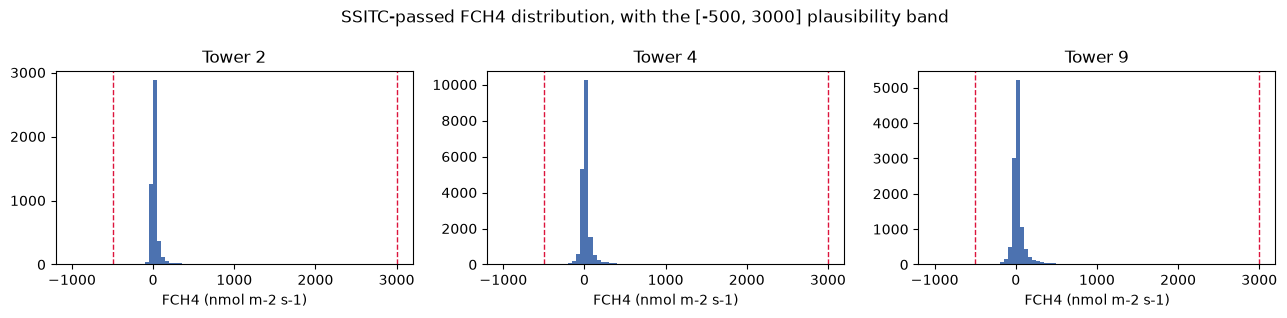

In [5]:
PLAUS_LOW, PLAUS_HIGH = -500, 3000   # nmol m-2 s-1 plausibility bound for FCH4 (D-13)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, TOWERS):
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    qc = raw[tgt].where(raw[ssitc].isin([0, 1]))
    n_extreme = int((qc.notna() & ~qc.between(PLAUS_LOW, PLAUS_HIGH)).sum())
    print(f"Tower {t}: SSITC-passed range [{qc.min():.0f}, {qc.max():.0f}] nmol m-2 s-1, "
          f"{n_extreme} points outside [{PLAUS_LOW}, {PLAUS_HIGH}]")
    ax.hist(qc.clip(-1000, 3000).dropna(), bins=80, color="#4C72B0")
    ax.axvline(PLAUS_LOW, color="crimson", ls="--", lw=1); ax.axvline(PLAUS_HIGH, color="crimson", ls="--", lw=1)
    ax.set_title(f"Tower {t}"); ax.set_xlabel("FCH4 (nmol m-2 s-1)")
plt.suptitle("SSITC-passed FCH4 distribution, with the [-500, 3000] plausibility band")
plt.tight_layout(); plt.show()

**Fix:** an FCH4 plausibility filter `[-500, 3000]` nmol m-2 s-1 (D-13), applied together with the
SSITC `{0,1}` filter, defines "target" throughout. Mirrors FC's `[-100, 100]` bound (D-25).

### 1.5 Spatial alignment -- Tower N = Catchment N

**Critical rule (D-18): Tower N's model must use only Catchment N's soil data** -- never average
across catchments. Tower 4's catchment column carries a historical suffix, and its on-tower soil
temperature sensor barely has data.

In [6]:
for t in TOWERS:
    cat = CAT[t]
    swc_col = f"Soil Moisture @ 10cm Depth (%) [{cat}]"
    ts_ec_col = f"TS_1_1_1 [Tower {t}]"                          # on-tower EC soil temp sensor
    ts_ext_col = f"Soil Temperature @ 15cm Depth (oC) [{cat}]"   # own-catchment external SMS sensor
    print(f"Tower {t} <-> {cat}")
    print(f"  own-catchment soil moisture (10cm, external): {100*raw[swc_col].notna().mean():5.1f}% coverage")
    print(f"  on-tower EC soil temperature (TS_1_1_1):      {100*raw[ts_ec_col].notna().mean():5.1f}% coverage")
    print(f"  own-catchment soil temperature (external):    {100*raw[ts_ext_col].notna().mean():5.1f}% coverage")

Tower 2 <-> Catchment 2
  own-catchment soil moisture (10cm, external):  71.0% coverage
  on-tower EC soil temperature (TS_1_1_1):        5.2% coverage
  own-catchment soil temperature (external):     75.2% coverage
Tower 4 <-> Catchment 4 After  2013/08/13
  own-catchment soil moisture (10cm, external):  56.5% coverage
  on-tower EC soil temperature (TS_1_1_1):        9.6% coverage
  own-catchment soil temperature (external):     57.3% coverage
Tower 9 <-> Catchment 9
  own-catchment soil moisture (10cm, external):  66.0% coverage
  on-tower EC soil temperature (TS_1_1_1):       71.5% coverage
  own-catchment soil temperature (external):     69.0% coverage


**Fix:** Tower 4's on-tower EC soil temperature is badly undercovered (~10%, D-16). The
**own-catchment external SMS sensor** has far better coverage and is genuinely site-specific, so
it fully replaces the old cross-tower EC proxy (D-35).

### 1.6 Meteorological driver sourcing -- EC tower vs. external Site/SMS network

NWFP runs two independent sensor networks: each EC tower's own suite, and a separate `[Site]`
MET station + per-catchment SMS soil stations. F-08 (D-35) asks whether external, farm-scale
sourcing beats each tower's own (sometimes gappier) sensor for solar radiation, air temperature,
and wind speed.

In [7]:
SITE_SW = "Solar Radiation (W/m2) [Site]"
SITE_TA = "Air Temperature (oC) [Site]"
SITE_WS = "Wind Speed (km/h) [Site]"

for t in TOWERS:
    for ec_col, site_col, label in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, "SWIN/solar"),
                                     (f"TA_0_0_1 [Tower {t}]", SITE_TA, "TA/air temp"),
                                     (f"WS_0_0_1 [Tower {t}]", SITE_WS, "WS/wind")]:
        print(f"Tower {t} {label:10s}: EC-tower {100*raw[ec_col].notna().mean():5.1f}%  |  "
              f"Site-external {100*raw[site_col].notna().mean():5.1f}%")

Tower 2 SWIN/solar: EC-tower  52.7%  |  Site-external  99.0%
Tower 2 TA/air temp: EC-tower  67.3%  |  Site-external  99.0%
Tower 2 WS/wind   : EC-tower  72.1%  |  Site-external  94.4%
Tower 4 SWIN/solar: EC-tower  75.4%  |  Site-external  99.0%
Tower 4 TA/air temp: EC-tower  78.4%  |  Site-external  99.0%
Tower 4 WS/wind   : EC-tower  78.4%  |  Site-external  94.4%
Tower 9 SWIN/solar: EC-tower  71.5%  |  Site-external  99.0%
Tower 9 TA/air temp: EC-tower  74.9%  |  Site-external  99.0%
Tower 9 WS/wind   : EC-tower  74.9%  |  Site-external  94.4%


**Fix (D-35):** swap `SWIN_1_1_1`/`TA_0_0_1`/`WS_0_0_1` for every tower to `[Site]` readings (wind
km/h -> m/s), under the same EC column names. F-08 found this accuracy-neutral to mildly positive
(pooled +0.01-0.014 R2, never harmful) -- adopted mainly for the soil-temperature fix above and
robustness. Built in section 2.2.

### 1.7 Sensor contamination -- USTAR and VPD (the D-48 bug)

Found via a user-observed anomaly: a sustained spike in Tower 2's gap-filled FCH4 during a period
with zero real observations, traced (via SHAP) to `USTAR_0_0_1` never having been
plausibility-filtered, so outlier readings dragged the global-mean fallback far from sane values.

In [8]:
# Met-driver plausibility bounds (D-48). Only USTAR and VPD show real outlier contamination
# across all towers (audited); PPFD/WS/SHF were checked and are clean.
MET_PLAUS = {"USTAR_0_0_1": (0.0, 3.0), "VPD_0_0_1": (0.0, 15.0)}

for base, (lo, hi) in MET_PLAUS.items():
    print(f"--- {base} plausibility bound [{lo}, {hi}] ---")
    for t in TOWERS:
        s = raw[f"{base} [Tower {t}]"].astype(float)
        n_bad = int((s.notna() & ~s.between(lo, hi)).sum())
        pct_bad = 100 * n_bad / s.notna().sum() if s.notna().sum() else np.nan
        print(f"  Tower {t}: n={s.notna().sum():6,}  mean={s.mean():7.3f}  median={s.median():7.3f}  "
              f"max={s.max():10.1f}  |  {n_bad} points ({pct_bad:.1f}%) outside bound")

--- USTAR_0_0_1 plausibility bound [0.0, 3.0] ---
  Tower 2: n=50,563  mean=  2.450  median=  0.233  max=    1039.9  |  722 points (1.4%) outside bound
  Tower 4: n=55,012  mean=  3.332  median=  0.222  max=    1408.8  |  914 points (1.7%) outside bound
  Tower 9: n=52,564  mean=  2.886  median=  0.230  max=    1085.1  |  785 points (1.5%) outside bound
--- VPD_0_0_1 plausibility bound [0.0, 15.0] ---
  Tower 2: n=38,700  mean=  5.988  median=  5.841  max=      36.5  |  818 points (2.1%) outside bound
  Tower 4: n=52,936  mean=  8.387  median=  7.048  max=      41.3  |  6677 points (12.6%) outside bound
  Tower 9: n=45,699  mean=  6.431  median=  6.327  max=      37.1  |  824 points (1.8%) outside bound


**Fix (D-48), applied in section 2.3:** (1) `plausibility_filter()` sets out-of-bound raw readings
to `NaN` before gap-filling; (2) the last-resort fallback changes from mean to median (robust to
outliers by construction).

### 1.8 Tower 2's temporal regime shift -- why a year-based train/test split fails

In [9]:
tgt2, ssitc2 = "FCH4_1_1_1 [Tower 2]", "FCH4_SSITC_TEST_1_1_1 [Tower 2]"
qc2 = raw[tgt2].where(raw[ssitc2].isin([0, 1]))
by_year_valid = qc2.notna().groupby(raw.index.year).sum()
by_year_mean = qc2.groupby(raw.index.year).mean()
cattle2 = raw[f"cattle_{CAT[2]}"]
by_year_cattle = cattle2.groupby(raw.index.year).mean()

summary = pd.DataFrame({"n_valid_FCH4": by_year_valid, "mean_FCH4": by_year_mean.round(1),
                         "mean_cattle_head": by_year_cattle.round(1)})
print("Tower 2 (Catchment 2) by year:")
print(summary.loc[summary["n_valid_FCH4"] > 0].to_string())

Tower 2 (Catchment 2) by year:
          n_valid_FCH4  mean_FCH4  mean_cattle_head
Datetime                                           
2017               314      -24.4               4.5
2018              3644      485.9               5.8
2019               950        1.0               0.0


**Issue (F-07, D-34):** Tower 2's analyser was only live Oct 2017-Jun 2019. 2018 had cattle
(higher FCH4), 2019 had none (near-zero FCH4) -- a genuine regime shift. A year-based train/test
split trains on one regime and tests on the other, guaranteeing a catastrophic result (original
R2 = **-16.9**) that reflects a broken evaluation design, not a bad model.

**Fix (used for every tower, not just Tower 2):** evaluate via **full-period gap-CV** -- synthetic
calendar-shaped gaps cut from each tower's *entire* valid domain (real observations elsewhere
remain available to train on). Implemented in section 4.

### 1.9 FC (CO2 flux) coverage and outliers -- the feature imputed first

In [10]:
FC_LOW, FC_HIGH = -100.0, 100.0   # umol CO2 m-2 s-1 plausibility bound (D-25)

for t in TOWERS:
    fc, ssitc = f"FC_1_1_1 [Tower {t}]", f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    qc_fc_raw = raw[fc].where(raw[ssitc].isin([0, 1]))
    n_bad = int((qc_fc_raw.notna() & ~qc_fc_raw.between(FC_LOW, FC_HIGH)).sum())
    print(f"Tower {t}: raw {100*raw[fc].notna().mean():5.1f}% valid, "
          f"SSITC-passed {100*qc_fc_raw.notna().mean():5.1f}% valid, "
          f"{n_bad} points outside [{FC_LOW}, {FC_HIGH}] umol m-2 s-1")

Tower 2: raw  61.4% valid, SSITC-passed  44.3% valid, 114 points outside [-100.0, 100.0] umol m-2 s-1
Tower 4: raw  74.3% valid, SSITC-passed  56.3% valid, 125 points outside [-100.0, 100.0] umol m-2 s-1
Tower 9: raw  69.5% valid, SSITC-passed  51.3% valid, 95 points outside [-100.0, 100.0] umol m-2 s-1


**Why FC matters:** an earlier ablation (03b, D-22/D-26) found CO2 flux (FC) is FCH4's single
strongest predictor at NWFP -- adding a gap-filled FCO2 feature flipped Tower 4's RFm from
negative to positive R2. FC itself has real gaps, so it is **reconstructed as a complete feature
before it is used as a CH4-model input** (section 2.1).

### 1.10 EDA summary

| # | Issue | Fix | Where |
|---|---|---|---|
| 1 | FCH4/FC quality flags + implausible extremes | SSITC in {0,1}; FCH4 `[-500,3000]`, FC `[-100,100]` | 2.1, 3.4 |
| 2 | Spatial misalignment risk across 15 catchments | Tower N = Catchment N always (D-18) | 1.5, 3.4 |
| 3 | Tower 4 on-tower soil temperature ~10% coverage | Per-catchment external SMS soil temp (D-35) | 2.2 |
| 4 | USTAR/VPD raw sensor contamination | Plausibility filter + median fallback (D-48) | 2.3 |
| 5 | Tower 2 livestock regime shift | Full-period gap-CV, not year split (D-34) | 4 |
| 6 | FC has real gaps but is FCH4's strongest predictor | RF-reconstructed FCO2 feature | 2.1 |
| 7 | Met drivers previously only mean-imputed | REddyProc-style gap-fill pipeline | 2.3 |

## 2. Feature imputation

Before the FCH4 target is ever touched, two upstream features must be made complete: **FC (CO2
flux)**, reconstructed EC-sourced via a met-driven RF (2.1), and the **meteorological drivers**,
gap-filled REddyProc-style (2.3) on top of the **external-sourced** driver set (2.2).

### 2.1 FCO2 (CO2 flux) reconstruction

FC is kept **EC-sourced** throughout (no external-network twin, unlike SWIN/TA/WS/soil
temperature). A per-tower Random Forest trained on met drivers only (`driver_m`, identical to the
R-02 replication, D-21) reconstructs a complete FCO2 series: where a real QC'd observation exists
it is kept, elsewhere the RF reconstruction is used. Produces `FC_gapfilled [Tower N]`, later used
as the `fc` feature in the CH4 model.

In [11]:
# driver_m (met-only) per tower -- identical to R-02 (D-21); Tower 2 uses its only usable years (D-15).
FCO2_AUX = ["_hour_sin", "_hour_cos", "_doy_sin", "_doy_cos"]

FCO2_TOWER_CONFIGS = {
    2: {"fc": "FC_1_1_1 [Tower 2]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 2]",
        "driver_m": ["SWIN_1_1_1 [Tower 2]", "TA_0_0_1 [Tower 2]", "VPD_0_0_1 [Tower 2]",
                     "PPFD_1_1_1 [Tower 2]", "USTAR_0_0_1 [Tower 2]", "WS_0_0_1 [Tower 2]",
                     "RN_1_1_1 [Tower 2]", "Precipitation (mm) [Catchment 2]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 2]",
                     "SHF_1_1_1 [Tower 2]"],
        "train_yrs": [2018], "test_yrs": [2019]},
    4: {"fc": "FC_1_1_1 [Tower 4]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 4]",
        "driver_m": [f"SWIN_1_1_1 [Tower 4]", "TA_0_0_1 [Tower 4]", "VPD_0_0_1 [Tower 4]",
                     "PPFD_1_1_1 [Tower 4]", "USTAR_0_0_1 [Tower 4]", "WS_0_0_1 [Tower 4]",
                     "RN_1_1_1 [Tower 4]", f"Precipitation (mm) [{C4}]",
                     "TS_1_1_1 [Tower 9]", f"Soil Moisture @ 10cm Depth (%) [{C4}]",
                     "SHF_1_1_1 [Tower 4]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
    9: {"fc": "FC_1_1_1 [Tower 9]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 9]",
        "driver_m": ["SWIN_1_1_1 [Tower 9]", "TA_0_0_1 [Tower 9]", "VPD_0_0_1 [Tower 9]",
                     "PPFD_1_1_1 [Tower 9]", "USTAR_0_0_1 [Tower 9]", "WS_0_0_1 [Tower 9]",
                     "RN_1_1_1 [Tower 9]", "Precipitation (mm) [Catchment 9]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 9]",
                     "SHF_1_1_1 [Tower 9]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
}


@timeit
def add_cyclical(df):
    hour, doy = df.index.hour, df.index.dayofyear
    df["_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["_hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["_doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["_doy_cos"] = np.cos(2 * np.pi * doy / 365)


@timeit
def reconstruct_fc(df, tower, cfg):
    """RF-reconstruct a complete FC series for one tower; return (fc_gapfilled, stats)."""
    fc_col, ssitc_col, feats = cfg["fc"], cfg["ssitc"], cfg["driver_m"] + FCO2_AUX

    fc_obs = df[fc_col].copy()
    fc_obs[~df[ssitc_col].isin([0, 1])] = np.nan
    fc_obs[fc_obs.notna() & ~fc_obs.between(FC_LOW, FC_HIGH)] = np.nan

    train_mask = df.index.year.isin(cfg["train_yrs"]) & fc_obs.notna()
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(df.loc[train_mask, feats].values)
    y_train = fc_obs.loc[train_mask].values

    rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, n_jobs=1, random_state=42)
    # n_jobs=1, not -1: parallel RF training is NOT bit-reproducible across separate process
    # runs even with random_state fixed (confirmed empirically) -- FCO2 is the one RF step not
    # itself cached, so its cross-run drift would otherwise cascade into every downstream
    # cache key (via the "fc" feature) and silently defeat the section 4.1 model cache.
    rf.fit(X_train, y_train)

    X_all = imputer.transform(df[feats].values)
    fc_recon = pd.Series(rf.predict(X_all), index=df.index)

    fc_gapfilled = fc_obs.copy()
    fc_gapfilled[fc_gapfilled.isna()] = fc_recon[fc_gapfilled.isna()]

    test_mask = df.index.year.isin(cfg["test_yrs"]) & fc_obs.notna()
    if test_mask.sum() >= 20:
        val_r2 = r2_score(fc_obs.loc[test_mask].values, fc_recon.loc[test_mask].values)
    else:
        val_r2 = np.nan
    stats = {"tower": tower, "n_train": int(train_mask.sum()),
              "n_filled_by_recon": int(fc_obs.isna().sum()), "recon_test_r2": val_r2,
              "recon_test_n": int(test_mask.sum())}
    return fc_gapfilled, stats


add_cyclical(raw)
fco2_gapfilled = pd.DataFrame(index=raw.index)
fco2_stats = []
for t in TOWERS:
    filled, stats = reconstruct_fc(raw, t, FCO2_TOWER_CONFIGS[t])
    fco2_gapfilled[f"FC_gapfilled [Tower {t}]"] = filled
    fco2_stats.append(stats)
    print(f"Tower {t}: n_train={stats['n_train']:,}  filled-by-reconstruction={stats['n_filled_by_recon']:,}  "
          f"recon test R2={stats['recon_test_r2']:.3f} (n={stats['recon_test_n']:,})")

Tower 2: n_train=5,511  filled-by-reconstruction=39,159  recon test R2=0.197 (n=1,189)


Tower 4: n_train=21,869  filled-by-reconstruction=30,799  recon test R2=0.745 (n=10,986)


Tower 9: n_train=19,952  filled-by-reconstruction=34,249  recon test R2=0.746 (n=9,592)


### 2.2 External sensor sourcing (F-08, D-35)

Overwrites each tower's `SWIN_1_1_1`/`TA_0_0_1`/`WS_0_0_1` with the `[Site]` external readings
(wind km/h -> m/s), under the same EC column names. Soil temperature is handled in 2.3 by
pointing the driver map at the per-catchment external sensor. FC/VPD/PPFD/RN/USTAR/SHF stay
EC-sourced. Produces `df_ext`, the working dataframe for every remaining step.

In [12]:
df_ext = raw.copy()
for t in TOWERS:
    for ec_col, site_col, conv in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, 1.0),
                                    (f"TA_0_0_1 [Tower {t}]", SITE_TA, 1.0),
                                    (f"WS_0_0_1 [Tower {t}]", SITE_WS, 1.0 / 3.6)]:   # km/h -> m/s
        src = pd.to_numeric(raw[site_col], errors="coerce") * conv
        n_ec, n_ext = raw[ec_col].notna().sum(), src.notna().sum()
        df_ext[ec_col] = src
        print(f"  T{t} {ec_col.split(' [')[0]:12s} <- {site_col:28s}  "
              f"cov {100*n_ec/len(raw):.0f}% -> {100*n_ext/len(raw):.0f}%")

print(f"\ndf_ext shape: {df_ext.shape}")

  T2 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 53% -> 99%
  T2 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 67% -> 99%
  T2 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 72% -> 94%
  T4 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 75% -> 99%
  T4 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 78% -> 99%
  T4 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 78% -> 94%
  T9 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 71% -> 99%
  T9 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 75% -> 99%
  T9 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 75% -> 94%

df_ext shape: (70153, 453)


### 2.3 Meteorological driver gap-filling (REddyProc-style, D-33/D-48)

A from-scratch REddyProc-style pipeline: linear interpolation for short gaps, then a
mean-diurnal-course (MDC) with an expanding lookback window for longer ones, then a robust
(median, not mean -- D-48) fallback for total blackouts. `plausibility_filter` runs before
gap-filling so contaminated USTAR/VPD readings never reach the fallback.

`LONG_INTERP_VARS` extends the interpolation limit to 288h for soil moisture/temperature, air
temperature, VPD, and wind speed -- these are smooth, weakly-diurnal signals where plain
interpolation beats MDC on long gaps (found empirically; validated below in 2.4). Radiation-driven
variables (SWIN/PPFD/RN) and SHF keep the original MDC-first behaviour, since a straight line
across a multi-day gap misses their day/night cycle entirely.

In [13]:
@timeit
def plausibility_filter(s, colname):
    """Set values outside MET_PLAUS[colname] to NaN before gap-filling (D-48). No-op if
    colname has no bound registered. Applied ahead of mdc_gapfill so contaminated raw
    outliers never enter the interpolation/MDC/fallback chain in the first place."""
    base = colname.split(" [")[0]
    if base not in MET_PLAUS:
        return s
    lo, hi = MET_PLAUS[base]
    s = s.astype(float).copy()
    s[s.notna() & ~s.between(lo, hi, inclusive="both")] = np.nan
    return s


# Variables where mdc_gapfill's per-hour-of-day pivot averaging is a poor fit: smooth,
# slowly-drifting signals with weak diurnal structure. Plain linear interpolation beats the
# MDC pipeline on long (288h/12-day) gaps for these, consistently across all 3 towers (validated
# in section 2.4). The reverse holds for radiation-driven variables (SWIN/PPFD/RN) and SHF/WS/
# precip, where a straight line across a multi-day gap misses the day/night cycle entirely.
# USTAR is a wash either way and is also left unchanged.
LONG_INTERP_VARS = {"TA_0_0_1", "VPD_0_0_1", "Soil Moisture @ 10cm Depth (%)",
                     "Soil Temperature @ 15cm Depth (oC)", "WS_0_0_1"}


@timeit
def mdc_gapfill(s, colname=None, fallback="median"):
    """Linear interp (<=2h, or <=288h for LONG_INTERP_VARS) then mean-diurnal-course with
    expanding +/-7/14/28/60d window, then a per-hour and finally a global fallback (median by
    default, D-48; mean pre-fix)."""
    out = s.astype(float).copy()
    n_obs = out.notna().sum()
    interp_limit = 288 if (colname is not None and colname.split(" [")[0] in LONG_INTERP_VARS) else 2
    out = out.interpolate(limit=interp_limit, limit_area="inside")
    idx = out.index
    piv = (pd.DataFrame({"v": out.values, "hour": idx.hour, "date": idx.normalize()})
           .pivot_table(index="date", columns="hour", values="v"))
    for w in [7, 14, 28, 60]:
        piv = piv.fillna(piv.rolling(2 * w + 1, min_periods=1, center=True).mean())
    ser = piv.stack(dropna=False)
    key = pd.MultiIndex.from_arrays([idx.normalize(), idx.hour])
    mapped = pd.Series(ser.reindex(key).values, index=idx)
    out = out.where(out.notna(), mapped)
    if out.isna().any():
        agg = "median" if fallback == "median" else "mean"
        hourly_fb = out.groupby(idx.hour).transform(agg)
        out = out.where(out.notna(), hourly_fb)
        out = out.fillna(out.median() if fallback == "median" else out.mean())
    return out, int(n_obs), int(out.notna().sum())


print("plausibility_filter / mdc_gapfill defined.")

plausibility_filter / mdc_gapfill defined.


Applied per driver, per tower: solar, air temp, VPD, PPFD, net radiation, wind, u*, soil heat
flux, precipitation, soil moisture (SWIN/TA/WS hold the external Site values after section 2.2's
swap), and soil temperature -- pointed at the **per-catchment external sensor** (`ts_col_for`),
not the old Tower-9 EC proxy.

In [14]:
@timeit
def ts_col_for(t):
    """Own-catchment external soil temperature (D-35), replacing the old Tower-9 EC proxy (D-16)."""
    return f"Soil Temperature @ 15cm Depth (oC) [{CAT[t]}]"


@timeit
def driver_map(t):
    cat = CAT[t]
    return {"sw": f"SWIN_1_1_1 [Tower {t}]", "ta": f"TA_0_0_1 [Tower {t}]",
            "vpd": f"VPD_0_0_1 [Tower {t}]", "ppfd": f"PPFD_1_1_1 [Tower {t}]",
            "rn": f"RN_1_1_1 [Tower {t}]", "ws": f"WS_0_0_1 [Tower {t}]",
            "ustar": f"USTAR_0_0_1 [Tower {t}]", "shf": f"SHF_1_1_1 [Tower {t}]",
            "precip": f"Precipitation (mm) [{cat}]",
            "swc": f"Soil Moisture @ 10cm Depth (%) [{cat}]", "ts": ts_col_for(t)}


met_filled = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    print(f"=== Tower {t} ===")
    for k, col in driver_map(t).items():
        filled, n0, n1 = mdc_gapfill(plausibility_filter(df_ext[col], col), colname=col)
        met_filled[f"{col}__f"] = filled.round(4)
        print(f"  {k:6s}: {100*df_ext[col].notna().mean():5.1f}% -> {100*filled.notna().mean():5.1f}%  [{col}]")

=== Tower 2 ===
  sw    :  99.0% -> 100.0%  [SWIN_1_1_1 [Tower 2]]
  ta    :  99.0% -> 100.0%  [TA_0_0_1 [Tower 2]]


  vpd   :  55.2% -> 100.0%  [VPD_0_0_1 [Tower 2]]
  ppfd  :  53.4% -> 100.0%  [PPFD_1_1_1 [Tower 2]]


  rn    :  52.7% -> 100.0%  [RN_1_1_1 [Tower 2]]
  ws    :  94.4% -> 100.0%  [WS_0_0_1 [Tower 2]]
  ustar :  72.1% -> 100.0%  [USTAR_0_0_1 [Tower 2]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

  shf   :  37.9% -> 100.0%  [SHF_1_1_1 [Tower 2]]
  precip:  72.7% -> 100.0%  [Precipitation (mm) [Catchment 2]]
  swc   :  71.0% -> 100.0%  [Soil Moisture @ 10cm Depth (%) [Catchment 2]]


...

  rn    :  71.5% -> 100.0%  [RN_1_1_1 [Tower 9]]
  ws    :  94.4% -> 100.0%  [WS_0_0_1 [Tower 9]]


  ustar :  74.9% -> 100.0%  [USTAR_0_0_1 [Tower 9]]
  shf   :  71.5% -> 100.0%  [SHF_1_1_1 [Tower 9]]
  precip:  54.6% -> 100.0%  [Precipitation (mm) [Catchment 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

  swc   :  66.0% -> 100.0%  [Soil Moisture @ 10cm Depth (%) [Catchment 9]]
  ts    :  69.0% -> 100.0%  [Soil Temperature @ 15cm Depth (oC) [Catchment 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


### 2.4 Validating the gap-filling accuracy

A shared gap-testing toolkit -- synthetically mask calendar-shaped chunks of a variable's record,
reconstruct them, score against the held-out real values -- defined once here and reused in
section 4's main FCH4 gap-CV harness (which adds a tower-specific `DOMAIN` and the RF/MDS models).

In [15]:
MASK_FRAC = 0.25
SCENARIOS = {"vs": 1, "s": 4, "m": 32, "l": 288, "m1": "mixed"}
N_REPS = 2   # matches F-09a's exact scope, not F-08's original 5

@timeit
def insert_calendar_gaps(df_qc, target, domain_mask, gap_hours, n_reps=N_REPS, seed=0):
    """Randomly place n_reps independent sets of non-overlapping calendar-shaped gaps within the
    domain, each covering ~MASK_FRAC of the domain's valid target points."""
    dom_ts = df_qc.index[domain_mask]; valid = df_qc.loc[domain_mask, target].notna().values
    n = len(dom_ts); target_n = max(1, int(valid.sum() * MASK_FRAC)); rb = np.random.default_rng(seed); reps = []
    for _ in range(n_reps):
        rng = np.random.default_rng(int(rb.integers(0, 2**31))); occ = np.zeros(n, bool); m = 0
        for sp in rng.permutation(n):
            if m >= target_n:
                break
            gh = int(rng.choice([1, 4, 32, 288])) if gap_hours == "mixed" else gap_hours
            ep = min(int(sp) + gh, n)
            if occ[sp:ep].any():
                continue
            occ[sp:ep] = True; m += int(valid[sp:ep].sum())
        reps.append(dom_ts[occ & valid])
    return reps


from scipy.stats import linregress


@timeit
def mets(y, p):
    """Returns (R2_sklearn, RMSE, MAE, MBE, R2_OLS, OLS_slope). R2_sklearn = 1 - SS_res/SS_tot
    (this project's standing out-of-sample metric, unbounded below). R2_OLS = the squared Pearson
    correlation coefficient from an OLS fit of (y, p) -- Zhu et al. (2023a)'s own convention
    (p.6: "R2 and slope of the ordinary least squares regression"), bounded in [0, 1] by
    construction. The two diverge sharply for methods whose predictions correlate with truth but
    are miscalibrated in scale/bias (MDS especially -- see temp_mds.ipynb section 11/13.4)."""
    y = np.asarray(y, float); p = np.asarray(p, float)
    r2 = r2_score(y, p) if np.var(y) > 0 else np.nan
    if np.var(y) > 0 and np.var(p) > 0:
        slope, _, r, _, _ = linregress(y, p)
        r2_ols = r ** 2
    else:
        slope, r2_ols = np.nan, np.nan
    return (r2, float(np.sqrt(np.mean((p - y) ** 2))), float(np.mean(np.abs(p - y))),
            float(np.mean(p - y)), r2_ols, slope)


@timeit
def med_metrics(rows):
    if not rows:
        return {k: np.nan for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    a = np.array(rows, float)
    return {"R2": np.nanmedian(a[:, 0]), "RMSE": np.median(a[:, 1]),
            "MAE": np.median(a[:, 2]), "MBE": np.median(a[:, 3]),
            "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}

print("Shared gap-testing toolkit defined (reused in sections 2.4 and 4).")

Shared gap-testing toolkit defined (reused in sections 2.4 and 4).


Checked against a naive constant-median baseline (per fold, on the same held-out points) for all
11 met/soil drivers x 3 towers -- confirms `mdc_gapfill` beats the simplest possible imputation,
not just that R2 crosses zero (a weak bar for skewed variables like USTAR/precipitation).

In [16]:
@timeit
def eval_driver_gapfill(colname):
    """Full-period gap-CV for one gap-filled driver: mdc_gapfill()'s own reconstruction, AND a
    naive constant-median baseline (median of the remaining real domain values, per fold) scored
    on the exact same held-out points."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out, out_base = {}, {}
    for sc, gh in SCENARIOS.items():
        rr, rr_base = [], []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            sav = s_raw.loc[gt].copy()
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            filled, _, _ = mdc_gapfill(plausibility_filter(s_masked, colname), colname=colname)
            rr.append(mets(sav.values, filled.loc[gt].values))
            train_median = s_masked.loc[dm].median()
            rr_base.append(mets(sav.values, np.full(len(gt), train_median)))
        out[sc] = med_metrics(rr)
        out_base[sc] = med_metrics(rr_base)
    return out, out_base


driver_rows = []
for t in TOWERS:
    for var_key, colname in driver_map(t).items():
        scn, scn_base = eval_driver_gapfill(colname)
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        ov_base = {k: np.nanmedian([scn_base[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        driver_rows.append({"tower": t, "driver": var_key, "column": colname,
                             **{f"{k}_overall": round(ov[k], 3) for k in ov},
                             "R2_median_baseline": round(ov_base["R2"], 3),
                             "beats_median_baseline": ov["R2"] > ov_base["R2"]})
        beats = "beats" if ov["R2"] > ov_base["R2"] else "LOSES TO"
        print(f"Tower {t} {var_key:6s}: mdc_gapfill R2={ov['R2']:+.3f}  vs  median-baseline R2={ov_base['R2']:+.3f}"
              f"  ({beats} the naive median baseline)")

MET_GAPFILL_R2 = pd.DataFrame(driver_rows)
MET_GAPFILL_R2

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\3382377119.py:54: RuntimeWarning: All-NaN slice encountered
  "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\3382377119.py:54: RuntimeWarning: All-NaN slice encountered
  "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous

Tower 2 sw    : mdc_gapfill R2=+0.683  vs  median-baseline R2=-0.324  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\3382377119.py:54: RuntimeWarning: All-NaN slice encountered
  "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

...

Tower 9 swc   : mdc_gapfill R2=+0.998  vs  median-baseline R2=-0.216  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

Tower 9 ts    : mdc_gapfill R2=+0.994  vs  median-baseline R2=-0.031  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\3382377119.py:54: RuntimeWarning: All-NaN slice encountered
  "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\2664310239.py:39: FutureWarning: The previous

,tower,driver,column,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_median_baseline,beats_median_baseline
0,2,sw,SWIN_1_1_1 [Tower 2],0.683,111.618,58.179,-7.052,-0.324,True
1,2,ta,TA_0_0_1 [Tower 2],0.685,2.922,2.129,-0.093,-0.002,True
2,2,vpd,VPD_0_0_1 [Tower 2],0.670,2.476,1.495,-0.140,-0.011,True
3,2,ppfd,PPFD_1_1_1 [Tower 2],0.691,194.701,98.607,-11.144,-0.330,True
4,2,rn,RN_1_1_1 [Tower 2],0.742,69.401,43.974,-1.404,-0.180,True
5,2,ws,WS_0_0_1 [Tower 2],0.459,1.316,0.970,-0.043,-0.025,True
6,2,ustar,USTAR_0_0_1 [Tower 2],-0.007,23.188,2.073,-1.982,-0.007,True
7,2,shf,SHF_1_1_1 [Tower 2],0.560,12.289,8.644,0.090,-0.004,True
8,2,precip,Precipitation (mm) [Catchment 2],-0.066,0.107,0.027,-0.007,-0.055,False
9,2,swc,Soil Moisture @ 10cm Depth (%) [Catchment 2],0.995,0.538,0.189,-0.018,-0.275,True


## 3. Additional feature engineering

Builds the remaining engineered features on top of the imputed drivers: productivity/respiration
(GPP/Reco), management-event recency, livestock stocking density, then assembles everything into
the final per-tower modelling frame.

### 3.1 u*-filtering + nighttime NEE partitioning (GPP/Reco)

Two REddyProc-style derived features: a pragmatic binned-plateau **u* threshold** (simplification
of Papale 2006's Moving Point Test, used only to flag data quality) and **NEE partitioning**
(Reichstein 2005 nighttime method: global E0 + block-wise Rref via Lloyd & Taylor 1994 on
nighttime FC, extrapolated to get Reco, with GPP = Reco - FC). GPP was found (F-06, D-33) to be
the single biggest post-pooling accuracy gain in the gap-filling programme (Tower 9 R2 +0.335).

In [17]:
@timeit
def qc_fc(df, t):
    fc = df[f"FC_1_1_1 [Tower {t}]"].astype(float).copy()
    ss = f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    fc[~df[ss].isin([0, 1])] = np.nan
    fc[fc.notna() & ~fc.between(FC_LOW, FC_HIGH)] = np.nan
    return fc


@timeit
def ustar_threshold(ta, ustar, fc, rg):
    """Binned-plateau u* threshold (pragmatic; simplification of Papale 2006 MPT)."""
    night = (rg < 20) & ta.notna() & ustar.notna() & fc.notna()
    d = pd.DataFrame({"ta": ta[night], "ustar": ustar[night], "fc": fc[night]})
    d = d[d["ustar"] > 0]
    if len(d) < 200:
        return 0.10
    try:
        d["tc"] = pd.qcut(d["ta"], 6, duplicates="drop")
    except ValueError:
        d["tc"] = 0
    thr = []
    for _, g in d.groupby("tc", observed=True):
        if len(g) < 50:
            continue
        edges = np.unique(np.quantile(g["ustar"], np.linspace(0, 1, 21)))
        if len(edges) < 6:
            continue
        g = g.assign(ub=pd.cut(g["ustar"], edges, labels=False, include_lowest=True))
        m = g.groupby("ub")["fc"].mean()
        c = g.groupby("ub")["ustar"].mean()
        if len(m) < 6:
            continue
        plateau = m.loc[m.index >= m.index.max() // 2].mean()
        if not np.isfinite(plateau) or plateau <= 0:
            continue
        ok = m[m >= 0.95 * plateau]
        if len(ok):
            thr.append(float(c.loc[ok.index[0]]))
    if not thr:
        return 0.10
    return float(np.clip(np.median(thr), 0.01, 0.5))


@timeit
def lloyd_taylor(t_k, rref, e0):
    T0, Tref = 227.13, 283.15
    return rref * np.exp(e0 * (1.0 / (Tref - T0) - 1.0 / (t_k - T0)))


@timeit
def partition_nee(fc, ta, rg):
    """Nighttime partitioning: global E0 + block-wise Rref (Lloyd-Taylor) -> GPP, Reco."""
    t_k = ta + 273.15
    night = (rg < 20) & fc.notna() & ta.notna() & (t_k > 230)
    gpp = pd.Series(np.nan, index=fc.index)
    reco = pd.Series(np.nan, index=fc.index)
    if night.sum() < 300:
        return gpp, reco, None
    Tn, Fn = t_k[night].values, fc[night].values
    try:
        (rref0, e0), _ = curve_fit(lloyd_taylor, Tn, Fn, p0=[2.0, 150.0],
                                    bounds=([0, 30], [60, 450]), maxfev=10000)
    except Exception:
        return gpp, reco, None
    days = (fc.index - fc.index[0]).days
    blk = days // 7
    rref_by_blk = {}
    nb = pd.DataFrame({"t_k": t_k[night], "fc": fc[night], "blk": blk[night.values]})
    for b, g in nb.groupby("blk"):
        if len(g) < 8:
            continue
        try:
            (rr,), _ = curve_fit(lambda T, rr: lloyd_taylor(T, rr, e0),
                                  g["t_k"].values, g["fc"].values,
                                  p0=[rref0], bounds=([0], [60]), maxfev=5000)
            rref_by_blk[b] = rr
        except Exception:
            continue
    if not rref_by_blk:
        rref_t = pd.Series(rref0, index=fc.index)
    else:
        blk_series = pd.Series(blk, index=fc.index)
        rref_t = blk_series.map(rref_by_blk).astype(float)
        rref_t = rref_t.interpolate().bfill().ffill().fillna(rref0)
    reco_vals = lloyd_taylor(t_k, rref_t.values, e0)
    reco = pd.Series(reco_vals, index=fc.index)
    gpp = reco - fc
    gpp[gpp < 0] = 0.0
    gpp[rg < 20] = 0.0
    return gpp, reco, float(e0)


gpp_reco = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    dm = driver_map(t)
    fc = qc_fc(df_ext, t)
    sw = met_filled[f"{dm['sw']}__f"]; ta = met_filled[f"{dm['ta']}__f"]; us = met_filled[f"{dm['ustar']}__f"]
    thr = ustar_threshold(ta, us, fc, sw)
    gpp, reco, e0 = partition_nee(fc, ta, sw)
    gpp_reco[f"GPP [Tower {t}]"] = gpp.round(4)
    gpp_reco[f"Reco [Tower {t}]"] = reco.round(4)
    print(f"Tower {t}: u* threshold={thr:.3f} m/s, E0={e0}, GPP coverage={100*gpp.notna().mean():.0f}%")

Tower 2: u* threshold=0.043 m/s, E0=266.26694078253644, GPP coverage=73%


Tower 4: u* threshold=0.102 m/s, E0=314.4487134164382, GPP coverage=80%


Tower 9: u* threshold=0.119 m/s, E0=274.6884066883368, GPP coverage=77%


### 3.2 Management-event recency features (D-27/D-28/D-32)

NWFP's field-event log (fertiliser, manure/FYM, cuts, liming, cultivation) is parsed into an
hourly recency feature per tower's own catchment: `recency(t) = exp(-(days since most recent
qualifying event) / tau)`. An earlier ablation (F-01, D-27/D-28) found the full 12-column
management set overfits and collapses Tower 9's R2; a pruned, own-catchment-only, two-channel set
(**cut**, **manure**) survived (F-02/F-05, D-29/D-32) as a small, non-harmful addition.

In [18]:
TAU = {"manure": 30.0, "cut": 21.0}   # e-folding decay, days (pruned to the two channels the CH4 model uses)

# Field -> catchment map (NWFP_UG_Design_Develop.pdf, Appendix D). Tower N = Catchment N (D-18).
CATCHMENT_FIELDS = {2: {"NW002"}, 4: {"NW005", "NW006"}, 9: {"NW013", "NW039"}}

CUT_OPS = {"Mow", "Rowing up", "Forage harvest", "Trailers (silage)", "Top",
           "Baling (silage)", "Hay turning"}


@timeit
def classify(row):
    app = str(row.get("Application", "")).lower()
    op = str(row.get("Field_Operation", "")).strip()
    if "inorganic fertiliser" in app:
        # Checked (and discarded) before "organic fertiliser": "inorganic fertiliser" contains
        # "organic fertiliser" as a literal substring ("in" + "organic fertiliser"), so this guard
        # must run first or every inorganic-N event gets misclassified as manure.
        return "fertN"
    if "organic fertiliser" in app:
        return "manure"
    if op in CUT_OPS:
        return "cut"
    return None


@timeit
def recency_series(index, event_times, tau):
    idx_ns = index.values.astype("datetime64[ns]")
    if len(event_times) == 0:
        return np.zeros(len(index))
    ev = np.sort(np.array(event_times, dtype="datetime64[ns]"))
    pos = np.searchsorted(ev, idx_ns, side="right") - 1
    rec = np.zeros(len(index))
    valid = pos >= 0
    days = (idx_ns[valid] - ev[pos[valid]]) / np.timedelta64(1, "D")
    rec[valid] = np.exp(-days / tau)
    return rec


fe = pd.read_csv(COMPILED / "Field_Event_Data_Format_1.csv", low_memory=False)
fe["dt"] = pd.to_datetime(fe["Event_Date"], errors="coerce")
fe["channel"] = fe.apply(classify, axis=1)
fe["field"] = fe["Field"].astype(str).str.strip()
fe = fe.dropna(subset=["dt", "channel"])

mgmt = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    sub = fe[fe["field"].isin(CATCHMENT_FIELDS[t])]
    for ch, tau in TAU.items():
        evs = sub.loc[sub["channel"] == ch, "dt"].tolist()
        mgmt[f"mgmt_t{t}_{ch}_recency"] = np.round(recency_series(df_ext.index, evs, tau), 5)
    print(f"Tower {t}: manure events={len(sub[sub.channel=='manure'])}, cut events={len(sub[sub.channel=='cut'])}")

mgmt.describe().loc[["mean", "max"]]

Tower 2: manure events=4, cut events=17
Tower 4: manure events=10, cut events=43
Tower 9: manure events=9, cut events=36


,mgmt_t2_manure_recency,mgmt_t2_cut_recency,mgmt_t4_manure_recency,mgmt_t4_cut_recency,mgmt_t9_manure_recency,mgmt_t9_cut_recency
mean,0.022485,0.063833,0.044566,0.079695,0.04371,0.081281
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


### 3.3 Livestock stocking density (F-01/F-02, D-27/D-29)

Livestock is the **single strongest FCH4 driver found in this project** (F-01's SHAP ranking,
D-27) -- enteric fermentation is the dominant CH4 source at a grazed grassland site. Raw head
counts are converted to a **Livestock Unit (LSU) density** (LSU/ha, cattle=1.0/sheep=0.1/lamb=
0.05) divided by each tower's own catchment area -- density matters once catchments of *different*
areas are pooled together (D-29).

Tower 2 (Catchment 2, 6.65 ha): mean LSU/ha=0.252, max=4.511, % hours grazed=11.9%
Tower 4 (Catchment 4 After  2013/08/13, 7.75 ha): mean LSU/ha=1.120, max=4.987, % hours grazed=50.0%
Tower 9 (Catchment 9, 7.75 ha): mean LSU/ha=1.163, max=5.652, % hours grazed=61.4%


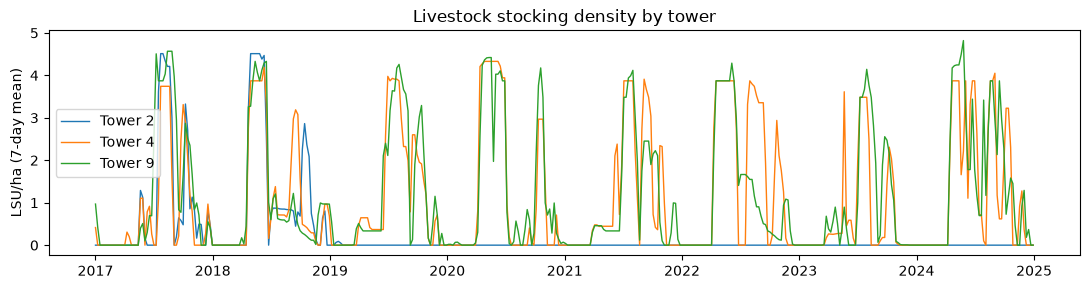

In [19]:
LSU = {"cattle": 1.0, "sheep": 0.1, "lamb": 0.05}

livestock_density = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    cat = CAT[t]
    lsu = sum(df_ext[f"{s}_{cat}"].fillna(0) * w for s, w in LSU.items())
    livestock_density[f"lsu_dens [Tower {t}]"] = lsu / AREA[t]
    livestock_density[f"graze [Tower {t}]"] = (sum(df_ext[f"{s}_{cat}"].fillna(0) for s in LSU) > 0).astype(float)
    print(f"Tower {t} ({cat}, {AREA[t]} ha): mean LSU/ha={livestock_density[f'lsu_dens [Tower {t}]'].mean():.3f}, "
          f"max={livestock_density[f'lsu_dens [Tower {t}]'].max():.3f}, "
          f"% hours grazed={100*livestock_density[f'graze [Tower {t}]'].mean():.1f}%")

fig, ax = plt.subplots(figsize=(11, 3))
for t in TOWERS:
    ax.plot(livestock_density[f"lsu_dens [Tower {t}]"].resample("7D").mean(), label=f"Tower {t}", lw=1)
ax.set_ylabel("LSU/ha (7-day mean)"); ax.set_title("Livestock stocking density by tower"); ax.legend()
plt.tight_layout(); plt.show()

### 3.4 Final feature frame assembly

Merges every imputed/engineered feature stream (`met_filled`, `fco2_gapfilled`, `mgmt`,
`gpp_reco`) onto the external-sourced base (`df_ext`), then builds a per-tower modelling frame `g`
with: target (FCH4, QC-filtered), the 11 gap-filled met drivers, `fc` (reconstructed FCO2),
cyclical time features, `lsu_dens`/`graze`, soil moisture/temperature lags (168/336/504/672h --
F-04, D-31), pruned management recency, `gpp`/`reco`, and (for the **pooled** model) tower dummies
`is_t2/is_t4/is_t9` -- the "partial pooling" architecture (F-03, D-30) that pools all 3 towers'
training rows while still letting the model tell them apart.

In [20]:
AUX = ["_hs", "_hc", "_ds", "_dc"]
LAG_HOURS = [168, 336, 504, 672]
DUM = ["is_t2", "is_t4", "is_t9"]

d_all = df_ext.join(met_filled).join(fco2_gapfilled).join(mgmt).join(gpp_reco)
for t in TOWERS:
    d_all[f"FC_1_1_1 [Tower {t}]"] = d_all[f"FC_gapfilled [Tower {t}]"]   # FC kept EC-sourced (section 2.1)
print(f"d_all shape: {d_all.shape}")


@timeit
def cfg(t):
    cat = CAT[t]
    met = [f"SWIN_1_1_1 [Tower {t}]", f"TA_0_0_1 [Tower {t}]", f"VPD_0_0_1 [Tower {t}]",
           f"PPFD_1_1_1 [Tower {t}]", f"RN_1_1_1 [Tower {t}]", f"WS_0_0_1 [Tower {t}]",
           f"USTAR_0_0_1 [Tower {t}]", f"SHF_1_1_1 [Tower {t}]",
           f"Precipitation (mm) [{cat}]", ts_col_for(t), f"Soil Moisture @ 10cm Depth (%) [{cat}]"]
    return dict(t=t, cat=cat, area=AREA[t], tgt=f"FCH4_1_1_1 [Tower {t}]",
                ssitc=f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]", met=met,
                fc=f"FC_1_1_1 [Tower {t}]", gpp=f"GPP [Tower {t}]", reco=f"Reco [Tower {t}]",
                swc=f"Soil Moisture @ 10cm Depth (%) [{cat}]", ts=ts_col_for(t),
                mc=f"mgmt_t{t}_cut_recency", mm=f"mgmt_t{t}_manure_recency")


@timeit
def feat_list():
    c = cfg(2)
    return ([m.split(" [")[0] for m in c["met"]] + ["fc"] + AUX + ["lsu_dens", "graze"]
            + [f"swc_l{l}" for l in LAG_HOURS] + [f"ts_l{l}" for l in LAG_HOURS]
            + ["mgmt_cut", "mgmt_manure", "gpp", "reco"])


@timeit
def frame(t, pooled, d):
    """Per-tower FCH4 gap-filling feature frame (target + all imputed/engineered features)."""
    c = cfg(t); d = d.copy(); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    h, doy = d.index.hour, d.index.dayofyear
    d["_hs"] = np.sin(2 * np.pi * h / 24); d["_hc"] = np.cos(2 * np.pi * h / 24)
    d["_ds"] = np.sin(2 * np.pi * doy / 365); d["_dc"] = np.cos(2 * np.pi * doy / 365)
    g = pd.DataFrame(index=d.index); g["target"] = d[tgt]
    for k in c["met"]:
        nm = k.split(" [")[0]
        g[nm] = d[k + "__f"] if (k + "__f") in d.columns else d[k]
    g["fc"] = d[c["fc"]]
    for a in AUX:
        g[a] = d[a]
    g["lsu_dens"] = livestock_density[f"lsu_dens [Tower {t}]"]
    g["graze"] = livestock_density[f"graze [Tower {t}]"]
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for lag in LAG_HOURS:
        g[f"swc_l{lag}"] = swc.shift(lag); g[f"ts_l{lag}"] = ts.shift(lag)
    g["mgmt_cut"] = d[c["mc"]]; g["mgmt_manure"] = d[c["mm"]]
    g["gpp"] = d[c["gpp"]]; g["reco"] = d[c["reco"]]
    if pooled:
        for tt in TOWERS:
            g[f"is_t{tt}"] = 1.0 if tt == t else 0.0
    g["_y"] = d.index.year
    return g


FEATURES = feat_list()
print(f"{len(FEATURES)} base features (+3 tower dummies when pooled): {FEATURES}")

g4_preview = frame(4, pooled=True, d=d_all)
print(f"\nTower 4 frame shape: {g4_preview.shape}, target valid: {g4_preview['target'].notna().sum():,}")
g4_preview[["target", "fc", "lsu_dens", "gpp", "reco", "is_t2", "is_t4", "is_t9"]].dropna(subset=["target"]).head()

d_all shape: (70153, 501)
30 base features (+3 tower dummies when pooled): ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)', 'fc', '_hs', '_hc', '_ds', '_dc', 'lsu_dens', 'graze', 'swc_l168', 'swc_l336', 'swc_l504', 'swc_l672', 'ts_l168', 'ts_l336', 'ts_l504', 'ts_l672', 'mgmt_cut', 'mgmt_manure', 'gpp', 'reco']

Tower 4 frame shape: (70153, 35), target valid: 19,469


,target,fc,lsu_dens,gpp,reco,is_t2,is_t4,is_t9
Datetime,,,,,,,,
2017-10-06 16:00:00,5.909675,-3.639656,3.283871,10.4378,6.7981,0.0,1.0,0.0
2017-10-06 20:00:00,7.442396,4.360241,3.283871,0.0000,4.8790,0.0,1.0,0.0
2017-10-06 21:00:00,5.488019,5.381502,3.283871,0.0000,5.4334,0.0,1.0,0.0
2017-10-06 22:00:00,7.009990,5.654010,3.283871,0.0000,5.8139,0.0,1.0,0.0
2017-10-06 23:00:00,2.485738,4.980767,3.283871,0.0000,6.0771,0.0,1.0,0.0


## 4. Gap-filling

This is the harness that produces the target result. As section 1.8 established, the correct way
to evaluate a *gap-filling* (interpolation) model is **not** a train-on-past/test-on-future split
-- it is to synthetically mask chunks of the tower's own real record and see how well the model
recovers them, using every other real observation (before *and* after each synthetic gap) as
training data. Built on the section 2.4 toolkit (`insert_calendar_gaps`, `SCENARIOS`, `N_REPS`,
`mets`, `med_metrics`).

**New here on top of that toolkit:**
- **`DOMAIN`**: each tower's own real analyser-live window (Tower 2 Oct 2017-Jun 2019, Tower 9 Feb
  2020 onward), not the full project span.
- **Models compared**: **MDS** (marginal distribution sampling -- the literature baseline),
  **RFm-solo** (this tower's own data only), **RFm-pooled** (partial pooling -- all 3 towers'
  training rows + tower dummies).
- **Metric**: median R2/RMSE/MAE/MBE across `N_REPS` repetitions, then median again across the 5
  gap-length scenarios for an overall number.

### 4.1 Model caching

Every Random Forest fit in this notebook goes through one shared `fit(feat, trd)` helper, wrapped
to cache each fitted (model, imputer) pair to disk, keyed by an MD5 hash of the exact feature list
+ training rows + target values + hyperparameters -- the key changes automatically if anything
upstream changes, so a stale cache can never silently get reused. Cache lives in `_model_cache/`
(gitignored, same treatment as `data/`); set `USE_CACHE = False` to force a clean re-fit.

In [ ]:
import hashlib
import joblib

CACHE_DIR = Path("_model_cache")
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = True   # set False to force a clean re-fit of everything, ignoring any cached models

RF_PARAMS = dict(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=42)

_LIVE_CACHE_KEYS = set()   # every key touched (hit or created) so far this kernel session --
                           # backs prune_stale_cache() below
_CACHE_HITS = [0]; _CACHE_MISSES = [0]


@timeit
def _cache_key(feat, trd):
    """MD5 of the exact feature list + training rows + target + RF hyperparameters -- changes
    automatically if any upstream code changes what would be fit, so a stale cache entry can
    never silently get reused for the wrong inputs."""
    h = hashlib.md5()
    h.update("|".join(feat).encode())
    h.update(np.ascontiguousarray(trd[feat].values).tobytes())
    h.update(np.ascontiguousarray(trd["target"].values).tobytes())
    h.update(str(sorted(RF_PARAMS.items())).encode())
    return h.hexdigest()


@timeit
def fit(feat, trd):
    """Fit (or load a cached) RandomForestRegressor + SimpleImputer for this exact
    (feature list, training rows) combination -- the one fitting function used everywhere
    in this notebook's gap-filling sections. Every key touched is recorded in
    _LIVE_CACHE_KEYS so prune_stale_cache() (this notebook's final cell) can safely delete any
    cached model a full top-to-bottom run never needed, instead of the cache accumulating
    orphaned entries from superseded experiments forever."""
    key = _cache_key(feat, trd)
    _LIVE_CACHE_KEYS.add(key)
    cache_path = CACHE_DIR / f"{key}.joblib"
    if USE_CACHE and cache_path.exists():
        _CACHE_HITS[0] += 1
        return joblib.load(cache_path)
    _CACHE_MISSES[0] += 1
    imp = SimpleImputer(strategy="mean")
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(imp.fit_transform(trd[feat].values), trd["target"].values)
    if USE_CACHE:
        joblib.dump((rf, imp), cache_path)
    return rf, imp


def prune_stale_cache():
    """Deletes any _model_cache/*.joblib file not touched (hit or created) by fit() so far this
    kernel session. SAFE ONLY after a genuine full top-to-bottom execution of this notebook --
    _LIVE_CACHE_KEYS must reflect every fit() call site, not a partial subset, or this will
    delete cache entries a partial run simply never happened to touch. That's exactly why this
    is wired in as the notebook's literal final cell, not a standalone utility invoked
    mid-session."""
    all_files = list(CACHE_DIR.glob("*.joblib"))
    stale = [f for f in all_files if f.stem not in _LIVE_CACHE_KEYS]
    freed_bytes = sum(f.stat().st_size for f in stale)
    for f in stale:
        f.unlink()
    print(f"Cache prune: {len(stale)}/{len(all_files)} stale entries removed, "
          f"{freed_bytes / 1e9:.2f} GB freed. {len(_LIVE_CACHE_KEYS)} live entries retained "
          f"({_CACHE_HITS[0]} hits, {_CACHE_MISSES[0]} fresh fits this run).")


n_cached = len(list(CACHE_DIR.glob("*.joblib")))
print(f"Model cache: {CACHE_DIR.resolve()}  (USE_CACHE={USE_CACHE}, {n_cached} cached model(s) found)")

### 4.2 Harness: DOMAIN, MDS baseline, RFm (solo/pooled)

In [22]:
DOMAIN = {2: ("2017-10-01", "2019-06-30"), 4: ("2017-10-01", "2023-12-31"), 9: ("2020-02-01", "2023-12-31")}


@timeit
def dom_mask(idx, t):
    a, b = DOMAIN[t]
    return (idx >= pd.Timestamp(a)) & (idx <= pd.Timestamp(b))


@timeit
def mds_fill_batch(df_obs, target, sw_col, ta_col, gap_ts, vpd_col=None):
    """Literature-correct marginal distribution sampling (Reichstein et al. 2005 / REddyProc /
    Zhu et al. 2023a Table 2's driver3=SW+TA+VPD), reconstructed and validated in temp_mds.ipynb
    against REddyProc's own R source (EddyGapfilling.R) after auditing this project's original
    implementation and finding 3 bugs: (1) an hour-of-day +/-1h restriction was wrongly applied to
    every case instead of only the final fallback: (2) an intermediate SW-only look-up case
    (Case 2) was missing entirely; (3) the fallback was a single fixed +/-7-day box with no
    meteorological constraint, not the real algorithm's expanding mean-diurnal-course window.
    Fixed to a 3-case hierarchy, each tried in order until a match is found:
    Case 1 (SW+TA+VPD look-up): +/-7d, then +/-14d; no hour restriction.
    Case 2 (SW-only look-up, day-gated SW>10): +/-7d stepping to +/-70d; no hour restriction.
    Case 3 (meteo-free mean diurnal course, fallback): +/-1h restriction; 0/1/2d, then +/-7d
    stepping to +/-210d.
    Same call signature as the prior implementation -- drop-in compatible with run_mds/
    run_mds_capture. See temp_mds.ipynb sections 3-8 and summary.md section 13.1/13.2 for the
    full bug audit and OLD-vs-NEW validation (R2 improved in every tower/scenario cell)."""
    SW_TOL, TA_TOL, VPD_TOL = 50.0, 2.5, 5.0
    CASE1_WINDOWS = [pd.Timedelta(days=d) for d in [7, 14]]
    CASE2_WINDOWS = [pd.Timedelta(days=d) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [pd.Timedelta(days=d) for d in [0, 1, 2]] + [pd.Timedelta(days=d) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    avpd = av[vpd_col].values.astype(float) if vpd_col is not None else None

    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    gvpd = df_obs.reindex(gi)[vpd_col].values.astype(float) if vpd_col is not None else None

    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = gsw[i]; tv = gta[i]; vv = gvpd[i] if gvpd is not None else np.nan
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False

        if not np.isnan(sv) and not np.isnan(tv) and (avpd is None or not np.isnan(vv)):
            for wd in CASE1_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
                if avpd is not None:
                    m &= (np.abs(avpd - vv) <= VPD_TOL) | np.isnan(avpd)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled and day and not np.isnan(sv):
            for wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break
    return preds


print("FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).")

FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).


In [23]:
@timeit
def run_mds(t):
    """MDS baseline gap-CV for tower t -- literature-correct 3-case hierarchy (Reichstein 2005 /
    REddyProc / Zhu et al. 2023a Table 2's driver3 = SW, TA, VPD); see mds_fill_batch's docstring
    for the full Case 1/2/3 description."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    swin_col = f"SWIN_1_1_1 [Tower {t}]"; ta_col = f"TA_0_0_1 [Tower {t}]"; vpd_col = f"VPD_0_0_1 [Tower {t}]"
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = mds_fill_batch(d, tgt, swin_col, ta_col, list(gt), vpd_col=vpd_col); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_rf(t, pooled):
    """RFm (solo or partial-pooled) gap-CV for tower t."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_mds / run_rf defined.")

run_mds / run_rf defined.


### 4.3 Run the full grid

3 towers x {MDS, RFm-solo, RFm-pooled} x 5 gap-length scenarios x `N_REPS` repetitions = 60
separate 500-tree Random Forest fits (plus MDS's windowed-averaging passes). First run populates
`_model_cache/` from scratch (~10-15 min); subsequent runs against the same data are cache hits.

In [24]:
import time
t_start = time.time()

RESU = {}
for t in TOWERS:
    RESU[(t, "MDS")] = run_mds(t)
    print(f"done MDS       Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_solo")] = run_rf(t, pooled=False)
    print(f"done RFm_solo  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_pool")] = run_rf(t, pooled=True)
    print(f"done RFm_pool  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)

print(f"\nALL DONE in {time.time()-t_start:.0f}s")

done MDS       Tower 2  (     1s elapsed)


done RFm_solo  Tower 2  (     3s elapsed)


done RFm_pool  Tower 2  (     6s elapsed)


done MDS       Tower 4  (    11s elapsed)


done RFm_solo  Tower 4  (    13s elapsed)


done RFm_pool  Tower 4  (    17s elapsed)


done MDS       Tower 9  (    19s elapsed)


done RFm_solo  Tower 9  (    21s elapsed)


done RFm_pool  Tower 9  (    25s elapsed)



ALL DONE in 25s


### 4.3.0 Reference baseline: MDS + RFm (met variables only)

The most minimal floor in this notebook -- no livestock, no lags, no management recency, no
GPP/Reco, not even the diurnal/seasonal `_hs`/`_hc`/`_ds`/`_dc` encoding used everywhere else --
just the 11 raw meteorological/micrometeorological drivers (`cfg(t)["met"]`). Exists to show how
much of the champion's R^2 is coming from engineered features (livestock, lags, etc.) versus raw
weather alone. **MDS is not rerun here** -- it's already the literature baseline in section 4.3's
own grid: the literature-correct Reichstein et al. (2005)/REddyProc 3-case hierarchy (Case 1
SW+TA+VPD look-up, Case 2 SW-only look-up, Case 3 meteo-free mean diurnal course), matching Zhu
et al. (2023a) Table 2's `driver3` -- see `mds_fill_batch`'s docstring, `RESU[(t, "MDS")]`),
pulled directly. Also now reports `R2_OLS`/`OLS_slope` (squared Pearson r from an OLS fit of
measured-vs-filled, Zhu et al.'s own metric convention, p.6) alongside this project's standing
`R2` (sklearn, unbounded below) -- see `mets`'s docstring; the two diverge most for MDS.
**RFm (met-only) is new** -- same partial-pooled architecture as the champion, restricted to the
11 met columns only.

In [25]:
MET_ONLY_COLS = [m.split(" [")[0] for m in cfg(2)["met"]]
FEAT_MET_ONLY = MET_ONLY_COLS
print(f"FEAT_MET_ONLY: {len(FEAT_MET_ONLY)} raw met/micromet drivers only (no AUX diurnal/seasonal "
      f"encoding, no livestock, no lags, no mgmt, no gpp/reco): {FEAT_MET_ONLY}")


@timeit
def frame_met_only(t, pooled, d):
    """frame() restricted to only the raw met() columns -- no AUX/livestock/lags/mgmt/gpp/reco.
    Deliberately the most minimal, least-engineered baseline in this notebook."""
    g = frame(t, pooled, d)
    keep = ["target"] + FEAT_MET_ONLY + (DUM if pooled else [])
    return g[keep]


@timeit
def run_rf_met_only(t, pooled):
    """run_rf (section 4.2), generalized to frame_met_only + FEAT_MET_ONLY -- otherwise identical
    zero-leakage static-feature harness."""
    feat = FEAT_MET_ONLY + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_met_only(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_met_only / run_rf_met_only defined.")

FEAT_MET_ONLY: 11 raw met/micromet drivers only (no AUX diurnal/seasonal encoding, no livestock, no lags, no mgmt, no gpp/reco): ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)']
frame_met_only / run_rf_met_only defined.


In [26]:
t0 = time.time()
RESU_MET_ONLY = {}
for t in TOWERS:
    RESU_MET_ONLY[t] = run_rf_met_only(t, pooled=True)
    print(f"done metOnly  Tower {t}  ({time.time()-t0:6.0f}s elapsed)", flush=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")

done metOnly  Tower 2  (     4s elapsed)


done metOnly  Tower 4  (     7s elapsed)


done metOnly  Tower 9  (    10s elapsed)



ALL DONE in 10s


Extending this floor with two more standard, model-agnostic imputation baselines that
appear in essentially every gap-filling benchmark -- neither is RF/TabICL-specific (unlike the
champion/D1-D4) or EC-flux-specific (unlike MDS):

- **Mean** -- the simplest possible baseline: fill every held-out point with that fold's own
  training-set mean (per tower, per rep). No model, no features.
- **MICE** (Multiple Imputation by Chained Equations) -- `sklearn.impute.IterativeImputer`
  (default per-column estimator `BayesianRidge`), on the champion's own `FEATURES` + target,
  jointly imputed. Mask this fold's held-out target values to NaN first (mirrors D3/D4's
  leakage-safe "mask first, derive second" pattern), run `fit_transform` once (single imputation
  -- standard practice for point-prediction accuracy benchmarking, as opposed to "multiple"
  imputation + Rubin's-rules pooling, which is for statistical inference/variance estimation, not
  relevant here), then read the target column's imputed values back out at exactly the held-out
  row positions.
- **HyperImpute** ([van der Schaar lab](https://github.com/vanderschaarlab/hyperimpute)) -- same
  chained-equations/round-robin structure as MICE, but at each iteration it runs a per-column
  AutoML search (`optimizer="simple"` default) over a pool of regressor/classifier models (linear,
  RF, XGBoost, LightGBM, CatBoost, etc.) and picks whichever fits that column's observed values
  best via internal CV, instead of MICE's one-fixed-model-for-every-column (`BayesianRidge`). Same
  champion `FEATURES` + target, same leakage-safe masking, same positional-indexing pattern as
  `run_mice` (HyperImpute's `fit_transform` takes/returns a DataFrame directly, no `.values`
  round-trip needed). Columns with <=5 unique values (`is_t2`/`is_t4`/`is_t9`, `graze`) are
  auto-treated as classification targets -- a real, expected difference from MICE, not a bug.
  Substantially heavier per-fold (~4-5 min vs. MICE's single-digit seconds, dominated by the
  per-column AutoML search itself, not matrix size -- confirmed via synthetic benchmarking before
  committing to the full run) -- run at full standing 3-tower x 5-scenario x 2-rep coverage
  anyway, in the background, per explicit confirmation.

In [27]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from hyperimpute.plugins.imputers import Imputers


@timeit
def run_mean(t):
    """Simplest possible baseline: fill every held-out point with that fold's own training-set
    mean (per tower, per rep) -- the standard 'trivial' floor."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            train_mean = d.loc[dm & d[tgt].notna() & ~d.index.isin(gt_ts), tgt].mean()
            yp = np.full(len(gt), train_mean)
            rr.append(mets(d.loc[gt, tgt].values, yp))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_mice(t, pooled):
    """MICE (sklearn IterativeImputer, default BayesianRidge) on the champion's own FEATURES +
    target, jointly imputed. Mask this fold's held-out target values to NaN first (mirrors
    D3/D4's leakage-safe pattern), then fit_transform once, then read back the target column's
    imputed values at exactly the held-out row positions -- via POSITIONAL indexing, not label
    (.loc), since pooling stacks 3 towers that all share the same underlying hourly Datetime
    index: a label-based lookup on the concatenated frame would match every tower's row at that
    timestamp, not just tower t's own row (confirmed empirically: a naive .loc[gt_ts] returned
    ~2x too many rows for a 3-tower pool)."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            parts = []; t_positions = None; t_part_i = None
            for i, tt in enumerate(towers):
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                sub = gg.loc[dmt, ["target"] + feat].copy()
                if tt == t:
                    t_part_i = i
                    t_positions = sub.index.get_indexer(gt_ts)
                    sub.iloc[t_positions, sub.columns.get_loc("target")] = np.nan
                parts.append(sub.reset_index(drop=True))
            offset = sum(len(parts[i]) for i in range(t_part_i))
            abs_positions = offset + t_positions
            mat = pd.concat(parts, ignore_index=True) if pooled else parts[0]
            imputer = IterativeImputer(random_state=42)
            filled = imputer.fit_transform(mat.values)
            target_col = mat.columns.get_loc("target")
            yp = filled[abs_positions, target_col]
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_hyperimpute(t, pooled):
    """HyperImpute (van der Schaar lab) on the champion's own FEATURES + target, jointly imputed.
    Same chained-equations structure as run_mice, but each column's imputation model is chosen by
    an internal per-iteration AutoML search over a regressor/classifier pool (vs. MICE's single
    fixed BayesianRidge) -- columns with <=5 unique values (is_t2/is_t4/is_t9 dummies, graze) are
    auto-treated as classification targets. Same leakage-safe mask-first pattern and positional-
    indexing fix as run_mice (see its docstring) -- HyperImpute's fit_transform takes/returns a
    DataFrame directly (no .values round-trip needed)."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            parts = []; t_positions = None; t_part_i = None
            for i, tt in enumerate(towers):
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                sub = gg.loc[dmt, ["target"] + feat].copy()
                if tt == t:
                    t_part_i = i
                    t_positions = sub.index.get_indexer(gt_ts)
                    sub.iloc[t_positions, sub.columns.get_loc("target")] = np.nan
                parts.append(sub.reset_index(drop=True))
            offset = sum(len(parts[i]) for i in range(t_part_i))
            abs_positions = offset + t_positions
            mat = pd.concat(parts, ignore_index=True) if pooled else parts[0]
            plugin = Imputers().get("hyperimpute", random_state=42)
            filled_df = plugin.fit_transform(mat)
            yp = filled_df.iloc[abs_positions][filled_df.columns[filled_df.columns.get_loc("target")]].values
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_mean / run_mice / run_hyperimpute defined.")

run_mean / run_mice / run_hyperimpute defined.


In [28]:
t0 = time.time()
_smoke_mice = run_mice(4, pooled=True)
_smoke_r2 = np.nanmedian([_smoke_mice[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, MICE): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, MICE): R2=0.118  [192s elapsed]


In [29]:
t0 = time.time()
RESU_MEAN = {}
for t in TOWERS:
    RESU_MEAN[t] = run_mean(t)
    print(f"done Mean  Tower {t}  ({time.time()-t0:6.0f}s elapsed)", flush=True)
print(f"ALL DONE (Mean) in {time.time()-t0:.0f}s")

done Mean  Tower 2  (     0s elapsed)


done Mean  Tower 4  (     1s elapsed)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\3382377119.py:54: RuntimeWarning: All-NaN slice encountered
  "R2_OLS": np.nanmedian(a[:, 4]), "OLS_slope": np.nanmedian(a[:, 5])}


done Mean  Tower 9  (     1s elapsed)


ALL DONE (Mean) in 1s


In [30]:
RESU_MICE = {4: _smoke_mice}
t0 = time.time()
RESU_MICE[2] = run_mice(2, pooled=True)
print(f"done MICE  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)
RESU_MICE[9] = run_mice(9, pooled=True)
print(f"done MICE  Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)
print(f"ALL DONE (MICE) in {time.time()-t0:.0f}s")

done MICE  Tower 2  (   184s elapsed)


done MICE  Tower 9  (   359s elapsed)


ALL DONE (MICE) in 359s


In [31]:
t0 = time.time()
_smoke_hyperimpute = run_hyperimpute(4, pooled=True)
_smoke_hi_r2 = np.nanmedian([_smoke_hyperimpute[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, HyperImpute): R2={_smoke_hi_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, HyperImpute): R2=0.336  [1819s elapsed]


In [32]:
RESU_HYPERIMPUTE = {4: _smoke_hyperimpute}
t0 = time.time()
RESU_HYPERIMPUTE[2] = run_hyperimpute(2, pooled=True)
print(f"done HyperImpute  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)
RESU_HYPERIMPUTE[9] = run_hyperimpute(9, pooled=True)
print(f"done HyperImpute  Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)
print(f"ALL DONE (HyperImpute) in {time.time()-t0:.0f}s")

done HyperImpute  Tower 2  (  1659s elapsed)


done HyperImpute  Tower 9  (  3217s elapsed)


ALL DONE (HyperImpute) in 3217s


In [33]:
from pathlib import Path
DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)

rows = []
for t in TOWERS:
    mds_scn = RESU[(t, "MDS")]
    ov_mds = {k: np.nanmedian([mds_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": "MDS (3-driver, SW_IN+TA+VPD)",
                 **{f"{k}_overall": round(ov_mds[k], 3) for k in ov_mds}})

    met_scn = RESU_MET_ONLY[t]
    ov_met = {k: np.nanmedian([met_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": f"RFm_pool_metOnly ({len(FEAT_MET_ONLY)} feat)",
                 **{f"{k}_overall": round(ov_met[k], 3) for k in ov_met}})

    champ_scn = RESU[(t, "RFm_pool")]
    ov_champ = {k: np.nanmedian([champ_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": "RFm_pool champion (30 feat, reference)",
                 **{f"{k}_overall": round(ov_champ[k], 3) for k in ov_champ}})

    mean_scn = RESU_MEAN[t]
    ov_mean = {k: np.nanmedian([mean_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": "Mean (training-set constant)",
                 **{f"{k}_overall": round(ov_mean[k], 3) for k in ov_mean}})

    mice_scn = RESU_MICE[t]
    ov_mice = {k: np.nanmedian([mice_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": "MICE (IterativeImputer, champion FEATURES)",
                 **{f"{k}_overall": round(ov_mice[k], 3) for k in ov_mice}})

    hi_scn = RESU_HYPERIMPUTE[t]
    ov_hi = {k: np.nanmedian([hi_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
    rows.append({"tower": t, "model": "HyperImpute (AutoML per-column, champion FEATURES)",
                 **{f"{k}_overall": round(ov_hi[k], 3) for k in ov_hi}})

R_MET_ONLY = pd.DataFrame(rows)
print(R_MET_ONLY.to_string(index=False))

R_MET_ONLY.to_csv(DATA_DIR / "reference_baseline_met_only.csv", index=False)
print(f"\nSaved {DATA_DIR/'reference_baseline_met_only.csv'}")
R_MET_ONLY

 tower                                              model  R2_overall  RMSE_overall  MAE_overall  MBE_overall  R2_OLS_overall  OLS_slope_overall
     2                       MDS (3-driver, SW_IN+TA+VPD)      -0.023       142.991       45.114       -1.228           0.072              0.118
     2                         RFm_pool_metOnly (11 feat)       0.052       135.844       43.124        2.075           0.054              0.070
     2             RFm_pool champion (30 feat, reference)       0.576        75.045       31.226        2.791           0.601              0.582
     2                       Mean (training-set constant)      -0.003       139.519       46.770        0.844           0.000              0.000
     2         MICE (IterativeImputer, champion FEATURES)       0.081       132.640       59.625        1.558           0.104              0.145
     2 HyperImpute (AutoML per-column, champion FEATURES)       0.509        93.909       36.983        1.945           0.567     

,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_OLS_overall,OLS_slope_overall
0,2,"MDS (3-driver, SW_IN+TA+VPD)",-0.023,142.991,45.114,-1.228,0.072,0.118
1,2,RFm_pool_metOnly (11 feat),0.052,135.844,43.124,2.075,0.054,0.070
2,2,"RFm_pool champion (30 feat, reference)",0.576,75.045,31.226,2.791,0.601,0.582
3,2,Mean (training-set constant),-0.003,139.519,46.770,0.844,0.000,0.000
4,2,"MICE (IterativeImputer, champion FEATURES)",0.081,132.640,59.625,1.558,0.104,0.145
5,2,"HyperImpute (AutoML per-column, champion FEATU...",0.509,93.909,36.983,1.945,0.567,0.617
6,4,"MDS (3-driver, SW_IN+TA+VPD)",-0.113,134.744,52.660,0.636,0.038,0.136
7,4,RFm_pool_metOnly (11 feat),0.036,119.461,50.394,2.666,0.042,0.065
8,4,"RFm_pool champion (30 feat, reference)",0.404,100.275,42.796,3.692,0.409,0.389
9,4,Mean (training-set constant),-0.001,125.622,50.730,1.981,0.000,0.000


### 4.3.a Species-disaggregated livestock density (cattle_dens/sheep_dens/lamb_dens vs. lsu_dens)

`lsu_dens` (section 3.3) folds cattle/sheep/lamb into one LSU-weighted density (cattle=1.0,
sheep=0.1, lamb=0.05). This has never been cleanly tested for gap-filling: F-02 (D-29, the
notebook that established `lsu_dens`) only tested per-species columns **bundled together with**
`lsu_dens` in a single leave-one-group-in block on Towers 4/9 solo -- never as a standalone swap,
and never in the pooled architecture `RFm_pool` actually uses. A clean swap **was** tested for
forecasting (F-10/D-67: replace `fx_lsu_dens` with the 3-way split) and came back tower-specific
and net-null (T4 +0.008/+0.019 R² at h=1/h=14, T9 -0.013/-0.021; mean ~-0.002, no promotion).

This redoes that clean swap for gap-filing specifically: `lsu_dens` replaced by raw per-species
density (head/ha, unweighted -- matching F-10's `fx_cattle_dens`/`fx_sheep_dens`/`fx_lamb_dens`
definition), `graze` left untouched, full 3-tower `RFm_pool` gap-CV. **Purely additive** -- `FEATURES`,
`frame()`, and the champion grid above are untouched; this is a new, separately-labeled comparison
arm, same pattern as section 7's `prunedCov`/`prunedFull`.

In [34]:
species_density = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    cat = CAT[t]
    for s in LSU:   # {"cattle", "sheep", "lamb"} -- same species set as section 3.3's LSU weights
        species_density[f"{s}_dens [Tower {t}]"] = df_ext[f"{s}_{cat}"].fillna(0) / AREA[t]
    print(f"Tower {t}: mean cattle/ha={species_density[f'cattle_dens [Tower {t}]'].mean():.3f}, "
          f"sheep/ha={species_density[f'sheep_dens [Tower {t}]'].mean():.3f}, "
          f"lamb/ha={species_density[f'lamb_dens [Tower {t}]'].mean():.3f}")


@timeit
def frame_species_dens(t, pooled, d):
    """frame() with lsu_dens replaced by raw per-species density (F-10's fx_cattle_dens/
    fx_sheep_dens/fx_lamb_dens definition) -- graze is left untouched."""
    g = frame(t, pooled, d).drop(columns=["lsu_dens"])
    for s in LSU:
        g[f"{s}_dens"] = species_density[f"{s}_dens [Tower {t}]"]
    return g


FEAT_SPECIES_DENS = [f for f in FEATURES if f != "lsu_dens"] + ["cattle_dens", "sheep_dens", "lamb_dens"]
print(f"\nbaseline: {len(FEATURES)} feats (incl. lsu_dens) | species_dens: {len(FEAT_SPECIES_DENS)} feats "
      f"(lsu_dens -> cattle_dens/sheep_dens/lamb_dens)")


@timeit
def run_rf_species_dens(t, pooled):
    """run_rf (section 4.2), generalized to frame_species_dens + FEAT_SPECIES_DENS -- same
    zero-leakage static-feature pattern as run_rf_pruned_cov (section 7)."""
    feat = FEAT_SPECIES_DENS + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_species_dens(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_species_dens / run_rf_species_dens defined.")

Tower 2: mean cattle/ha=0.193, sheep/ha=0.175, lamb/ha=0.832
Tower 4: mean cattle/ha=0.981, sheep/ha=0.589, lamb/ha=1.613
Tower 9: mean cattle/ha=0.857, sheep/ha=1.866, lamb/ha=2.371

baseline: 30 feats (incl. lsu_dens) | species_dens: 32 feats (lsu_dens -> cattle_dens/sheep_dens/lamb_dens)
frame_species_dens / run_rf_species_dens defined.


In [35]:
t0 = time.time()
RESU_SPECIES_DENS = {}
for t in TOWERS:
    RESU_SPECIES_DENS[t] = run_rf_species_dens(t, pooled=True)
    print(f"done species_dens  Tower {t}  ({time.time()-t0:6.0f}s elapsed)", flush=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")

done species_dens  Tower 2  (     4s elapsed)


done species_dens  Tower 4  (   149s elapsed)


done species_dens  Tower 9  (   531s elapsed)



ALL DONE in 531s


In [36]:
rows = []
for t in TOWERS:
    scn = RESU_SPECIES_DENS[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "RFm_pool_speciesDens",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov},
                 **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R_SPECIES_DENS = pd.DataFrame(rows)

CHAMPION_R2_43A = {t: round(float(np.nanmedian([RESU[(t, "RFm_pool")][s]["R2"] for s in SCENARIOS])), 3) for t in TOWERS}
R_SPECIES_DENS["champion_R2"] = R_SPECIES_DENS["tower"].map(CHAMPION_R2_43A)
R_SPECIES_DENS["delta_R2"] = (R_SPECIES_DENS["R2_overall"] - R_SPECIES_DENS["champion_R2"]).round(3)

print(R_SPECIES_DENS[["tower", "model", "R2_overall", "champion_R2", "delta_R2"]].to_string(index=False))

DATA_DIR = Path("_data")   # first use in execution order; section 4.8 redefines the same path later
DATA_DIR.mkdir(exist_ok=True)
R_SPECIES_DENS.to_csv(DATA_DIR / "species_density_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'species_density_results.csv'}")
R_SPECIES_DENS

 tower                model  R2_overall  champion_R2  delta_R2
     2 RFm_pool_speciesDens       0.593        0.576     0.017
     4 RFm_pool_speciesDens       0.404        0.404     0.000
     9 RFm_pool_speciesDens       0.428        0.426     0.002

Saved _data\species_density_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_vs,R2_s,R2_m,R2_l,R2_m1,champion_R2,delta_R2
0,2,RFm_pool_speciesDens,0.593,74.536,31.619,2.160,0.593,0.739,0.725,0.168,0.504,0.576,0.017
1,4,RFm_pool_speciesDens,0.404,99.536,42.821,3.686,0.431,0.427,0.404,0.279,0.323,0.404,0.000
2,9,RFm_pool_speciesDens,0.428,106.610,49.141,1.014,0.463,0.373,0.430,0.244,0.428,0.426,0.002


### 4.3.b Temporal-memory feature rework (soil / livestock / target lags)

Adapts a 5-part lag/temporal-memory rework proposed by a code review written against a different,
larger notebook (`temp_gap_filing_revisited_opus.ipynb`) into this notebook's own conventions --
reusing `frame`/`fit`/`SCENARIOS`/the gap-CV toolkit and the `frame_species_dens`/`run_rf_species_dens`
clone-and-swap pattern (4.3.a) unmodified, not the other notebook's `run_rf_cfg`/`record_arm` harness,
which doesn't exist here.

**D1 (soil)**: the champion's `swc_l{h}`/`ts_l{h}` lags use a never-derived, uniform
`LAG_HOURS=[168,336,504,672]` grid. Section 6's own ACF/PACF/AIC-BIC analysis later in this notebook
derives a different, real, per-tower-informed set (quoted below as already-known constants, since
section 6 runs after this point in the notebook) -- D1 tests a column-neutral swap to point-lags at
those derived hours plus a rolling mean.

**D2 (livestock)**: `lsu_dens` is this project's strongest FCH4 driver (F-01/D-27) but has zero memory
in the champion. Builds on 4.3.a's species-separated density (`cattle_dens`/`sheep_dens`/`lamb_dens`,
per explicit instruction -- keep them separated, not collapsed back to `lsu_dens`), adding rolling
means per species plus one shared `hours_since_graze_change`.

**D3 (target)**: section 7's `prunedFull` arm (fixed-horizon `target_lag`/`target_lead`, leakage-safe
but no training augmentation) regressed hard at every tower. Diagnosed mechanism: training rows are
almost-always-observed (nearest real neighbour ~1h away), but query rows sit inside real gaps (nearest
neighbour can be far away) -- the forest over-trusts a fixed-horizon feature from training, then meets
query rows where it's stale/imputed. D3 tests nearest-observation features (`y_prev`/`y_next`/`h_prev`/
`h_next`/`y_lin`/`gap_width`/`has_prev`/`has_next`) **plus training-set augmentation** (extra synthetic
masking applied only to training rows, so their neighbour-distance distribution resembles query rows'),
run as two arms specifically to test whether augmentation is what fixes the failure mode.

**Cost, stated plainly**: D1 (3 tower-runs) + D2 (3) + D3x2 arms (6) = 12 fresh pooled tower-runs, each
a full 5-scenario x `N_REPS=2` loop. At today's observed cost per fresh pooled arm (~450-700s), this is
realistically 1.5-2+ hours. Every arm is checkpointed per-tower, matching section 7's established
pattern, so a slow run is not a lost run.

#### 4.3.b.1 Lightweight horizon diagnostics

Cheap, no RF fits, self-contained (only needs `frame`/`cfg`/`dom_mask`/`species_density`/
`livestock_density`, all already defined -- does not depend on section 6, which runs later). D1's soil
lag hours are quoted directly from section 6's already-computed, stable `FINAL_LAGLEAD` result (not
recomputed here). `MAX_NEIGHBOUR_H` (for D3) and `LIVESTOCK_ROLL_WINDOW` (for D2) are derived from
coarse, self-contained autocorrelation checks -- pandas `.corr()` at a handful of candidate lags, not
section 6's full statsmodels ACF/PACF/AIC-BIC pipeline, which is unnecessary here since only a rough
horizon estimate is needed.

In [37]:
# Quoted from section 6's FINAL_LAGLEAD (computed later in this notebook's execution order, but
# already known and stable from that section's own derivation -- see section 6.5). Hardcoded as
# literal constants here (not referenced live) since section 6 runs after section 4.
FINAL_LAGLEAD_SOIL = {
    "swc_lag": [2, 12, 500], "swc_lead": [151, 520, 660],
    "ts_lag": [16, 72], "ts_lead": [200, 557, 630],
}
print("FINAL_LAGLEAD_SOIL (quoted from section 6):", FINAL_LAGLEAD_SOIL)

FINAL_LAGLEAD_SOIL (quoted from section 6): {'swc_lag': [2, 12, 500], 'swc_lead': [151, 520, 660], 'ts_lag': [16, 72], 'ts_lead': [200, 557, 630]}


In [38]:
@timeit
def coarse_autocorr(y_series, dm, candidate_lags):
    """Lightweight, self-contained autocorrelation check (pandas .corr(), pairwise-complete) --
    NOT section 6's full statsmodels ACF/PACF/missing='conservative' pipeline. Sufficient here
    since only a coarse horizon estimate is needed, not a formal order-selection result."""
    y = y_series[dm]
    n_eff = y.notna().sum()
    corrs = {h: y.corr(y.shift(h)) for h in candidate_lags}
    return corrs, int(n_eff)


def first_below(corrs, band):
    for h, c in corrs.items():
        if pd.notna(c) and abs(c) < band:
            return h
    return max(corrs.keys())


TARGET_LAG_CANDIDATES = [1, 2, 3, 6, 12, 24, 48, 72]
target_autocorr = {}
for t in TOWERS:
    g = frame(t, pooled=False, d=d_all)
    dm = dom_mask(g.index, t)
    corrs, n_eff = coarse_autocorr(g["target"], dm, TARGET_LAG_CANDIDATES)
    target_autocorr[t] = corrs
    print(f"Tower {t} target (n_eff={n_eff:,}): " + ", ".join(f"h={h}:{c:+.3f}" for h, c in corrs.items()))

max_h_per_tower = {t: first_below(target_autocorr[t], 0.10) for t in TOWERS}
MAX_NEIGHBOUR_H = int(np.clip(np.median(list(max_h_per_tower.values())), 6, 72))
print(f"\nPer-tower h where |autocorr| < 0.10: {max_h_per_tower}")
print(f"MAX_NEIGHBOUR_H (median, clamped [6,72]) = {MAX_NEIGHBOUR_H}")

Tower 2 target (n_eff=4,890): h=1:+0.392, h=2:+0.218, h=3:+0.183, h=6:+0.113, h=12:+0.013, h=24:+0.130, h=48:+0.066, h=72:+0.059
Tower 4 target (n_eff=19,465): h=1:+0.489, h=2:+0.307, h=3:+0.184, h=6:+0.129, h=12:+0.120, h=24:+0.188, h=48:+0.181, h=72:+0.110


Tower 9 target (n_eff=11,231): h=1:+0.497, h=2:+0.307, h=3:+0.210, h=6:+0.147, h=12:+0.029, h=24:+0.188, h=48:+0.165, h=72:+0.129

Per-tower h where |autocorr| < 0.10: {2: 12, 4: 72, 9: 12}
MAX_NEIGHBOUR_H (median, clamped [6,72]) = 12


In [39]:
LIVESTOCK_LAG_CANDIDATES = [24, 48, 72, 168, 336, 672]
livestock_autocorr = {}
for t in TOWERS:
    dm = dom_mask(livestock_density.index, t)
    graze = livestock_density[f"graze [Tower {t}]"]
    corrs, n_eff = coarse_autocorr(graze, dm, LIVESTOCK_LAG_CANDIDATES)
    livestock_autocorr[t] = corrs
    print(f"Tower {t} graze (n={n_eff:,}): " + ", ".join(f"h={h}:{c:+.3f}" for h, c in corrs.items()))


def last_above(corrs, band):
    kept = [h for h, c in corrs.items() if pd.notna(c) and abs(c) >= band]
    return max(kept) if kept else min(corrs.keys())


roll_h_per_tower = {t: last_above(livestock_autocorr[t], 0.30) for t in TOWERS}
LIVESTOCK_ROLL_WINDOW = int(np.clip(np.median(list(roll_h_per_tower.values())), 24, 336))
print(f"\nPer-tower h where |autocorr| stays >=0.30: {roll_h_per_tower}")
print(f"LIVESTOCK_ROLL_WINDOW (median, clamped [24,336]) = {LIVESTOCK_ROLL_WINDOW}")

Tower 2 graze (n=15,289): h=24:+0.939, h=48:+0.891, h=72:+0.843, h=168:+0.686, h=336:+0.536, h=672:+0.490
Tower 4 graze (n=54,769): h=24:+0.960, h=48:+0.926, h=72:+0.892, h=168:+0.763, h=336:+0.588, h=672:+0.365
Tower 9 graze (n=34,297): h=24:+0.942, h=48:+0.890, h=72:+0.841, h=168:+0.680, h=336:+0.450, h=672:+0.360

Per-tower h where |autocorr| stays >=0.30: {2: 672, 4: 672, 9: 672}
LIVESTOCK_ROLL_WINDOW (median, clamped [24,336]) = 336


#### 4.3.b.2 D1 -- soil family (column-neutral log-spaced-lag + rolling-mean swap)

Replaces `FEATURES`' 8 uniform `swc_l{h}`/`ts_l{h}` columns 1:1 with point-lags at `FINAL_LAGLEAD_SOIL`'s
derived hours plus a causal rolling mean (`.shift(1)` before `.rolling()`, so the window excludes the
current hour, which is already a separate `FEATURES` column). Column count held at 8 -- isolates
whether the *spacing* itself was the problem, independent of any other change. Zero leakage risk
(static shifts of already-gap-filled covariates).

In [40]:
SOIL_ROLL_WINDOWS = {"swc": [168], "ts": [24, 168]}


@timeit
def frame_lagmem_soil(t, pooled, d):
    """frame() with the 8 uniform-weekly swc_l{h}/ts_l{h} columns replaced 1:1 by derived
    point lags (FINAL_LAGLEAD_SOIL) + causal rolling means."""
    c = cfg(t)
    drop_cols = [f"swc_l{h}" for h in LAG_HOURS] + [f"ts_l{h}" for h in LAG_HOURS]
    g = frame(t, pooled, d).drop(columns=drop_cols)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for h in FINAL_LAGLEAD_SOIL["swc_lag"]:
        g[f"swc_lagD{h}"] = swc.shift(h)
    for w in SOIL_ROLL_WINDOWS["swc"]:
        g[f"swc_rollD{w}"] = swc.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
    for h in FINAL_LAGLEAD_SOIL["ts_lag"]:
        g[f"ts_lagD{h}"] = ts.shift(h)
    for w in SOIL_ROLL_WINDOWS["ts"]:
        g[f"ts_rollD{w}"] = ts.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
    return g


FEAT_LAGMEM_SOIL = ([f for f in FEATURES if f not in
                      [f"swc_l{h}" for h in LAG_HOURS] + [f"ts_l{h}" for h in LAG_HOURS]]
                     + [f"swc_lagD{h}" for h in FINAL_LAGLEAD_SOIL["swc_lag"]]
                     + [f"swc_rollD{w}" for w in SOIL_ROLL_WINDOWS["swc"]]
                     + [f"ts_lagD{h}" for h in FINAL_LAGLEAD_SOIL["ts_lag"]]
                     + [f"ts_rollD{w}" for w in SOIL_ROLL_WINDOWS["ts"]])
assert len(FEAT_LAGMEM_SOIL) == len(FEATURES), \
    f"D1 must be column-neutral: {len(FEAT_LAGMEM_SOIL)} vs {len(FEATURES)}"
print(f"FEAT_LAGMEM_SOIL: {len(FEAT_LAGMEM_SOIL)} features (column-neutral vs FEATURES)")


@timeit
def run_rf_lagmem_soil(t, pooled):
    """run_rf (section 4.2), generalized to frame_lagmem_soil + FEAT_LAGMEM_SOIL -- same
    zero-leakage static-feature pattern as run_rf_species_dens (section 4.3.a)."""
    feat = FEAT_LAGMEM_SOIL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_lagmem_soil(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_lagmem_soil / run_rf_lagmem_soil defined.")

FEAT_LAGMEM_SOIL: 30 features (column-neutral vs FEATURES)
frame_lagmem_soil / run_rf_lagmem_soil defined.


In [41]:
t0 = time.time()
RESU_LAGMEM_SOIL = {}

In [42]:
RESU_LAGMEM_SOIL[2] = run_rf_lagmem_soil(2, pooled=True)
print(f"done lagmemSoil  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done lagmemSoil  Tower 2  (   398s elapsed)


In [43]:
RESU_LAGMEM_SOIL[4] = run_rf_lagmem_soil(4, pooled=True)
print(f"done lagmemSoil  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done lagmemSoil  Tower 4  (   765s elapsed)


In [44]:
RESU_LAGMEM_SOIL[9] = run_rf_lagmem_soil(9, pooled=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 1187s


In [45]:
rows = []
for t in TOWERS:
    scn = RESU_LAGMEM_SOIL[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "RFm_pool_lagmemSoil",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_LAGMEM_SOIL = pd.DataFrame(rows)
R_LAGMEM_SOIL["champion_R2"] = R_LAGMEM_SOIL["tower"].map(CHAMPION_R2_43A)
R_LAGMEM_SOIL["delta_R2"] = (R_LAGMEM_SOIL["R2_overall"] - R_LAGMEM_SOIL["champion_R2"]).round(3)
print(R_LAGMEM_SOIL[["tower", "model", "R2_overall", "champion_R2", "delta_R2"]].to_string(index=False))

R_LAGMEM_SOIL.to_csv(DATA_DIR / "lagmem_soil_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'lagmem_soil_results.csv'}")
R_LAGMEM_SOIL

 tower               model  R2_overall  champion_R2  delta_R2
     2 RFm_pool_lagmemSoil       0.576        0.576     0.000
     4 RFm_pool_lagmemSoil       0.404        0.404     0.000
     9 RFm_pool_lagmemSoil       0.428        0.426     0.002

Saved _data\lagmem_soil_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,delta_R2
0,2,RFm_pool_lagmemSoil,0.576,75.376,31.053,2.807,0.576,0.000
1,4,RFm_pool_lagmemSoil,0.404,100.210,42.782,3.673,0.404,0.000
2,9,RFm_pool_lagmemSoil,0.428,107.345,49.046,-0.184,0.426,0.002


#### 4.3.b.3 D2 -- livestock family (species-separated + memory)

Builds on 4.3.a's species-separated density, per explicit instruction (not a collapse back to
`lsu_dens`). Adds **per-species** causal rolling means at `LIVESTOCK_ROLL_WINDOW` (kept separate --
4.3.a's own result is that species matter differently per tower, and no species is near-constant-zero
at any tower) plus **one shared** `hours_since_graze_change` off the existing `graze` flag (not split
by species -- turnout/removal are herd-level management events, no evidence of staggered per-species
timing in this dataset, so a per-species version would triple a feature expected to be near-identical
across species). Three-way comparison: champion (`lsu_dens`, no memory) vs. 4.3.a (species-separated,
no memory) vs. this arm (species-separated + memory) -- isolates the memory effect from the
species-separation effect already measured in 4.3.a.

In [46]:
def hours_since_change(flag_series):
    """Causal hours since flag_series last changed value. Index is hourly, gap-free (section 1.2:
    'Missing hourly timestamps: 0'), so integer position deltas are literal hour counts."""
    vals = flag_series.values
    changed = np.empty(len(vals), dtype=bool)
    changed[0] = True
    changed[1:] = vals[1:] != vals[:-1]
    pos = np.arange(len(vals))
    last_change_pos = np.where(changed, pos, -1)
    last_change_pos = pd.Series(last_change_pos, index=flag_series.index).replace(-1, np.nan).ffill().values
    return pos - last_change_pos


@timeit
def frame_livestock_mem(t, pooled, d):
    """frame_species_dens() (4.3.a, species-separated) + per-species causal rolling means at
    LIVESTOCK_ROLL_WINDOW, plus one shared hours_since_graze_change (not split by species)."""
    g = frame_species_dens(t, pooled, d)
    for s in LSU:
        src = species_density[f"{s}_dens [Tower {t}]"]
        g[f"{s}_dens_roll{LIVESTOCK_ROLL_WINDOW}"] = src.shift(1).rolling(
            LIVESTOCK_ROLL_WINDOW, min_periods=max(1, LIVESTOCK_ROLL_WINDOW // 2)).mean()
    g["hours_since_graze_change"] = hours_since_change(livestock_density[f"graze [Tower {t}]"])
    return g


FEAT_LIVESTOCK_MEM = (FEAT_SPECIES_DENS
                       + [f"{s}_dens_roll{LIVESTOCK_ROLL_WINDOW}" for s in LSU]
                       + ["hours_since_graze_change"])
print(f"FEAT_LIVESTOCK_MEM: {len(FEAT_LIVESTOCK_MEM)} features "
      f"({len(FEAT_SPECIES_DENS)} species-separated + {len(LSU)} rolling + 1 hours_since_graze_change)")


@timeit
def run_rf_livestock_mem(t, pooled):
    """run_rf (section 4.2), generalized to frame_livestock_mem + FEAT_LIVESTOCK_MEM."""
    feat = FEAT_LIVESTOCK_MEM + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_livestock_mem(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_livestock_mem / run_rf_livestock_mem defined.")

FEAT_LIVESTOCK_MEM: 36 features (32 species-separated + 3 rolling + 1 hours_since_graze_change)
frame_livestock_mem / run_rf_livestock_mem defined.


In [47]:
t0 = time.time()
RESU_LIVESTOCK_MEM = {}

In [48]:
RESU_LIVESTOCK_MEM[2] = run_rf_livestock_mem(2, pooled=True)
print(f"done livestockMem  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done livestockMem  Tower 2  (   479s elapsed)


In [49]:
RESU_LIVESTOCK_MEM[4] = run_rf_livestock_mem(4, pooled=True)
print(f"done livestockMem  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done livestockMem  Tower 4  (   901s elapsed)


In [50]:
RESU_LIVESTOCK_MEM[9] = run_rf_livestock_mem(9, pooled=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 1341s


In [51]:
rows = []
for t in TOWERS:
    scn = RESU_LIVESTOCK_MEM[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "RFm_pool_livestockMem",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_LIVESTOCK_MEM = pd.DataFrame(rows)

species_dens_R2 = {t: R_SPECIES_DENS.loc[R_SPECIES_DENS.tower == t, "R2_overall"].iloc[0] for t in TOWERS}
R_LIVESTOCK_MEM["champion_R2"] = R_LIVESTOCK_MEM["tower"].map(CHAMPION_R2_43A)
R_LIVESTOCK_MEM["speciesDens_R2"] = R_LIVESTOCK_MEM["tower"].map(species_dens_R2)
R_LIVESTOCK_MEM["delta_vs_champion"] = (R_LIVESTOCK_MEM["R2_overall"] - R_LIVESTOCK_MEM["champion_R2"]).round(3)
R_LIVESTOCK_MEM["delta_vs_speciesDens"] = (R_LIVESTOCK_MEM["R2_overall"] - R_LIVESTOCK_MEM["speciesDens_R2"]).round(3)
print(R_LIVESTOCK_MEM[["tower", "model", "R2_overall", "champion_R2", "speciesDens_R2",
                        "delta_vs_champion", "delta_vs_speciesDens"]].to_string(index=False))

R_LIVESTOCK_MEM.to_csv(DATA_DIR / "livestock_memory_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'livestock_memory_results.csv'}")
R_LIVESTOCK_MEM

 tower                 model  R2_overall  champion_R2  speciesDens_R2  delta_vs_champion  delta_vs_speciesDens
     2 RFm_pool_livestockMem       0.601        0.576           0.593              0.025                 0.008
     4 RFm_pool_livestockMem       0.395        0.404           0.404             -0.009                -0.009
     9 RFm_pool_livestockMem       0.425        0.426           0.428             -0.001                -0.003

Saved _data\livestock_memory_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,speciesDens_R2,delta_vs_champion,delta_vs_speciesDens
0,2,RFm_pool_livestockMem,0.601,74.882,31.390,2.258,0.576,0.593,0.025,0.008
1,4,RFm_pool_livestockMem,0.395,99.799,42.649,3.700,0.404,0.404,-0.009,-0.009
2,9,RFm_pool_livestockMem,0.425,106.987,49.478,1.522,0.426,0.428,-0.001,-0.003


#### 4.3.b.4 D3 -- target family (nearest-observation features + training augmentation)

The substantive, higher-risk change. `prev_next_obs` computes nearest-real-observation features
capped at `MAX_NEIGHBOUR_H`; `augmented_mask` applies extra synthetic masking **only when deriving
training rows' own neighbour features**, so their `h_prev`/`h_next` distribution resembles real query
rows' -- directly targeting the distribution-shift mechanism diagnosed in section 7's `prunedFull`
regression. Two arms (no-augmentation, augmented), both full 3-tower coverage -- the comparison between
them is itself the finding.

In [52]:
@timeit
def prev_next_obs(target_masked, max_h):
    """Nearest-observation neighbour features. Identity-trap guard: y_prev/h_prev are derived
    from target_masked.shift(1) BEFORE ffill -- a row's own non-null value can never become its
    own 'previous observation', since shift(1) always looks strictly one row earlier first
    (mirrored for y_next/h_next via shift(-1)/bfill). has_prev/has_next are always 0/1 (never
    NaN) so they survive SimpleImputer intact; y_prev/y_next/y_lin/gap_width are left NaN when no
    neighbour exists within max_h (same NaN-then-mean-impute convention already used for
    swc_l672's leading-NaN rows). y_lin/gap_width are NaN unless BOTH neighbours exist."""
    idx = target_masked.index
    n = len(target_masked)
    pos = pd.Series(np.arange(n), index=idx)

    obs_pos_prev = pos.where(target_masked.notna()).shift(1).ffill(limit=max_h)
    y_prev = target_masked.shift(1).ffill(limit=max_h)
    h_prev = pos - obs_pos_prev
    has_prev = obs_pos_prev.notna().astype(float)

    obs_pos_next = pos.where(target_masked.notna()).shift(-1).bfill(limit=max_h)
    y_next = target_masked.shift(-1).bfill(limit=max_h)
    h_next = obs_pos_next - pos
    has_next = obs_pos_next.notna().astype(float)

    both = has_prev.astype(bool) & has_next.astype(bool)
    gap_width = pd.Series(np.nan, index=idx)
    gap_width[both] = h_prev[both] + h_next[both]
    y_lin = pd.Series(np.nan, index=idx)
    y_lin[both] = y_prev[both] + (y_next[both] - y_prev[both]) * (h_prev[both] / gap_width[both])

    out = pd.DataFrame({"y_prev": y_prev, "h_prev": h_prev, "has_prev": has_prev,
                         "y_next": y_next, "h_next": h_next, "has_next": has_next,
                         "y_lin": y_lin, "gap_width": gap_width}, index=idx)
    assert (out.loc[out["has_prev"] == 1, "h_prev"] >= 1).all(), "identity-trap: h_prev must be >=1"
    assert (out.loc[out["has_next"] == 1, "h_next"] >= 1).all(), "identity-trap: h_next must be >=1"
    return out


NEIGHBOR_COLS = ["y_prev", "h_prev", "has_prev", "y_next", "h_next", "has_next", "y_lin", "gap_width"]
FEAT_NEIGHBOR = FEATURES + NEIGHBOR_COLS
print(f"FEAT_NEIGHBOR: {len(FEAT_NEIGHBOR)} features ({len(FEATURES)} base + {len(NEIGHBOR_COLS)} neighbour)")
print(f"MAX_NEIGHBOUR_H = {MAX_NEIGHBOUR_H}h (derived in 4.3.b.1)")

FEAT_NEIGHBOR: 38 features (30 base + 8 neighbour)
MAX_NEIGHBOUR_H = 12h (derived in 4.3.b.1)


In [53]:
@timeit
def augmented_mask(target_series, dm, seed):
    """Extra synthetic blackout used ONLY to derive TRAINING rows' own neighbour features -- never
    changes any row's actual fit target. Draws one insert_calendar_gaps() rep per SCENARIOS gap
    length (reused unmodified), unioned, so training rows see a similar mix of gap widths to what
    a real held-out query row sits inside."""
    aug_ts = set()
    dfq = pd.DataFrame({"target": target_series})
    s = seed
    for gh in SCENARIOS.values():
        for rep in insert_calendar_gaps(dfq, "target", dm, gh, n_reps=1, seed=s):
            aug_ts.update(rep)
        s += 1
    return pd.DatetimeIndex(sorted(aug_ts))


print("augmented_mask defined.")

augmented_mask defined.


In [54]:
@timeit
def run_rf_neighbor(t, pooled, augment):
    """run_rf (section 4.2) with target_lag/lead replaced by nearest-observation features,
    mirroring run_rf_pruned_full's (section 7) exact mask-first-then-derive-then-assert
    leakage-safe pattern, generalized from a fixed h to the per-row h_prev/h_next this feature
    set produces. If augment=True, training rows' neighbour features are derived from an
    additionally-masked copy of the target (augmented_mask), so their h_prev/h_next distribution
    resembles real query rows'."""
    feat = FEAT_NEIGHBOR + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    aug_seed = [t * 10_000]

    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)

            tmask = g_base["target"].copy()
            tmask.loc[tmask.index.isin(gt_ts)] = np.nan   # mask THIS fold's held-out points first
            nb = prev_next_obs(tmask, MAX_NEIGHBOUR_H)
            g = g_base.copy()
            for col in NEIGHBOR_COLS:
                g[col] = nb[col]

            row_ts = pd.Series(g.index, index=g.index)
            src_prev = row_ts - pd.to_timedelta(g["h_prev"].fillna(0), unit="h")
            assert not ((g["has_prev"].astype(bool)) & src_prev.isin(gt_ts)).any(), \
                f"leakage: y_prev references held-out point (tower={t}, scenario={sc})"
            src_next = row_ts + pd.to_timedelta(g["h_next"].fillna(0), unit="h")
            assert not ((g["has_next"].astype(bool)) & src_next.isin(gt_ts)).any(), \
                f"leakage: y_next references held-out point (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]
            trd = base.drop(index=gt, errors="ignore")

            if augment:
                extra_ts = augmented_mask(g_base["target"], dm, seed=aug_seed[0]); aug_seed[0] += 1
                tmask_aug = tmask.copy()
                tmask_aug.loc[tmask_aug.index.isin(extra_ts)] = np.nan
                nb_aug = prev_next_obs(tmask_aug, MAX_NEIGHBOUR_H)
                trd = trd.copy()
                for col in NEIGHBOR_COLS:
                    trd[col] = nb_aug.loc[trd.index, col].values
                row_ts_trd = pd.Series(trd.index.values, index=trd.index)
                src_prev_a = row_ts_trd - pd.to_timedelta(trd["h_prev"].fillna(0), unit="h")
                assert not ((trd["has_prev"].astype(bool)) & src_prev_a.isin(gt_ts)).any(), \
                    f"leakage: augmented y_prev references held-out point (tower={t}, scenario={sc})"
                src_next_a = row_ts_trd + pd.to_timedelta(trd["h_next"].fillna(0), unit="h")
                assert not ((trd["has_next"].astype(bool)) & src_next_a.isin(gt_ts)).any(), \
                    f"leakage: augmented y_next references held-out point (tower={t}, scenario={sc})"

            assert not gt_ts.isin(trd.index).any(), \
                f"leakage: held-out timestamps present in training index (tower={t}, scenario={sc})"

            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
                    tmask_o = gg["target"].copy()
                    nb_o = prev_next_obs(tmask_o, MAX_NEIGHBOUR_H)
                    gg2 = gg.copy()
                    for col in NEIGHBOR_COLS:
                        gg2[col] = nb_o[col]
                    others.append(gg2[dmt & gg2["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)

            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_rf_neighbor defined.")

run_rf_neighbor defined.


**Smoke test first** (Tower 4, augmented arm -- the more complex one), before committing to full
3-tower x 2-arm coverage.

In [55]:
t0 = time.time()
_smoke_neighbor = run_rf_neighbor(4, pooled=True, augment=True)
_smoke_r2 = np.nanmedian([_smoke_neighbor[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, augment=True): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, augment=True): R2=0.382  [455s elapsed]


In [56]:
t0 = time.time()
RESU_NEIGHBOR_NOAUG = {}

In [57]:
RESU_NEIGHBOR_NOAUG[2] = run_rf_neighbor(2, pooled=True, augment=False)
print(f"done neighborNoAug  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done neighborNoAug  Tower 2  (   527s elapsed)


In [58]:
RESU_NEIGHBOR_NOAUG[4] = run_rf_neighbor(4, pooled=True, augment=False)
print(f"done neighborNoAug  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done neighborNoAug  Tower 4  (   996s elapsed)


In [59]:
RESU_NEIGHBOR_NOAUG[9] = run_rf_neighbor(9, pooled=True, augment=False)
print(f"done neighborNoAug  Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done neighborNoAug  Tower 9  (  1494s elapsed)


In [60]:
RESU_NEIGHBOR_AUG = {}

In [61]:
RESU_NEIGHBOR_AUG[2] = run_rf_neighbor(2, pooled=True, augment=True)
print(f"done neighborAug  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done neighborAug  Tower 2  (  2003s elapsed)


In [62]:
RESU_NEIGHBOR_AUG[4] = run_rf_neighbor(4, pooled=True, augment=True)   # Tower 4 hits the smoke-test cache
print(f"done neighborAug  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done neighborAug  Tower 4  (  2009s elapsed)


In [63]:
RESU_NEIGHBOR_AUG[9] = run_rf_neighbor(9, pooled=True, augment=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 2492s


In [64]:
rows = []
for arm_name, resu in [("neighborNoAug", RESU_NEIGHBOR_NOAUG), ("neighborAug", RESU_NEIGHBOR_AUG)]:
    for t in TOWERS:
        scn = resu[t]
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        rows.append({"tower": t, "model": f"RFm_pool_{arm_name}",
                     **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_NEIGHBOR = pd.DataFrame(rows)

# section 7's prunedFull result is read from its already-saved CSV, not the in-memory
# RESU_PRUNED_FULL/R_PRUNED -- section 7 runs AFTER section 4 in this notebook, so those globals
# don't exist yet at this point in execution order.
_prunedFull_csv = pd.read_csv(DATA_DIR / "lag_lead_pruned_results.csv")
prunedFull_R2 = {t: _prunedFull_csv.loc[(_prunedFull_csv.tower == t) &
                                         (_prunedFull_csv.model == "RFm_pool_prunedFull"), "R2_overall"].iloc[0]
                  for t in TOWERS}

R_NEIGHBOR["champion_R2"] = R_NEIGHBOR["tower"].map(CHAMPION_R2_43A)
R_NEIGHBOR["prunedFull_R2"] = R_NEIGHBOR["tower"].map(prunedFull_R2)
R_NEIGHBOR["delta_vs_champion"] = (R_NEIGHBOR["R2_overall"] - R_NEIGHBOR["champion_R2"]).round(3)
R_NEIGHBOR["delta_vs_prunedFull"] = (R_NEIGHBOR["R2_overall"] - R_NEIGHBOR["prunedFull_R2"]).round(3)
print(R_NEIGHBOR[["tower", "model", "R2_overall", "champion_R2", "prunedFull_R2",
                   "delta_vs_champion", "delta_vs_prunedFull"]].to_string(index=False))

R_NEIGHBOR.to_csv(DATA_DIR / "neighbor_target_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'neighbor_target_results.csv'}")
R_NEIGHBOR

 tower                  model  R2_overall  champion_R2  prunedFull_R2  delta_vs_champion  delta_vs_prunedFull
     2 RFm_pool_neighborNoAug       0.554        0.576          0.468             -0.022                0.086
     4 RFm_pool_neighborNoAug       0.267        0.404          0.345             -0.137               -0.078
     9 RFm_pool_neighborNoAug       0.308        0.426          0.359             -0.118               -0.051
     2   RFm_pool_neighborAug       0.537        0.576          0.468             -0.039                0.069
     4   RFm_pool_neighborAug       0.382        0.404          0.345             -0.022                0.037
     9   RFm_pool_neighborAug       0.386        0.426          0.359             -0.040                0.027

Saved _data\neighbor_target_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,prunedFull_R2,delta_vs_champion,delta_vs_prunedFull
0,2,RFm_pool_neighborNoAug,0.554,91.758,37.814,1.819,0.576,0.468,-0.022,0.086
1,4,RFm_pool_neighborNoAug,0.267,104.898,45.154,4.095,0.404,0.345,-0.137,-0.078
2,9,RFm_pool_neighborNoAug,0.308,113.726,52.934,4.084,0.426,0.359,-0.118,-0.051
3,2,RFm_pool_neighborAug,0.537,82.270,32.471,3.098,0.576,0.468,-0.039,0.069
4,4,RFm_pool_neighborAug,0.382,99.770,44.762,4.705,0.404,0.345,-0.022,0.037
5,9,RFm_pool_neighborAug,0.386,110.047,51.241,0.779,0.426,0.359,-0.040,0.027


#### 4.3.b.5 Consolidated results + cost accounting

In [65]:
rows = []
rows.append({"arm": "champion (lsu_dens)", **{f"T{t}_R2": CHAMPION_R2_43A[t] for t in TOWERS}})
rows.append({"arm": "4.3.a speciesDens",
             **{f"T{t}_R2": R_SPECIES_DENS.loc[R_SPECIES_DENS.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D1 lagmemSoil",
             **{f"T{t}_R2": R_LAGMEM_SOIL.loc[R_LAGMEM_SOIL.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D2 livestockMem",
             **{f"T{t}_R2": R_LIVESTOCK_MEM.loc[R_LIVESTOCK_MEM.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D3 neighborNoAug",
             **{f"T{t}_R2": R_NEIGHBOR.loc[(R_NEIGHBOR.tower == t) & (R_NEIGHBOR.model == "RFm_pool_neighborNoAug"),
                                            "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D3 neighborAug",
             **{f"T{t}_R2": R_NEIGHBOR.loc[(R_NEIGHBOR.tower == t) & (R_NEIGHBOR.model == "RFm_pool_neighborAug"),
                                            "R2_overall"].iloc[0] for t in TOWERS}})
CONSOLIDATED_43B = pd.DataFrame(rows)
print(CONSOLIDATED_43B.to_string(index=False))

CONSOLIDATED_43B.to_csv(DATA_DIR / "lagmem_results_4_3_b.csv", index=False)
print(f"\nSaved {DATA_DIR/'lagmem_results_4_3_b.csv'}")
CONSOLIDATED_43B

                arm  T2_R2  T4_R2  T9_R2
champion (lsu_dens)  0.576  0.404  0.426
  4.3.a speciesDens  0.593  0.404  0.428
      D1 lagmemSoil  0.576  0.404  0.428
    D2 livestockMem  0.601  0.395  0.425
   D3 neighborNoAug  0.554  0.267  0.308
     D3 neighborAug  0.537  0.382  0.386

Saved _data\lagmem_results_4_3_b.csv


,arm,T2_R2,T4_R2,T9_R2
0,champion (lsu_dens),0.576,0.404,0.426
1,4.3.a speciesDens,0.593,0.404,0.428
2,D1 lagmemSoil,0.576,0.404,0.428
3,D2 livestockMem,0.601,0.395,0.425
4,D3 neighborNoAug,0.554,0.267,0.308
5,D3 neighborAug,0.537,0.382,0.386


**Cost accounting**: 12 fresh pooled tower-runs total (D1: 3, D2: 3, D3: 6), ~120 fresh `fit()` calls.
**Explicitly deferred, not forgotten**: no `max_features='sqrt'` sweep -- this notebook has never
established a champion `max_features` config (`RF_PARAMS` never sets it; sklearn's default of
considering every feature per split is in effect everywhere), so a `max_features` sweep is an
orthogonal, not-yet-run experiment, out of scope for this section rather than conflated into this
result table.

#### 4.3.b.6 D4 -- additive combination of D1+D2+D3, plus D4's own wide bidirectional lag/lead

**Revised to be genuinely additive** (per explicit instruction): keeps D4's own original design
(bidirectional `Q`-suffixed lag+lead of TS, SWC, and each species' `LIVESTOCK_ROLL_WINDOW`-rolling
density, at the wide, non-pruned hour grid `[1, 2, 3, 6, 24, 48, 168, 336, 504, 672]`, plus
`run_rf_pruned_full`-style leakage-safe fixed-hour target lag/lead), and now also carries forward
every column unique to D1/D2/D3 that D4 previously lacked:

- **D1**: `swc_lagD{2,12,500}`/`ts_lagD{16,72}` (section 6's ACF/PACF/AIC-BIC-pruned point lags,
  lag-only) + `swc_rollD168`/`ts_rollD{24,168}` (causal rolling means).
  Requires `FINAL_LAGLEAD_SOIL`/`SOIL_ROLL_WINDOWS` (both from D1's own cells, already in scope).
- **D2**: raw per-species density `cattle_dens`/`sheep_dens`/`lamb_dens` (species-split per
  explicit instruction -- these were actually *missing* from the original D4, which dropped
  `lsu_dens` but never added species density back) + the plain, unshifted
  `{s}_dens_roll{LIVESTOCK_ROLL_WINDOW}` (D4 only had *shifted* `Q`-lag/lead versions of this
  roll, not the roll itself) + `hours_since_graze_change`.
- **D3**: `NEIGHBOR_COLS` (`y_prev`/`h_prev`/`has_prev`/`y_next`/`h_next`/`has_next`/`y_lin`/
  `gap_width`) -- D3's nearest-real-observation target memory. Requires per-fold leakage-safe
  masking (same `target_masked` series already used for D4's own `target_lagQ`/`target_leadQ`),
  done in `run_rf_laglead_full`/`run_model_laglead_full`, not in `frame_laglead_full` itself.

All missing values (rolling/shift leading-NaNs, leakage-masked target features) are still handled
by the same `SimpleImputer(strategy="mean")` used everywhere in this notebook. Feature count grows
from 141 to **164** (+3 tower dummies pooled = 167).

In [66]:
D4_LAGLEAD_HOURS = [1, 2, 3, 6, 24, 48, 168, 336, 504, 672]


@timeit
def frame_laglead_full(t, pooled, d):
    """D4, revised to be additive over D1+D2+D3 (see 4.3.b.6 markdown for the full breakdown)
    while keeping D4's own bidirectional wide-grid lag/lead. Target lag/lead and NEIGHBOR_COLS
    are NOT added here -- per-fold leakage-safe masking, done in
    run_rf_laglead_full/run_model_laglead_full instead."""
    c = cfg(t)
    drop_cols = [f"swc_l{h}" for h in LAG_HOURS] + [f"ts_l{h}" for h in LAG_HOURS] + ["lsu_dens"]
    g = frame(t, pooled, d).drop(columns=drop_cols)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]

    # D4's own bidirectional wide-grid lag/lead (unchanged)
    for h in D4_LAGLEAD_HOURS:
        g[f"swc_lagQ{h}"] = swc.shift(h); g[f"swc_leadQ{h}"] = swc.shift(-h)
        g[f"ts_lagQ{h}"] = ts.shift(h);   g[f"ts_leadQ{h}"] = ts.shift(-h)
    for s in LSU:
        roll = species_density[f"{s}_dens [Tower {t}]"].shift(1).rolling(
            LIVESTOCK_ROLL_WINDOW, min_periods=max(1, LIVESTOCK_ROLL_WINDOW // 2)).mean()
        for h in D4_LAGLEAD_HOURS:
            g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
            g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)

    # D1 additions: section-6-pruned point lags (lag-only) + causal rolling means
    for h in FINAL_LAGLEAD_SOIL["swc_lag"]:
        g[f"swc_lagD{h}"] = swc.shift(h)
    for w in SOIL_ROLL_WINDOWS["swc"]:
        g[f"swc_rollD{w}"] = swc.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
    for h in FINAL_LAGLEAD_SOIL["ts_lag"]:
        g[f"ts_lagD{h}"] = ts.shift(h)
    for w in SOIL_ROLL_WINDOWS["ts"]:
        g[f"ts_rollD{w}"] = ts.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()

    # D2 additions: raw species density (missing from original D4) + plain roll + grazing recency
    for s in LSU:
        g[f"{s}_dens"] = species_density[f"{s}_dens [Tower {t}]"]
        g[f"{s}_dens_roll{LIVESTOCK_ROLL_WINDOW}"] = species_density[f"{s}_dens [Tower {t}]"].shift(
            1).rolling(LIVESTOCK_ROLL_WINDOW, min_periods=max(1, LIVESTOCK_ROLL_WINDOW // 2)).mean()
    g["hours_since_graze_change"] = hours_since_change(livestock_density[f"graze [Tower {t}]"])

    return g


FEAT_LAGLEAD_COV = ([f for f in FEATURES if f not in
                      [f"swc_l{h}" for h in LAG_HOURS] + [f"ts_l{h}" for h in LAG_HOURS] + ["lsu_dens"]]
                     + [f"swc_lagQ{h}" for h in D4_LAGLEAD_HOURS] + [f"swc_leadQ{h}" for h in D4_LAGLEAD_HOURS]
                     + [f"ts_lagQ{h}" for h in D4_LAGLEAD_HOURS] + [f"ts_leadQ{h}" for h in D4_LAGLEAD_HOURS]
                     + [f"{s}_roll_lagQ{h}" for s in LSU for h in D4_LAGLEAD_HOURS]
                     + [f"{s}_roll_leadQ{h}" for s in LSU for h in D4_LAGLEAD_HOURS]
                     + [f"swc_lagD{h}" for h in FINAL_LAGLEAD_SOIL["swc_lag"]]
                     + [f"swc_rollD{w}" for w in SOIL_ROLL_WINDOWS["swc"]]
                     + [f"ts_lagD{h}" for h in FINAL_LAGLEAD_SOIL["ts_lag"]]
                     + [f"ts_rollD{w}" for w in SOIL_ROLL_WINDOWS["ts"]]
                     + [f"{s}_dens" for s in LSU]
                     + [f"{s}_dens_roll{LIVESTOCK_ROLL_WINDOW}" for s in LSU]
                     + ["hours_since_graze_change"])
FEAT_LAGLEAD_FULL = (FEAT_LAGLEAD_COV
                      + [f"target_lagQ{h}" for h in D4_LAGLEAD_HOURS]
                      + [f"target_leadQ{h}" for h in D4_LAGLEAD_HOURS]
                      + NEIGHBOR_COLS)
print(f"baseline: {len(FEATURES)} feats | laglead_full cov: {len(FEAT_LAGLEAD_COV)} feats | "
      f"laglead_full (+target lag/lead +NEIGHBOR_COLS, additive D1+D2+D3+D4): {len(FEAT_LAGLEAD_FULL)} feats")

baseline: 30 feats | laglead_full cov: 136 feats | laglead_full (+target lag/lead +NEIGHBOR_COLS, additive D1+D2+D3+D4): 164 feats


**Combined data pull** (train / test / held-out-2024 / missing, all in one table) -- built here,
right after the revised feature frame, *before* any model fitting, so it's available quickly
without waiting on the RF/TabICL grid below. Uses this project's own standing temporal split
(`CLAUDE.md`): **train = 2018-2021, test = 2022-2023, held_out_2024 = 2024** -- applied only where
the real target is present. Rows where the real target is null (genuine field gaps -- this
notebook's actual production deliverable) are labelled **missing** regardless of year, since they
can't belong to any accuracy-evaluation split. `target_lagQ`/`target_leadQ`/`NEIGHBOR_COLS` are
computed from each tower's full real target series (no held-out mask -- nothing is withheld in a
plain data export), the same production-style construction section 4.4.7 uses for the other 5
saved training frames.

In [67]:
DATA_SPLIT_YEARS = {"train": (2018, 2021), "test": (2022, 2023), "held_out_2024": (2024, 2024)}


def label_split(year_series, target_notna):
    """This project's standing temporal split (CLAUDE.md). target-null rows are always 'missing'
    regardless of year -- they're the actual gap-filling deliverable, not an accuracy split."""
    label = pd.Series("other", index=year_series.index)
    for name, (lo, hi) in DATA_SPLIT_YEARS.items():
        label[(year_series >= lo) & (year_series <= hi)] = name
    label[~target_notna] = "missing"
    return label


GF_TRAIN_DIR = Path("_data_gf_training")
GF_TRAIN_DIR.mkdir(exist_ok=True)

combined_parts = []
for t in TOWERS:
    g = frame_laglead_full(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    g_dom = g.loc[dm].copy()

    tgt = g_dom["target"]
    for h in D4_LAGLEAD_HOURS:
        g_dom[f"target_lagQ{h}"] = tgt.shift(h)
        g_dom[f"target_leadQ{h}"] = tgt.shift(-h)
    nb_cols = prev_next_obs(tgt, MAX_NEIGHBOUR_H)
    for col in NEIGHBOR_COLS:
        g_dom[col] = nb_cols[col]

    sub = g_dom[["target"] + FEAT_LAGLEAD_FULL].copy()
    sub["split"] = label_split(g_dom["_y"], sub["target"].notna())
    sub["tower"] = t
    sub = sub.reset_index().rename(columns={"index": "Datetime"})
    combined_parts.append(sub)

D4_COMBINED = pd.concat(combined_parts, ignore_index=True)
print(D4_COMBINED.groupby(["tower", "split"]).size().unstack(fill_value=0))

fp = GF_TRAIN_DIR / "laglead_full_v2_train_test_missing_combined.csv"
D4_COMBINED.to_csv(fp, index=False)
print(f"\\nSaved {fp}  ({len(D4_COMBINED):,} rows x {D4_COMBINED.shape[1]} cols -- "
      f"{len(FEAT_LAGLEAD_FULL)} features + target + split + tower + Datetime)")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

split  missing  other  test  train
tower                             
2        10399    312     0   4578
4        35304    327  7105  12033
9        23066      0  5844   5387


\nSaved _data_gf_training\laglead_full_v2_train_test_missing_combined.csv  (104,355 rows x 168 cols -- 164 features + target + split + tower + Datetime)


In [68]:
@timeit
def run_rf_laglead_full(t, pooled):
    """D4, revised: run_rf_pruned_full's leakage-safe target_lagQ/leadQ pattern (section 7) fused
    with run_rf_neighbor's leakage-safe NEIGHBOR_COLS pattern (D3) -- both derived from the SAME
    per-fold target_masked series. swc/ts/LSU_roll lag+lead and D1/D2's additions are zero-leakage
    static shifts already built into frame_laglead_full."""
    feat = FEAT_LAGLEAD_FULL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame_laglead_full(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in D4_LAGLEAD_HOURS:
                gg_valid[f"target_lagQ{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
                gg_valid[f"target_leadQ{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            nb_o = prev_next_obs(tgt_series, MAX_NEIGHBOUR_H)
            for col in NEIGHBOR_COLS:
                gg_valid[col] = nb_o.loc[gg_valid.index, col].values
            others_list.append(gg_valid)

    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy()
            target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan

            for h in D4_LAGLEAD_HOURS:
                g[f"target_lagQ{h}"] = target_masked.shift(h)
                g[f"target_leadQ{h}"] = target_masked.shift(-h)
            nb = prev_next_obs(target_masked, MAX_NEIGHBOUR_H)
            for col in NEIGHBOR_COLS:
                g[col] = nb[col]

            for h in D4_LAGLEAD_HOURS:
                ref_ts = g.index - pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_lagQ{h}"].notna()
                assert not bad.any(), f"leakage: target_lagQ{h} (tower={t}, scenario={sc})"
                ref_ts2 = g.index + pd.Timedelta(hours=h)
                bad2 = pd.Series(ref_ts2, index=g.index).isin(gt_ts) & g[f"target_leadQ{h}"].notna()
                assert not bad2.any(), f"leakage: target_leadQ{h} (tower={t}, scenario={sc})"

            row_ts = pd.Series(g.index, index=g.index)
            src_prev = row_ts - pd.to_timedelta(g["h_prev"].fillna(0), unit="h")
            assert not ((g["has_prev"].astype(bool)) & src_prev.isin(gt_ts)).any(), \
                f"leakage: y_prev references held-out point (tower={t}, scenario={sc})"
            src_next = row_ts + pd.to_timedelta(g["h_next"].fillna(0), unit="h")
            assert not ((g["has_next"].astype(bool)) & src_next.isin(gt_ts)).any(), \
                f"leakage: y_next references held-out point (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), \
                f"leakage: held-out timestamps in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_laglead_full / run_rf_laglead_full defined (revised, additive D1+D2+D3+D4).")

frame_laglead_full / run_rf_laglead_full defined (revised, additive D1+D2+D3+D4).


**Smoke test first** (Tower 4 -- feature count is ~3.5x D1-D3's, worth validating before
committing to the full 3-tower grid), reused directly for Tower 4's slot below.

In [69]:
t0 = time.time()
_smoke_laglead_full = run_rf_laglead_full(4, pooled=True)
_smoke_r2 = np.nanmedian([_smoke_laglead_full[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, D4 laglead_full): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

Smoke test (Tower 4, D4 laglead_full): R2=0.262  [1918s elapsed]


In [70]:
RESU_LAGLEAD_FULL = {4: _smoke_laglead_full}
t0 = time.time()

In [71]:
RESU_LAGLEAD_FULL[2] = run_rf_laglead_full(2, pooled=True)
print(f"done laglead_full  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

done laglead_full  Tower 2  (  2206s elapsed)


In [72]:
RESU_LAGLEAD_FULL[9] = run_rf_laglead_full(9, pooled=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co


ALL DONE in 4298s


In [73]:
rows = []
for t in TOWERS:
    scn = RESU_LAGLEAD_FULL[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "RFm_pool_laglead_full_D4",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_LAGLEAD_FULL = pd.DataFrame(rows)
R_LAGLEAD_FULL["champion_R2"] = R_LAGLEAD_FULL["tower"].map(CHAMPION_R2_43A)
R_LAGLEAD_FULL["delta_vs_champion"] = (R_LAGLEAD_FULL["R2_overall"] - R_LAGLEAD_FULL["champion_R2"]).round(3)
print(R_LAGLEAD_FULL.to_string(index=False))
R_LAGLEAD_FULL

 tower                    model  R2_overall  RMSE_overall  MAE_overall  MBE_overall  champion_R2  delta_vs_champion
     2 RFm_pool_laglead_full_D4       0.543        94.055       37.919        1.578        0.576             -0.033
     4 RFm_pool_laglead_full_D4       0.262       102.531       42.886        2.842        0.404             -0.142
     9 RFm_pool_laglead_full_D4       0.293       114.605       51.594        1.532        0.426             -0.133


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,delta_vs_champion
0,2,RFm_pool_laglead_full_D4,0.543,94.055,37.919,1.578,0.576,-0.033
1,4,RFm_pool_laglead_full_D4,0.262,102.531,42.886,2.842,0.404,-0.142
2,9,RFm_pool_laglead_full_D4,0.293,114.605,51.594,1.532,0.426,-0.133


In [74]:
R_LAGLEAD_FULL.to_csv(DATA_DIR / "laglead_full_results_d4.csv", index=False)
print(f"Saved {DATA_DIR/'laglead_full_results_d4.csv'}")

Saved _data\laglead_full_results_d4.csv


### 4.4 TabICL vs. RF on the 4.3.b feature sets (D1/D2/D3)

D1/D2/D3 (section 4.3.b) tested three temporal-memory feature reworks against the champion RF -- none
won. That conflates two separate questions: "do these features help at all" (answered: no, for RF) and
"would a different model extract more from them than RF does" (not yet asked). This section reruns
D1/D2/D3's exact feature sets through **TabICL** (a zero-shot, in-context tabular foundation model) --
"genuinely competitive mid-pack" in this project's forecasting phase, but never tried for gap-filling
against these specific reworked feature sets.

`tabicl` is already installed; `TabICLRegressor`'s default `checkpoint_version` in this installed
version is already the v2 checkpoint, so `TabICLRegressor(random_state=42)` (no extra kwargs) matches
every existing call site in this repo. **Row-cap caveat, stated explicitly (not silently applied)**:
TabICL is designed for in-context learning on modestly-sized tabular datasets -- each fit is subsampled
to `FOUNDATION_MODEL_ROW_CAP=10,000` rows, since this project's pooled training sets are far larger.
**Not routed through `_model_cache/`** -- that cache's key scheme (MD5 of feature list + training data +
`RF_PARAMS`) is RF-specific; reusing it for a different estimator family risks a silent collision, so
every TabICL fit here is fresh, every call (no caching benefit on reruns, unlike the RF arms).

Every arm compares against **both** the RF champion (`CHAMPION_R2_43A`) **and** the RF version of the
exact same feature set (`R_LAGMEM_SOIL`/`R_LIVESTOCK_MEM`/`R_NEIGHBOR`, section 4.3.b) -- the second
comparison is the one that actually isolates whether TabICL extracts more from these features than RF did.

#### 4.4.1 Setup: `fit_tabicl` + generalized harnesses

`run_model_static`/`run_model_neighbor` are direct mechanical generalizations of section 4.3.b's
`run_rf_lagmem_soil`/`run_rf_livestock_mem`/`run_rf_neighbor` -- identical control flow (including D3's
identity-trap and leakage assertions, unchanged), only the fitting call is swapped from the hardcoded
`fit(feat, trd)` to an injected `fit_fn(feat, trd)`.

In [75]:
from tabicl import TabICLRegressor

FOUNDATION_MODEL_ROW_CAP = 10_000   # matches this project's own precedent (source notebook section 18.1)


@timeit
def fit_tabicl(feat, trd):
    """Zero-shot in-context tabular regressor -- not routed through _model_cache/ (different
    estimator family, would risk a silent key collision with RF's cache scheme), so every call
    fits fresh. Subsampled to FOUNDATION_MODEL_ROW_CAP rows (TabICL's in-context operating
    range; this project's pooled training sets are far larger)."""
    imp = SimpleImputer(strategy="mean")
    trd_sub = trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)), random_state=42)
    m = TabICLRegressor(random_state=42)
    m.fit(imp.fit_transform(trd_sub[feat].values), trd_sub["target"].values)
    return m, imp


@timeit
def run_model_static(t, pooled, frame_fn, feat_base, fit_fn):
    """Generalizes run_rf_lagmem_soil/run_rf_livestock_mem (section 4.3.b) to a swappable
    frame function + feature list + fit function -- for D1/D2, whose features are static,
    zero-leakage covariate shifts, independent of which points are held out."""
    feat = feat_base + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_fn(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            m, imp = fit_fn(feat, trd)
            yp = m.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_model_neighbor(t, pooled, fit_fn, augment):
    """Generalizes run_rf_neighbor (section 4.3.b D3) to a swappable fit function -- identical
    leakage-safe mask-first-then-derive-then-assert body (both identity-trap and held-out-
    reference assertions unchanged); only the fitting call differs."""
    feat = FEAT_NEIGHBOR + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    aug_seed = [t * 10_000]

    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)

            tmask = g_base["target"].copy()
            tmask.loc[tmask.index.isin(gt_ts)] = np.nan
            nb = prev_next_obs(tmask, MAX_NEIGHBOUR_H)
            g = g_base.copy()
            for col in NEIGHBOR_COLS:
                g[col] = nb[col]

            row_ts = pd.Series(g.index, index=g.index)
            src_prev = row_ts - pd.to_timedelta(g["h_prev"].fillna(0), unit="h")
            assert not ((g["has_prev"].astype(bool)) & src_prev.isin(gt_ts)).any(), \
                f"leakage: y_prev references held-out point (tower={t}, scenario={sc})"
            src_next = row_ts + pd.to_timedelta(g["h_next"].fillna(0), unit="h")
            assert not ((g["has_next"].astype(bool)) & src_next.isin(gt_ts)).any(), \
                f"leakage: y_next references held-out point (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]
            trd = base.drop(index=gt, errors="ignore")

            if augment:
                extra_ts = augmented_mask(g_base["target"], dm, seed=aug_seed[0]); aug_seed[0] += 1
                tmask_aug = tmask.copy()
                tmask_aug.loc[tmask_aug.index.isin(extra_ts)] = np.nan
                nb_aug = prev_next_obs(tmask_aug, MAX_NEIGHBOUR_H)
                trd = trd.copy()
                for col in NEIGHBOR_COLS:
                    trd[col] = nb_aug.loc[trd.index, col].values
                row_ts_trd = pd.Series(trd.index.values, index=trd.index)
                src_prev_a = row_ts_trd - pd.to_timedelta(trd["h_prev"].fillna(0), unit="h")
                assert not ((trd["has_prev"].astype(bool)) & src_prev_a.isin(gt_ts)).any(), \
                    f"leakage: augmented y_prev references held-out point (tower={t}, scenario={sc})"
                src_next_a = row_ts_trd + pd.to_timedelta(trd["h_next"].fillna(0), unit="h")
                assert not ((trd["has_next"].astype(bool)) & src_next_a.isin(gt_ts)).any(), \
                    f"leakage: augmented y_next references held-out point (tower={t}, scenario={sc})"

            assert not gt_ts.isin(trd.index).any(), \
                f"leakage: held-out timestamps present in training index (tower={t}, scenario={sc})"

            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
                    tmask_o = gg["target"].copy()
                    nb_o = prev_next_obs(tmask_o, MAX_NEIGHBOUR_H)
                    gg2 = gg.copy()
                    for col in NEIGHBOR_COLS:
                        gg2[col] = nb_o[col]
                    others.append(gg2[dmt & gg2["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)

            m, imp = fit_fn(feat, trd)
            yp = m.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("fit_tabicl / run_model_static / run_model_neighbor defined.")

fit_tabicl / run_model_static / run_model_neighbor defined.


#### 4.4.2 D1 -- soil family (`FEAT_LAGMEM_SOIL`) x TabICL

Smoke test first (Tower 4 -- reused directly for the full grid below, since TabICL fits aren't cached
and a duplicate call would just refit for no reason).

In [76]:
t0 = time.time()
_smoke_tabicl_d1 = run_model_static(4, True, frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit_tabicl)
_smoke_r2 = np.nanmedian([_smoke_tabicl_d1[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, D1 lagmemSoil x TabICL): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, D1 lagmemSoil x TabICL): R2=0.414  [31s elapsed]


In [77]:
RESU_TABICL_D1 = {4: _smoke_tabicl_d1}
t0 = time.time()

In [78]:
RESU_TABICL_D1[2] = run_model_static(2, True, frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit_tabicl)
print(f"done D1 TabICL  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D1 TabICL  Tower 2  (    25s elapsed)


In [79]:
RESU_TABICL_D1[9] = run_model_static(9, True, frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit_tabicl)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 53s


In [80]:
rows = []
for t in TOWERS:
    scn = RESU_TABICL_D1[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "TabICL_lagmemSoil",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_TABICL_D1 = pd.DataFrame(rows)

rf_d1_R2 = {t: R_LAGMEM_SOIL.loc[R_LAGMEM_SOIL.tower == t, "R2_overall"].iloc[0] for t in TOWERS}
R_TABICL_D1["champion_R2"] = R_TABICL_D1["tower"].map(CHAMPION_R2_43A)
R_TABICL_D1["RF_sameFeat_R2"] = R_TABICL_D1["tower"].map(rf_d1_R2)
R_TABICL_D1["delta_vs_champion"] = (R_TABICL_D1["R2_overall"] - R_TABICL_D1["champion_R2"]).round(3)
R_TABICL_D1["delta_vs_RF_sameFeat"] = (R_TABICL_D1["R2_overall"] - R_TABICL_D1["RF_sameFeat_R2"]).round(3)
print(R_TABICL_D1[["tower", "model", "R2_overall", "champion_R2", "RF_sameFeat_R2",
                    "delta_vs_champion", "delta_vs_RF_sameFeat"]].to_string(index=False))

R_TABICL_D1.to_csv(DATA_DIR / "tabicl_d1_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'tabicl_d1_results.csv'}")
R_TABICL_D1

 tower             model  R2_overall  champion_R2  RF_sameFeat_R2  delta_vs_champion  delta_vs_RF_sameFeat
     2 TabICL_lagmemSoil       0.561        0.576           0.576             -0.015                -0.015
     4 TabICL_lagmemSoil       0.414        0.404           0.404              0.010                 0.010
     9 TabICL_lagmemSoil       0.372        0.426           0.428             -0.054                -0.056

Saved _data\tabicl_d1_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,RF_sameFeat_R2,delta_vs_champion,delta_vs_RF_sameFeat
0,2,TabICL_lagmemSoil,0.561,75.296,30.328,-0.918,0.576,0.576,-0.015,-0.015
1,4,TabICL_lagmemSoil,0.414,102.899,42.400,2.088,0.404,0.404,0.010,0.010
2,9,TabICL_lagmemSoil,0.372,108.406,50.506,3.586,0.426,0.428,-0.054,-0.056


#### 4.4.3 D2 -- livestock family (`FEAT_LIVESTOCK_MEM`) x TabICL

`run_model_static` already validated by D1's smoke test above -- no separate smoke test needed for the
same harness on different data.

In [81]:
t0 = time.time()
RESU_TABICL_D2 = {}

In [82]:
RESU_TABICL_D2[2] = run_model_static(2, True, frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit_tabicl)
print(f"done D2 TabICL  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D2 TabICL  Tower 2  (    27s elapsed)


In [83]:
RESU_TABICL_D2[4] = run_model_static(4, True, frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit_tabicl)
print(f"done D2 TabICL  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D2 TabICL  Tower 4  (    60s elapsed)


In [84]:
RESU_TABICL_D2[9] = run_model_static(9, True, frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit_tabicl)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 90s


In [85]:
rows = []
for t in TOWERS:
    scn = RESU_TABICL_D2[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "TabICL_livestockMem",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_TABICL_D2 = pd.DataFrame(rows)

rf_d2_R2 = {t: R_LIVESTOCK_MEM.loc[R_LIVESTOCK_MEM.tower == t, "R2_overall"].iloc[0] for t in TOWERS}
R_TABICL_D2["champion_R2"] = R_TABICL_D2["tower"].map(CHAMPION_R2_43A)
R_TABICL_D2["RF_sameFeat_R2"] = R_TABICL_D2["tower"].map(rf_d2_R2)
R_TABICL_D2["delta_vs_champion"] = (R_TABICL_D2["R2_overall"] - R_TABICL_D2["champion_R2"]).round(3)
R_TABICL_D2["delta_vs_RF_sameFeat"] = (R_TABICL_D2["R2_overall"] - R_TABICL_D2["RF_sameFeat_R2"]).round(3)
print(R_TABICL_D2[["tower", "model", "R2_overall", "champion_R2", "RF_sameFeat_R2",
                    "delta_vs_champion", "delta_vs_RF_sameFeat"]].to_string(index=False))

R_TABICL_D2.to_csv(DATA_DIR / "tabicl_d2_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'tabicl_d2_results.csv'}")
R_TABICL_D2

 tower               model  R2_overall  champion_R2  RF_sameFeat_R2  delta_vs_champion  delta_vs_RF_sameFeat
     2 TabICL_livestockMem       0.567        0.576           0.601             -0.009                -0.034
     4 TabICL_livestockMem       0.411        0.404           0.395              0.007                 0.016
     9 TabICL_livestockMem       0.377        0.426           0.425             -0.049                -0.048

Saved _data\tabicl_d2_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,RF_sameFeat_R2,delta_vs_champion,delta_vs_RF_sameFeat
0,2,TabICL_livestockMem,0.567,73.718,30.872,0.117,0.576,0.601,-0.009,-0.034
1,4,TabICL_livestockMem,0.411,102.611,42.326,3.071,0.404,0.395,0.007,0.016
2,9,TabICL_livestockMem,0.377,109.018,51.157,4.217,0.426,0.425,-0.049,-0.048


#### 4.4.4 D3 -- target family (`FEAT_NEIGHBOR`) x TabICL, both arms

`run_model_neighbor` is a materially different (leakage-safe) harness from D1/D2's, so it gets its own
smoke test (Tower 4, augmented arm -- the more complex variant) before the full 6-tower-run grid.

In [86]:
t0 = time.time()
_smoke_tabicl_d3 = run_model_neighbor(4, True, fit_tabicl, augment=True)
_smoke_r2_d3 = np.nanmedian([_smoke_tabicl_d3[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, D3 neighborAug x TabICL): R2={_smoke_r2_d3:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, D3 neighborAug x TabICL): R2=0.393  [36s elapsed]


In [87]:
t0 = time.time()
RESU_TABICL_D3_NOAUG = {}

In [88]:
RESU_TABICL_D3_NOAUG[2] = run_model_neighbor(2, True, fit_tabicl, augment=False)
print(f"done D3NoAug TabICL  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D3NoAug TabICL  Tower 2  (    29s elapsed)


In [89]:
RESU_TABICL_D3_NOAUG[4] = run_model_neighbor(4, True, fit_tabicl, augment=False)
print(f"done D3NoAug TabICL  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D3NoAug TabICL  Tower 4  (    63s elapsed)


In [90]:
RESU_TABICL_D3_NOAUG[9] = run_model_neighbor(9, True, fit_tabicl, augment=False)
print(f"done D3NoAug TabICL  Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D3NoAug TabICL  Tower 9  (    94s elapsed)


In [91]:
RESU_TABICL_D3_AUG = {4: _smoke_tabicl_d3}

In [92]:
RESU_TABICL_D3_AUG[2] = run_model_neighbor(2, True, fit_tabicl, augment=True)
print(f"done D3Aug TabICL  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done D3Aug TabICL  Tower 2  (   123s elapsed)


In [93]:
RESU_TABICL_D3_AUG[9] = run_model_neighbor(9, True, fit_tabicl, augment=True)
print(f"\nALL DONE in {time.time()-t0:.0f}s")


ALL DONE in 155s


In [94]:
rows = []
for arm_name, resu in [("neighborNoAug", RESU_TABICL_D3_NOAUG), ("neighborAug", RESU_TABICL_D3_AUG)]:
    for t in TOWERS:
        scn = resu[t]
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        rows.append({"tower": t, "model": f"TabICL_{arm_name}",
                     **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_TABICL_D3 = pd.DataFrame(rows)

rf_d3_lookup = {(row["tower"], row["model"]): row["R2_overall"] for _, row in R_NEIGHBOR.iterrows()}


def _rf_d3_match(row):
    rf_model = "RFm_pool_" + row["model"].replace("TabICL_", "")
    return rf_d3_lookup.get((row["tower"], rf_model), np.nan)


R_TABICL_D3["champion_R2"] = R_TABICL_D3["tower"].map(CHAMPION_R2_43A)
R_TABICL_D3["RF_sameFeat_R2"] = R_TABICL_D3.apply(_rf_d3_match, axis=1)
R_TABICL_D3["delta_vs_champion"] = (R_TABICL_D3["R2_overall"] - R_TABICL_D3["champion_R2"]).round(3)
R_TABICL_D3["delta_vs_RF_sameFeat"] = (R_TABICL_D3["R2_overall"] - R_TABICL_D3["RF_sameFeat_R2"]).round(3)
print(R_TABICL_D3[["tower", "model", "R2_overall", "champion_R2", "RF_sameFeat_R2",
                    "delta_vs_champion", "delta_vs_RF_sameFeat"]].to_string(index=False))

R_TABICL_D3.to_csv(DATA_DIR / "tabicl_d3_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'tabicl_d3_results.csv'}")
R_TABICL_D3

 tower                model  R2_overall  champion_R2  RF_sameFeat_R2  delta_vs_champion  delta_vs_RF_sameFeat
     2 TabICL_neighborNoAug       0.570        0.576           0.554             -0.006                 0.016
     4 TabICL_neighborNoAug       0.323        0.404           0.267             -0.081                 0.056
     9 TabICL_neighborNoAug       0.350        0.426           0.308             -0.076                 0.042
     2   TabICL_neighborAug       0.542        0.576           0.537             -0.034                 0.005
     4   TabICL_neighborAug       0.393        0.404           0.382             -0.011                 0.011
     9   TabICL_neighborAug       0.375        0.426           0.386             -0.051                -0.011

Saved _data\tabicl_d3_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,RF_sameFeat_R2,delta_vs_champion,delta_vs_RF_sameFeat
0,2,TabICL_neighborNoAug,0.570,90.132,37.114,1.630,0.576,0.554,-0.006,0.016
1,4,TabICL_neighborNoAug,0.323,101.556,41.724,1.734,0.404,0.267,-0.081,0.056
2,9,TabICL_neighborNoAug,0.350,114.121,55.132,8.246,0.426,0.308,-0.076,0.042
3,2,TabICL_neighborAug,0.542,83.939,31.893,-0.941,0.576,0.537,-0.034,0.005
4,4,TabICL_neighborAug,0.393,100.260,43.919,1.829,0.404,0.382,-0.011,0.011
5,9,TabICL_neighborAug,0.375,110.694,51.767,3.545,0.426,0.386,-0.051,-0.011


#### 4.4.5 Consolidated TabICL vs. RF summary

In [95]:
rows = []
rows.append({"arm": "champion (RF, lsu_dens)", **{f"T{t}_R2": CHAMPION_R2_43A[t] for t in TOWERS}})
rows.append({"arm": "D1 RF lagmemSoil",
             **{f"T{t}_R2": R_LAGMEM_SOIL.loc[R_LAGMEM_SOIL.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D1 TabICL lagmemSoil",
             **{f"T{t}_R2": R_TABICL_D1.loc[R_TABICL_D1.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D2 RF livestockMem",
             **{f"T{t}_R2": R_LIVESTOCK_MEM.loc[R_LIVESTOCK_MEM.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
rows.append({"arm": "D2 TabICL livestockMem",
             **{f"T{t}_R2": R_TABICL_D2.loc[R_TABICL_D2.tower == t, "R2_overall"].iloc[0] for t in TOWERS}})
for rf_model, tabicl_model, label in [
    ("RFm_pool_neighborNoAug", "TabICL_neighborNoAug", "D3 neighborNoAug"),
    ("RFm_pool_neighborAug", "TabICL_neighborAug", "D3 neighborAug"),
]:
    rows.append({"arm": f"{label} RF",
                 **{f"T{t}_R2": R_NEIGHBOR.loc[(R_NEIGHBOR.tower == t) & (R_NEIGHBOR.model == rf_model),
                                                "R2_overall"].iloc[0] for t in TOWERS}})
    rows.append({"arm": f"{label} TabICL",
                 **{f"T{t}_R2": R_TABICL_D3.loc[(R_TABICL_D3.tower == t) & (R_TABICL_D3.model == tabicl_model),
                                                 "R2_overall"].iloc[0] for t in TOWERS}})

CONSOLIDATED_TABICL = pd.DataFrame(rows)
print(CONSOLIDATED_TABICL.to_string(index=False))

CONSOLIDATED_TABICL.to_csv(DATA_DIR / "tabicl_vs_rf_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'tabicl_vs_rf_results.csv'}")
CONSOLIDATED_TABICL

                    arm  T2_R2  T4_R2  T9_R2
champion (RF, lsu_dens)  0.576  0.404  0.426
       D1 RF lagmemSoil  0.576  0.404  0.428
   D1 TabICL lagmemSoil  0.561  0.414  0.372
     D2 RF livestockMem  0.601  0.395  0.425
 D2 TabICL livestockMem  0.567  0.411  0.377
    D3 neighborNoAug RF  0.554  0.267  0.308
D3 neighborNoAug TabICL  0.570  0.323  0.350
      D3 neighborAug RF  0.537  0.382  0.386
  D3 neighborAug TabICL  0.542  0.393  0.375

Saved _data\tabicl_vs_rf_results.csv


,arm,T2_R2,T4_R2,T9_R2
0,"champion (RF, lsu_dens)",0.576,0.404,0.426
1,D1 RF lagmemSoil,0.576,0.404,0.428
2,D1 TabICL lagmemSoil,0.561,0.414,0.372
3,D2 RF livestockMem,0.601,0.395,0.425
4,D2 TabICL livestockMem,0.567,0.411,0.377
5,D3 neighborNoAug RF,0.554,0.267,0.308
6,D3 neighborNoAug TabICL,0.570,0.323,0.350
7,D3 neighborAug RF,0.537,0.382,0.386
8,D3 neighborAug TabICL,0.542,0.393,0.375


#### 4.4.6 Feature set audit -- the actual `X_train` columns for every experiment

`trd[feat]` is the exact slice every `fit()`/`fit_tabicl()` call receives before `imp.fit_transform(trd[feat].values)` -- so `trd[feat].columns` *is* `X_train.columns` for that experiment. Printed directly from the live feature-list variables (not retyped), for every experiment in sections 4.3/4.3.a/4.3.b (RF) -- section 4.4's TabICL arms reuse these exact same lists, so they are not repeated separately below.

In [96]:
print("=" * 90)
print("X_train columns (trd[feat].columns) for every experiment -- sections 4.3/4.3.a/4.3.b")
print("TabICL arms (section 4.4) reuse these exact same lists; not shown again separately.")
print("=" * 90)

FEATURE_SETS_AUDIT = {
    "4.3 champion, RFm_solo/RFm_pool (FEATURES)": FEATURES,
    "4.3.a speciesDens (FEAT_SPECIES_DENS)": FEAT_SPECIES_DENS,
    "4.3.b D1 lagmemSoil / 4.4 D1 TabICL (FEAT_LAGMEM_SOIL)": FEAT_LAGMEM_SOIL,
    "4.3.b D2 livestockMem / 4.4 D2 TabICL (FEAT_LIVESTOCK_MEM)": FEAT_LIVESTOCK_MEM,
    "4.3.b D3 neighborNoAug/neighborAug / 4.4 D3 TabICL (FEAT_NEIGHBOR)": FEAT_NEIGHBOR,
    "4.3.b D4 laglead_full / 4.4 D4 TabICL (FEAT_LAGLEAD_FULL)": FEAT_LAGLEAD_FULL,
}

# Every fit()/fit_tabicl() call does `trd[feat]` where trd is that experiment's own training
# frame and `feat` is one of the lists below -- pandas column-selection preserves order exactly,
# so trd[feat].columns is always pd.Index(feat). A live example, built the same way every
# experiment's own frame is (frame()/d_all, both defined in section 3.4/4.2, well before this
# point), confirms this directly rather than asserting it.
_example_g = frame(4, pooled=True, d=d_all)
example_cols = _example_g[FEATURES + DUM].columns
assert list(example_cols) == FEATURES + DUM, "trd[feat].columns must equal feat, by construction"
print(f"Live check: frame(4, pooled=True, d_all)[FEATURES+DUM].columns matches exactly ({len(example_cols)} cols). OK.")
print()

for name, feat in FEATURE_SETS_AUDIT.items():
    n_pooled = len(feat) + len(DUM)
    print(f"{name}")
    print(f"  {len(feat)} base columns (+{len(DUM)} tower dummies {DUM} when pooled = {n_pooled} total)")
    print(f"  {pd.Index(feat).tolist()}")
    print()

X_train columns (trd[feat].columns) for every experiment -- sections 4.3/4.3.a/4.3.b
TabICL arms (section 4.4) reuse these exact same lists; not shown again separately.


Live check: frame(4, pooled=True, d_all)[FEATURES+DUM].columns matches exactly (33 cols). OK.

4.3 champion, RFm_solo/RFm_pool (FEATURES)
  30 base columns (+3 tower dummies ['is_t2', 'is_t4', 'is_t9'] when pooled = 33 total)
  ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)', 'fc', '_hs', '_hc', '_ds', '_dc', 'lsu_dens', 'graze', 'swc_l168', 'swc_l336', 'swc_l504', 'swc_l672', 'ts_l168', 'ts_l336', 'ts_l504', 'ts_l672', 'mgmt_cut', 'mgmt_manure', 'gpp', 'reco']

4.3.a speciesDens (FEAT_SPECIES_DENS)
  32 base columns (+3 tower dummies ['is_t2', 'is_t4', 'is_t9'] when pooled = 35 total)
  ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)', 'fc', '_hs', '_hc', '_ds', '_dc', 'graze', 'swc_l168',

#### 4.4.7 Saving each experiment's training data to `_data_gf_training/`

For every experiment in the 4.4.6 audit above, save the actual pooled training data (`target` +
that experiment's own feature columns + `tower` + `Datetime`) each model type is fit on -- the
same *production-style* construction as section 4.7's `trd_prod` (real, QC'd, in-domain rows
only, all 3 towers pooled, no synthetic gaps withheld), generalized here to every `frame_fn`/
feature-list pair instead of only the champion's. This is deliberately the full pool, not a
single fold's `trd` inside the gap-CV loop -- the CV harness re-derives a fresh `trd` per
scenario/rep by dropping a different held-out slice each time, so no single fold's `trd` is
"the" training data; the full real-data pool shown here is what a production fit (and what
`fit()`/`fit_tabicl()` receive up to TabICL's own row-cap subsample, which is a random sample of
this same data, not different data) actually uses. D3 (`FEAT_NEIGHBOR`) is the one case needing
extra derivation: its neighbour columns don't exist in `frame()` directly, so they're computed
here from the **full real** target series per tower (no held-out mask -- nothing is withheld in
a production save), mirroring `run_rf_neighbor`'s per-fold derivation with an empty held-out set.


In [97]:
GF_TRAIN_DIR = Path("_data_gf_training")
GF_TRAIN_DIR.mkdir(exist_ok=True)


@timeit
def save_training_frame(name, frame_fn, feat_base, extra_cols_fn=None):
    """Builds and saves the pooled, real-data-only training frame for one experiment (see
    4.4.7 markdown for why this is the full pool, not a single CV fold's trd)."""
    frames = {tt: frame_fn(tt, pooled=True, d=d_all) for tt in TOWERS}
    if extra_cols_fn is not None:
        frames = {tt: extra_cols_fn(tt, g) for tt, g in frames.items()}
    parts = []
    for tt in TOWERS:
        g = frames[tt]; dm = dom_mask(g.index, tt)
        sub = g.loc[dm & g["target"].notna().values, ["target"] + feat_base].copy()
        sub["tower"] = tt
        sub = sub.reset_index().rename(columns={"index": "Datetime"})
        parts.append(sub)
    out = pd.concat(parts, ignore_index=True)
    fp = GF_TRAIN_DIR / f"{name}.csv"
    out.to_csv(fp, index=False)
    print(f"Saved {fp}  ({len(out):,} rows x {out.shape[1]} cols -- "
          f"{len(feat_base)} features + target + tower + Datetime)")
    return out


def add_neighbor_cols(t, g):
    """D3's production-equivalent: neighbour features derived from the full real target series
    for tower t (has_prev/has_next=1 only where a genuine neighbouring observation exists within
    MAX_NEIGHBOUR_H) -- identical function to run_rf_neighbor's per-fold call, with no held-out
    mask applied since nothing is withheld here."""
    nb_cols = prev_next_obs(g["target"], MAX_NEIGHBOUR_H)
    g = g.copy()
    for col in NEIGHBOR_COLS:
        g[col] = nb_cols[col]
    return g


def add_laglead_target_cols(t, g):
    """D4's production-equivalent: target_lagQ/leadQ + NEIGHBOR_COLS (D4 revised, additive D3)
    derived from tower t's full real target series (no held-out mask -- nothing is withheld in a
    production save), mirroring add_neighbor_cols above."""
    tgt = g["target"]
    g = g.copy()
    for h in D4_LAGLEAD_HOURS:
        g[f"target_lagQ{h}"] = tgt.shift(h)
        g[f"target_leadQ{h}"] = tgt.shift(-h)
    nb_cols = prev_next_obs(tgt, MAX_NEIGHBOUR_H)
    for col in NEIGHBOR_COLS:
        g[col] = nb_cols[col]
    return g



save_training_frame("champion_FEATURES", frame, FEATURES)
save_training_frame("speciesDens_FEAT_SPECIES_DENS", frame_species_dens, FEAT_SPECIES_DENS)
save_training_frame("lagmemSoil_FEAT_LAGMEM_SOIL", frame_lagmem_soil, FEAT_LAGMEM_SOIL)
save_training_frame("livestockMem_FEAT_LIVESTOCK_MEM", frame_livestock_mem, FEAT_LIVESTOCK_MEM)
save_training_frame("neighbor_FEAT_NEIGHBOR", frame, FEAT_NEIGHBOR, extra_cols_fn=add_neighbor_cols)
save_training_frame("laglead_full_FEAT_LAGLEAD_FULL", frame_laglead_full, FEAT_LAGLEAD_FULL, extra_cols_fn=add_laglead_target_cols)

total_mb = sum(f.stat().st_size for f in GF_TRAIN_DIR.glob("*.csv")) / 1e6
print(f"\n_data_gf_training/ total size: {total_mb:.1f} MB")


Saved _data_gf_training\champion_FEATURES.csv  (35,586 rows x 33 cols -- 30 features + target + tower + Datetime)


Saved _data_gf_training\speciesDens_FEAT_SPECIES_DENS.csv  (35,586 rows x 35 cols -- 32 features + target + tower + Datetime)


Saved _data_gf_training\lagmemSoil_FEAT_LAGMEM_SOIL.csv  (35,586 rows x 33 cols -- 30 features + target + tower + Datetime)


Saved _data_gf_training\livestockMem_FEAT_LIVESTOCK_MEM.csv  (35,586 rows x 39 cols -- 36 features + target + tower + Datetime)


Saved _data_gf_training\neighbor_FEAT_NEIGHBOR.csv  (35,586 rows x 41 cols -- 38 features + target + tower + Datetime)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

Saved _data_gf_training\laglead_full_FEAT_LAGLEAD_FULL.csv  (35,586 rows x 167 cols -- 164 features + target + tower + Datetime)

_data_gf_training/ total size: 244.2 MB


#### 4.4.8 D4 -- full bidirectional lag/lead (`FEAT_LAGLEAD_FULL`) x TabICL

Same D4 feature set as 4.3.b.6, run through TabICL instead of RF -- the same "does TabICL extract
more from these features than RF did" comparison used for D1/D2/D3.

In [98]:
@timeit
def run_model_laglead_full(t, pooled, fit_fn):
    """Generalizes run_rf_laglead_full (section 4.3.b.6, revised additive D1+D2+D3+D4) to a
    swappable fit function -- identical leakage-safe mask-first-then-derive-then-assert body
    (both the target_lagQ/leadQ and NEIGHBOR_COLS assertions); only the fitting call differs."""
    feat = FEAT_LAGLEAD_FULL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame_laglead_full(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in D4_LAGLEAD_HOURS:
                gg_valid[f"target_lagQ{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
                gg_valid[f"target_leadQ{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            nb_o = prev_next_obs(tgt_series, MAX_NEIGHBOUR_H)
            for col in NEIGHBOR_COLS:
                gg_valid[col] = nb_o.loc[gg_valid.index, col].values
            others_list.append(gg_valid)

    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy()
            target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan

            for h in D4_LAGLEAD_HOURS:
                g[f"target_lagQ{h}"] = target_masked.shift(h)
                g[f"target_leadQ{h}"] = target_masked.shift(-h)
            nb = prev_next_obs(target_masked, MAX_NEIGHBOUR_H)
            for col in NEIGHBOR_COLS:
                g[col] = nb[col]

            for h in D4_LAGLEAD_HOURS:
                ref_ts = g.index - pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_lagQ{h}"].notna()
                assert not bad.any(), f"leakage: target_lagQ{h} (tower={t}, scenario={sc})"
                ref_ts2 = g.index + pd.Timedelta(hours=h)
                bad2 = pd.Series(ref_ts2, index=g.index).isin(gt_ts) & g[f"target_leadQ{h}"].notna()
                assert not bad2.any(), f"leakage: target_leadQ{h} (tower={t}, scenario={sc})"

            row_ts = pd.Series(g.index, index=g.index)
            src_prev = row_ts - pd.to_timedelta(g["h_prev"].fillna(0), unit="h")
            assert not ((g["has_prev"].astype(bool)) & src_prev.isin(gt_ts)).any(), \
                f"leakage: y_prev references held-out point (tower={t}, scenario={sc})"
            src_next = row_ts + pd.to_timedelta(g["h_next"].fillna(0), unit="h")
            assert not ((g["has_next"].astype(bool)) & src_next.isin(gt_ts)).any(), \
                f"leakage: y_next references held-out point (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), \
                f"leakage: held-out timestamps in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            m, imp = fit_fn(feat, trd)
            yp = m.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_model_laglead_full defined (revised, additive D1+D2+D3+D4).")

run_model_laglead_full defined (revised, additive D1+D2+D3+D4).


**Smoke test first** (Tower 4 -- reused directly for the full grid below, since TabICL fits
aren't cached and a duplicate call would just refit for no reason).

In [99]:
t0 = time.time()
_smoke_tabicl_d4 = run_model_laglead_full(4, True, fit_tabicl)
_smoke_r2 = np.nanmedian([_smoke_tabicl_d4[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, D4 laglead_full x TabICL): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

Smoke test (Tower 4, D4 laglead_full x TabICL): R2=0.228  [108s elapsed]


In [100]:
RESU_TABICL_D4 = {4: _smoke_tabicl_d4}
t0 = time.time()

In [101]:
RESU_TABICL_D4[2] = run_model_laglead_full(2, True, fit_tabicl)
print(f"done D4 TabICL  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

done D4 TabICL  Tower 2  (    77s elapsed)


In [102]:
RESU_TABICL_D4[9] = run_model_laglead_full(9, True, fit_tabicl)
print(f"\nALL DONE in {time.time()-t0:.0f}s")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co


ALL DONE in 167s


In [103]:
rows = []
for t in TOWERS:
    scn = RESU_TABICL_D4[t]
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": "TabICL_laglead_full_D4",
                 **{f"{k}_overall": round(ov[k], 3) for k in ov}})
R_TABICL_D4 = pd.DataFrame(rows)

rf_d4_R2 = {t: R_LAGLEAD_FULL.loc[R_LAGLEAD_FULL.tower == t, "R2_overall"].iloc[0] for t in TOWERS}
R_TABICL_D4["champion_R2"] = R_TABICL_D4["tower"].map(CHAMPION_R2_43A)
R_TABICL_D4["RF_sameFeat_R2"] = R_TABICL_D4["tower"].map(rf_d4_R2)
R_TABICL_D4["delta_vs_champion"] = (R_TABICL_D4["R2_overall"] - R_TABICL_D4["champion_R2"]).round(3)
R_TABICL_D4["delta_vs_RF_sameFeat"] = (R_TABICL_D4["R2_overall"] - R_TABICL_D4["RF_sameFeat_R2"]).round(3)
print(R_TABICL_D4[["tower", "model", "R2_overall", "champion_R2", "RF_sameFeat_R2",
                    "delta_vs_champion", "delta_vs_RF_sameFeat"]].to_string(index=False))

R_TABICL_D4.to_csv(DATA_DIR / "tabicl_vs_rf_d4.csv", index=False)
print(f"\nSaved {DATA_DIR/'tabicl_vs_rf_d4.csv'}")
R_TABICL_D4

 tower                  model  R2_overall  champion_R2  RF_sameFeat_R2  delta_vs_champion  delta_vs_RF_sameFeat
     2 TabICL_laglead_full_D4       0.405        0.576           0.543             -0.171                -0.138
     4 TabICL_laglead_full_D4       0.228        0.404           0.262             -0.176                -0.034
     9 TabICL_laglead_full_D4       0.239        0.426           0.293             -0.187                -0.054

Saved _data\tabicl_vs_rf_d4.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,champion_R2,RF_sameFeat_R2,delta_vs_champion,delta_vs_RF_sameFeat
0,2,TabICL_laglead_full_D4,0.405,103.917,38.756,-0.942,0.576,0.543,-0.171,-0.138
1,4,TabICL_laglead_full_D4,0.228,104.408,41.959,0.835,0.404,0.262,-0.176,-0.034
2,9,TabICL_laglead_full_D4,0.239,120.296,53.050,-2.701,0.426,0.293,-0.187,-0.054


### 4.5 Results

Overall (median-of-medians across the 5 gap scenarios) R2/RMSE/MAE/MBE per tower and model.

In [104]:
rows = []
for (t, model), scn in RESU.items():
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": model, **{f"{k}_overall": round(ov[k], 3) for k in ov},
                 **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R = pd.DataFrame(rows)

print("=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===")
print(R.set_index(["tower", "model"])[["R2_overall", "RMSE_overall", "MAE_overall", "MBE_overall"]].to_string())

print("\n=== Per-scenario R2 ===")
print(R.set_index(["tower", "model"])[[f"R2_{s}" for s in SCENARIOS]].to_string())

TARGET_R2 = {2: 0.574, 4: 0.402, 9: 0.418}   # BEST_RESULTS.md section 1 (D-35/D-48/D-49)
print("\n=== RFm_pool vs. target result (BEST_RESULTS.md) ===")
for t in TOWERS:
    got = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    print(f"Tower {t}: this notebook R2={got:.3f}  |  BEST_RESULTS.md R2={TARGET_R2[t]:.3f}  "
          f"(diff={got-TARGET_R2[t]:+.3f})")

=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===
                R2_overall  RMSE_overall  MAE_overall  MBE_overall
tower model                                                       
2     MDS           -0.023       142.991       45.114       -1.228
      RFm_solo       0.398        94.816       35.363        5.896
      RFm_pool       0.576        75.045       31.226        2.791
4     MDS           -0.113       134.744       52.660        0.636
      RFm_solo       0.382        99.602       42.826        2.475
      RFm_pool       0.404       100.275       42.796        3.692
9     MDS           -0.073       144.008       63.246       -1.364
      RFm_solo       0.356       110.867       51.974        2.476
      RFm_pool       0.426       107.099       49.312        0.734

=== Per-scenario R2 ===
                R2_vs   R2_s   R2_m   R2_l  R2_m1
tower model                                      
2     MDS      -0.019 -0.023  0.071 -1.947 -0.583
      RFm_s

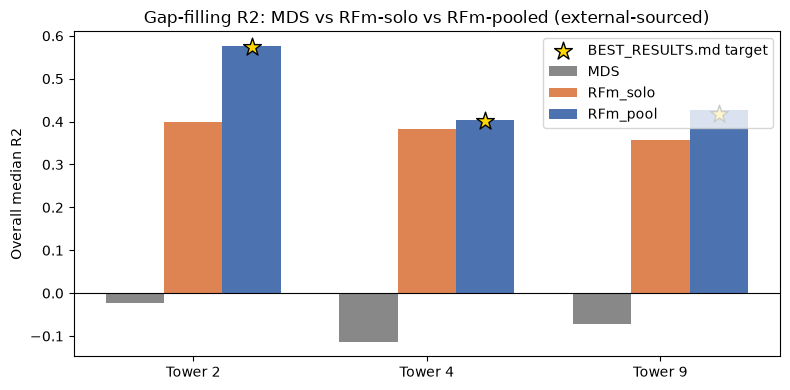

In [105]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
models = ["MDS", "RFm_solo", "RFm_pool"]
colors = {"MDS": "#888888", "RFm_solo": "#DD8452", "RFm_pool": "#4C72B0"}
xpos = np.arange(len(TOWERS))
for i, m in enumerate(models):
    vals = [R.loc[(R.tower == t) & (R.model == m), "R2_overall"].iloc[0] for t in TOWERS]
    ax.bar(xpos + (i - 1) * width, vals, width, label=m, color=colors[m])
for t in TOWERS:
    ax.scatter(xpos[TOWERS.index(t)] + width, TARGET_R2[t], marker="*", s=180, color="gold",
               edgecolor="black", zorder=5, label="BEST_RESULTS.md target" if t == 2 else None)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Overall median R2"); ax.set_title("Gap-filling R2: MDS vs RFm-solo vs RFm-pooled (external-sourced)")
ax.legend(); plt.tight_layout(); plt.show()

### 4.6 Daily-resolution accuracy (out-of-sample)

Section 4.4's headline R2 is computed at **hourly** resolution. This reuses the exact same
held-out mechanism restricted to the **"l" (288h/12-day) gap scenario** specifically -- a 288h gap
consists of complete calendar days, so daily-averaging the held-out actual/predicted pairs gives a
clean, still-genuinely-out-of-sample daily comparison.

In [106]:
@timeit
def run_rf_capture(t, pooled, gap_hours, n_reps):
    """Like run_rf, but returns the raw (timestamp, actual, predicted) pairs for every
    held-out point across all repetitions, instead of just the aggregated metrics."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
        if pooled:
            others = []
            for tt in towers:
                if tt == t:
                    continue
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                others.append(gg[dmt & gg["target"].notna().values])
            trd = pd.concat([trd] + others, ignore_index=True)
        rf, imp = fit(feat, trd)
        yp = rf.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])

In [107]:
daily_rows = []
pairs_parts = []
for t in TOWERS:
    pairs = run_rf_capture(t, pooled=True, gap_hours=288, n_reps=N_REPS)
    hourly_r2 = r2_score(pairs["actual"], pairs["pred"])
    daily = pairs.groupby(pairs.index.normalize()).mean()
    daily_r2 = r2_score(daily["actual"], daily["pred"])
    daily_rows.append({"tower": t, "n_held_out_hours": len(pairs), "n_held_out_days": len(daily),
                        "R2_hourly": round(hourly_r2, 3), "R2_daily": round(daily_r2, 3),
                        "delta": round(daily_r2 - hourly_r2, 3)})
    print(f"Tower {t}: {len(pairs):,} held-out hours -> {len(daily):,} days | "
          f"R2 hourly={hourly_r2:.3f}  R2 daily={daily_r2:.3f}  (delta={daily_r2-hourly_r2:+.3f})")
    pairs_parts.append(pairs.assign(tower=t).reset_index().rename(columns={"index": "Datetime"}))

DAILY_R2 = pd.DataFrame(daily_rows).set_index("tower")
HELD_OUT_PAIRS_L = pd.concat(pairs_parts, ignore_index=True)   # raw (out-of-sample) predictions, "l" scenario
DAILY_R2

Tower 2: 2,565 held-out hours -> 224 days | R2 hourly=0.533  R2 daily=0.207  (delta=-0.325)


Tower 4: 9,754 held-out hours -> 860 days | R2 hourly=0.268  R2 daily=0.321  (delta=+0.053)


Tower 9: 5,682 held-out hours -> 490 days | R2 hourly=0.281  R2 daily=0.504  (delta=+0.223)


,n_held_out_hours,n_held_out_days,R2_hourly,R2_daily,delta
tower,,,,,
2,2565,224,0.533,0.207,-0.325
4,9754,860,0.268,0.321,0.053
9,5682,490,0.281,0.504,0.223


### 4.7 Production gap-filled series

Sections 4.3-4.5 measure accuracy via **held-out synthetic gaps** -- that remains the number to
trust. This section is different in kind: fits **one final** partial-pooled RFm on **all**
available real (QC'd) FCH4 data across all 3 towers (no gaps withheld) and predicts a continuous
series per tower -- this is what "gap-filling in production" produces, and the notebook's output
dataframe. Because the model has seen every real point shown below, this is **not** an
out-of-sample accuracy check (compare 4.4/4.5's R2 for that) -- it exists to let you look at what
the gap-filler produces.

In [108]:
frames_prod = {tt: frame(tt, pooled=True, d=d_all) for tt in TOWERS}
trd_prod = pd.concat([frames_prod[tt][dom_mask(frames_prod[tt].index, tt) & frames_prod[tt]["target"].notna().values]
                       for tt in TOWERS], ignore_index=True)
feat_prod = FEATURES + DUM
rf_prod, imp_prod = fit(feat_prod, trd_prod)
print(f"Production model fit on {len(trd_prod):,} real pooled rows (all 3 towers, no gaps withheld).")

series_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_all = imp_prod.transform(g.loc[dm, feat_prod].values)
    y_pred = pd.Series(rf_prod.predict(X_all), index=g.index[dm])
    y_obs = g.loc[dm, "target"]
    part = pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_pred})
    series_parts.append(part)
    print(f"Tower {t}: {len(part):,} hourly rows ({t}'s domain), {y_obs.notna().sum():,} real observations")

FCH4_GAPFILLED = pd.concat(series_parts).reset_index().rename(columns={"index": "Datetime"})
FCH4_GAPFILLED.head()

Production model fit on 35,586 real pooled rows (all 3 towers, no gaps withheld).
Tower 2: 15,289 hourly rows (2's domain), 4,890 real observations


Tower 4: 54,769 hourly rows (4's domain), 19,465 real observations
Tower 9: 34,297 hourly rows (9's domain), 11,231 real observations


,Datetime,tower,y_observed,y_gapfilled
0,2017-10-01 00:00:00,2,NaN,17.973340
1,2017-10-01 01:00:00,2,NaN,17.545792
2,2017-10-01 02:00:00,2,NaN,16.802216
3,2017-10-01 03:00:00,2,NaN,15.068316
4,2017-10-01 04:00:00,2,NaN,15.035892


**Daily mean** is the comparable view across days regardless of how many real hourly observations
happened to fall on that day.

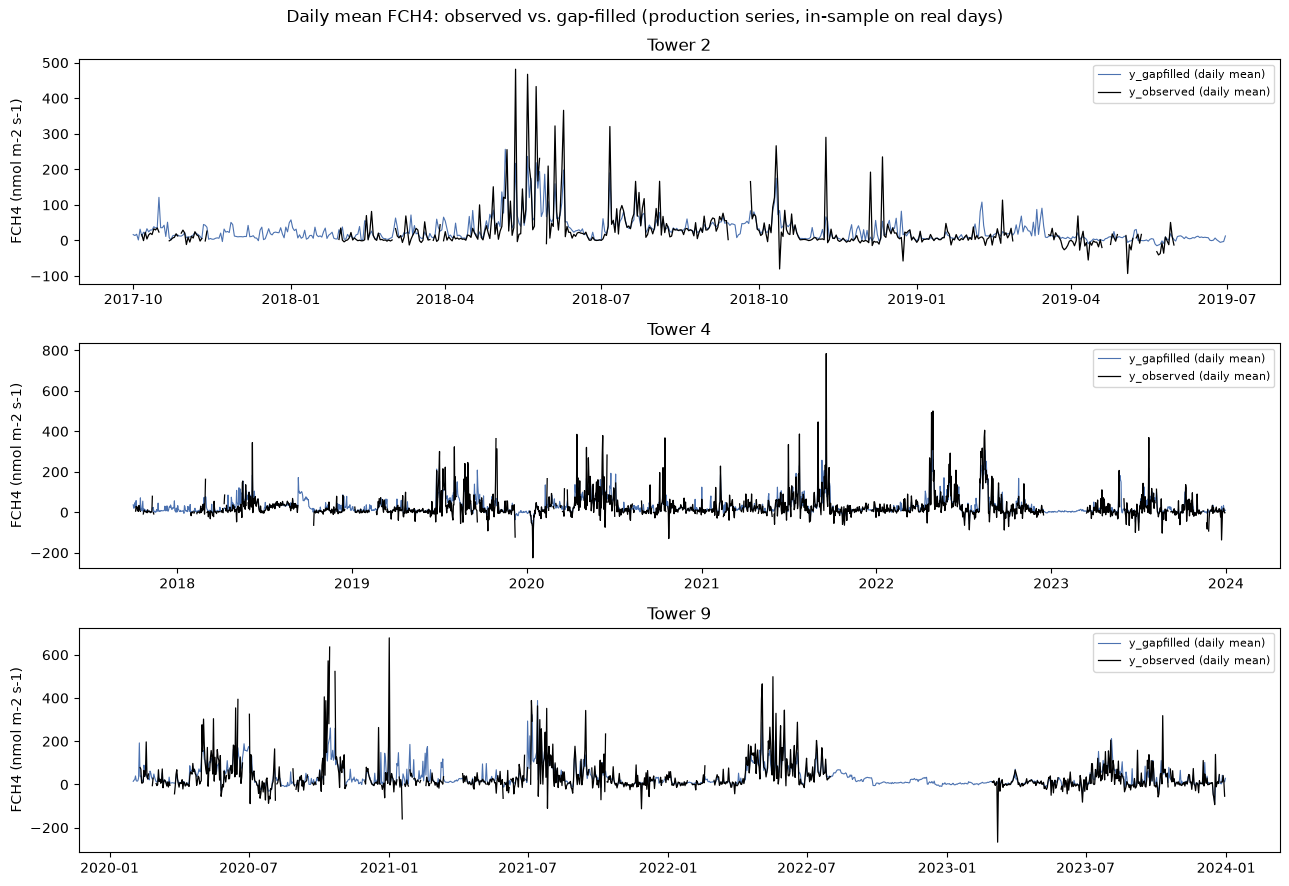

In [109]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_obs = sub["y_observed"].resample("D").mean()
    daily_pred = sub["y_gapfilled"].resample("D").mean()
    ax.plot(daily_pred.index, daily_pred.values, color="#4C72B0", lw=0.8, label="y_gapfilled (daily mean)")
    ax.plot(daily_obs.index, daily_obs.values, color="black", lw=0.9, label="y_observed (daily mean)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily mean FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

**Hourly zoom** -- each tower's own last 90 days of domain, at native hourly resolution (a
full-domain hourly plot is unreadable).

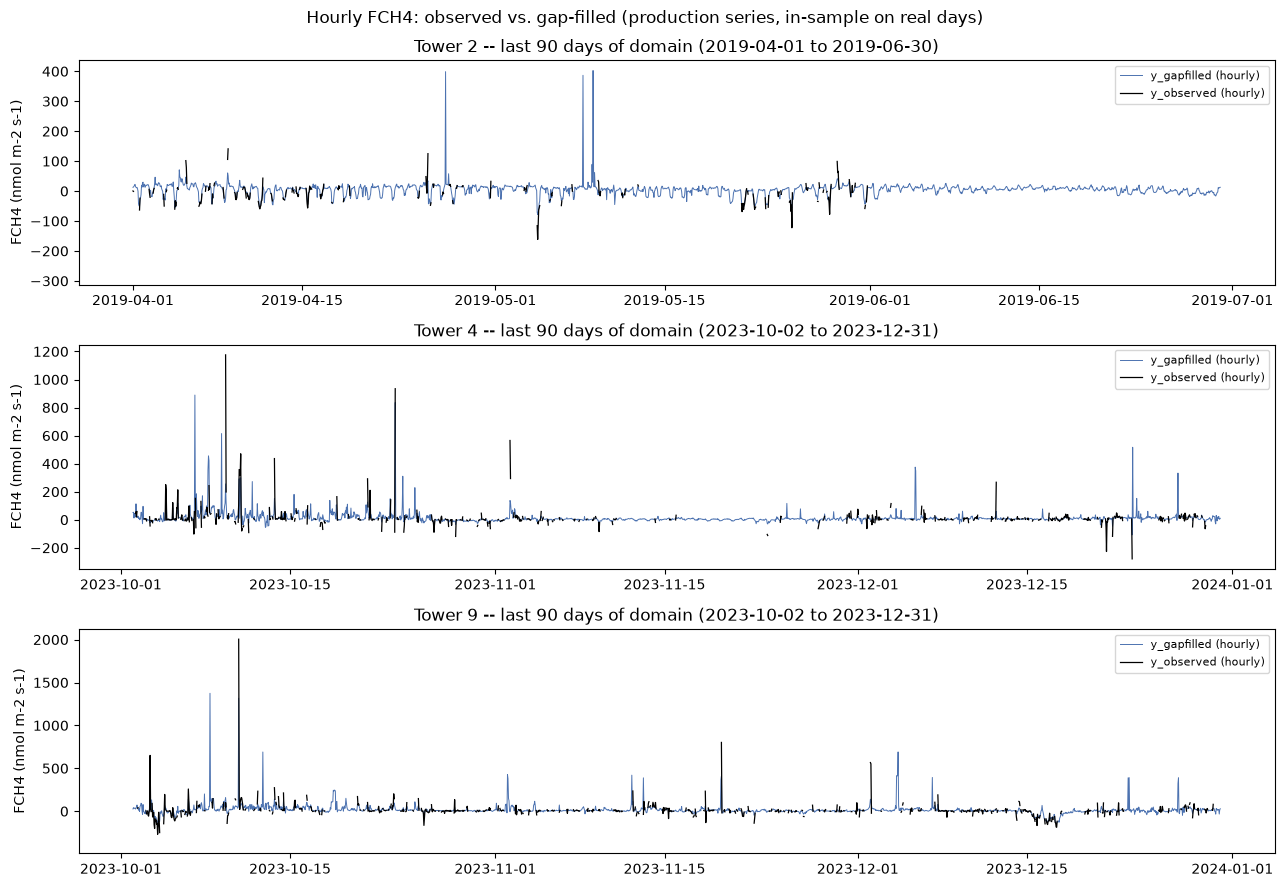

In [110]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    window = sub.loc[sub.index.max() - pd.Timedelta(days=90):]
    ax.plot(window.index, window["y_gapfilled"], color="#4C72B0", lw=0.7, label="y_gapfilled (hourly)")
    ax.plot(window.index, window["y_observed"], color="black", lw=0.9, label="y_observed (hourly)")
    ax.set_title(f"Tower {t} -- last 90 days of domain ({window.index.min().date()} to {window.index.max().date()})")
    ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Hourly FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

### 4.8 Saving outputs to `_data/`

| File | Contents |
|---|---|
| `fch4_gapfilled.csv` | Full per-tower production series (`y_observed`, `y_gapfilled`), hourly, all 3 towers |
| `feature_frame.csv` | The exact engineered feature matrix fed to the RF, hourly, all 3 towers |
| `gap_cv_results_hourly.csv` | Per-tower/model/scenario hourly R2/RMSE/MAE/MBE from the held-out gap-CV grid |
| `daily_r2_results.csv` | Hourly-vs-daily R2 comparison from the "l"-scenario held-out pairs |
| `held_out_pairs_l_scenario.csv` | The raw, genuinely out-of-sample (timestamp, tower, actual, predicted) pairs |

Not gitignored (unlike `_model_cache/`) -- these are the notebook's actual output artifacts.

In [111]:
DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)

FCH4_GAPFILLED.to_csv(DATA_DIR / "fch4_gapfilled.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_gapfilled.csv'}  ({len(FCH4_GAPFILLED):,} rows)")

feature_rows = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    fg = g.loc[dm, ["target"] + FEATURES].copy()
    fg["tower"] = t
    fg = fg.reset_index().rename(columns={"index": "Datetime"})
    feature_rows.append(fg)
FEATURE_FRAME = pd.concat(feature_rows, ignore_index=True)
FEATURE_FRAME.to_csv(DATA_DIR / "feature_frame.csv", index=False)
print(f"Saved {DATA_DIR/'feature_frame.csv'}  ({len(FEATURE_FRAME):,} rows x {FEATURE_FRAME.shape[1]} cols)")

R.to_csv(DATA_DIR / "gap_cv_results_hourly.csv", index=False)
print(f"Saved {DATA_DIR/'gap_cv_results_hourly.csv'}  ({len(R)} rows)")

DAILY_R2.reset_index().to_csv(DATA_DIR / "daily_r2_results.csv", index=False)
print(f"Saved {DATA_DIR/'daily_r2_results.csv'}  ({len(DAILY_R2)} rows)")

HELD_OUT_PAIRS_L.to_csv(DATA_DIR / "held_out_pairs_l_scenario.csv", index=False)
print(f"Saved {DATA_DIR/'held_out_pairs_l_scenario.csv'}  ({len(HELD_OUT_PAIRS_L):,} rows)")

total_mb = sum(f.stat().st_size for f in DATA_DIR.glob("*.csv")) / 1e6
print(f"\n_data/ total size: {total_mb:.1f} MB")

Saved _data\fch4_gapfilled.csv  (104,355 rows)


Saved _data\feature_frame.csv  (104,355 rows x 33 cols)
Saved _data\gap_cv_results_hourly.csv  (9 rows)
Saved _data\daily_r2_results.csv  (3 rows)
Saved _data\held_out_pairs_l_scenario.csv  (18,001 rows)

_data/ total size: 534.4 MB


## 5. Uncertainty quantification: Area of Applicability

This project already has an established, from-scratch Area-of-Applicability implementation
(`dissimilarity_index()`, `src/models/scenario_hybrid.py`, in the spirit of Meyer & Pebesma 2021)
used for the Phase 07 scenario-analysis UQ work (S-01/S-03/U-03), replicated **inline** here
(cannot be imported, per this notebook's no-`src/`-dependency constraint).

**Mechanics**: for a query point's feature vector, find its nearest neighbour (Euclidean, in
`StandardScaler`-scaled feature space) among the RF's real training rows. A point is flagged
"outside the Area of Applicability" if that distance exceeds `Q3 + 1.5*IQR` of the training data's
*own* leave-one-out nearest-neighbour distances (a Tukey outlier fence) -- i.e., is this point
further from its nearest training neighbour than training points typically are from each other?

Section 5.2 validates the metric against real held-out error *before* section 5.3 applies it as a
reliability flag on the production series.

### 5.1 Definition

In [112]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

@timeit
def dissimilarity_index(X_train, X_query):
    """From-scratch Area-of-Applicability metric (Meyer & Pebesma 2021 in spirit), replicated
    inline from src/models/scenario_hybrid.py's dissimilarity_index() for consistency with this
    project's established scenario-analysis UQ convention (S-01/S-03/U-03) -- not a new formula.
    Returns (d_query, threshold, flagged)."""
    scaler = StandardScaler().fit(X_train)
    Xtr = scaler.transform(X_train)
    Xq = scaler.transform(X_query)

    d_query = cdist(Xq, Xtr).min(axis=1)

    d_train_matrix = cdist(Xtr, Xtr)
    np.fill_diagonal(d_train_matrix, np.inf)
    d_train_loo = d_train_matrix.min(axis=1)
    q1, q3 = np.percentile(d_train_loo, [25, 75])
    threshold = q3 + 1.5 * (q3 - q1)

    flagged = d_query > threshold
    return d_query, threshold, flagged

print("dissimilarity_index defined.")

dissimilarity_index defined.


### 5.2 Validation: does the dissimilarity index actually predict held-out error?

Reuses `HELD_OUT_PAIRS_L` (section 4.6 -- genuinely out-of-sample "l"-scenario points, all 3
towers). `X_train` is `trd_prod[FEATURES + DUM]` excluding those held-out timestamps -- comparing
a point against a training set that secretly includes it would give a trivially small distance
everywhere, so the held-out timestamps are excluded here specifically for this validation (section
5.3's production application is correct as-is, since the deployed model genuinely did train on
every real point there).

In [113]:
held_out_by_tower = {t: set(HELD_OUT_PAIRS_L.loc[HELD_OUT_PAIRS_L.tower == t, "Datetime"]) for t in TOWERS}
frames_di = {t: frame(t, pooled=True, d=d_all) for t in TOWERS}
trd_prod_excl = pd.concat([
    frames_di[t][dom_mask(frames_di[t].index, t) & frames_di[t]["target"].notna().values
                  & ~frames_di[t].index.isin(held_out_by_tower[t])]
    for t in TOWERS
], ignore_index=True)
X_train_di = imp_prod.transform(trd_prod_excl[FEATURES + DUM].values)

# Re-derive feature vectors for the held-out "l"-scenario points at their exact timestamps.
query_rows = []
for _, row in HELD_OUT_PAIRS_L.iterrows():
    t = int(row["tower"]); ts = row["Datetime"]
    query_rows.append(frames_di[t].loc[ts, FEATURES + DUM])
X_query_di = imp_prod.transform(pd.DataFrame(query_rows).values)

d_query, di_threshold, flagged = dissimilarity_index(X_train_di, X_query_di)
abs_err = (HELD_OUT_PAIRS_L["pred"] - HELD_OUT_PAIRS_L["actual"]).abs().values

corr_pearson = np.corrcoef(d_query, abs_err)[0, 1]
corr_spearman = pd.Series(d_query).corr(pd.Series(abs_err), method="spearman")
mean_err_flagged = abs_err[flagged].mean() if flagged.any() else np.nan
mean_err_unflagged = abs_err[~flagged].mean() if (~flagged).any() else np.nan

print(f"DI threshold: {di_threshold:.3f}")
print(f"n flagged (outside AOA): {flagged.sum():,} / {len(flagged):,} ({100*flagged.mean():.1f}%)")
print(f"Pearson correlation (DI vs |error|):  {corr_pearson:+.3f}")
print(f"Spearman correlation (DI vs |error|): {corr_spearman:+.3f}")
print(f"Mean |error|, flagged (outside AOA):   {mean_err_flagged:.2f}")
print(f"Mean |error|, unflagged (inside AOA):  {mean_err_unflagged:.2f}")

DI_VALIDATION = pd.DataFrame({"tower": HELD_OUT_PAIRS_L["tower"].values, "Datetime": HELD_OUT_PAIRS_L["Datetime"].values,
                               "actual": HELD_OUT_PAIRS_L["actual"].values, "pred": HELD_OUT_PAIRS_L["pred"].values,
                               "abs_error": abs_err, "dissimilarity_index": d_query, "flagged": flagged})
print("\nPer-tower breakdown:")
for t in TOWERS:
    sub = DI_VALIDATION[DI_VALIDATION.tower == t]
    c_p = np.corrcoef(sub["dissimilarity_index"], sub["abs_error"])[0, 1] if len(sub) > 2 else np.nan
    print(f"  Tower {t}: n={len(sub):,}  Pearson(DI, |err|)={c_p:+.3f}  "
          f"mean|err| flagged={sub.loc[sub.flagged,'abs_error'].mean():.2f}  "
          f"mean|err| unflagged={sub.loc[~sub.flagged,'abs_error'].mean():.2f}")
DI_VALIDATION.head()

DI threshold: 1.950
n flagged (outside AOA): 5,931 / 18,001 (32.9%)
Pearson correlation (DI vs |error|):  +0.110
Spearman correlation (DI vs |error|): +0.145
Mean |error|, flagged (outside AOA):   59.53
Mean |error|, unflagged (inside AOA):  37.87

Per-tower breakdown:
  Tower 2: n=2,565  Pearson(DI, |err|)=+0.123  mean|err| flagged=42.03  mean|err| unflagged=26.92
  Tower 4: n=9,754  Pearson(DI, |err|)=+0.101  mean|err| flagged=60.33  mean|err| unflagged=39.41
  Tower 9: n=5,682  Pearson(DI, |err|)=+0.159  mean|err| flagged=69.45  mean|err| unflagged=38.94


,tower,Datetime,actual,pred,abs_error,dissimilarity_index,flagged
0,2,2017-10-10 15:00:00,4.802356,57.230204,52.427848,3.300174,True
1,2,2017-10-10 22:00:00,21.621562,41.438779,19.817218,3.107869,True
2,2,2017-10-10 23:00:00,13.878446,28.936614,15.058168,2.998854,True
3,2,2017-10-11 00:00:00,44.769662,33.616917,11.152745,2.930529,True
4,2,2017-10-11 01:00:00,54.165464,50.360746,3.804718,2.947896,True


A meaningfully positive correlation and a materially higher flagged-vs-unflagged mean error
support trusting the AOA flag as a genuine reliability signal on top of the point predictions.

### 5.3 Applying the flag to the production gap-filled series

In [114]:
di_prod_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_prod = imp_prod.transform(g.loc[dm, FEATURES + DUM].values)
    d_prod, thr_prod, flagged_prod = dissimilarity_index(X_train_di, X_prod)
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].reset_index(drop=True).copy()
    sub["dissimilarity_index"] = d_prod
    sub["outside_aoa"] = flagged_prod
    di_prod_parts.append(sub)
    is_gapfilled = sub["y_observed"].isna()
    n_gapfilled = is_gapfilled.sum()
    n_flagged_of_gapfilled = (sub.loc[is_gapfilled, "outside_aoa"]).sum()
    print(f"Tower {t}: {100*flagged_prod.mean():.1f}% of all hours outside AOA overall; "
          f"of the {n_gapfilled:,} genuinely gap-filled hours, {n_flagged_of_gapfilled:,} "
          f"({100*n_flagged_of_gapfilled/max(n_gapfilled,1):.1f}%) are flagged as lower-trust")

FCH4_GAPFILLED_WITH_UQ = pd.concat(di_prod_parts, ignore_index=True)
FCH4_GAPFILLED_WITH_UQ.to_csv(DATA_DIR / "fch4_gapfilled_with_uq.csv", index=False)
print(f"\nSaved {DATA_DIR/'fch4_gapfilled_with_uq.csv'}  ({len(FCH4_GAPFILLED_WITH_UQ):,} rows)")
FCH4_GAPFILLED_WITH_UQ.head()

Tower 2: 39.5% of all hours outside AOA overall; of the 10,399 genuinely gap-filled hours, 5,038 (48.4%) are flagged as lower-trust


Tower 4: 24.1% of all hours outside AOA overall; of the 35,304 genuinely gap-filled hours, 10,696 (30.3%) are flagged as lower-trust


Tower 9: 29.4% of all hours outside AOA overall; of the 23,066 genuinely gap-filled hours, 8,563 (37.1%) are flagged as lower-trust



Saved _data\fch4_gapfilled_with_uq.csv  (104,355 rows)


,Datetime,tower,y_observed,y_gapfilled,dissimilarity_index,outside_aoa
0,2017-10-01 00:00:00,2,NaN,17.973340,3.276476,True
1,2017-10-01 01:00:00,2,NaN,17.545792,3.199887,True
2,2017-10-01 02:00:00,2,NaN,16.802216,3.126413,True
3,2017-10-01 03:00:00,2,NaN,15.068316,3.022668,True
4,2017-10-01 04:00:00,2,NaN,15.035892,3.075253,True


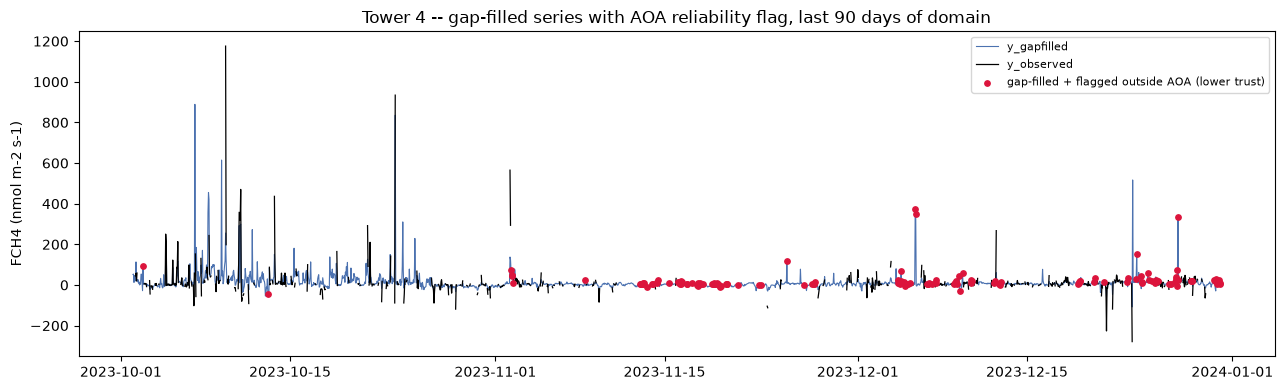

In [115]:
t_demo_uq = 4
sub_uq = FCH4_GAPFILLED_WITH_UQ[FCH4_GAPFILLED_WITH_UQ.tower == t_demo_uq].set_index("Datetime")
window_uq = sub_uq.loc[sub_uq.index.max() - pd.Timedelta(days=90):]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(window_uq.index, window_uq["y_gapfilled"], color="#4C72B0", lw=0.8, label="y_gapfilled")
ax.plot(window_uq.index, window_uq["y_observed"], color="black", lw=0.9, label="y_observed")
flagged_pts = window_uq[window_uq["outside_aoa"] & window_uq["y_observed"].isna()]
ax.scatter(flagged_pts.index, flagged_pts["y_gapfilled"], color="crimson", s=15, zorder=5,
           label="gap-filled + flagged outside AOA (lower trust)")
ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Tower {t_demo_uq} -- gap-filled series with AOA reliability flag, last 90 days of domain")
plt.tight_layout(); plt.show()

`FCH4_GAPFILLED_WITH_UQ` (saved to `_data/fch4_gapfilled_with_uq.csv`) now carries a per-point
`outside_aoa` flag alongside every gap-filled value -- a validated reliability signal, distinct
from and complementary to the conformal-interval UQ this project has elsewhere (U-02/U-03).

---

## Summary

This notebook reproduces, end to end, with zero `src/` dependencies:
1. **EDA** -- 7 data-quality issues, each tied to the fix implemented downstream (section 1).
2. **Feature imputation** -- a complete FCO2 feature via met-driven RF, the external-sourced
   driver variant, and REddyProc-style gap-filling for every meteorological driver, with a
   held-out accuracy check (section 2).
3. **Additional feature engineering** -- GPP/Reco partitioning, pruned management recency,
   livestock stocking density, and the final per-tower feature frame with partial-pooling support
   (section 3).
4. **Gap-filling** -- the full-period gap-CV harness (MDS vs. RFm-solo vs. RFm-pooled) that
   reproduces this project's headline result (section 4.5), a daily-resolution accuracy check, and
   a production gap-filled series with saved artifacts (section 4).
5. **Uncertainty quantification** -- a validated Area-of-Applicability reliability flag applied to
   the production series (section 5).

**Caveats** (also true of the original F-08/F-09a experiments):
- Full-period gap-CV is an interpolation benchmark, not a forecasting one -- every synthetic gap
  has real observations on both sides available to train on.
- Tower 2's R2 reflects a genuinely easier discrimination task (livestock-on vs. livestock-off)
  than Towers 4/9's continuous variation -- not directly comparable in difficulty (F-07, D-34).
- GPP/Reco partitioning and the u* threshold are pragmatic simplifications of the full
  REddyProc/Papale 2006 methods (section 3.1).
- RF hyperparameters and gap-CV seeds are fixed throughout for reproducibility.

**Extending this notebook:** add new experiment sections after this point (e.g. alternative
estimators, feature ablations, prediction intervals) rather than modifying sections 1-5 above --
they are the standing, validated base pipeline.

---

## 6. Lag/lead redundancy analysis (ACF/PACF/AIC/BIC/cross-correlation/covariance)

The feature frame's soil moisture/temperature lags (`LAG_HOURS = [168, 336, 504, 672]`, section 3.4)
were picked a priori (1/2/3/4 weeks), never derived from an autocorrelation/order-selection analysis.
Two prior ablations tested variations on that a priori choice:

- **D-31/F-04**: the current backward-only lags are mildly helpful (esp. Tower 2), redundant elsewhere.
- **D-75/F-12, reconfirmed D-78**: adding/replacing with forward (lead) soil lags is null-to-mildly-negative
  (a tied +0.008 at Tower 4 only, regressions at T2/T9, inside noise). D-78 also tried FCH4-self
  `target_lag`/`target_lead` at `[1, 24, 168]` (also a priori) and found a **clear regression** at every
  tower (0.495/0.329/0.353 vs. champion 0.576/0.404/0.426) -- attributed to target sparsity making those
  columns frequently NaN and mean-imputed.

This section is a genuinely more rigorous redo, not another a priori guess: ACF, PACF, cross-correlation,
covariance, and AIC/BIC applied over a fine 1-672h grid, to **soil moisture, soil temperature, and the
FCH4 target itself**, with **both lags and leads** (leads are legitimate here -- this is gap-filling an
archive, not live forecasting). Diagnostics are computed **per tower** (towers 2/4/9 have non-overlapping
`DOMAIN`s and must never be concatenated for a raw autocorrelation), then combined into **one shared lag/
lead set** (the pooled model needs one column schema across towers). Per this project's own convention
(D-75/D-78, and this notebook's own section 5 UQ validation): **these diagnostics are candidate-generating,
not a verdict** -- section 7 empirically validates the result against the real gap-CV harness before any
adoption claim.

### 6.1 Setup

New imports beyond what sections 1-5 already use. Reuses `frame`, `cfg`, `dom_mask`, `DOMAIN`, `d_all`,
`TOWERS`, `FEATURES` unmodified.

In [116]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, levinson_durbin
from statsmodels.tsa.ar_model import ar_select_order
from scipy.signal import find_peaks

MAXLAG = 672
AR_CORROB_MAXLAG = 96   # ar_select_order(glob=False) scales badly with maxlag (measured:
                        # 85s/call at maxlag=336 vs ~5s/call at maxlag=96, x6 calls -- this
                        # is supplementary corroboration only, never gates FINAL_LAGLEAD, so
                        # it is capped well below the main 1-672h diagnostic grid.
Z_95 = 1.96                 # z-value for a 95% significance band, used throughout this section
MIN_GAP = {"swc": 6, "ts": 6, "target": 3}   # min hour-spacing enforced between kept lags (per variable)
K_SHORTLIST = 15            # max relevance-ranked candidates carried into the AIC/BIC step
CORR_PRUNE_THRESH = 0.90    # candidates more correlated than this are treated as redundant
K_MAX_SHARED = 6            # max hours kept per (variable, direction) in the final shared set

VARS_DIRS = [("swc", "lag"), ("swc", "lead"), ("ts", "lag"), ("ts", "lead"),
             ("target", "lag"), ("target", "lead")]


@timeit
def series_for_diag(t, which):
    """which in {'swc','ts','target'}. Returns (series, dom_bool) on d_all's index. For 'target'
    this reuses frame()'s own QC (SSITC + plausibility) filter -- not re-derived here."""
    c = cfg(t)
    if which == "target":
        g = frame(t, pooled=False, d=d_all)
        return g["target"], dom_mask(g.index, t)
    col = c["swc"] if which == "swc" else c["ts"]
    s = d_all[col + "__f"] if (col + "__f") in d_all.columns else d_all[col]
    return s, dom_mask(s.index, t)


print("Setup complete: MAXLAG=672, shared imports, series_for_diag defined.")

Setup complete: MAXLAG=672, shared imports, series_for_diag defined.


### 6.2 Own ACF/PACF, per tower (swc, ts, target)

`swc`/`ts` (the gap-filled `__f` driver series) have no missingness within a tower's domain, so a
standard `acf`/`pacf` applies directly. The FCH4 **target** genuinely has ~12-44% valid coverage per
tower -- `pacf()` has no missing-data handling at all, so its PACF is obtained via
`levinson_durbin(acf_vals, isacov=True)` fed the `missing="conservative"` ACF values instead: Levinson-
Durbin's reflection coefficients (PACF) are scale-invariant, so normalized correlations in place of true
autocovariances still yield a valid PACF. This assumes MCAR-like missingness, which real EC flux gaps only
approximate (they can be weather/QC-correlated) -- treated as an approximation, not exact.

In [117]:
@timeit
def acf_pacf_own(series_full, dom_bool, maxlag=MAXLAG, has_missing=False):
    s = series_full[dom_bool]
    if has_missing:
        a_vals = acf(s.values, nlags=maxlag, missing="conservative", fft=False)
        _, _, p_vals, _, _ = levinson_durbin(a_vals, nlags=maxlag, isacov=True)
        n_eff = int(s.notna().sum())
    else:
        s = s.dropna()   # defensive only -- __f columns should be fully populated within DOMAIN
        a_vals = acf(s.values, nlags=maxlag, fft=True)
        p_vals = pacf(s.values, nlags=maxlag, method="ywadjusted")
        n_eff = len(s)
    return dict(acf=a_vals, pacf=p_vals, n_eff=n_eff)


ACF_DIAG = {}
for t in TOWERS:
    for var in ("swc", "ts", "target"):
        s_full, dm = series_for_diag(t, var)
        ACF_DIAG[(t, var)] = acf_pacf_own(s_full, dm, has_missing=(var == "target"))
        print(f"Tower {t} {var:6s}: n_eff={ACF_DIAG[(t, var)]['n_eff']:,}")

Tower 2 swc   : n_eff=15,289


Tower 2 ts    : n_eff=15,289


Tower 2 target: n_eff=4,890


Tower 4 swc   : n_eff=54,769


Tower 4 ts    : n_eff=54,769


Tower 4 target: n_eff=19,465


Tower 9 swc   : n_eff=34,297


Tower 9 ts    : n_eff=34,297


Tower 9 target: n_eff=11,231


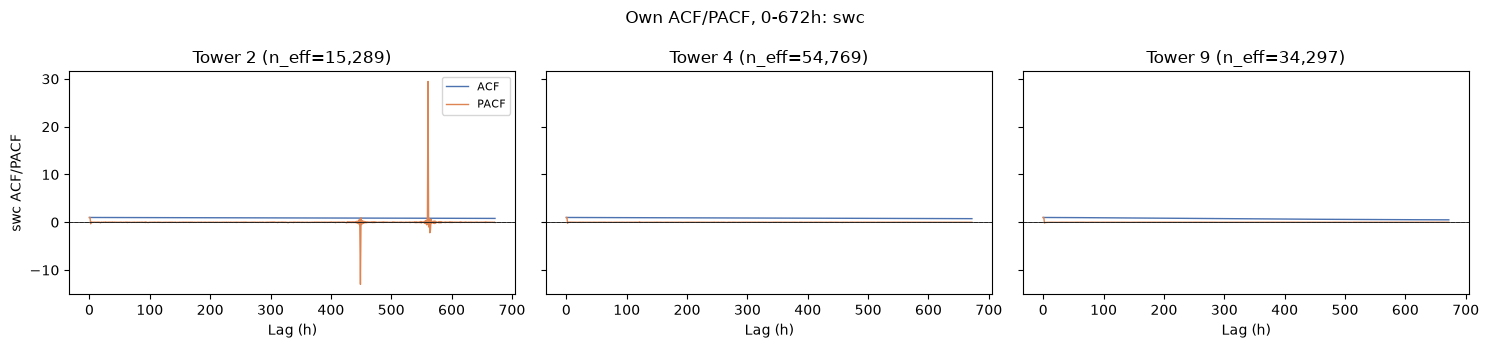

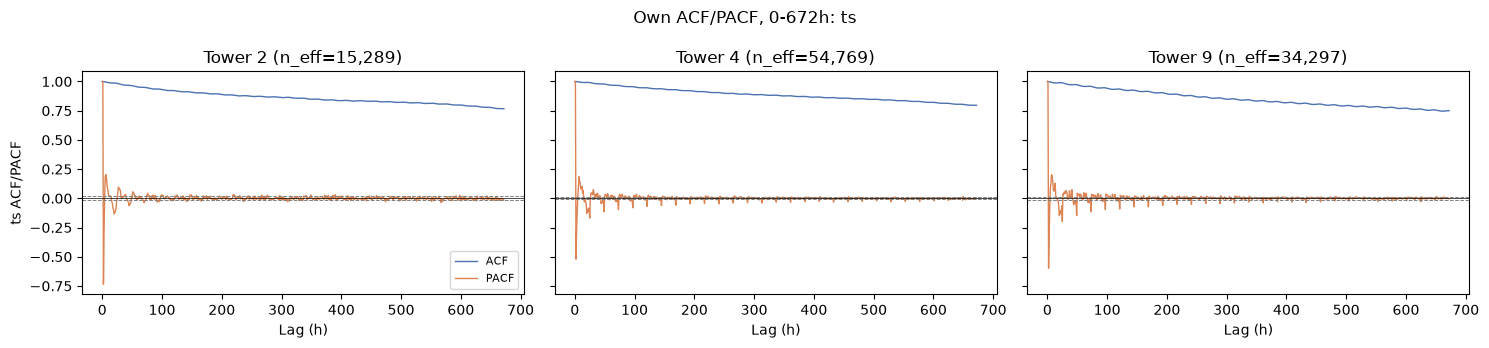

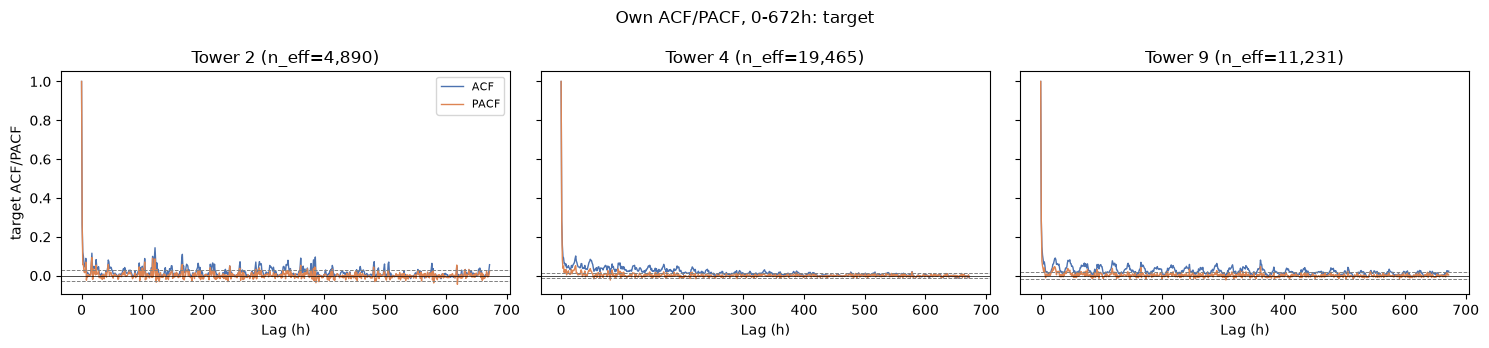

In [118]:
for var in ("swc", "ts", "target"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
    for ax, t in zip(axes, TOWERS):
        d = ACF_DIAG[(t, var)]
        band = Z_95 / np.sqrt(max(d["n_eff"], 2))
        lags = np.arange(len(d["acf"]))
        ax.plot(lags, d["acf"], color="#4C72B0", lw=1, label="ACF")
        ax.plot(lags, d["pacf"], color="#DD8452", lw=1, label="PACF")
        ax.axhline(band, color="grey", ls="--", lw=0.7); ax.axhline(-band, color="grey", ls="--", lw=0.7)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_title(f"Tower {t} (n_eff={d['n_eff']:,})"); ax.set_xlabel("Lag (h)")
    axes[0].set_ylabel(f"{var} ACF/PACF"); axes[0].legend(fontsize=8)
    plt.suptitle(f"Own ACF/PACF, 0-{MAXLAG}h: {var}")
    plt.tight_layout(); plt.show()

### 6.3 Cross-correlation: FCH4 target vs. swc/ts, lag and lead

Computed via `pandas.Series.corr()` (pairwise-complete by construction) rather than `statsmodels.ccf`,
which has no missing-data handling -- simpler and correct here given the target's real sparsity.

In [119]:
@timeit
def cross_corr_target(target_full, covar_full, dom_bool, maxlag=MAXLAG):
    tgt = target_full[dom_bool]; cov = covar_full[dom_bool]
    lag_corr = np.array([tgt.corr(cov.shift(h)) for h in range(1, maxlag + 1)])
    lead_corr = np.array([tgt.corr(cov.shift(-h)) for h in range(1, maxlag + 1)])
    return dict(lag=lag_corr, lead=lead_corr, n_eff=int(tgt.notna().sum()))


CROSS_CORR = {}
for t in TOWERS:
    tgt_full, tgt_dm = series_for_diag(t, "target")
    for var in ("swc", "ts"):
        cov_full, _ = series_for_diag(t, var)
        CROSS_CORR[(t, var)] = cross_corr_target(tgt_full, cov_full, tgt_dm)
print("Cross-correlation computed for swc/ts x 3 towers.")

Cross-correlation computed for swc/ts x 3 towers.


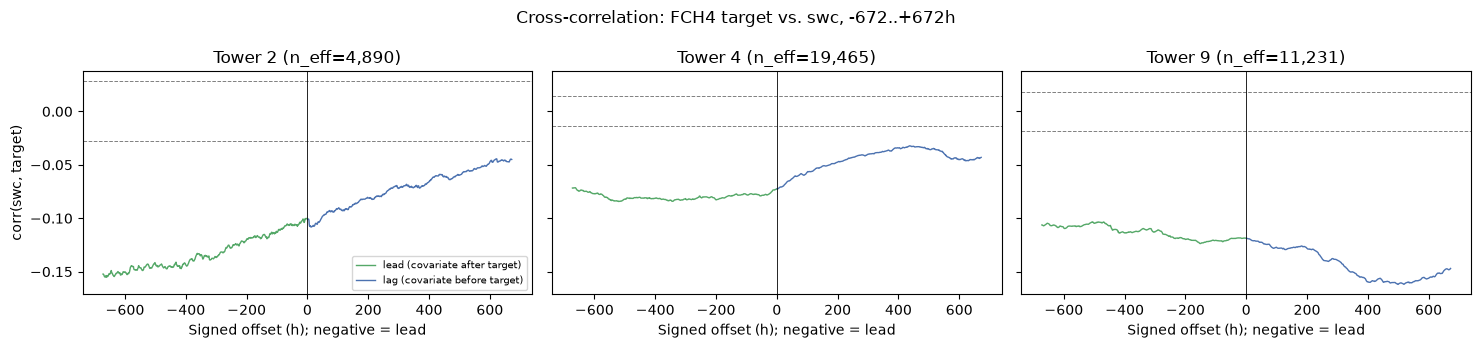

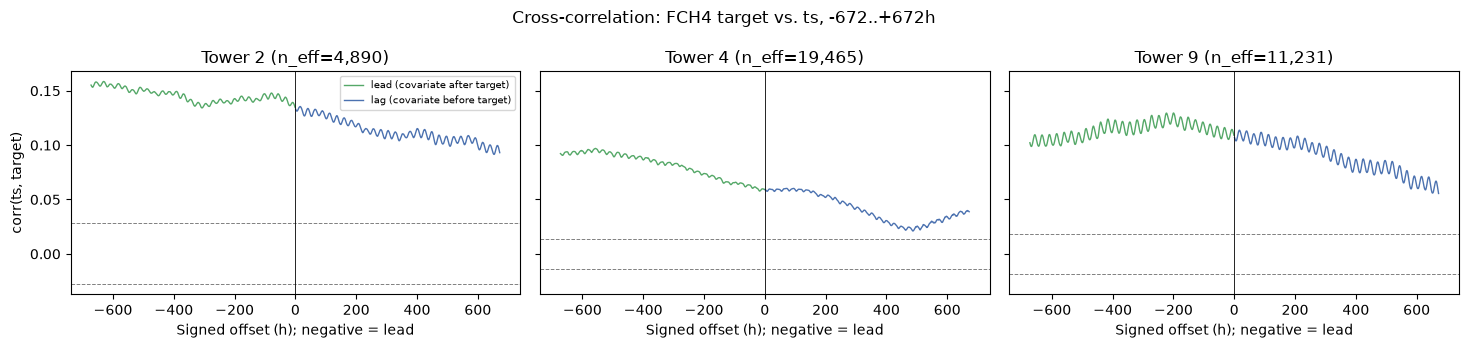

In [120]:
for var in ("swc", "ts"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
    offsets = np.arange(1, MAXLAG + 1)
    for ax, t in zip(axes, TOWERS):
        d = CROSS_CORR[(t, var)]
        band = Z_95 / np.sqrt(max(d["n_eff"], 2))
        ax.plot(-offsets[::-1], d["lead"][::-1], color="#55A868", lw=1, label="lead (covariate after target)")
        ax.plot(offsets, d["lag"], color="#4C72B0", lw=1, label="lag (covariate before target)")
        ax.axhline(band, color="grey", ls="--", lw=0.7); ax.axhline(-band, color="grey", ls="--", lw=0.7)
        ax.axvline(0, color="black", lw=0.6)
        ax.set_title(f"Tower {t} (n_eff={d['n_eff']:,})"); ax.set_xlabel("Signed offset (h); negative = lead")
    axes[0].set_ylabel(f"corr({var}, target)"); axes[0].legend(fontsize=7)
    plt.suptitle(f"Cross-correlation: FCH4 target vs. {var}, -{MAXLAG}..+{MAXLAG}h")
    plt.tight_layout(); plt.show()

### 6.4 Relevance shortlist, AIC/BIC parsimony cutoff, and within-tower redundancy pruning

Per `(tower, variable, direction)`: (1) shortlist spaced-out local maxima of |correlation| via
`scipy.signal.find_peaks` (always including h=1); (2) fit nested `sm.OLS(target ~ cumulative shortlisted
candidates)` on a **fixed common row-subset** (so AIC/BIC are comparable across nested models) and take
`k_bic = argmin(BIC) + 1` as the primary cutoff (BIC over AIC, per this project's existing parsimony-
favoring convention at D-75/D-78); (3) greedily drop any BIC-surviving candidate that is >90% correlated
with an already-kept one. `ar_select_order(..., glob=False)` on swc/ts's own dynamics is run alongside as
**corroboration only, not a filter** -- `glob=True` at this scale is computationally infeasible (confirmed:
`ArrayMemoryError` even at `maxlag=50`, since it enumerates `2**maxlag` subsets).

In [121]:
@timeit
def relevance_shortlist(corr_by_h, hours, n_eff, min_gap, k_max):
    band = Z_95 / np.sqrt(max(n_eff, 2))
    absc = np.abs(corr_by_h)
    peak_idx, _ = find_peaks(absc, height=band, distance=min_gap)
    if len(peak_idx) == 0:
        peak_idx = np.array([int(np.argmax(absc))])   # fallback: weak signal, keep the single best lag
    ranked = sorted(peak_idx, key=lambda i: -absc[i])[:k_max]
    return sorted(set(int(hours[i]) for i in ranked) | {1})


@timeit
def ols_nested_bic(target_full, dom_bool, cand_series_dict):
    """cand_series_dict: {hour: shifted_series}, already ordered by relevance (descending)."""
    tgt = target_full[dom_bool].rename("target")
    hours = list(cand_series_dict.keys())
    cand_df = pd.DataFrame({h: s[dom_bool] for h, s in cand_series_dict.items()})
    common = pd.concat([tgt, cand_df], axis=1).dropna()
    n_common = len(common)
    if n_common < 20 or not hours:
        return dict(k_bic=min(1, len(hours)), k_aic=min(1, len(hours)), n_common=n_common, hours=hours)
    aics, bics = [], []
    for k in range(1, len(hours) + 1):
        X = sm.add_constant(common[hours[:k]].values)
        res = sm.OLS(common["target"].values, X).fit()
        aics.append(res.aic); bics.append(res.bic)
    return dict(k_bic=int(np.argmin(bics)) + 1, k_aic=int(np.argmin(aics)) + 1,
                n_common=n_common, hours=hours)


@timeit
def ar_order_bic(series_full, dom_bool, maxlag=AR_CORROB_MAXLAG):
    """Corroboration only (swc/ts own AR structure) -- glob=False is mandatory at this maxlag."""
    s = series_full[dom_bool].dropna().astype(float)
    try:
        sel = ar_select_order(s.values, maxlag=maxlag, ic="bic", glob=False, old_names=False)
        return list(sel.ar_lags) if sel.ar_lags else []
    except Exception as e:
        print(f"  ar_select_order failed ({e}); skipping corroboration for this series.")
        return []


@timeit
def corr_matrix_prune(cols_df, ranked_hours, thresh=CORR_PRUNE_THRESH):
    keep = []
    for h in ranked_hours:
        if all(abs(cols_df[h].corr(cols_df[k])) < thresh for k in keep):
            keep.append(h)
    return keep


print("relevance_shortlist / ols_nested_bic / ar_order_bic / corr_matrix_prune defined.")

relevance_shortlist / ols_nested_bic / ar_order_bic / corr_matrix_prune defined.


In [122]:
AR_OWN_ORDER = {}
for t in TOWERS:
    for var in ("swc", "ts"):
        s_full, dm = series_for_diag(t, var)
        AR_OWN_ORDER[(t, var)] = ar_order_bic(s_full, dm)
        print(f"Tower {t} {var:6s}: AR(BIC, glob=False) contiguous order -> {AR_OWN_ORDER[(t, var)]}")

Tower 2 swc   : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Tower 2 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]


Tower 4 swc   : AR(BIC, glob=False) contiguous order -> [1, 2]


Tower 4 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]


Tower 9 swc   : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7]


Tower 9 ts    : AR(BIC, glob=False) contiguous order -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


In [123]:
hours_arr = np.arange(1, MAXLAG + 1)
PER_TOWER_FINAL = {}
PER_TOWER_RELEVANCE = {}

for t in TOWERS:
    tgt_full, tgt_dm = series_for_diag(t, "target")
    for var, direction in VARS_DIRS:
        if var in ("swc", "ts"):
            cov_full, dm = series_for_diag(t, var)
            corr_by_h = CROSS_CORR[(t, var)]["lag" if direction == "lag" else "lead"]
            n_eff = CROSS_CORR[(t, var)]["n_eff"]
        else:   # target: self-ACF used for both directions (approximate direction-symmetry
                # assumption for a locally stationary series -- see section 6 intro)
            cov_full, dm = tgt_full, tgt_dm
            corr_by_h = ACF_DIAG[(t, "target")]["acf"][1:]
            n_eff = ACF_DIAG[(t, "target")]["n_eff"]

        shortlist = relevance_shortlist(corr_by_h, hours_arr, n_eff, MIN_GAP[var], K_SHORTLIST)
        shortlist_sorted = sorted(shortlist, key=lambda h: -abs(corr_by_h[h - 1]))

        sign = 1 if direction == "lag" else -1
        cand_series = {h: cov_full.shift(sign * h) for h in shortlist_sorted}

        bic_res = ols_nested_bic(tgt_full, dm, cand_series)
        k_bic = max(bic_res["k_bic"], 1)
        bic_survivors = bic_res["hours"][:k_bic]

        cols_df = pd.DataFrame({h: cand_series[h][dm] for h in bic_survivors})
        pruned = corr_matrix_prune(cols_df, bic_survivors)

        PER_TOWER_FINAL[(t, var, direction)] = pruned
        for h in shortlist_sorted:
            PER_TOWER_RELEVANCE[(t, var, direction, h)] = abs(float(corr_by_h[h - 1]))

        flag = "  [low-confidence: thin n_common]" if bic_res["n_common"] < 200 else ""
        print(f"T{t} {var:6s} {direction:4s}: shortlist={shortlist_sorted} -> BIC k={k_bic} "
              f"(n_common={bic_res['n_common']}){flag} -> pruned={pruned}")

T2 swc    lag : shortlist=[12, 22, 32, 38, 1, 56, 65, 86, 77, 71, 116, 133, 106, 98, 143, 151] -> BIC k=6 (n_common=4890) -> pruned=[12]


T2 swc    lead: shortlist=[660, 635, 614, 593, 650, 628, 620, 602, 542, 560, 566, 464, 415, 518, 512, 1] -> BIC k=1 (n_common=4890) -> pruned=[660]
T2 ts     lag : shortlist=[16, 41, 1, 65, 89, 112, 136, 160, 185, 208, 232, 401, 257, 425, 281, 305] -> BIC k=1 (n_common=4890) -> pruned=[16]
T2 ts     lead: shortlist=[630, 656, 582, 609, 560, 511, 489, 536, 436, 391, 464, 414, 79, 101, 57, 1] -> BIC k=1 (n_common=4890) -> pruned=[630]
T2 target lag : shortlist=[1, 121, 17, 166, 117, 385, 361, 7, 104, 24, 382, 44, 340, 293, 482, 261] -> BIC k=1 (n_common=0)  [low-confidence: thin n_common] -> pruned=[1]
T2 target lead: shortlist=[1, 121, 17, 166, 117, 385, 361, 7, 104, 24, 382, 44, 340, 293, 482, 261] -> BIC k=1 (n_common=0)  [low-confidence: thin n_common] -> pruned=[1]


T4 swc    lag : shortlist=[2, 1, 14, 41, 64, 89, 104, 112, 130, 138, 161, 153, 172, 188, 207, 214] -> BIC k=5 (n_common=19465) -> pruned=[2]
T4 swc    lead: shortlist=[520, 344, 513, 534, 528, 357, 544, 316, 310, 199, 296, 334, 281, 369, 379, 1] -> BIC k=1 (n_common=19465) -> pruned=[520]
T4 ts     lag : shortlist=[72, 95, 15, 40, 112, 119, 24, 1, 137, 159, 184, 207, 231, 256, 279, 303] -> BIC k=1 (n_common=19465) -> pruned=[72]
T4 ts     lead: shortlist=[557, 581, 533, 603, 628, 651, 510, 484, 461, 433, 411, 390, 384, 365, 338, 1] -> BIC k=1 (n_common=19465) -> pruned=[557]
T4 target lag : shortlist=[1, 24, 48, 97, 6, 33, 84, 169, 146, 121, 73, 39, 17, 12, 191, 77] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]


T4 target lead: shortlist=[1, 24, 48, 97, 6, 33, 84, 169, 146, 121, 73, 39, 17, 12, 191, 77] -> BIC k=1 (n_common=3)  [low-confidence: thin n_common] -> pruned=[1]
T9 swc    lag : shortlist=[500, 518, 494, 474, 538, 544, 480, 407, 452, 398, 459, 553, 422, 562, 593, 1] -> BIC k=1 (n_common=11231) -> pruned=[500]
T9 swc    lead: shortlist=[151, 145, 136, 77, 125, 115, 87, 69, 97, 104, 175, 169, 62, 181, 200, 1] -> BIC k=1 (n_common=11231) -> pruned=[151]


T9 ts     lag : shortlist=[17, 41, 89, 64, 112, 208, 136, 161, 1, 185, 232, 256, 280, 304, 328, 352] -> BIC k=1 (n_common=11231) -> pruned=[17]
T9 ts     lead: shortlist=[200, 223, 271, 248, 177, 152, 415, 296, 128, 319, 392, 367, 343, 439, 103, 1] -> BIC k=1 (n_common=11231) -> pruned=[200]
T9 target lag : shortlist=[1, 24, 48, 362, 45, 118, 6, 165, 72, 144, 122, 290, 27, 77, 30, 245] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]
T9 target lead: shortlist=[1, 24, 48, 362, 45, 118, 6, 165, 72, 144, 122, 290, 27, 77, 30, 245] -> BIC k=1 (n_common=1)  [low-confidence: thin n_common] -> pruned=[1]


### 6.5 Combine per-tower recommendations into one shared lag/lead set

Towers cannot be pooled for a real correlation matrix (non-overlapping `DOMAIN`s), so hours are ranked by
(number of towers recommending, mean relevance among those towers) and walked greedily, keeping an hour
only if it is `>= min_gap` from an already-kept hour. This is a disclosed, simple stand-in for a proper
meta-analytic combination -- not a rigorous pooling, an approximation.

In [124]:
@timeit
def merge_shared_laglead(per_tower_lists, per_tower_relevance, min_gap, k_max):
    all_hours = sorted(set(h for hs in per_tower_lists.values() for h in hs))
    scored = []
    for h in all_hours:
        towers_with_h = [t for t, hs in per_tower_lists.items() if h in hs]
        mean_rel = float(np.mean([per_tower_relevance.get((t, h), 0.0) for t in towers_with_h]))
        scored.append((h, len(towers_with_h), mean_rel))
    scored.sort(key=lambda x: (-x[1], -x[2]))
    kept = []
    for h, _, _ in scored:
        if all(abs(h - k) >= min_gap for k in kept):
            kept.append(h)
        if len(kept) >= k_max:
            break
    return sorted(kept)


FINAL_LAGLEAD = {}
merge_rows = []
for var, direction in VARS_DIRS:
    per_tower = {t: PER_TOWER_FINAL[(t, var, direction)] for t in TOWERS}
    rel = {(t, h): PER_TOWER_RELEVANCE.get((t, var, direction, h), 0.0) for t in TOWERS for h in per_tower[t]}
    shared = merge_shared_laglead(per_tower, rel, min_gap=MIN_GAP[var], k_max=K_MAX_SHARED)
    FINAL_LAGLEAD[f"{var}_{direction}"] = shared
    merge_rows.append({"variable": var, "direction": direction, "T2": per_tower[2], "T4": per_tower[4],
                        "T9": per_tower[9],
                        "union_size": len(set(per_tower[2]) | set(per_tower[4]) | set(per_tower[9])),
                        "final_shared": shared})

MERGE_TABLE = pd.DataFrame(merge_rows)
print(MERGE_TABLE.to_string(index=False))
print("\nFINAL_LAGLEAD:", FINAL_LAGLEAD)

variable direction    T2    T4    T9  union_size    final_shared
     swc       lag  [12]   [2] [500]           3    [2, 12, 500]
     swc      lead [660] [520] [151]           3 [151, 520, 660]
      ts       lag  [16]  [72]  [17]           3        [16, 72]
      ts      lead [630] [557] [200]           3 [200, 557, 630]
  target       lag   [1]   [1]   [1]           1             [1]
  target      lead   [1]   [1]   [1]           1             [1]

FINAL_LAGLEAD: {'swc_lag': [2, 12, 500], 'swc_lead': [151, 520, 660], 'ts_lag': [16, 72], 'ts_lead': [200, 557, 630], 'target_lag': [1], 'target_lead': [1]}


### 6.6 Summary

`FINAL_LAGLEAD` above is the statistically-derived, shared candidate set -- **a candidate, not a verdict**.
Section 7 fits the actual gap-CV harness with these lags/leads and compares against the standing champion
before any adoption claim is made.

---

## 7. Empirical validation against the real gap-CV harness

Two arms, isolating covariate-vs-target effects (the exact split D-78 already showed matters): **Arm
prunedCov** (swc/ts pruned lag+lead only, zero leakage risk) and **Arm prunedFull** (prunedCov + target
pruned lag+lead, leakage-safe per-fold masking). Compared against the standing champion `RFm_pool`
(already computed in `R`, section 4.5 -- no refit needed: T2=0.576, T4=0.404, T9=0.426).

### 7.1 Frame and fit functions

`frame_pruned_cov` mirrors the source notebook's `frame_bidir` pattern (static-shift columns, no leakage
risk). `run_rf_pruned_full` mirrors the source notebook's `run_rf_target_laglead` leakage-safe pattern
(mask the fold's held-out timestamps **before** deriving `target_lagP{h}`/`target_leadP{h}`, then assert
no lag/lead references a held-out point). Column names use a `P` suffix (principled/pruned) so this
experiment's features are never confused with D-75's `swc_l{h}`/`swc_f{h}` or D-78's `target_lag{h}`/
`target_lead{h}`, even where hour values coincide.

In [125]:
@timeit
def frame_pruned_cov(t, pooled, d):
    """frame() + the shared, statistically-pruned swc/ts lag+lead columns from section 6. Target
    lag/lead are NOT added here -- they require per-fold leakage-safe masking, done in
    run_rf_pruned_full instead."""
    g = frame(t, pooled, d)
    c = cfg(t)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for h in FINAL_LAGLEAD["swc_lag"]:
        g[f"swc_lagP{h}"] = swc.shift(h)
    for h in FINAL_LAGLEAD["swc_lead"]:
        g[f"swc_leadP{h}"] = swc.shift(-h)
    for h in FINAL_LAGLEAD["ts_lag"]:
        g[f"ts_lagP{h}"] = ts.shift(h)
    for h in FINAL_LAGLEAD["ts_lead"]:
        g[f"ts_leadP{h}"] = ts.shift(-h)
    return g


FEAT_PRUNED_COV = (FEATURES
                    + [f"swc_lagP{h}" for h in FINAL_LAGLEAD["swc_lag"]]
                    + [f"swc_leadP{h}" for h in FINAL_LAGLEAD["swc_lead"]]
                    + [f"ts_lagP{h}" for h in FINAL_LAGLEAD["ts_lag"]]
                    + [f"ts_leadP{h}" for h in FINAL_LAGLEAD["ts_lead"]])
FEAT_PRUNED_FULL = (FEAT_PRUNED_COV
                     + [f"target_lagP{h}" for h in FINAL_LAGLEAD["target_lag"]]
                     + [f"target_leadP{h}" for h in FINAL_LAGLEAD["target_lead"]])
print(f"baseline: {len(FEATURES)} feats | prunedCov: {len(FEAT_PRUNED_COV)} feats | "
      f"prunedFull: {len(FEAT_PRUNED_FULL)} feats")


@timeit
def run_rf_pruned_cov(t, pooled):
    """run_rf (section 4.2), generalized to frame_pruned_cov + FEAT_PRUNED_COV -- mirrors the
    source notebook's run_rf_variant pattern. No leakage risk: all columns are static shifts of
    already-gap-filled covariates, independent of the target's own held-out mask."""
    feat = FEAT_PRUNED_COV + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_pruned_cov(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_rf_pruned_full(t, pooled):
    """run_rf_target_laglead (source notebook section 20), generalized to frame_pruned_cov +
    FINAL_LAGLEAD's statistically-pruned target_lag/target_lead hours. Leakage-safe: the target
    is masked at THIS fold's held-out timestamps before target_lagP/target_leadP are derived via
    .shift(), and a runtime assertion checks every fold that no lag/lead column's source
    timestamp falls inside the held-out set."""
    target_lag_hours = FINAL_LAGLEAD["target_lag"]
    target_lead_hours = FINAL_LAGLEAD["target_lead"]
    feat = FEAT_PRUNED_FULL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame_pruned_cov(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in target_lag_hours:
                gg_valid[f"target_lagP{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
            for h in target_lead_hours:
                gg_valid[f"target_leadP{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            others_list.append(gg_valid)

    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy()
            target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
            for h in target_lag_hours:
                g[f"target_lagP{h}"] = target_masked.shift(h)
            for h in target_lead_hours:
                g[f"target_leadP{h}"] = target_masked.shift(-h)

            for h in target_lag_hours:
                ref_ts = g.index - pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_lagP{h}"].notna()
                assert not bad.any(), f"leakage: target_lagP{h} (tower={t}, scenario={sc})"
            for h in target_lead_hours:
                ref_ts = g.index + pd.Timedelta(hours=h)
                bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_leadP{h}"].notna()
                assert not bad.any(), f"leakage: target_leadP{h} (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), f"leakage: held-out timestamps in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("frame_pruned_cov / run_rf_pruned_cov / run_rf_pruned_full defined.")

baseline: 30 feats | prunedCov: 41 feats | prunedFull: 43 feats


frame_pruned_cov / run_rf_pruned_cov / run_rf_pruned_full defined.


### 7.2 Smoke test, then the full grid

One fold first (Tower 4, prunedFull -- the more complex arm) before committing to full 3-tower x 5-scenario
x `N_REPS=2` coverage for both arms (60 new RF fits total, all fresh cache misses since these are new
feature lists -- comparable in scale to the champion's own 30-fit computation in section 4.3, doubled only
to isolate the covariate-vs-target effect per D-78's own lesson).

In [126]:
import time
t0 = time.time()
_smoke = run_rf_pruned_full(4, pooled=True)
_smoke_r2 = np.nanmedian([_smoke[s]["R2"] for s in SCENARIOS])
print(f"Smoke test (Tower 4, prunedFull): R2={_smoke_r2:.3f}  [{time.time()-t0:.0f}s elapsed]")

Smoke test (Tower 4, prunedFull): R2=0.345  [551s elapsed]


In [127]:
import time
t0 = time.time()
RESU_PRUNED_COV = {}
print("RESU_PRUNED_COV initialized; running one tower at a time (checkpointed) below.")

RESU_PRUNED_COV initialized; running one tower at a time (checkpointed) below.


In [128]:
RESU_PRUNED_COV[2] = run_rf_pruned_cov(2, pooled=True)
print(f"done prunedCov   Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 2  (   532s elapsed)


In [129]:
RESU_PRUNED_COV[4] = run_rf_pruned_cov(4, pooled=True)
print(f"done prunedCov   Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 4  (  1010s elapsed)


In [130]:
RESU_PRUNED_COV[9] = run_rf_pruned_cov(9, pooled=True)
print(f"done prunedCov   Tower 9  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedCov   Tower 9  (  1521s elapsed)


In [131]:
RESU_PRUNED_FULL = {}
print("RESU_PRUNED_FULL initialized; running one tower at a time (checkpointed) below.")

RESU_PRUNED_FULL initialized; running one tower at a time (checkpointed) below.


In [132]:
RESU_PRUNED_FULL[2] = run_rf_pruned_full(2, pooled=True)
print(f"done prunedFull  Tower 2  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedFull  Tower 2  (  2138s elapsed)


In [133]:
RESU_PRUNED_FULL[4] = run_rf_pruned_full(4, pooled=True)   # Tower 4 hits the smoke-test cache
print(f"done prunedFull  Tower 4  ({time.time()-t0:6.0f}s elapsed)", flush=True)

done prunedFull  Tower 4  (  2142s elapsed)


In [134]:
RESU_PRUNED_FULL[9] = run_rf_pruned_full(9, pooled=True)
print(f"ALL DONE in {time.time()-t0:.0f}s")

ALL DONE in 2745s


### 7.3 Results

In [135]:
rows = []
for arm_name, resu in [("prunedCov", RESU_PRUNED_COV), ("prunedFull", RESU_PRUNED_FULL)]:
    for t in TOWERS:
        scn = resu[t]
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        rows.append({"tower": t, "model": f"RFm_pool_{arm_name}",
                     **{f"{k}_overall": round(ov[k], 3) for k in ov},
                     **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R_PRUNED = pd.DataFrame(rows)

CHAMPION_R2 = {t: R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0] for t in TOWERS}
R_PRUNED["champion_R2"] = R_PRUNED["tower"].map(CHAMPION_R2)
R_PRUNED["delta_R2"] = (R_PRUNED["R2_overall"] - R_PRUNED["champion_R2"]).round(3)

print(R_PRUNED[["tower", "model", "R2_overall", "champion_R2", "delta_R2"]].to_string(index=False))

DATA_DIR = Path("_data")   # already created in section 4.8; kept explicit here for a standalone rerun
DATA_DIR.mkdir(exist_ok=True)
R_PRUNED.to_csv(DATA_DIR / "lag_lead_pruned_results.csv", index=False)
print(f"\nSaved {DATA_DIR/'lag_lead_pruned_results.csv'}")
R_PRUNED

 tower               model  R2_overall  champion_R2  delta_R2
     2  RFm_pool_prunedCov       0.544        0.576    -0.032
     4  RFm_pool_prunedCov       0.407        0.404     0.003
     9  RFm_pool_prunedCov       0.411        0.426    -0.015
     2 RFm_pool_prunedFull       0.468        0.576    -0.108
     4 RFm_pool_prunedFull       0.345        0.404    -0.059
     9 RFm_pool_prunedFull       0.359        0.426    -0.067

Saved _data\lag_lead_pruned_results.csv


,tower,model,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_vs,R2_s,R2_m,R2_l,R2_m1,champion_R2,delta_R2
0,2,RFm_pool_prunedCov,0.544,78.394,31.407,3.099,0.544,0.727,0.679,0.190,0.539,0.576,-0.032
1,4,RFm_pool_prunedCov,0.407,100.941,42.656,3.793,0.419,0.434,0.407,0.258,0.339,0.404,0.003
2,9,RFm_pool_prunedCov,0.411,107.959,49.819,1.061,0.462,0.364,0.430,0.226,0.411,0.426,-0.015
3,2,RFm_pool_prunedFull,0.468,85.256,33.407,3.201,0.468,0.658,0.622,0.221,0.448,0.576,-0.108
4,4,RFm_pool_prunedFull,0.345,101.746,43.674,3.044,0.437,0.406,0.345,0.246,0.313,0.404,-0.059
5,9,RFm_pool_prunedFull,0.359,109.505,49.131,-0.635,0.421,0.310,0.374,0.210,0.359,0.426,-0.067


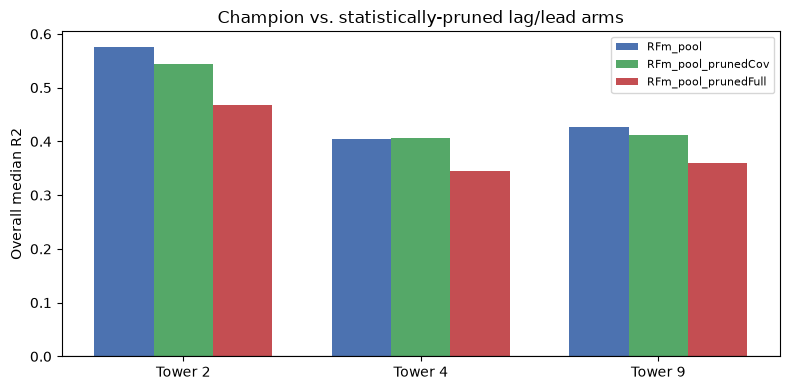

In [136]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
models = ["RFm_pool", "RFm_pool_prunedCov", "RFm_pool_prunedFull"]
colors = {"RFm_pool": "#4C72B0", "RFm_pool_prunedCov": "#55A868", "RFm_pool_prunedFull": "#C44E52"}
xpos = np.arange(len(TOWERS))
for i, m in enumerate(models):
    if m == "RFm_pool":
        vals = [CHAMPION_R2[t] for t in TOWERS]
    else:
        vals = [R_PRUNED.loc[(R_PRUNED.tower == t) & (R_PRUNED.model == m), "R2_overall"].iloc[0] for t in TOWERS]
    ax.bar(xpos + (i - 1) * width, vals, width, label=m, color=colors[m])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Overall median R2"); ax.set_title("Champion vs. statistically-pruned lag/lead arms")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 7.4 Discussion

State the outcome plainly either way, using the same noise-band framing already established at D-75/D-78
(deltas inside roughly ±0.01-0.02 are within this notebook's documented cross-run noise, not a real signal
regardless of which side of zero they land on):

- **If `prunedCov`/`prunedFull` beat the champion outside noise at all 3 towers**: the more rigorous,
  statistically-derived lag/lead set is a genuine improvement over the a priori `LAG_HOURS` grid, and is a
  concrete candidate to adopt into `frame()`/`FEATURES` in a future session.
- **If deltas are inside noise or negative (matching D-75/D-78's own prior pattern)**: this confirms --
  now via a principled, auditable method rather than another a priori guess -- that the pooled RFm
  architecture already captures whatever soil-moisture/temperature/target memory is extractable from these
  variables (via the current `FEATURES` set's cyclical time features, current-timestep drivers, GPP/Reco,
  and livestock density), and no further lag/lead engineering on these three variables is worth pursuing.

Either way, this section's real contribution is the auditable `FINAL_LAGLEAD` derivation itself (section
6), not just the empirical delta -- if a future session wants to revisit this with a different `MAXLAG`,
`K_MAX_SHARED`, or pruning threshold, the diagnostics in section 6 are reusable without re-deriving the
methodology.

---

## 8. `fill_mode` / Area-of-Applicability cross-check

No new RF fits -- reuses the already-fit production model (`frames_prod`, section 4.7),
`FCH4_GAPFILLED_WITH_UQ` (section 5.3), and `prev_next_obs`/`MAX_NEIGHBOUR_H` (section 4.3.b.4/4.3.b.1).
For each tower's production series, labels every gap-filled hour `interpolative` (both a real neighbour
before and after, within `MAX_NEIGHBOUR_H`) vs. `driver_only` (missing one or both), and correlates the
neighbour-distance (`gap_width`) against the existing `dissimilarity_index`/`outside_aoa` (section 5)
reliability flag. Answers directly: is the existing AOA flag already sensitive to how far a point is
from a real observation, or would `fill_mode` be a genuinely new, complementary signal?

In [137]:
def fill_mode_aoa_check():
    parts = []
    for t in TOWERS:
        g = frames_prod[t]; dm = dom_mask(g.index, t)
        nb = prev_next_obs(g.loc[dm, "target"], MAX_NEIGHBOUR_H)
        sub = FCH4_GAPFILLED_WITH_UQ[FCH4_GAPFILLED_WITH_UQ.tower == t].set_index("Datetime")
        sub = sub.join(nb[["h_prev", "h_next", "gap_width", "has_prev", "has_next"]])
        sub["fill_mode"] = np.select(
            [sub["y_observed"].notna(), (sub["has_prev"] == 1) & (sub["has_next"] == 1)],
            ["observed", "interpolative"], default="driver_only")
        parts.append(sub.reset_index())
    fm = pd.concat(parts, ignore_index=True)

    gapfilled = fm[fm["y_observed"].isna()]
    corr_p = gapfilled["gap_width"].corr(gapfilled["dissimilarity_index"])
    corr_s = gapfilled["gap_width"].corr(gapfilled["dissimilarity_index"], method="spearman")
    ctab = pd.crosstab(gapfilled["fill_mode"], gapfilled["outside_aoa"], normalize="index")
    print(f"Pearson(gap_width, dissimilarity_index), gap-filled hours only: {corr_p:+.3f}")
    print(f"Spearman(gap_width, dissimilarity_index): {corr_s:+.3f}")
    print("\nfill_mode distribution (gap-filled hours):")
    print(gapfilled["fill_mode"].value_counts())
    print("\n% outside AOA by fill_mode:")
    print(ctab)

    fm.to_csv(DATA_DIR / "fill_mode_aoa_check.csv", index=False)
    print(f"\nSaved {DATA_DIR/'fill_mode_aoa_check.csv'}  ({len(fm):,} rows)")
    return fm, gapfilled


FCH4_FILL_MODE, _gapfilled_fm = fill_mode_aoa_check()
FCH4_FILL_MODE.head()

Pearson(gap_width, dissimilarity_index), gap-filled hours only: +0.212
Spearman(gap_width, dissimilarity_index): +0.290

fill_mode distribution (gap-filled hours):
fill_mode
interpolative    38432
driver_only      30337
Name: count, dtype: int64

% outside AOA by fill_mode:
outside_aoa       False     True 
fill_mode                        
driver_only    0.519926  0.480074
interpolative  0.746748  0.253252



Saved _data\fill_mode_aoa_check.csv  (104,355 rows)


,Datetime,tower,y_observed,y_gapfilled,dissimilarity_index,outside_aoa,h_prev,h_next,gap_width,has_prev,has_next,fill_mode
0,2017-10-01 00:00:00,2,NaN,17.973340,3.276476,True,NaN,NaN,NaN,0.0,0.0,driver_only
1,2017-10-01 01:00:00,2,NaN,17.545792,3.199887,True,NaN,NaN,NaN,0.0,0.0,driver_only
2,2017-10-01 02:00:00,2,NaN,16.802216,3.126413,True,NaN,NaN,NaN,0.0,0.0,driver_only
3,2017-10-01 03:00:00,2,NaN,15.068316,3.022668,True,NaN,NaN,NaN,0.0,0.0,driver_only
4,2017-10-01 04:00:00,2,NaN,15.035892,3.075253,True,NaN,NaN,NaN,0.0,0.0,driver_only


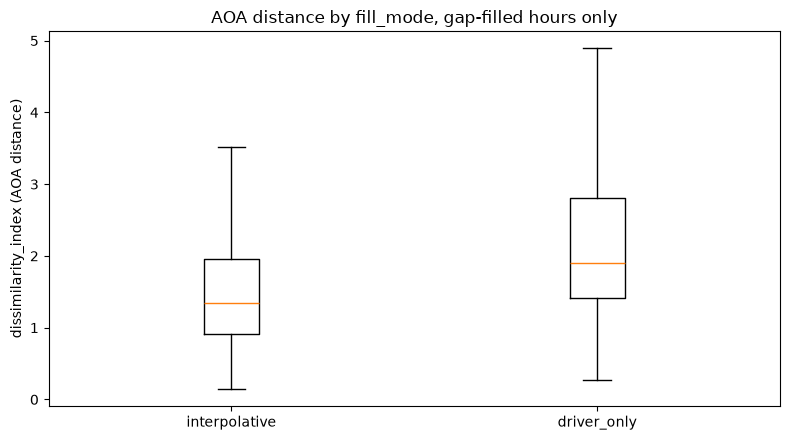

In [138]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = ["interpolative", "driver_only"]
data = [_gapfilled_fm.loc[_gapfilled_fm.fill_mode == m, "dissimilarity_index"].dropna() for m in order]
ax.boxplot(data, tick_labels=order, showfliers=False)
ax.set_ylabel("dissimilarity_index (AOA distance)")
ax.set_title("AOA distance by fill_mode, gap-filled hours only")
plt.tight_layout(); plt.show()

---

## 9. Daily-resolution prediction intervals

This notebook doesn't build hourly QRF/TabICL prediction intervals, so there's no existing hourly
band to propagate down -- but even if it did, propagating an hourly `q05`/`q95` band up to daily
resolution would require an unproven assumption about how hourly errors correlate within a day, so
building the daily interval directly is the right choice regardless. Mirroring section 4.6/4.6's
own precedent for point estimates (`groupby(index.normalize()).mean()` / `.resample("D").mean()`),
this section aggregates **point predictions** to daily, measures **genuine daily-level residuals
from held-out data**, and applies **split-conformal calibration directly on those real daily
residuals** -- the same mechanism as this project's own `conformal_margins_by_bin` (U-02,
`src/models/recursive_rollout.py`), adapted here from "lead-time bin" to "tower", and reimplemented
locally below (this notebook's zero-`src/`-dependency convention, same pattern as
`dissimilarity_index()` in section 5).

**Scope: "l" (288h) scenario only.** Matching section 4.6's own precedent and reasoning exactly.
The next cell checks empirically whether "m" (32h) should also be included, since 32h nominally
spans more than one calendar day.

**Aggregation: daily mean (primary; no daily-sum variant).** Matches section 4.7's own daily-mean
view, and stays comparable across days regardless of how many real hours happen to fall on them
(unlike a sum), which matters for days that are entirely gap-filled.

**Reused without modification:** `HELD_OUT_PAIRS_L`, `DAILY_R2`, `FCH4_GAPFILLED` (section 4.6/4.6),
`TOWERS`, `DATA_DIR`. `FIG_DIR` is introduced here (this notebook hadn't previously saved figures to
disk). No new Random Forest is fit anywhere in this section -- this reuses the exact same
"l"-scenario held-out points section 4.6 already validated, so there is no new randomness or scope
creep relative to the champion's own established evaluation.

In [139]:
FIG_DIR = Path("_figures")
FIG_DIR.mkdir(exist_ok=True)

# Empirical check backing the scope decision above: does a 32h ("m") gap actually cover full
# calendar days, or mostly partial ones -- unlike "l" (288h), which section 4.6 already uses?
# Cheap, no model fitting -- just the gap-placement mechanism itself (insert_calendar_gaps,
# section 2.4), reusing DOMAIN/dom_mask/frame exactly as section 4.6's own held-out mechanism does.
@timeit
def frac_fully_masked_days(t, gap_hours, n_reps=1, seed=0):
    g = frame(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    gt = insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps, seed=seed)[0]
    if len(gt) == 0:
        return np.nan, 0
    hours_per_day = pd.DatetimeIndex(gt).normalize().value_counts()
    return (hours_per_day == 24).mean(), len(hours_per_day)


print("Fraction of touched calendar days that are FULLY (24/24h) masked, per scenario:")
for sc_label, gh in [("m (32h)", 32), ("l (288h, used below)", 288)]:
    for t in TOWERS:
        frac_full, n_days = frac_fully_masked_days(t, gh)
        print(f"  {sc_label:22s} Tower {t}: {frac_full:.1%} of {n_days} touched days fully masked")

Fraction of touched calendar days that are FULLY (24/24h) masked, per scenario:


  m (32h)                Tower 2: 0.0% of 176 touched days fully masked


  m (32h)                Tower 4: 0.0% of 676 touched days fully masked


  m (32h)                Tower 9: 0.0% of 407 touched days fully masked


  l (288h, used below)   Tower 2: 0.0% of 122 touched days fully masked


  l (288h, used below)   Tower 4: 0.0% of 517 touched days fully masked


  l (288h, used below)   Tower 9: 0.0% of 291 touched days fully masked


### 9.1 Validation: split-conformal calibration on genuinely held-out daily residuals

Reuses `HELD_OUT_PAIRS_L` (section 4.6) directly, aggregated to one row per `(tower, calendar day)`
via the same `groupby(index.normalize()).mean()` convention section 4.6 already uses --
`resid = actual - pred` at daily resolution. Per tower (not pooled, not scenario-binned -- only one
scenario is in scope here), each tower's held-out days are split 50/50 into a calibration half
(computes the margin) and a genuinely held-out test half (verifies the resulting coverage) -- a
standard split-conformal design, avoiding the circularity of validating on the same days used to
build the margin. The margin is the standard split-conformal finite-sample-corrected quantile of
the calibration half's absolute residuals (Lei et al. 2018 / Romano et al. 2019 -- same formula as
this project's own `conformal_margins_by_bin`, `src/models/recursive_rollout.py`, reimplemented
locally here per this notebook's zero-`src/`-dependency convention); the resulting calibrated
interval for a point prediction `p` is `[p - margin, p + margin]`. Coverage/width on the test half
are scored with local `picp`/`mpiw` reimplementations (mirroring `src/evaluation/metrics.py`). A
naive Gaussian-approximation band (`1.645 x calibration-half daily RMSE`) is reported alongside
purely as a sanity comparison -- FCH4 is a known heavy-tailed, episodic-spike variable, so a
parametric-normal band is not expected to calibrate as well as the distribution-free conformal one.

In [140]:
DAILY_ALPHA = 0.10  # 90% target interval


@timeit
def conformal_margin_abs_residual(residuals, alpha=0.10):
    """Standard split-conformal (Lei et al. 2018 / Romano et al. 2019) finite-sample-corrected
    quantile of absolute residuals -- mirrors this project's own conformal_margins_by_bin()
    (src/models/recursive_rollout.py), reimplemented locally per this notebook's zero-src-
    dependency convention. Calibrated interval for a point prediction p is [p - margin, p + margin]."""
    res = np.asarray(residuals, float)
    res = res[np.isfinite(res)]
    n = len(res)
    if n == 0:
        return np.nan
    level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(np.abs(res), level))


@timeit
def picp_local(y, lo, hi):
    """Prediction Interval Coverage Probability -- mirrors src/evaluation/metrics.py's picp()."""
    y = np.asarray(y, float); lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    m = np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
    return float(np.mean((y[m] >= lo[m]) & (y[m] <= hi[m]))) if m.sum() > 0 else np.nan


@timeit
def mpiw_local(lo, hi):
    """Mean Prediction Interval Width -- mirrors src/evaluation/metrics.py's mpiw()."""
    lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    m = np.isfinite(lo) & np.isfinite(hi)
    return float(np.mean(hi[m] - lo[m])) if m.sum() > 0 else np.nan


rng_daily = np.random.default_rng(44)  # fresh, independent seed for this calibration split
DAILY_CONFORMAL_MARGINS = {}
daily_conformal_rows = []
DAILY_PAIRS_PARTS = []

for t in TOWERS:
    sub = HELD_OUT_PAIRS_L[HELD_OUT_PAIRS_L.tower == t].set_index("Datetime")
    daily = sub.groupby(sub.index.normalize())[["actual", "pred"]].mean()
    daily["resid"] = daily["actual"] - daily["pred"]
    daily = daily.reset_index()
    daily["tower"] = t
    DAILY_PAIRS_PARTS.append(daily)

    idx = rng_daily.permutation(len(daily))
    half = len(idx) // 2
    cal, test = daily.iloc[idx[:half]], daily.iloc[idx[half:]]
    assert set(cal.index) & set(test.index) == set(), "calibration/test split overlap"
    assert len(cal) + len(test) == len(daily), "calibration/test split lost rows"

    margin = conformal_margin_abs_residual(cal["resid"].values, alpha=DAILY_ALPHA)
    DAILY_CONFORMAL_MARGINS[t] = margin

    test_lo = test["pred"] - margin
    test_hi = test["pred"] + margin
    picp_test = picp_local(test["actual"].values, test_lo.values, test_hi.values)
    mpiw_test = mpiw_local(test_lo.values, test_hi.values)

    naive_margin = 1.645 * np.sqrt(np.mean(cal["resid"].values ** 2))
    naive_lo = test["pred"] - naive_margin
    naive_hi = test["pred"] + naive_margin
    picp_naive = picp_local(test["actual"].values, naive_lo.values, naive_hi.values)

    daily_conformal_rows.append({
        "tower": t, "n_cal_days": len(cal), "n_test_days": len(test),
        "conformal_margin": round(margin, 2),
        "PICP_test_conformal": round(picp_test, 3), "MPIW_test_conformal": round(mpiw_test, 2),
        "naive_normal_margin": round(naive_margin, 2), "PICP_test_naive_normal": round(picp_naive, 3),
    })
    print(f"Tower {t}: {len(daily)} held-out days ({len(cal)} cal / {len(test)} test) | "
          f"conformal margin=+/-{margin:.2f}  PICP={picp_test:.3f} (target 0.90)  MPIW={mpiw_test:.2f} | "
          f"naive normal margin=+/-{naive_margin:.2f}  PICP={picp_naive:.3f}")

DAILY_CONFORMAL_SUMMARY = pd.DataFrame(daily_conformal_rows)
DAILY_PAIRS_L = pd.concat(DAILY_PAIRS_PARTS, ignore_index=True)
DAILY_CONFORMAL_SUMMARY.to_csv(DATA_DIR / "daily_conformal_calibration_summary.csv", index=False)
print(f"\nSaved {DATA_DIR/'daily_conformal_calibration_summary.csv'} ({len(DAILY_CONFORMAL_SUMMARY)} rows)")
DAILY_CONFORMAL_SUMMARY

Tower 2: 224 held-out days (112 cal / 112 test) | conformal margin=+/-52.36  PICP=0.866 (target 0.90)  MPIW=104.72 | naive normal margin=+/-50.51  PICP=0.866
Tower 4: 860 held-out days (430 cal / 430 test) | conformal margin=+/-80.76  PICP=0.923 (target 0.90)  MPIW=161.52 | naive normal margin=+/-83.28  PICP=0.935
Tower 9: 490 held-out days (245 cal / 245 test) | conformal margin=+/-62.34  PICP=0.861 (target 0.90)  MPIW=124.67 | naive normal margin=+/-79.46  PICP=0.910

Saved _data\daily_conformal_calibration_summary.csv (3 rows)


,tower,n_cal_days,n_test_days,conformal_margin,PICP_test_conformal,MPIW_test_conformal,naive_normal_margin,PICP_test_naive_normal
0,2,112,112,52.36,0.866,104.72,50.51,0.866
1,4,430,430,80.76,0.923,161.52,83.28,0.935
2,9,245,245,62.34,0.861,124.67,79.46,0.910


### 9.2 Figure: daily coverage vs. the 90% nominal target, conformal vs. naive-normal

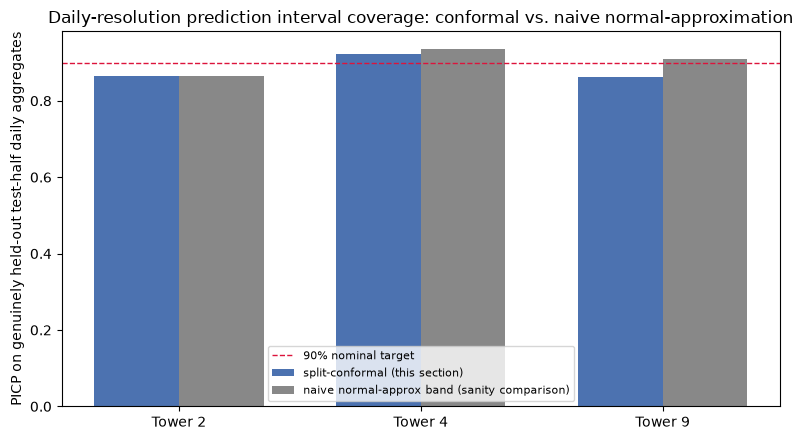

Saved _figures\daily_calibration_reliability.png


In [141]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xpos = np.arange(len(TOWERS)); width = 0.35
conformal_vals = [DAILY_CONFORMAL_SUMMARY.loc[DAILY_CONFORMAL_SUMMARY.tower == t, "PICP_test_conformal"].iloc[0] for t in TOWERS]
naive_vals = [DAILY_CONFORMAL_SUMMARY.loc[DAILY_CONFORMAL_SUMMARY.tower == t, "PICP_test_naive_normal"].iloc[0] for t in TOWERS]
ax.bar(xpos - width / 2, conformal_vals, width, label="split-conformal (this section)", color="#4C72B0")
ax.bar(xpos + width / 2, naive_vals, width, label="naive normal-approx band (sanity comparison)", color="#888888")
ax.axhline(0.90, color="crimson", ls="--", lw=1, label="90% nominal target")
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("PICP on genuinely held-out test-half daily aggregates")
ax.set_title("Daily-resolution prediction interval coverage: conformal vs. naive normal-approximation")
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = FIG_DIR / "daily_calibration_reliability.png"
plt.savefig(fig_path, dpi=110)
plt.show()
print(f"Saved {fig_path}")

### 9.3 Production: calibrated daily interval on the real gap-filled series

Applies the **same** per-tower margins computed from the calibration half in 9.1
(`DAILY_CONFORMAL_MARGINS`) to the already-built daily-mean production series (section 4.7's
`.resample("D").mean()` view of `FCH4_GAPFILLED`) -- validate once, reuse in production, no separate
production-only refit. Each day is also tagged with `n_real_hours` (how many of its 24 hours are
real observations), so fully-real, fully-gap-filled, and partially-observed days are
distinguishable. **Caveat carried over from section 4.7, restated:** for any day with real hours
present, the point estimate is not out-of-sample; the coverage claim validated in 9.1/9.2 is a
statement about the *method* (verified on genuinely held-out days), not a fresh accuracy claim
about every day shown here.

In [142]:
FCH4_DAILY_INTERVALS_CAL_PARTS = []
for t in TOWERS:
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_pred = sub["y_gapfilled"].resample("D").mean()
    daily_obs = sub["y_observed"].resample("D").mean()
    n_real_hours = sub["y_observed"].notna().resample("D").sum()

    margin = DAILY_CONFORMAL_MARGINS[t]
    part = pd.DataFrame({
        "tower": t,
        "y_gapfilled_daily_mean": daily_pred,
        "y_observed_daily_mean": daily_obs,
        "n_real_hours": n_real_hours,
        "daily_q05_cal": daily_pred - margin,
        "daily_q95_cal": daily_pred + margin,
    })
    part["is_fully_gapfilled_day"] = part["n_real_hours"] == 0
    FCH4_DAILY_INTERVALS_CAL_PARTS.append(part.reset_index())

FCH4_DAILY_INTERVALS_CAL = pd.concat(FCH4_DAILY_INTERVALS_CAL_PARTS, ignore_index=True)
FCH4_DAILY_INTERVALS_CAL.to_csv(DATA_DIR / "fch4_daily_gapfilled_with_intervals.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_daily_gapfilled_with_intervals.csv'}  ({len(FCH4_DAILY_INTERVALS_CAL):,} rows)")

print("\nApplied per-tower conformal margins (from 9.1's calibration half):")
for t in TOWERS:
    print(f"  Tower {t}: +/-{DAILY_CONFORMAL_MARGINS[t]:.2f}")

n_fully_gf = FCH4_DAILY_INTERVALS_CAL["is_fully_gapfilled_day"].sum()
print(f"\n{n_fully_gf:,} / {len(FCH4_DAILY_INTERVALS_CAL):,} days are fully gap-filled (zero real hourly observations).")
FCH4_DAILY_INTERVALS_CAL.head()

Saved _data\fch4_daily_gapfilled_with_intervals.csv  (4,351 rows)

Applied per-tower conformal margins (from 9.1's calibration half):
  Tower 2: +/-52.36
  Tower 4: +/-80.76
  Tower 9: +/-62.34

949 / 4,351 days are fully gap-filled (zero real hourly observations).


,Datetime,tower,y_gapfilled_daily_mean,y_observed_daily_mean,n_real_hours,daily_q05_cal,daily_q95_cal,is_fully_gapfilled_day
0,2017-10-01,2,16.386483,NaN,0,-35.971571,68.744536,True
1,2017-10-02,2,13.864358,NaN,0,-38.493696,66.222411,True
2,2017-10-03,2,17.381642,NaN,0,-34.976411,69.739695,True
3,2017-10-04,2,1.372773,NaN,0,-50.985280,53.730827,True
4,2017-10-05,2,31.703169,NaN,0,-20.654884,84.061223,True


### 9.4 Figure: production daily series with the calibrated interval

The **full domain** is shown here at daily resolution (not zoomed to a 90-day window like section
4.6's hourly zoom) -- the same choice section 4.7's own daily-mean plot already made, since daily
aggregation compresses a multi-year record to a readable width.

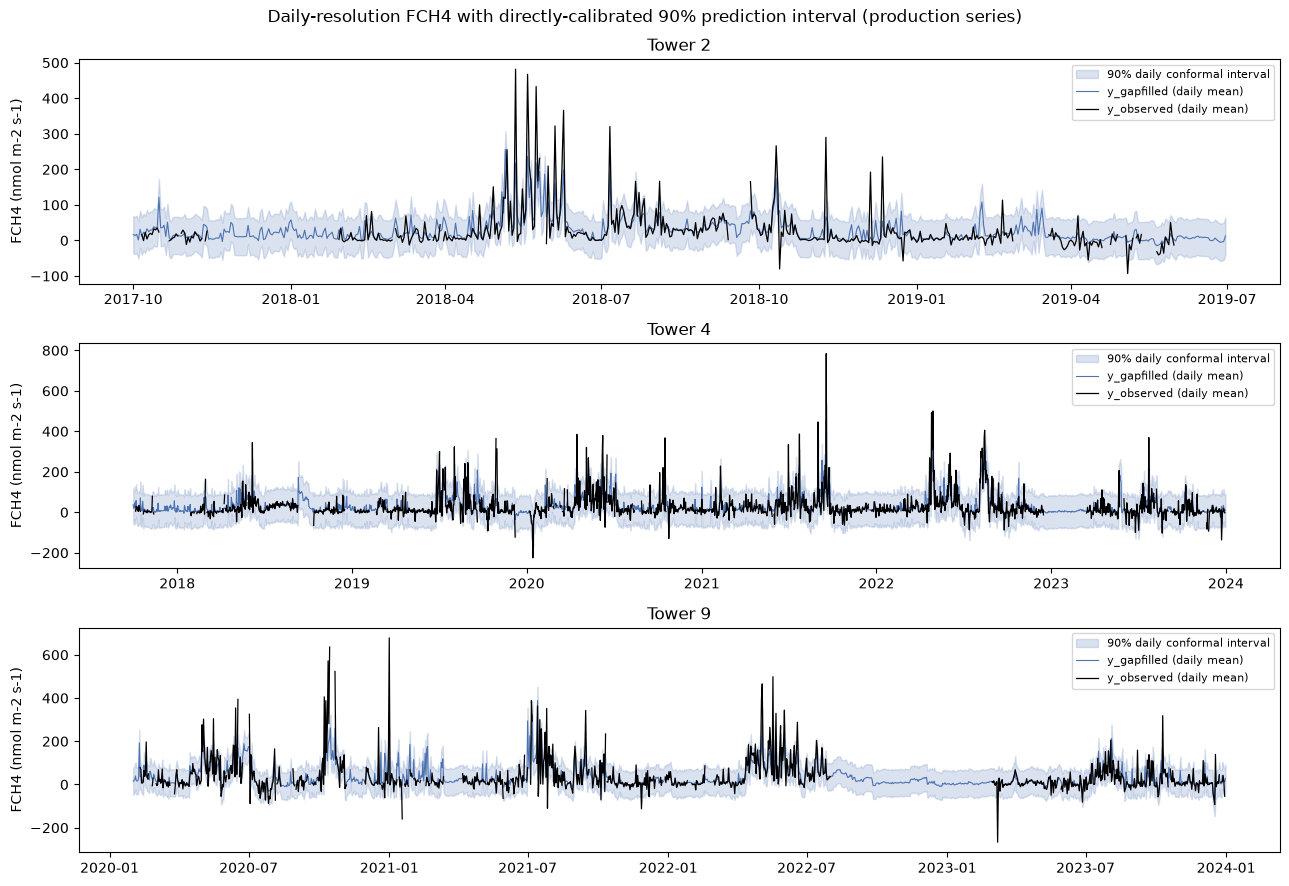

Saved _figures\daily_production_intervals.png


In [143]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_DAILY_INTERVALS_CAL[FCH4_DAILY_INTERVALS_CAL.tower == t].set_index("Datetime")
    ax.fill_between(sub.index, sub["daily_q05_cal"], sub["daily_q95_cal"], color="#4C72B0", alpha=0.2,
                     label="90% daily conformal interval")
    ax.plot(sub.index, sub["y_gapfilled_daily_mean"], color="#4C72B0", lw=0.8, label="y_gapfilled (daily mean)")
    ax.plot(sub.index, sub["y_observed_daily_mean"], color="black", lw=0.9, label="y_observed (daily mean)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily-resolution FCH4 with directly-calibrated 90% prediction interval (production series)")
plt.tight_layout()
fig_path = FIG_DIR / "daily_production_intervals.png"
plt.savefig(fig_path, dpi=110)
plt.show()
print(f"Saved {fig_path}")

---

## 10. Daily R2, full scenario scope (extending section 4.6 from "l"-only to all 5 scenarios)

Section 4.5 computed a genuine daily R2, but restricted to the "l" (288h) scenario only, so it is
**not** directly comparable to the champion's own headline R2 (section 4.5, median across all 5
scenarios at hourly resolution). This section closes that gap: extends section 4.6's exact method
(`run_rf_capture` -> `groupby(index.normalize()).mean()` -> `r2_score`) to every scenario in
`SCENARIOS`, then takes the median across scenarios the same way the champion's own headline number
is computed -- giving a true daily-resolution counterpart to the hourly headline, not just the
hardest-scenario slice.

**Expected to be fast**: `run_rf_capture` calls the exact same `fit()` with the exact same
`(feat, trd)` folds the champion's own `run_rf` (section 4.2/4.3) already used for all 5 scenarios
-- essentially every RF fit needed here should already be sitting in `_model_cache/`. No new
randomness, no new methodology, purely an extension of what section 4.6 already validated.

**Caveat carried over from section 4.6's own reasoning, not resolved here**: for the shortest
scenarios (`vs`=1h, `s`=4h), a "day" may be built from just 1-4 masked hours rather than a fuller
sample -- reported as-is, with the per-scenario breakdown shown so this isn't hidden inside a
single blended number.

In [144]:
DAILY_R2_FULL_ROWS = []
DAILY_PAIRS_ALL_SCENARIOS_PARTS = []
t0 = time.time()

for t in TOWERS:
    per_scenario_daily_r2 = {}
    for sc, gh in SCENARIOS.items():
        pairs = run_rf_capture(t, pooled=True, gap_hours=gh, n_reps=N_REPS)
        if len(pairs) < 5:
            per_scenario_daily_r2[sc] = np.nan
            continue
        daily = pairs.groupby(pairs.index.normalize()).mean()
        daily_r2 = r2_score(daily["actual"], daily["pred"]) if len(daily) > 1 else np.nan
        per_scenario_daily_r2[sc] = daily_r2
        DAILY_PAIRS_ALL_SCENARIOS_PARTS.append(
            pairs.assign(tower=t, scenario=sc).reset_index().rename(columns={"index": "Datetime"})
        )

    median_daily_r2 = float(np.nanmedian(list(per_scenario_daily_r2.values())))
    row = {"tower": t, "R2_daily_median": round(median_daily_r2, 3)}
    row.update({f"R2_daily_{sc}": (round(v, 3) if pd.notna(v) else np.nan) for sc, v in per_scenario_daily_r2.items()})
    DAILY_R2_FULL_ROWS.append(row)
    print(f"Tower {t}: daily R2 median (all 5 scenarios) = {median_daily_r2:+.3f}  "
          f"[{time.time()-t0:.0f}s elapsed]")
    print(f"    per-scenario: " + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in per_scenario_daily_r2.items()))

DAILY_R2_FULL = pd.DataFrame(DAILY_R2_FULL_ROWS).set_index("tower")
DAILY_PAIRS_ALL_SCENARIOS = pd.concat(DAILY_PAIRS_ALL_SCENARIOS_PARTS, ignore_index=True)
DAILY_R2_FULL.to_csv(DATA_DIR / "daily_r2_full_scope.csv")
print(f"\nSaved {DATA_DIR/'daily_r2_full_scope.csv'}")
print(f"\nFor comparison -- champion hourly headline R2 (median across 5 scenarios): "
      f"T2={R.loc[(R.tower==2)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}  "
      f"T4={R.loc[(R.tower==4)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}  "
      f"T9={R.loc[(R.tower==9)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}")
DAILY_R2_FULL

Tower 2: daily R2 median (all 5 scenarios) = +0.698  [6s elapsed]
    per-scenario: vs=+0.698, s=+0.805, m=+0.788, l=+0.207, m1=+0.697


Tower 4: daily R2 median (all 5 scenarios) = +0.504  [12s elapsed]
    per-scenario: vs=+0.504, s=+0.571, m=+0.359, l=+0.321, m1=+0.532


Tower 9: daily R2 median (all 5 scenarios) = +0.485  [18s elapsed]
    per-scenario: vs=+0.524, s=+0.336, m=+0.377, l=+0.504, m1=+0.485

Saved _data\daily_r2_full_scope.csv

For comparison -- champion hourly headline R2 (median across 5 scenarios): T2=+0.576  T4=+0.404  T9=+0.426


,R2_daily_median,R2_daily_vs,R2_daily_s,R2_daily_m,R2_daily_l,R2_daily_m1
tower,,,,,,
2,0.698,0.698,0.805,0.788,0.207,0.697
4,0.504,0.504,0.571,0.359,0.321,0.532
9,0.485,0.524,0.336,0.377,0.504,0.485


### 10.1 Sensitivity to daily coverage: unweighted vs. >=50% threshold vs. hour-count weighted

Section 10's `DAILY_R2_FULL` treats every day identically regardless of how many real, held-out
hours built its daily mean -- a day represented by 1 hour counts the same as a day represented by
24. This subsection checks how sensitive that number is to that choice, using the standard
FLUXNET/AmeriFlux-style completeness convention (a daily aggregate is only considered valid with
>=50% of sub-daily values present) alongside a softer, sample-size-weighted alternative
(`sklearn.metrics.r2_score`'s own `sample_weight` argument, weighting each day's contribution by
how many real hours it was built from -- no hand-rolled formula needed).

**Purely additive**: `DAILY_R2_FULL`/`daily_r2_full_scope.csv` (above) are left completely
untouched. This produces a *new* table, `DAILY_R2_VARIANTS`, reporting all three variants side by
side -- unweighted/unfiltered (identical to the number above, reproduced here only for direct
comparison), >=50%-coverage-only, and hour-count-weighted -- plus how many days survive the
coverage threshold per scenario (expected to matter most for the shortest scenarios, `vs`/`s`,
where a single held-out block is far shorter than a day).

In [145]:
COVERAGE_THRESHOLD = 0.5  # standard FLUXNET/AmeriFlux completeness convention (>=50% of hours present)
MIN_HOURS = int(24 * COVERAGE_THRESHOLD)  # 12

daily_r2_variants_rows = []
t0 = time.time()

for t in TOWERS:
    unweighted_per_sc, hardthresh_per_sc, weighted_per_sc = {}, {}, {}
    n_days_total_per_sc, n_days_surviving_per_sc = {}, {}

    for sc, gh in SCENARIOS.items():
        pairs = run_rf_capture(t, pooled=True, gap_hours=gh, n_reps=N_REPS)
        if len(pairs) < 5:
            unweighted_per_sc[sc] = hardthresh_per_sc[sc] = weighted_per_sc[sc] = np.nan
            n_days_total_per_sc[sc] = n_days_surviving_per_sc[sc] = 0
            continue

        daily_mean = pairs.groupby(pairs.index.normalize())[["actual", "pred"]].mean()
        n_hours = pairs.groupby(pairs.index.normalize()).size()
        daily = daily_mean.join(n_hours.rename("n_hours"))
        n_days_total_per_sc[sc] = len(daily)

        # (a) unweighted, unfiltered -- identical calculation to the DAILY_R2_FULL cell above
        unweighted_per_sc[sc] = r2_score(daily["actual"], daily["pred"]) if len(daily) > 1 else np.nan

        # (b) hard threshold -- FLUXNET/AmeriFlux-style >=50% coverage requirement
        daily_thresh = daily[daily["n_hours"] >= MIN_HOURS]
        n_days_surviving_per_sc[sc] = len(daily_thresh)
        hardthresh_per_sc[sc] = r2_score(daily_thresh["actual"], daily_thresh["pred"]) if len(daily_thresh) > 1 else np.nan

        # (c) weighted -- every day kept, weighted by how many real hours built it (sklearn's
        # own sample_weight support -- weighted SS_res / weighted SS_tot, no hand-rolled formula)
        weighted_per_sc[sc] = (r2_score(daily["actual"], daily["pred"], sample_weight=daily["n_hours"])
                                if len(daily) > 1 else np.nan)

    row = {
        "tower": t,
        "R2_unweighted_median": round(float(np.nanmedian(list(unweighted_per_sc.values()))), 3),
        "R2_hardthreshold50_median": round(float(np.nanmedian(list(hardthresh_per_sc.values()))), 3),
        "R2_weighted_median": round(float(np.nanmedian(list(weighted_per_sc.values()))), 3),
    }
    daily_r2_variants_rows.append(row)

    print(f"Tower {t}  [{time.time()-t0:.0f}s elapsed]")
    print(f"  unweighted/unfiltered : median={row['R2_unweighted_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in unweighted_per_sc.items()))
    print(f"  >=50% coverage only   : median={row['R2_hardthreshold50_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in hardthresh_per_sc.items()))
    print(f"  hour-count weighted   : median={row['R2_weighted_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in weighted_per_sc.items()))
    print(f"  days surviving >=50% threshold per scenario: "
          + ", ".join(f"{sc}={n_days_surviving_per_sc[sc]}/{n_days_total_per_sc[sc]}" for sc in SCENARIOS))
    print()

DAILY_R2_VARIANTS = pd.DataFrame(daily_r2_variants_rows).set_index("tower")
DAILY_R2_VARIANTS.to_csv(DATA_DIR / "daily_r2_coverage_sensitivity.csv")
print(f"Saved {DATA_DIR/'daily_r2_coverage_sensitivity.csv'}")
DAILY_R2_VARIANTS

Tower 2  [5s elapsed]
  unweighted/unfiltered : median=+0.698  vs=+0.698, s=+0.805, m=+0.788, l=+0.207, m1=+0.697
  >=50% coverage only   : median=+0.638  vs=+0.568, s=+0.898, m=+0.922, l=+0.547, m1=+0.638
  hour-count weighted   : median=+0.721  vs=+0.687, s=+0.804, m=+0.842, l=+0.429, m1=+0.721
  days surviving >=50% threshold per scenario: vs=12/457, s=29/431, m=77/290, l=96/224, m1=95/258



Tower 4  [10s elapsed]
  unweighted/unfiltered : median=+0.504  vs=+0.504, s=+0.571, m=+0.359, l=+0.321, m1=+0.532
  >=50% coverage only   : median=+0.446  vs=+0.703, s=+0.315, m=+0.638, l=+0.405, m1=+0.446
  hour-count weighted   : median=+0.528  vs=+0.554, s=+0.579, m=+0.498, l=+0.398, m1=+0.528
  days surviving >=50% threshold per scenario: vs=50/1826, s=121/1707, m=285/1119, l=374/860, m1=346/1043



Tower 9  [15s elapsed]
  unweighted/unfiltered : median=+0.485  vs=+0.524, s=+0.336, m=+0.377, l=+0.504, m1=+0.485
  >=50% coverage only   : median=+0.586  vs=+0.753, s=+0.586, m=+0.661, l=+0.372, m1=+0.576
  hour-count weighted   : median=+0.498  vs=+0.575, s=+0.498, m=+0.492, l=+0.487, m1=+0.563
  days surviving >=50% threshold per scenario: vs=22/1023, s=72/967, m=180/648, l=219/490, m1=224/606

Saved _data\daily_r2_coverage_sensitivity.csv


,R2_unweighted_median,R2_hardthreshold50_median,R2_weighted_median
tower,,,
2,0.698,0.638,0.721
4,0.504,0.446,0.528
9,0.485,0.586,0.498


### 10.2 Raw held-out pairs export (self-serve R2 verification, hourly and daily)

Every R2 number reported so far (section 4.5's hourly headline, section 4.6/10's daily figures) is
computed *inside* this notebook. This subsection exports the underlying raw material itself --
`DAILY_PAIRS_ALL_SCENARIOS` (already built by section 10's own loop, one row per held-out hour x
scenario x tower, no aggregation applied) -- so R2 can be reproduced independently (Excel, a
separate script, etc.) at both resolutions, from the exact same points this notebook evaluates on.

**What each row is**: `actual`/`pred` at a single real, quality-passed hourly observation that was
synthetically masked out of the training data for that `(tower, scenario)` run and predicted by
the RF fitted on the remaining data (`run_rf_capture`, section 4.6) -- i.e. genuinely held-out,
never used to fit the model that produced `pred` for that row. This is a *different* set of rows
than `FCH4_GAPFILLED`'s real-vs-gapfilled columns (section 4.7), which are NOT held-out (production
fit uses all real data) -- see the section 4.7 caveat. Do not use `FCH4_GAPFILLED` for R2 claims.

**How to reproduce hourly R2 yourself**: filter to one `(tower, scenario)`, then
`r2_score(actual, pred)` directly on these rows -- matches section 4.5's per-scenario number; the
champion's own headline is the **median across the 5 scenarios**, not a single pooled R2 across
them.

**How to reproduce daily R2 yourself**: filter to one `(tower, scenario)`, group by calendar date
(`Datetime.dt.normalize()` or just the date part), take the mean of `actual` and `pred` within each
day, then `r2_score` on the resulting daily table -- matches section 10's method exactly. Only
`scenario == "l"` is safe to compare against section 4.6's own daily number directly; section 10's
daily-median-across-scenarios number requires repeating this per scenario and taking the median,
same as the cell above.

In [146]:
HELD_OUT_PAIRS_EXPORT = DAILY_PAIRS_ALL_SCENARIOS.rename(columns={"actual": "y_actual", "pred": "y_pred"})
HELD_OUT_PAIRS_EXPORT = HELD_OUT_PAIRS_EXPORT[["Datetime", "tower", "scenario", "y_actual", "y_pred"]].sort_values(
    ["tower", "scenario", "Datetime"]).reset_index(drop=True)

HELD_OUT_PAIRS_EXPORT.to_csv(DATA_DIR / "held_out_pairs_all_scenarios.csv", index=False)
print(f"Saved {DATA_DIR/'held_out_pairs_all_scenarios.csv'}  ({len(HELD_OUT_PAIRS_EXPORT):,} rows)")
print(HELD_OUT_PAIRS_EXPORT.groupby(["tower", "scenario"], observed=True).size().unstack(fill_value=0))

# self-check: reproduce section 10's own per-scenario hourly + daily R2 from this exported table alone
print("\nSelf-check -- hourly R2 from the exported CSV alone (should match section 10's per-scenario numbers):")
for t in TOWERS:
    for sc in SCENARIOS:
        sub = HELD_OUT_PAIRS_EXPORT[(HELD_OUT_PAIRS_EXPORT.tower == t) & (HELD_OUT_PAIRS_EXPORT.scenario == sc)]
        if len(sub) > 1:
            print(f"  T{t} {sc}: hourly R2={r2_score(sub.y_actual, sub.y_pred):+.3f}  n={len(sub)}")
HELD_OUT_PAIRS_EXPORT.head()

Saved _data\held_out_pairs_all_scenarios.csv  (89,280 rows)
scenario     l     m    m1     s    vs
tower                                 
2         2565  2463  2465  2447  2444
4         9754  9747  9739  9735  9732
9         5682  5645  5633  5615  5614

Self-check -- hourly R2 from the exported CSV alone (should match section 10's per-scenario numbers):
  T2 vs: hourly R2=+0.630  n=2444
  T2 s: hourly R2=+0.730  n=2447
  T2 m: hourly R2=+0.710  n=2463
  T2 l: hourly R2=+0.533  n=2565
  T2 m1: hourly R2=+0.713  n=2465
  T4 vs: hourly R2=+0.436  n=9732
  T4 s: hourly R2=+0.428  n=9735
  T4 m: hourly R2=+0.405  n=9747
  T4 l: hourly R2=+0.268  n=9754
  T4 m1: hourly R2=+0.343  n=9739
  T9 vs: hourly R2=+0.461  n=5614
  T9 s: hourly R2=+0.363  n=5615
  T9 m: hourly R2=+0.424  n=5645
  T9 l: hourly R2=+0.281  n=5682
  T9 m1: hourly R2=+0.427  n=5633


,Datetime,tower,scenario,y_actual,y_pred
0,2017-10-06 12:00:00,2,l,11.274533,3.478933
1,2017-10-06 13:00:00,2,l,14.273053,3.113392
2,2017-10-06 15:00:00,2,l,58.108962,-0.822678
3,2017-10-06 16:00:00,2,l,19.997158,1.491595
4,2017-10-06 20:00:00,2,l,13.069505,11.850302


### 10.3 Raw predictions for every experiment (not just the champion)

Every experiment in this notebook (MDS, RFm_solo, RFm_pool champion, RFm met-only, 4.3.a, D1-D4,
and every TabICL rerun) up to this point only ever kept the *aggregated* median-of-medians
R2/RMSE/MAE/MBE per (tower, scenario) -- the raw `(timestamp, actual, predicted)` pairs behind
each fold were computed, fed into `mets()`, and discarded. This section captures them for real,
for every experiment, across all 3 towers and all 5 scenarios.

`insert_calendar_gaps` uses a fixed `seed=0` by default (every call site in this notebook already
relies on that), so the held-out fold structure is fully deterministic -- rerunning the exact same
`(frame_fn, feat_base)` pair through a "capture" variant reproduces byte-identical `trd` datasets
to the original run, so RF fits still hit `_model_cache/` (fast). TabICL and MDS aren't cached, but
the total number of fit calls is unchanged from the original runs -- only whether the prediction is
kept or discarded differs.

The champion (RFm_pool)'s raw pairs across all 5 scenarios already exist as `DAILY_PAIRS_ALL_SCENARIOS`
(section 10.1/10.2) -- reused directly here rather than recomputed.

In [147]:
@timeit
def run_mds_capture(t, gap_hours, n_reps):
    """Like run_mds, but returns raw (Datetime, actual, pred, rep) rows instead of aggregated
    metrics -- literature-correct 3-case hierarchy, matching run_mds."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    swin_col = f"SWIN_1_1_1 [Tower {t}]"; ta_col = f"TA_0_0_1 [Tower {t}]"; vpd_col = f"VPD_0_0_1 [Tower {t}]"
    dm = dom_mask(d.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(d, tgt, dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
        p = mds_fill_batch(d, tgt, swin_col, ta_col, list(gt), vpd_col=vpd_col); d.loc[gt, tgt] = sav
        ts_ = [x for x in gt if x in p]
        if len(ts_) >= 5:
            records.append(pd.DataFrame({"actual": sav.loc[ts_].values, "pred": [p[x] for x in ts_], "rep": rep_i}, index=ts_))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_capture_static(t, pooled, frame_fn, feat_base, fit_fn, gap_hours, n_reps):
    """Generic 'capture' harness for static (zero-leakage) feature sets -- champion/4.3.a/D1/D2/
    met-only, RF or TabICL via fit_fn. Returns raw (Datetime, actual, pred) pairs. Identical
    control flow to run_rf/run_rf_species_dens/run_rf_lagmem_soil/run_rf_livestock_mem/
    run_model_static, only the return value differs (raw pairs, not aggregated mets())."""
    feat = feat_base + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_fn(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
        if pooled:
            others = []
            for tt in towers:
                if tt == t:
                    continue
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                others.append(gg[dmt & gg["target"].notna().values])
            trd = pd.concat([trd] + others, ignore_index=True)
        m, imp = fit_fn(feat, trd)
        yp = m.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_capture_neighbor(t, pooled, fit_fn, augment, gap_hours, n_reps):
    """Generic 'capture' harness for D3's leakage-safe nearest-observation pattern (RF or TabICL
    via fit_fn). Identical leakage-safe body to run_rf_neighbor/run_model_neighbor -- same
    mask-first-then-derive-then-assert pattern, only the return value differs."""
    feat = FEAT_NEIGHBOR + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g_base = base_frames[t]; dm = dom_mask(g_base.index, t)
    aug_seed = [t * 10_000]
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        tmask = g_base["target"].copy()
        tmask.loc[tmask.index.isin(gt_ts)] = np.nan
        nb = prev_next_obs(tmask, MAX_NEIGHBOUR_H)
        g = g_base.copy()
        for col in NEIGHBOR_COLS:
            g[col] = nb[col]

        row_ts = pd.Series(g.index, index=g.index)
        src_prev = row_ts - pd.to_timedelta(g["h_prev"].fillna(0), unit="h")
        assert not ((g["has_prev"].astype(bool)) & src_prev.isin(gt_ts)).any(), \
            f"leakage: y_prev references held-out point (tower={t})"
        src_next = row_ts + pd.to_timedelta(g["h_next"].fillna(0), unit="h")
        assert not ((g["has_next"].astype(bool)) & src_next.isin(gt_ts)).any(), \
            f"leakage: y_next references held-out point (tower={t})"

        base = g[dm & g["target"].notna().values]
        trd = base.drop(index=gt, errors="ignore")
        if augment:
            extra_ts = augmented_mask(g_base["target"], dm, seed=aug_seed[0]); aug_seed[0] += 1
            tmask_aug = tmask.copy()
            tmask_aug.loc[tmask_aug.index.isin(extra_ts)] = np.nan
            nb_aug = prev_next_obs(tmask_aug, MAX_NEIGHBOUR_H)
            trd = trd.copy()
            for col in NEIGHBOR_COLS:
                trd[col] = nb_aug.loc[trd.index, col].values
        assert not gt_ts.isin(trd.index).any(), \
            f"leakage: held-out timestamps in training index (tower={t})"
        if pooled:
            others = []
            for tt in towers:
                if tt == t:
                    continue
                gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
                tmask_o = gg["target"].copy()
                nb_o = prev_next_obs(tmask_o, MAX_NEIGHBOUR_H)
                gg2 = gg.copy()
                for col in NEIGHBOR_COLS:
                    gg2[col] = nb_o[col]
                others.append(gg2[dmt & gg2["target"].notna().values])
            trd = pd.concat([trd] + others, ignore_index=True)
        m, imp = fit_fn(feat, trd)
        yp = m.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_capture_laglead_full(t, pooled, fit_fn, gap_hours, n_reps):
    """Generic 'capture' harness for D4's leakage-safe fixed-hour target lag/lead + NEIGHBOR_COLS
    pattern (RF or TabICL via fit_fn). Identical leakage-safe body to
    run_rf_laglead_full/run_model_laglead_full, only the return value differs."""
    feat = FEAT_LAGLEAD_FULL + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame_laglead_full(tt, pooled, d_all) for tt in towers}
    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in D4_LAGLEAD_HOURS:
                gg_valid[f"target_lagQ{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
                gg_valid[f"target_leadQ{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            nb_o = prev_next_obs(tgt_series, MAX_NEIGHBOUR_H)
            for col in NEIGHBOR_COLS:
                gg_valid[col] = nb_o.loc[gg_valid.index, col].values
            others_list.append(gg_valid)
    g_base = base_frames[t]; dm = dom_mask(g_base.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        g = g_base.copy()
        target_masked = g["target"].copy()
        target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
        for h in D4_LAGLEAD_HOURS:
            g[f"target_lagQ{h}"] = target_masked.shift(h)
            g[f"target_leadQ{h}"] = target_masked.shift(-h)
        nb = prev_next_obs(target_masked, MAX_NEIGHBOUR_H)
        for col in NEIGHBOR_COLS:
            g[col] = nb[col]

        for h in D4_LAGLEAD_HOURS:
            ref_ts = g.index - pd.Timedelta(hours=h)
            bad = pd.Series(ref_ts, index=g.index).isin(gt_ts) & g[f"target_lagQ{h}"].notna()
            assert not bad.any(), f"leakage: target_lagQ{h} (tower={t})"
            ref_ts2 = g.index + pd.Timedelta(hours=h)
            bad2 = pd.Series(ref_ts2, index=g.index).isin(gt_ts) & g[f"target_leadQ{h}"].notna()
            assert not bad2.any(), f"leakage: target_leadQ{h} (tower={t})"

        base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
        assert not gt_ts.isin(trd.index).any(), f"leakage: held-out timestamps in training index (tower={t})"
        if pooled:
            trd = pd.concat([trd] + others_list, ignore_index=True)
        m, imp = fit_fn(feat, trd)
        yp = m.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_mean_capture(t, gap_hours, n_reps):
    """Like run_mean, but returns raw (Datetime, actual, pred, rep) rows instead of aggregated metrics."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    dm = dom_mask(d.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(d, tgt, dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_mean = d.loc[dm & d[tgt].notna() & ~d.index.isin(gt_ts), tgt].mean()
        yp = np.full(len(gt), train_mean)
        records.append(pd.DataFrame({"actual": d.loc[gt, tgt].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_mice_capture(t, pooled, gap_hours, n_reps):
    """Like run_mice, but returns raw (Datetime, actual, pred, rep) rows instead of aggregated
    metrics. Same positional-indexing fix as run_mice (see its docstring)."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        parts = []; t_positions = None; t_part_i = None
        for i, tt in enumerate(towers):
            gg = frames[tt]; dmt = dom_mask(gg.index, tt)
            sub = gg.loc[dmt, ["target"] + feat].copy()
            if tt == t:
                t_part_i = i
                t_positions = sub.index.get_indexer(gt_ts)
                sub.iloc[t_positions, sub.columns.get_loc("target")] = np.nan
            parts.append(sub.reset_index(drop=True))
        offset = sum(len(parts[i]) for i in range(t_part_i))
        abs_positions = offset + t_positions
        mat = pd.concat(parts, ignore_index=True) if pooled else parts[0]
        imputer = IterativeImputer(random_state=42)
        filled = imputer.fit_transform(mat.values)
        target_col = mat.columns.get_loc("target")
        yp = filled[abs_positions, target_col]
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


@timeit
def run_hyperimpute_capture(t, pooled, gap_hours, n_reps):
    """Like run_hyperimpute, but returns raw (Datetime, actual, pred, rep) rows instead of
    aggregated metrics. Same positional-indexing fix as run_mice/run_hyperimpute."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        parts = []; t_positions = None; t_part_i = None
        for i, tt in enumerate(towers):
            gg = frames[tt]; dmt = dom_mask(gg.index, tt)
            sub = gg.loc[dmt, ["target"] + feat].copy()
            if tt == t:
                t_part_i = i
                t_positions = sub.index.get_indexer(gt_ts)
                sub.iloc[t_positions, sub.columns.get_loc("target")] = np.nan
            parts.append(sub.reset_index(drop=True))
        offset = sum(len(parts[i]) for i in range(t_part_i))
        abs_positions = offset + t_positions
        mat = pd.concat(parts, ignore_index=True) if pooled else parts[0]
        plugin = Imputers().get("hyperimpute", random_state=42)
        filled_df = plugin.fit_transform(mat)
        yp = filled_df.iloc[abs_positions][filled_df.columns[filled_df.columns.get_loc("target")]].values
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp, "rep": rep_i}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])


print("run_mds_capture / run_capture_static / run_capture_neighbor / run_capture_laglead_full / "
      "run_hyperimpute_capture defined.")

run_mds_capture / run_capture_static / run_capture_neighbor / run_capture_laglead_full / run_hyperimpute_capture defined.


In [148]:
ALL_RAW_PARTS = []
t0 = time.time()


def collect_pairs(experiment, model, capture_fn):
    n_before = len(ALL_RAW_PARTS)
    for t in TOWERS:
        for sc, gh in SCENARIOS.items():
            pairs = capture_fn(t, gh)
            if len(pairs) == 0:
                continue
            part = pairs.reset_index().rename(columns={"index": "Datetime", "actual": "y_actual", "pred": "y_pred"})
            part["tower"] = t; part["scenario"] = sc
            part["experiment"] = experiment; part["model"] = model
            ALL_RAW_PARTS.append(part)
    n_rows = sum(len(p) for p in ALL_RAW_PARTS[n_before:])
    print(f"done {experiment} ({model})  {n_rows:,} rows  [{time.time()-t0:.0f}s elapsed]", flush=True)


# Champion RFm_pool -- reuse the already-computed all-scenario pairs (section 10.1/10.2), not recomputed.
_champ_reuse = DAILY_PAIRS_ALL_SCENARIOS.rename(columns={"actual": "y_actual", "pred": "y_pred"}).copy()
_champ_reuse["experiment"] = "RFm_pool_champion"; _champ_reuse["model"] = "RF"
ALL_RAW_PARTS.append(_champ_reuse[["Datetime", "y_actual", "y_pred", "tower", "scenario", "rep", "experiment", "model"]])
print(f"done RFm_pool_champion (RF)  {len(_champ_reuse):,} rows  [reused from section 10, not recomputed]")

collect_pairs("MDS", "MDS", lambda t, gh: run_mds_capture(t, gh, N_REPS))
collect_pairs("Mean", "Mean", lambda t, gh: run_mean_capture(t, gh, N_REPS))
collect_pairs("MICE", "MICE", lambda t, gh: run_mice_capture(t, True, gh, N_REPS))
collect_pairs("HyperImpute", "HyperImpute", lambda t, gh: run_hyperimpute_capture(t, True, gh, N_REPS))
collect_pairs("RFm_solo", "RF", lambda t, gh: run_capture_static(t, False, frame, FEATURES, fit, gh, N_REPS))
collect_pairs("RFm_metOnly", "RF", lambda t, gh: run_capture_static(t, True, frame_met_only, FEAT_MET_ONLY, fit, gh, N_REPS))
collect_pairs("speciesDens", "RF", lambda t, gh: run_capture_static(t, True, frame_species_dens, FEAT_SPECIES_DENS, fit, gh, N_REPS))
collect_pairs("D1_lagmemSoil", "RF", lambda t, gh: run_capture_static(t, True, frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit, gh, N_REPS))
collect_pairs("D1_lagmemSoil", "TabICL", lambda t, gh: run_capture_static(t, True, frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit_tabicl, gh, N_REPS))
collect_pairs("D2_livestockMem", "RF", lambda t, gh: run_capture_static(t, True, frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit, gh, N_REPS))
collect_pairs("D2_livestockMem", "TabICL", lambda t, gh: run_capture_static(t, True, frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit_tabicl, gh, N_REPS))
collect_pairs("D3_neighborNoAug", "RF", lambda t, gh: run_capture_neighbor(t, True, fit, False, gh, N_REPS))
collect_pairs("D3_neighborNoAug", "TabICL", lambda t, gh: run_capture_neighbor(t, True, fit_tabicl, False, gh, N_REPS))
collect_pairs("D3_neighborAug", "RF", lambda t, gh: run_capture_neighbor(t, True, fit, True, gh, N_REPS))
collect_pairs("D3_neighborAug", "TabICL", lambda t, gh: run_capture_neighbor(t, True, fit_tabicl, True, gh, N_REPS))
collect_pairs("D4_laglead_full", "RF", lambda t, gh: run_capture_laglead_full(t, True, fit, gh, N_REPS))
collect_pairs("D4_laglead_full", "TabICL", lambda t, gh: run_capture_laglead_full(t, True, fit_tabicl, gh, N_REPS))

print(f"\nALL DONE in {time.time()-t0:.0f}s")

done RFm_pool_champion (RF)  89,280 rows  [reused from section 10, not recomputed]


done MDS (MDS)  89,280 rows  [11s elapsed]


done Mean (Mean)  89,280 rows  [13s elapsed]


done MICE (MICE)  89,280 rows  [516s elapsed]


done HyperImpute (HyperImpute)  89,280 rows  [5511s elapsed]


...

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

done D4_laglead_full (TabICL)  89,280 rows  [7422s elapsed]



ALL DONE in 7422s


In [149]:
ALL_RAW_PREDICTIONS = pd.concat(ALL_RAW_PARTS, ignore_index=True)
ALL_RAW_PREDICTIONS = ALL_RAW_PREDICTIONS[["experiment", "model", "tower", "scenario", "rep", "Datetime", "y_actual", "y_pred"]]
ALL_RAW_PREDICTIONS = ALL_RAW_PREDICTIONS.sort_values(["experiment", "model", "tower", "scenario", "rep", "Datetime"]).reset_index(drop=True)

print(ALL_RAW_PREDICTIONS.groupby(["experiment", "model"]).size().to_string())

ALL_RAW_PREDICTIONS.to_csv(DATA_DIR / "all_raw_predictions.csv", index=False)
print(f"\nSaved {DATA_DIR/'all_raw_predictions.csv'}  ({len(ALL_RAW_PREDICTIONS):,} rows x "
      f"{ALL_RAW_PREDICTIONS.shape[1]} cols, {(DATA_DIR/'all_raw_predictions.csv').stat().st_size/1e6:.1f} MB)")

# self-check: reproduce the already-known headline R2 numbers from this exported table alone --
# R2 per (tower, scenario, rep), THEN median across reps THEN median across scenarios, exactly
# matching mets()/med_metrics()'s own methodology (never pool reps together into one R2 call --
# insert_calendar_gaps's independent reps can select overlapping timestamps, especially for
# smaller domains like Tower 2, so pooling silently double-counts/conflates two different fits).
print("\nSelf-check -- overall (per-rep R2, median across reps, median across scenarios) from the "
      "exported CSV alone:")
for (exp, model), sub in ALL_RAW_PREDICTIONS.groupby(["experiment", "model"]):
    per_t = {}
    for t in TOWERS:
        subt = sub[sub.tower == t]
        scenario_medians = []
        for sc in SCENARIOS:
            subsc = subt[subt.scenario == sc]
            rep_r2s = [r2_score(g.y_actual, g.y_pred) for _, g in subsc.groupby("rep") if len(g) > 1]
            if rep_r2s:
                scenario_medians.append(np.nanmedian(rep_r2s))
        per_t[t] = np.nanmedian(scenario_medians) if scenario_medians else np.nan
    print(f"  {exp} ({model}): " + "  ".join(f"T{t}={v:+.3f}" for t, v in per_t.items()))
ALL_RAW_PREDICTIONS.head()

experiment         model      
D1_lagmemSoil      RF             89280
                   TabICL         89280
D2_livestockMem    RF             89280
                   TabICL         89280
D3_neighborAug     RF             89280
                   TabICL         89280
D3_neighborNoAug   RF             89280
                   TabICL         89280
D4_laglead_full    RF             89280
                   TabICL         89280
HyperImpute        HyperImpute    89280
MDS                MDS            89280
MICE               MICE           89280
Mean               Mean           89280
RFm_metOnly        RF             89280
RFm_pool_champion  RF             89280
RFm_solo           RF             89280
speciesDens        RF             89280



Saved _data\all_raw_predictions.csv  (1,607,040 rows x 8 cols, 120.5 MB)

Self-check -- overall (per-rep R2, median across reps, median across scenarios) from the exported CSV alone:
  D1_lagmemSoil (RF): T2=+0.576  T4=+0.404  T9=+0.428
  D1_lagmemSoil (TabICL): T2=+0.562  T4=+0.414  T9=+0.372
  D2_livestockMem (RF): T2=+0.601  T4=+0.395  T9=+0.425


  D2_livestockMem (TabICL): T2=+0.567  T4=+0.411  T9=+0.377
  D3_neighborAug (RF): T2=+0.537  T4=+0.359  T9=+0.385
  D3_neighborAug (TabICL): T2=+0.542  T4=+0.390  T9=+0.347
  D3_neighborNoAug (RF): T2=+0.554  T4=+0.267  T9=+0.308
  D3_neighborNoAug (TabICL): T2=+0.570  T4=+0.323  T9=+0.350
  D4_laglead_full (RF): T2=+0.543  T4=+0.262  T9=+0.293
  D4_laglead_full (TabICL): T2=+0.405  T4=+0.228  T9=+0.239
  HyperImpute (HyperImpute): T2=+0.509  T4=+0.336  T9=+0.354


  MDS (MDS): T2=-0.023  T4=-0.113  T9=-0.073
  MICE (MICE): T2=+0.081  T4=+0.118  T9=+0.107
  Mean (Mean): T2=-0.003  T4=-0.001  T9=-0.001
  RFm_metOnly (RF): T2=+0.052  T4=+0.036  T9=+0.059
  RFm_pool_champion (RF): T2=+0.576  T4=+0.404  T9=+0.426
  RFm_solo (RF): T2=+0.398  T4=+0.382  T9=+0.356
  speciesDens (RF): T2=+0.593  T4=+0.404  T9=+0.428


,experiment,model,tower,scenario,rep,Datetime,y_actual,y_pred
0,D1_lagmemSoil,RF,2,l,0,2017-10-10 15:00:00,4.802356,55.691417
1,D1_lagmemSoil,RF,2,l,0,2017-10-10 22:00:00,21.621562,42.836111
2,D1_lagmemSoil,RF,2,l,0,2017-10-10 23:00:00,13.878446,28.029528
3,D1_lagmemSoil,RF,2,l,0,2017-10-11 00:00:00,44.769662,34.507868
4,D1_lagmemSoil,RF,2,l,0,2017-10-11 01:00:00,54.165464,47.985689


---

## 11. Timing summary

Aggregate wall-clock time spent inside every `@timeit`-decorated function across the whole notebook run, sorted by total time descending -- useful for spotting the next bottleneck before it causes another multi-hour surprise (this session's `ar_select_order` incident, section 6, being the motivating example).

In [150]:
print_timing_summary()

function                            calls    total_s     avg_ms
fit                                   657   16711.65   25436.31
run_rf_laglead_full                     3    6215.93 2071976.61
run_hyperimpute                         3    5036.10 1678701.29
run_hyperimpute_capture                15    4995.24  333015.89
run_rf_neighbor                         7    2946.26  420894.98
run_rf_pruned_full                      4    1774.79  443696.66
run_rf_pruned_cov                       3    1521.15  507049.85
run_capture_neighbor                   60    1361.37   22689.50
run_rf_livestock_mem                    3    1340.89  446963.25
run_rf_lagmem_soil                      3    1187.08  395693.56
run_mice                                3     550.49  183495.90
run_rf_species_dens                     3     531.29  177096.49
run_mice_capture                       15     502.92   33527.78
run_capture_laglead_full               30     291.92    9730.82
run_model_laglead_full                  

## 11. Production gap-filled FCH4 series -- every model

Generalizes section 5.1's `FCH4_GAPFILLED` pattern (fit once on all real, domain-restricted rows,
predict for every domain timestamp -- not a CV fold, nothing withheld) to every model this
notebook has evaluated, not just the champion. Long format (`Datetime, tower, model, y_observed,
y_gapfilled`), matching this notebook's own `FCH4_GAPFILLED`/`all_raw_predictions.csv` conventions
rather than `data/Hourly/fch4_gapfilled.csv`'s wide per-tower-column layout (that file is a
*different*, older pipeline -- `src/models/gapfill_rfm.py` -- not this notebook).

16 models (the section 10.3 `collect_pairs` roster, with D3's Aug/NoAug collapsed to one -- that
distinction only ever affected *training*-row feature derivation as an augmentation trick; there
is no meaningful "augmented" variant of a single, no-holdout production fit): MDS, Mean, MICE,
HyperImpute, RFm_metOnly, RFm_solo, RFm_pool champion (reused directly from `FCH4_GAPFILLED`, not
refit), speciesDens, D1 lagmemSoil (RF+TabICL), D2 livestockMem (RF+TabICL), D3 neighbor
(RF+TabICL), D4 laglead_full (RF+TabICL). All domain-restricted per tower (`dom_mask`), matching
every precedent already established in this notebook.

In [151]:
DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)


@timeit
def production_fill_rf(frame_fn, feat_base, fit_fn, pooled, extra_cols_fn=None):
    """Generalizes cell 159's FCH4_GAPFILLED pattern to any (frame_fn, feat_base, fit_fn) triple
    -- fit once on all real domain-restricted rows (pooled across towers, or solo), predict for
    every domain timestamp of each tower. Mirrors save_training_frame's extra_cols_fn hook (4.4.7)
    for D3/D4's production-equivalent features."""
    frames = {tt: frame_fn(tt, pooled, d=d_all) for tt in TOWERS}
    if extra_cols_fn is not None:
        frames = {tt: extra_cols_fn(tt, g) for tt, g in frames.items()}
    feat = feat_base + (DUM if pooled else [])
    parts = []
    for t in TOWERS:
        if pooled:
            trd = pd.concat([frames[tt][dom_mask(frames[tt].index, tt) & frames[tt]["target"].notna().values]
                              for tt in TOWERS], ignore_index=True)
        else:
            g0 = frames[t]; trd = g0[dom_mask(g0.index, t) & g0["target"].notna().values]
        m, imp = fit_fn(feat, trd)
        g = frames[t]; dm = dom_mask(g.index, t)
        X_all = imp.transform(g.loc[dm, feat].values)
        # Batched prediction (not m.predict(X_all) in one call): TabICL's in-context embedding
        # buffer scales with (batch rows x feature count), and predicting an entire tower's
        # domain (tens of thousands of rows) in one call hit a 21.6GB CUDA OOM for D4's wide
        # feature set specifically (D1-D3's narrower feature sets happened to fit unbatched).
        # Batching is a no-op for RF, just harmless loop overhead.
        PRED_BATCH = 2000
        preds = [m.predict(X_all[i:i + PRED_BATCH]) for i in range(0, len(X_all), PRED_BATCH)]
        y_pred = pd.Series(np.concatenate(preds), index=g.index[dm])
        y_obs = g.loc[dm, "target"]
        parts.append(pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_pred}))
    out = pd.concat(parts).reset_index().rename(columns={"index": "Datetime"})
    n_obs, n_fill = out["y_observed"].notna().sum(), out["y_gapfilled"].notna().sum()
    print(f"  observed {n_obs:,} -> gap-filled {n_fill:,} ({100*n_fill/len(out):.0f}%)  "
          f"pred range [{out['y_gapfilled'].min():.1f}, {out['y_gapfilled'].max():.1f}]")
    return out


print("production_fill_rf defined.")

production_fill_rf defined.


In [152]:
@timeit
def production_fill_mds():
    parts = []
    for t in TOWERS:
        d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
        d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
        d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
        swin_col = f"SWIN_1_1_1 [Tower {t}]"; ta_col = f"TA_0_0_1 [Tower {t}]"; vpd_col = f"VPD_0_0_1 [Tower {t}]"
        dm = dom_mask(d.index, t)
        gap_ts = list(d.index[dm & d[tgt].isna()])
        preds = mds_fill_batch(d, tgt, swin_col, ta_col, gap_ts, vpd_col=vpd_col)
        y_obs = d.loc[dm, tgt]
        y_fill = y_obs.copy()
        for ts_, v in preds.items():
            y_fill.loc[ts_] = v
        parts.append(pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_fill}))
    out = pd.concat(parts).reset_index().rename(columns={"index": "Datetime"})
    n_obs, n_fill = out["y_observed"].notna().sum(), out["y_gapfilled"].notna().sum()
    print(f"  observed {n_obs:,} -> gap-filled {n_fill:,} ({100*n_fill/len(out):.0f}%) -- "
          f"MDS may genuinely fail to fill points in extreme-gap regions (expected, not a bug)")
    return out


@timeit
def production_fill_mean():
    parts = []
    for t in TOWERS:
        g = frame(t, pooled=True, d=d_all); dm = dom_mask(g.index, t)
        y_obs = g.loc[dm, "target"]
        train_mean = y_obs.mean()
        y_fill = y_obs.fillna(train_mean)
        parts.append(pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_fill}))
    out = pd.concat(parts).reset_index().rename(columns={"index": "Datetime"})
    print(f"  observed {out['y_observed'].notna().sum():,} -> gap-filled {out['y_gapfilled'].notna().sum():,} (100%)")
    return out


print("MDS / Mean production-fill defined.")

MDS / Mean production-fill defined.


In [153]:
def _production_fill_imputer(plugin_fn):
    frames = {tt: frame(tt, pooled=True, d=d_all) for tt in TOWERS}
    feat = FEATURES + DUM
    parts_in = []; offsets = {}; running = 0
    for t in TOWERS:
        g = frames[t]; dm = dom_mask(g.index, t)
        sub = g.loc[dm, ["target"] + feat].reset_index(drop=True)
        offsets[t] = (running, running + len(sub)); running += len(sub)
        parts_in.append(sub)
    mat = pd.concat(parts_in, ignore_index=True)
    filled = plugin_fn(mat)
    target_col_pos = list(mat.columns).index("target") if not hasattr(filled, "columns") else None

    parts_out = []
    for t in TOWERS:
        g = frames[t]; dm = dom_mask(g.index, t)
        lo, hi = offsets[t]
        if hasattr(filled, "columns"):
            yp = filled.iloc[lo:hi][filled.columns[filled.columns.get_loc("target")]].values
        else:
            yp = filled[lo:hi, target_col_pos]
        y_obs = g.loc[dm, "target"]
        parts_out.append(pd.DataFrame({"tower": t, "y_observed": y_obs.values, "y_gapfilled": yp},
                                       index=g.index[dm]))
    out = pd.concat(parts_out).reset_index().rename(columns={"index": "Datetime"})
    n_obs, n_fill = out["y_observed"].notna().sum(), out["y_gapfilled"].notna().sum()
    print(f"  observed {n_obs:,} -> gap-filled {n_fill:,} ({100*n_fill/len(out):.0f}%)  "
          f"pred range [{out['y_gapfilled'].min():.1f}, {out['y_gapfilled'].max():.1f}]")
    return out


@timeit
def production_fill_mice():
    imputer = IterativeImputer(random_state=42)
    return _production_fill_imputer(lambda mat: imputer.fit_transform(mat.values))


@timeit
def production_fill_hyperimpute():
    plugin = Imputers().get("hyperimpute", random_state=42)
    return _production_fill_imputer(lambda mat: plugin.fit_transform(mat))


print("MICE / HyperImpute production-fill defined (single fit_transform each, not the CV sweep).")

MICE / HyperImpute production-fill defined (single fit_transform each, not the CV sweep).


In [154]:
import gc
PRODUCTION_FILL_PARTS = []


def _tag(df, model):
    df = df.copy(); df["model"] = model
    return df

In [155]:
print("MDS ..."); PRODUCTION_FILL_PARTS.append(_tag(production_fill_mds(), "MDS")); gc.collect()

MDS ...


  observed 35,586 -> gap-filled 104,355 (100%) -- MDS may genuinely fail to fill points in extreme-gap regions (expected, not a bug)


0

In [156]:
print("Mean ..."); PRODUCTION_FILL_PARTS.append(_tag(production_fill_mean(), "Mean")); gc.collect()

Mean ...


  observed 35,586 -> gap-filled 104,355 (100%)


0

In [157]:
print("MICE ..."); PRODUCTION_FILL_PARTS.append(_tag(production_fill_mice(), "MICE")); gc.collect()

MICE ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-1699.7, 2866.7]


8

In [158]:
print("HyperImpute ..."); PRODUCTION_FILL_PARTS.append(_tag(production_fill_hyperimpute(), "HyperImpute")); gc.collect()

HyperImpute ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-482.7, 2866.7]


505

In [159]:
print("RFm_metOnly ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_met_only, FEAT_MET_ONLY, fit, pooled=True), "RFm_metOnly")); gc.collect()

RFm_metOnly ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-169.6, 782.5]


414

In [160]:
print("RFm_solo ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame, FEATURES, fit, pooled=False), "RFm_solo")); gc.collect()

RFm_solo ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-198.6, 2012.7]


460

In [161]:
print("speciesDens ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_species_dens, FEAT_SPECIES_DENS, fit, pooled=True), "speciesDens")); gc.collect()

speciesDens ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-194.8, 2176.3]


437

In [162]:
print("D1_lagmemSoil (RF) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit, pooled=True), "D1_lagmemSoil_RF")); gc.collect()

D1_lagmemSoil (RF) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-201.5, 2111.7]


437

In [163]:
print("D1_lagmemSoil (TabICL) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_lagmem_soil, FEAT_LAGMEM_SOIL, fit_tabicl, pooled=True), "D1_lagmemSoil_TabICL")); gc.collect()

D1_lagmemSoil (TabICL) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-241.5, 1673.6]


6

In [164]:
print("D2_livestockMem (RF) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit, pooled=True), "D2_livestockMem_RF")); gc.collect()

D2_livestockMem (RF) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-195.1, 2170.4]


437

In [165]:
print("D2_livestockMem (TabICL) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_livestock_mem, FEAT_LIVESTOCK_MEM, fit_tabicl, pooled=True), "D2_livestockMem_TabICL")); gc.collect()

D2_livestockMem (TabICL) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-228.9, 1664.2]


6

In [166]:
print("D3_neighbor (RF) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame, FEAT_NEIGHBOR, fit, pooled=True, extra_cols_fn=add_neighbor_cols), "D3_neighbor_RF")); gc.collect()

D3_neighbor (RF) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-274.6, 2213.6]


414

In [167]:
print("D3_neighbor (TabICL) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame, FEAT_NEIGHBOR, fit_tabicl, pooled=True, extra_cols_fn=add_neighbor_cols), "D3_neighbor_TabICL")); gc.collect()

D3_neighbor (TabICL) ...


  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-293.0, 1707.2]


6

In [168]:
print("D4_laglead_full (RF) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_laglead_full, FEAT_LAGLEAD_FULL, fit, pooled=True, extra_cols_fn=add_laglead_target_cols), "D4_laglead_full_RF")); gc.collect()

D4_laglead_full (RF) ...


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-268.9, 2217.3]


437

In [169]:
print("D4_laglead_full (TabICL) ...")
PRODUCTION_FILL_PARTS.append(_tag(production_fill_rf(frame_laglead_full, FEAT_LAGLEAD_FULL, fit_tabicl, pooled=True, extra_cols_fn=add_laglead_target_cols), "D4_laglead_full_TabICL")); gc.collect()

D4_laglead_full (TabICL) ...


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_lagQ{h}"] = roll.shift(h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g[f"{s}_roll_leadQ{h}"] = roll.shift(-h)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_76232\4036471956.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

  observed 35,586 -> gap-filled 104,355 (100%)  pred range [-343.4, 1669.9]


6

In [170]:
print("RFm_pool champion (reused from FCH4_GAPFILLED, cell 5.1 -- not refit) ...")
PRODUCTION_FILL_PARTS.append(_tag(FCH4_GAPFILLED.copy(), "RFm_pool_champion"))

RFm_pool champion (reused from FCH4_GAPFILLED, cell 5.1 -- not refit) ...


In [171]:
FCH4_GAPFILLED_ALL_MODELS = pd.concat(PRODUCTION_FILL_PARTS, ignore_index=True)
FCH4_GAPFILLED_ALL_MODELS = FCH4_GAPFILLED_ALL_MODELS[["Datetime", "tower", "model", "y_observed", "y_gapfilled"]]

# Sanity check: y_observed must be identical across all models for the same (tower, Datetime)
_check = FCH4_GAPFILLED_ALL_MODELS.groupby(["tower", "Datetime"])["y_observed"].nunique(dropna=False)
assert (_check <= 1).all(), "y_observed differs across models for some (tower, Datetime) -- bug"
print(f"Sanity check passed: y_observed is identical across all {FCH4_GAPFILLED_ALL_MODELS['model'].nunique()} "
      f"models for every (tower, Datetime) pair.")

fp = DATA_DIR / "fch4_gapfilled_all_models.csv"
FCH4_GAPFILLED_ALL_MODELS.to_csv(fp, index=False)
print(f"\nSaved {fp}  ({len(FCH4_GAPFILLED_ALL_MODELS):,} rows x {FCH4_GAPFILLED_ALL_MODELS.shape[1]} cols, "
      f"{FCH4_GAPFILLED_ALL_MODELS['model'].nunique()} models)")
FCH4_GAPFILLED_ALL_MODELS.head()

Sanity check passed: y_observed is identical across all 16 models for every (tower, Datetime) pair.



Saved _data\fch4_gapfilled_all_models.csv  (1,669,680 rows x 5 cols, 16 models)


,Datetime,tower,model,y_observed,y_gapfilled
0,2017-10-01 00:00:00,2,MDS,NaN,-1.807576
1,2017-10-01 01:00:00,2,MDS,NaN,-2.422006
2,2017-10-01 02:00:00,2,MDS,NaN,-0.796050
3,2017-10-01 03:00:00,2,MDS,NaN,-0.462693
4,2017-10-01 04:00:00,2,MDS,NaN,-0.388362


## 12. D5 -- dimensionality-reduction-informed feature selection + environmental-neighbour KNN

New, additive experiment. Ports the TICA/t-SNE/UMAP exploratory analysis from
`temp_modeling_focus.ipynb` (cells 26-48 there), then builds on it with genuinely new engineering
that notebook doesn't have: a fold-safe consensus feature-selection algorithm (section 12.2),
leak-free environmental-neighbour KNN features (12.3), and an additive RF/TabICL evaluation on the
existing blocked gap-CV folds (12.4). Section 12.1 below mirrors the source notebook's own scope
exactly -- descriptive, whole-dataset EDA, explicitly not CV-fold-safe (that constraint only
matters once TICA/UMAP/t-SNE outputs are used as actual model inputs, which starts at 12.2).

### 12.1 Ported EDA: TICA / t-SNE / UMAP

Correctness rules carried over unchanged from the source notebook: each tower is a separate
trajectory (TICA never forms a lagged pair across a tower or domain-gap boundary); `target`,
target lags/leads, tower dummies and missingness labels are never embedding inputs (FCH4 is used
only for post-fit colouring); pre-expanded predictor lags/leads are excluded (TICA itself
introduces the lag). `FEAT_MET_ONLY` (11 vars, already defined in section 4.3.0) is byte-identical
to the source notebook's `TICA_ENVIRONMENTAL` list, so it's reused directly rather than redefined.

In [172]:
from sklearn.preprocessing import StandardScaler
from deeptime.decomposition import TICA

TOWER_COLORS = {2: "#4C72B0", 4: "#DD8452", 9: "#55A868"}
TICA_LAGS = [1, 6, 24, 168]
N_TICS = 3


@timeit
def contiguous_feature_segments(frame_df, features, min_length):
    """Split a regular hourly frame wherever any selected feature is non-finite -- so lag-pairs
    never form across a real data gap (mirrors temp_modeling_focus.ipynb cell 33 verbatim)."""
    values = frame_df[features].to_numpy(dtype=float)
    finite = pd.Series(np.isfinite(values).all(axis=1), index=frame_df.index)
    segment_id = (~finite).cumsum()
    segments = []
    for _, block in frame_df.loc[finite, features].groupby(segment_id.loc[finite]):
        if len(block) >= min_length:
            segments.append({"index": block.index, "X": block.to_numpy(dtype=float)})
    return segments


minimum_segment_length = max(TICA_LAGS) + 1
tica_segments = []
segment_rows = []
for t in TOWERS:
    g = frame(t, pooled=True, d=d_all)
    g_dom = g.loc[dom_mask(g.index, t)]
    for seg_i, seg in enumerate(contiguous_feature_segments(g_dom, FEAT_MET_ONLY, minimum_segment_length), start=1):
        seg["tower"] = t; seg["segment"] = seg_i
        tica_segments.append(seg)
        segment_rows.append({"tower": t, "segment": seg_i, "start": seg["index"].min(),
                              "end": seg["index"].max(), "hours": len(seg["index"])})

TICA_SEGMENT_AUDIT = pd.DataFrame(segment_rows)
assert len(tica_segments) > 0, "No sufficiently long, complete TICA trajectories were found."

# Pooled scaling: acceptable for this descriptive EDA (matches source notebook), NOT CV-safe --
# section 12.2's fold-safe TICA refits scaling inside each outer training fold instead.
tica_scaler = StandardScaler().fit(np.vstack([s["X"] for s in tica_segments]))
for s in tica_segments:
    s["X_scaled"] = tica_scaler.transform(s["X"])

print(f"{len(tica_segments)} contiguous per-tower segments, "
      f"{sum(r['hours'] for r in segment_rows):,} total complete hours retained for TICA")
TICA_SEGMENT_AUDIT

3 contiguous per-tower segments, 104,355 total complete hours retained for TICA


,tower,segment,start,end,hours
0,2,1,2017-10-01,2019-06-30,15289
1,4,1,2017-10-01,2023-12-31,54769
2,9,1,2020-02-01,2023-12-31,34297


 lag_hours component  autocorrelation_strength  implied_timescale_hours  n_lagged_pairs
         1      TIC1                     1.000                 6777.788          104352
         1      TIC2                     0.999                 1581.865          104352
         1      TIC3                     0.984                   63.309          104352
         6      TIC1                     0.998                 3867.512          104337
         6      TIC2                     0.991                  701.392          104337
         6      TIC3                     0.842                   34.936          104337
        24      TIC1                     0.994                 4325.097          104283
        24      TIC2                     0.972                  840.791          104283
        24      TIC3                     0.869                  171.205          104283
       168      TIC1                     0.953                 3501.064          103851
       168      TIC2            

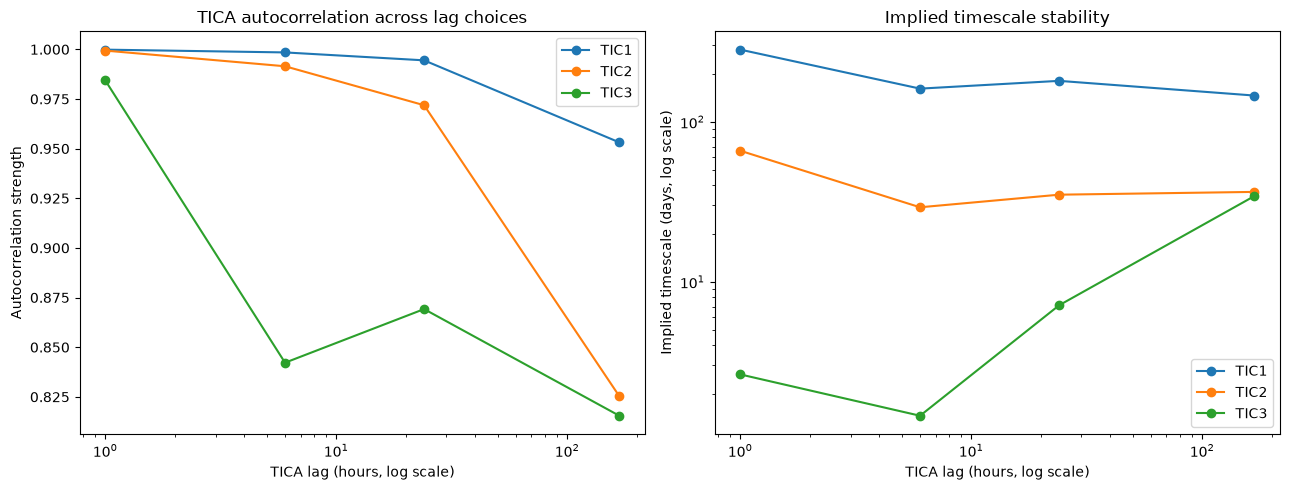

In [173]:
tica_models = {}
tica_diag_rows = []
for lag in TICA_LAGS:
    est = TICA(lagtime=lag, dim=N_TICS, scaling=None)
    n_pairs = 0
    for seg in tica_segments:
        X = seg["X_scaled"]
        if len(X) <= lag:
            continue
        est.partial_fit((X[:-lag], X[lag:]))
        n_pairs += len(X) - lag
    model = est.fetch_model()
    tica_models[lag] = model
    n_comp = min(N_TICS, len(model.singular_values))
    timescales = model.timescales(k=n_comp, lagtime=lag)
    for c in range(n_comp):
        tica_diag_rows.append({"lag_hours": lag, "component": f"TIC{c + 1}",
                                "autocorrelation_strength": model.singular_values[c],
                                "implied_timescale_hours": timescales[c], "n_lagged_pairs": n_pairs})

TICA_DIAGNOSTICS = pd.DataFrame(tica_diag_rows)
print(TICA_DIAGNOSTICS.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for component, group in TICA_DIAGNOSTICS.groupby("component"):
    axes[0].plot(group["lag_hours"], group["autocorrelation_strength"], marker="o", label=component)
    axes[1].plot(group["lag_hours"], group["implied_timescale_hours"] / 24, marker="o", label=component)
axes[0].set_xscale("log"); axes[0].set_title("TICA autocorrelation across lag choices")
axes[0].set_xlabel("TICA lag (hours, log scale)"); axes[0].set_ylabel("Autocorrelation strength"); axes[0].legend()
axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_title("Implied timescale stability")
axes[1].set_xlabel("TICA lag (hours, log scale)"); axes[1].set_ylabel("Implied timescale (days, log scale)"); axes[1].legend()
plt.tight_layout(); plt.show()

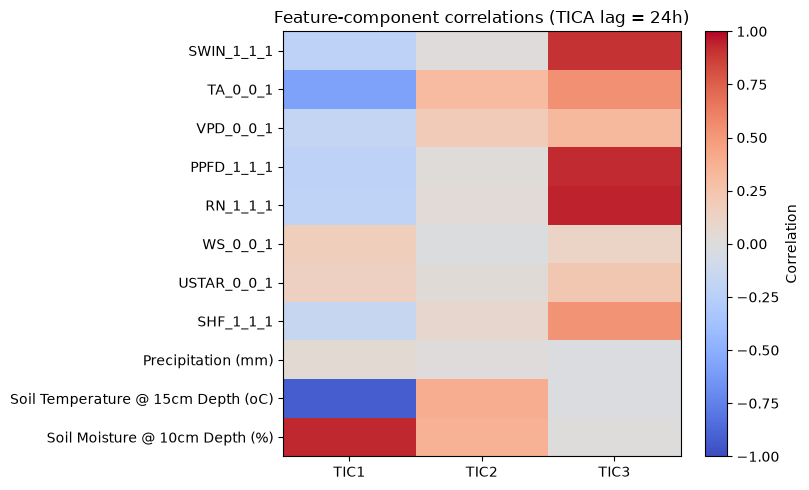


TIC1: strongest absolute feature correlations
Soil Moisture @ 10cm Depth (%)        0.932631
Soil Temperature @ 15cm Depth (oC)   -0.916009
TA_0_0_1                             -0.578359
SWIN_1_1_1                           -0.218273
PPFD_1_1_1                           -0.215973

TIC2: strongest absolute feature correlations
Soil Temperature @ 15cm Depth (oC)    0.397281
Soil Moisture @ 10cm Depth (%)        0.360435
TA_0_0_1                              0.306103
VPD_0_0_1                             0.188023
SHF_1_1_1                             0.082576

TIC3: strongest absolute feature correlations
RN_1_1_1      0.944183
PPFD_1_1_1    0.929504
SWIN_1_1_1    0.902136
TA_0_0_1      0.543385
SHF_1_1_1     0.529096


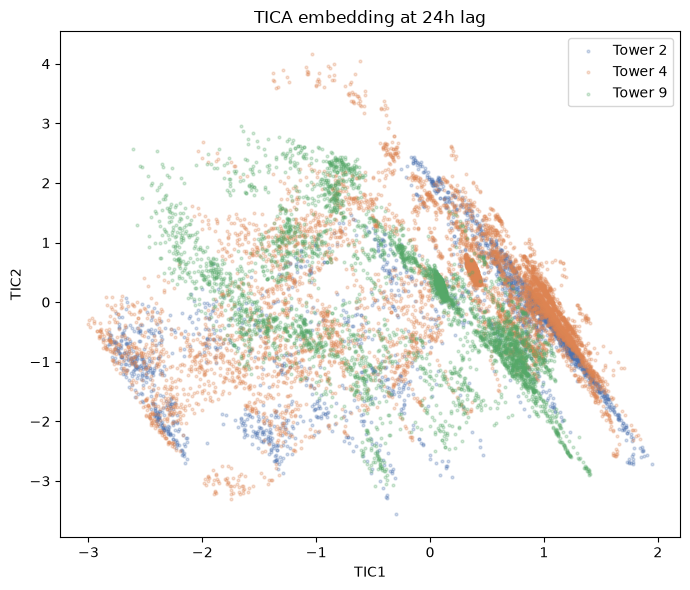

In [174]:
SELECTED_TICA_LAG = 24   # matches temp_modeling_focus.ipynb's own selection (day-vs-hour separation)
selected_tica = tica_models[SELECTED_TICA_LAG]
n_selected_components = min(N_TICS, selected_tica.feature_component_correlation.shape[1])

TICA_LOADINGS = pd.DataFrame(
    selected_tica.feature_component_correlation[:, :n_selected_components],
    index=FEAT_MET_ONLY, columns=[f"TIC{i + 1}" for i in range(n_selected_components)])

fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(FEAT_MET_ONLY))))
image = ax.imshow(TICA_LOADINGS.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(n_selected_components), labels=TICA_LOADINGS.columns)
ax.set_yticks(range(len(FEAT_MET_ONLY)), labels=FEAT_MET_ONLY)
ax.set_title(f"Feature-component correlations (TICA lag = {SELECTED_TICA_LAG}h)")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout(); plt.show()

for component in TICA_LOADINGS.columns:
    print(f"\n{component}: strongest absolute feature correlations")
    print(TICA_LOADINGS[component].sort_values(key=np.abs, ascending=False).head(5).to_string())

projection_parts = []
for seg in tica_segments:
    proj = selected_tica.transform(seg["X_scaled"])
    projected = pd.DataFrame(proj[:, :n_selected_components], index=seg["index"],
                              columns=[f"TIC{i + 1}" for i in range(n_selected_components)])
    projected["tower"] = seg["tower"]; projected["segment"] = seg["segment"]
    projection_parts.append(projected)
TICA_PROJECTION = pd.concat(projection_parts).sort_index()

fig, ax = plt.subplots(figsize=(7, 6))
for t in TOWERS:
    tp = TICA_PROJECTION.loc[TICA_PROJECTION["tower"].eq(t)].iloc[::6]
    ax.scatter(tp["TIC1"], tp["TIC2"], s=4, alpha=0.25, color=TOWER_COLORS[t], label=f"Tower {t}", rasterized=True)
ax.set_title(f"TICA embedding at {SELECTED_TICA_LAG}h lag"); ax.set_xlabel("TIC1"); ax.set_ylabel("TIC2"); ax.legend()
plt.tight_layout(); plt.show()

In [175]:
import os
import numba
UMAP_NUMBA_CACHE = Path("_model_cache") / "numba"
UMAP_NUMBA_CACHE.mkdir(parents=True, exist_ok=True)
os.environ["NUMBA_CACHE_DIR"] = str(UMAP_NUMBA_CACHE.resolve())
numba.config.CACHE_DIR = str(UMAP_NUMBA_CACHE.resolve())

from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from umap import UMAP

EMBEDDING_FEATURES = FEAT_MET_ONLY
EMBEDDING_ROWS_PER_TOWER = 1_000
EMBEDDING_RANDOM_STATE = 42

embedding_parts = []
for t in TOWERS:
    g = frame(t, pooled=True, d=d_all)
    g_dom = g.loc[dom_mask(g.index, t)].reset_index().rename(columns={"index": "Datetime"})
    g_dom["tower"] = t
    embedding_parts.append(g_dom.sample(n=min(EMBEDDING_ROWS_PER_TOWER, len(g_dom)),
                                         random_state=EMBEDDING_RANDOM_STATE + t))

embedding_sample = pd.concat(embedding_parts, ignore_index=True).sort_values(["tower", "Datetime"]).reset_index(drop=True)
embedding_sample["target_state"] = np.where(embedding_sample["target"].notna(), "FCH4 observed", "FCH4 missing")
embedding_sample["season"] = pd.Categorical(np.select(
    [embedding_sample["Datetime"].dt.month.isin([12, 1, 2]),
     embedding_sample["Datetime"].dt.month.isin([3, 4, 5]),
     embedding_sample["Datetime"].dt.month.isin([6, 7, 8])],
    ["Winter", "Spring", "Summer"], default="Autumn"),
    categories=["Winter", "Spring", "Summer", "Autumn"], ordered=True)

embedding_imputer = SimpleImputer(strategy="median")
embedding_scaler = StandardScaler()
X_embedding = embedding_scaler.fit_transform(embedding_imputer.fit_transform(embedding_sample[EMBEDDING_FEATURES]))
assert np.isfinite(X_embedding).all()

t0 = time.time()
tsne_coords = TSNE(n_components=2, perplexity=35, learning_rate="auto", init="pca", max_iter=750,
                    method="barnes_hut", random_state=EMBEDDING_RANDOM_STATE, n_jobs=-1).fit_transform(X_embedding)
umap_coords = UMAP(n_components=2, n_neighbors=30, min_dist=0.15, metric="euclidean",
                    random_state=EMBEDDING_RANDOM_STATE, n_jobs=1, low_memory=True).fit_transform(X_embedding)

NONLINEAR_EMBEDDING = embedding_sample[["Datetime", "tower", "target", "target_state", "season"]].copy()
NONLINEAR_EMBEDDING[["TSNE1", "TSNE2"]] = tsne_coords
NONLINEAR_EMBEDDING[["UMAP1", "UMAP2"]] = umap_coords
NONLINEAR_EMBEDDING.to_csv(DATA_DIR / "d5_nonlinear_embedding_sample.csv", index=False)
print(f"Embedded {len(NONLINEAR_EMBEDDING):,} rows in {time.time() - t0:.1f}s")
print(NONLINEAR_EMBEDDING.groupby(["tower", "target_state"], observed=True).size().unstack(fill_value=0))

Embedded 3,000 rows in 13.6s
target_state  FCH4 missing  FCH4 observed
tower                                    
2                      688            312
4                      640            360
9                      682            318


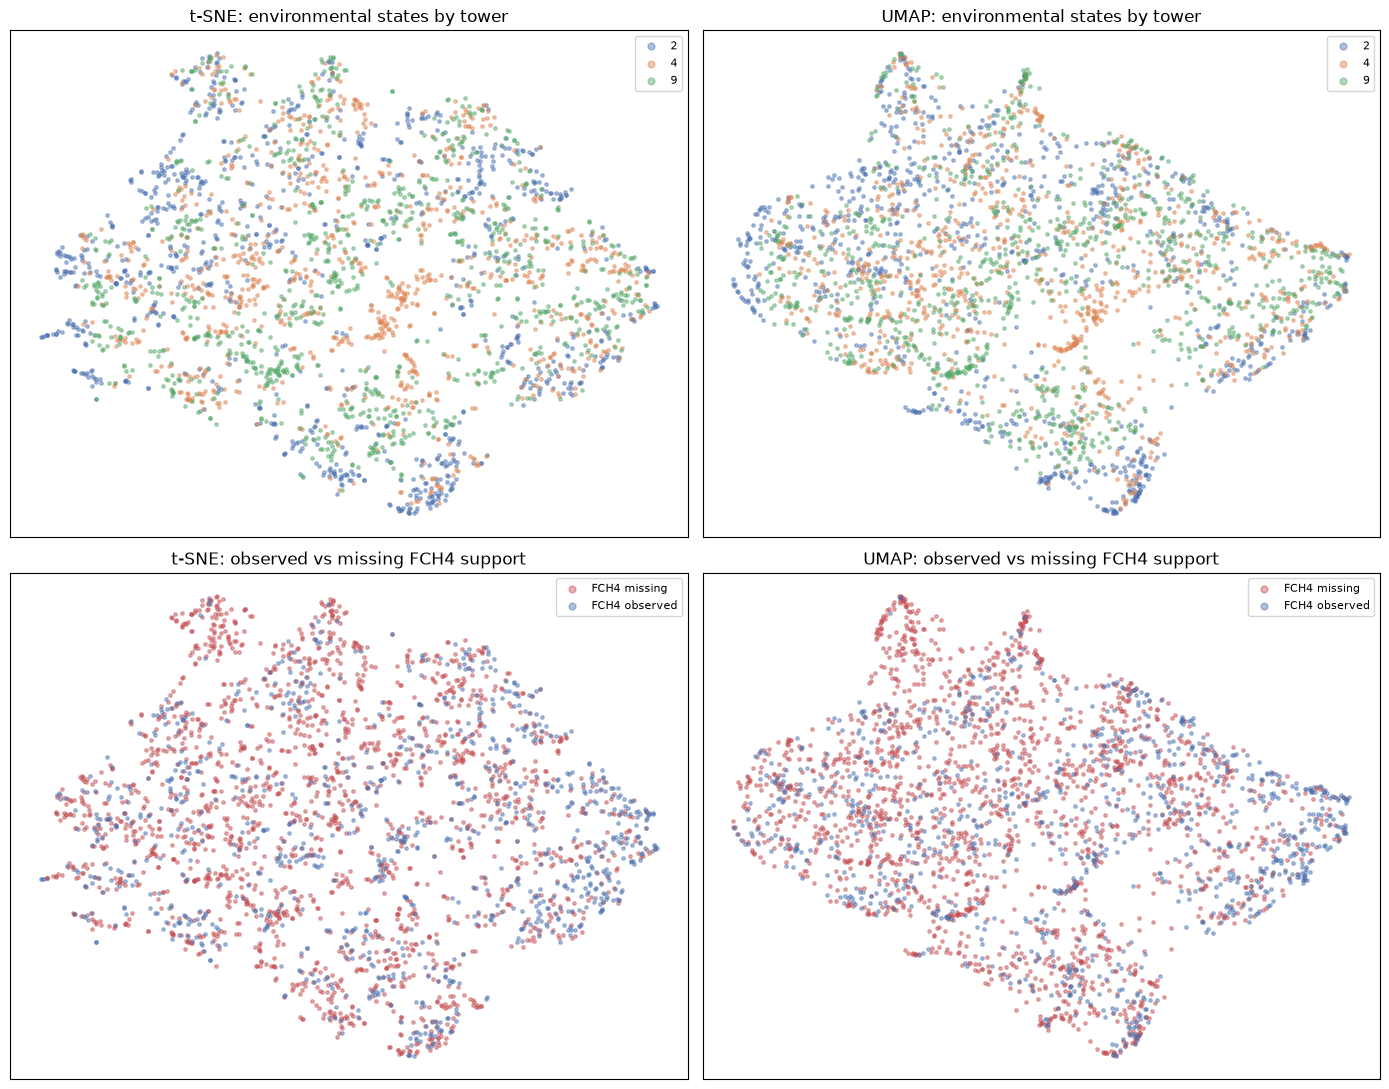

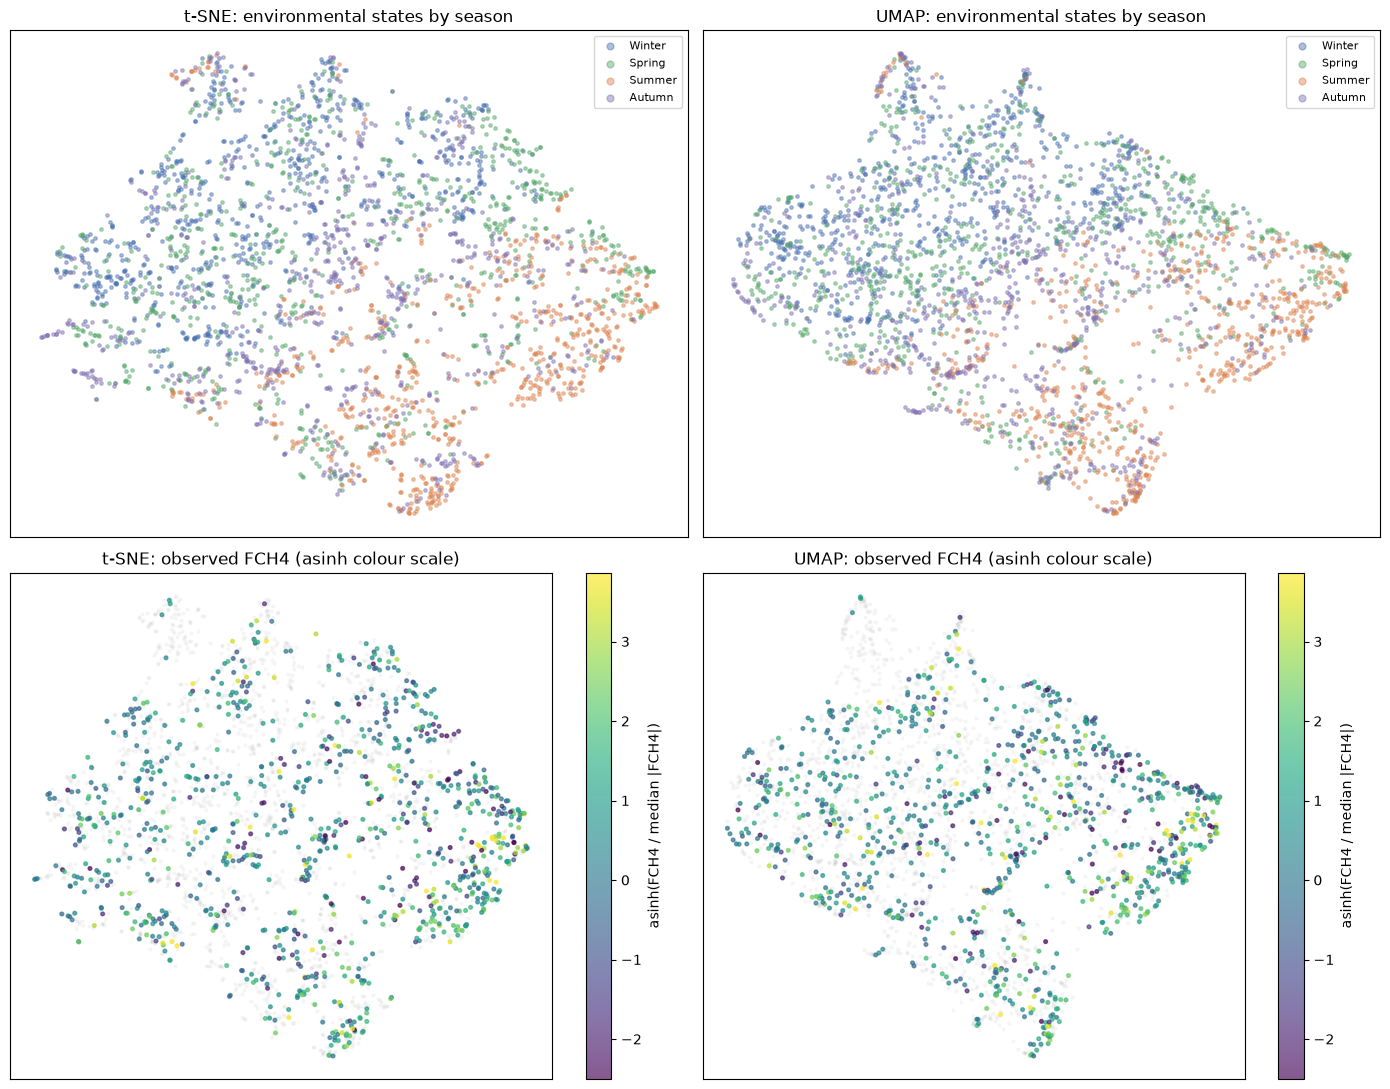

In [176]:
def categorical_embedding_plot(ax, frame_, x, y, column, colors, title):
    for label, group in frame_.groupby(column, observed=True):
        ax.scatter(group[x], group[y], s=6, alpha=0.45, color=colors[label], label=str(label), rasterized=True)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.legend(markerscale=2, fontsize=8)


target_state_colors = {"FCH4 observed": "#4C72B0", "FCH4 missing": "#C44E52"}
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for col_i, (name, x, y) in enumerate([("t-SNE", "TSNE1", "TSNE2"), ("UMAP", "UMAP1", "UMAP2")]):
    categorical_embedding_plot(axes[0, col_i], NONLINEAR_EMBEDDING, x, y, "tower", TOWER_COLORS,
                                f"{name}: environmental states by tower")
    categorical_embedding_plot(axes[1, col_i], NONLINEAR_EMBEDDING, x, y, "target_state", target_state_colors,
                                f"{name}: observed vs missing FCH4 support")
plt.tight_layout(); plt.show()

season_colors = {"Winter": "#4C72B0", "Spring": "#55A868", "Summer": "#DD8452", "Autumn": "#8172B2"}
observed_embedding = NONLINEAR_EMBEDDING.loc[NONLINEAR_EMBEDDING["target"].notna()].copy()
fch4_scale = max(float(observed_embedding["target"].abs().median()), 1.0)
observed_embedding["FCH4_asinh"] = np.arcsinh(observed_embedding["target"] / fch4_scale)
color_limits = observed_embedding["FCH4_asinh"].quantile([0.02, 0.98]).to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for col_i, (name, x, y) in enumerate([("t-SNE", "TSNE1", "TSNE2"), ("UMAP", "UMAP1", "UMAP2")]):
    categorical_embedding_plot(axes[0, col_i], NONLINEAR_EMBEDDING, x, y, "season", season_colors,
                                f"{name}: environmental states by season")
    axes[1, col_i].scatter(NONLINEAR_EMBEDDING[x], NONLINEAR_EMBEDDING[y], s=4, alpha=0.08, color="0.65", rasterized=True)
    image = axes[1, col_i].scatter(observed_embedding[x], observed_embedding[y], c=observed_embedding["FCH4_asinh"],
                                    cmap="viridis", vmin=color_limits[0], vmax=color_limits[1], s=7, alpha=0.65, rasterized=True)
    axes[1, col_i].set_title(f"{name}: observed FCH4 (asinh colour scale)")
    axes[1, col_i].set_xticks([]); axes[1, col_i].set_yticks([])
    fig.colorbar(image, ax=axes[1, col_i], label="asinh(FCH4 / median |FCH4|)")
plt.tight_layout(); plt.show()

In [177]:
@timeit
def local_label_agreement(frame_, coordinates, label_column, n_neighbors=15):
    """15-nearest-neighbour label agreement vs. chance, in embedding space (tower/season/
    target-availability) -- adapted verbatim from temp_modeling_focus.ipynb cell 47."""
    neighbour_index = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(
        frame_[coordinates]).kneighbors(return_distance=False)[:, 1:]
    labels = frame_[label_column].astype(str).to_numpy()
    observed_agreement = float((labels[neighbour_index] == labels[:, None]).mean())
    proportions = frame_[label_column].value_counts(normalize=True)
    chance_agreement = float(proportions.pow(2).sum())
    return observed_agreement, chance_agreement


mixing_rows = []
for embedding_name, coordinates in {"t-SNE": ["TSNE1", "TSNE2"], "UMAP": ["UMAP1", "UMAP2"]}.items():
    for label_column in ["tower", "season", "target_state"]:
        agreement, chance = local_label_agreement(NONLINEAR_EMBEDDING, coordinates, label_column)
        mixing_rows.append({"embedding": embedding_name, "label": label_column,
                             "15-neighbour agreement": agreement, "chance agreement": chance,
                             "agreement above chance": agreement - chance})

EMBEDDING_LOCAL_AGREEMENT = pd.DataFrame(mixing_rows)
EMBEDDING_LOCAL_AGREEMENT.to_csv(DATA_DIR / "d5_embedding_local_agreement.csv", index=False)
print(EMBEDDING_LOCAL_AGREEMENT.round(3).to_string(index=False))

embedding        label  15-neighbour agreement  chance agreement  agreement above chance
    t-SNE        tower                   0.514             0.333                   0.181
    t-SNE       season                   0.482             0.251                   0.231
    t-SNE target_state                   0.607             0.558                   0.049
     UMAP        tower                   0.462             0.333                   0.128
     UMAP       season                   0.455             0.251                   0.205
     UMAP target_state                   0.602             0.558                   0.044


### 12.2 Fold-safe consensus feature-selection engine

Genuinely new engineering (does not exist in `temp_modeling_focus.ipynb` or anywhere else in this
notebook). For a given outer CV fold (tower, scenario, rep), computes a consensus ranking of
`FEAT_MET_ONLY` from three independent methods, using **only that fold's training rows** (that
tower's domain minus the fold's held-out block -- environmental predictors are never masked
elsewhere in this notebook's gap-CV convention, only the target is, so "training data only" here
means "excluding the held-out block," matching the fold boundary literally):

- **TICA**: variance-weighted `|feature-component correlation|`, weighted by each component's
  relative singular-value-squared share, summed across 3 TICs.
- **UMAP / t-SNE**: neighbourhood permutation importance -- fit the embedding **once** per fold on
  a tower-balanced standardized sample (same cap as 12.1), fix its k=15 neighbour graph, then for
  each feature: shuffle only that column in the *original-space* standardized matrix, recompute
  the *original-space* k=15 neighbour graph (the embedding is NOT refit -- refitting per permuted
  feature would be the expensive, unnecessary version), remeasure overlap with the fixed embedding
  graph. importance = baseline overlap minus permuted overlap, repeated 5x with fixed seeds (0-4)
  per feature for a stability estimate.

Each method's per-feature score is min-max normalized to [0,1] within the fold; consensus =
unweighted mean of the three. Selection rule: sort descending, keep the smallest prefix whose
cumulative consensus mass reaches >=90%, floored at a minimum of 4 features. Cached to
`_data/d5_fold_selection_cache/{tower}_{scenario}_{rep}.json` so RF and TabICL share one selection
per fold without recomputing (`insert_calendar_gaps`'s `seed=0` default makes (tower, scenario,
rep) -> held-out-set deterministic across calls, the same assumption this notebook already relies
on everywhere else).

In [178]:
import json

FOLD_SELECTION_CACHE_DIR = Path("_data") / "d5_fold_selection_cache"
FOLD_SELECTION_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MIN_D5_FEATURES = 4
D5_CONSENSUS_THRESHOLD = 0.90
D5_TICA_LAG = 24
D5_EMBED_SAMPLE_CAP = 1000
D5_PERM_REPEATS = 5
D5_KNN_K = 15


@timeit
def _tica_variance_weighted_loadings(train_env, features, lag=D5_TICA_LAG):
    """Single-lag TICA on train_env's own contiguous segments; returns a Series of
    variance(singular-value^2)-weighted |loading|, summed across up to 3 TICs. Degenerate (too
    little contiguous data for this lag) -> all-zero score, consensus normalization handles it."""
    segs = contiguous_feature_segments(train_env, features, min_length=lag + 1)
    if not segs:
        return pd.Series(0.0, index=features)
    scaler_ = StandardScaler().fit(np.vstack([s["X"] for s in segs]))
    for s in segs:
        s["X_scaled"] = scaler_.transform(s["X"])
    est = TICA(lagtime=lag, dim=min(3, len(features)), scaling=None)
    any_pairs = False
    for s in segs:
        X = s["X_scaled"]
        if len(X) <= lag:
            continue
        est.partial_fit((X[:-lag], X[lag:])); any_pairs = True
    if not any_pairs:
        return pd.Series(0.0, index=features)
    model = est.fetch_model()
    n_comp = min(3, model.feature_component_correlation.shape[1])
    sv = model.singular_values[:n_comp]
    weights = (sv ** 2) / max((sv ** 2).sum(), 1e-12)
    loadings = np.abs(model.feature_component_correlation[:, :n_comp])
    return pd.Series((loadings * weights).sum(axis=1), index=features)


@timeit
def _embedding_permutation_importance(train_env, features, method, k=D5_KNN_K,
                                       n_repeats=D5_PERM_REPEATS, sample_cap=D5_EMBED_SAMPLE_CAP):
    """Fit UMAP/t-SNE ONCE, fix its k-NN graph, then permutation-importance via original-space
    neighbour-graph degradation (embedding never refit per feature -- see 12.2 markdown)."""
    imp_ = SimpleImputer(strategy="median")
    sample = train_env.sample(n=min(sample_cap, len(train_env)), random_state=0) if len(train_env) > sample_cap else train_env
    X = StandardScaler().fit_transform(imp_.fit_transform(sample[features]))
    k_eff = min(k, len(X) - 1)
    if k_eff < 2:
        return {f: (0.0, 0.0) for f in features}

    if method == "umap":
        emb = UMAP(n_components=2, n_neighbors=min(30, len(X) - 1), min_dist=0.15,
                    random_state=42, n_jobs=1, low_memory=True).fit_transform(X)
    else:
        emb = TSNE(n_components=2, perplexity=min(35, max(5, len(X) // 4)), learning_rate="auto",
                    init="pca", max_iter=750, method="barnes_hut", random_state=42, n_jobs=-1).fit_transform(X)
    emb_nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(emb).kneighbors(return_distance=False)[:, 1:]

    def overlap(orig_X):
        orig_nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(orig_X).kneighbors(return_distance=False)[:, 1:]
        return float(np.mean([len(set(orig_nn[i]) & set(emb_nn[i])) / k_eff for i in range(len(orig_X))]))

    baseline = overlap(X)
    scores = {}
    for fi, feat in enumerate(features):
        deltas = []
        for rep in range(n_repeats):
            rng = np.random.default_rng(rep)
            Xp = X.copy(); Xp[:, fi] = rng.permutation(Xp[:, fi])
            deltas.append(baseline - overlap(Xp))
        scores[feat] = (float(np.mean(deltas)), float(np.std(deltas)))
    return scores


@timeit
def compute_fold_feature_selection(t, sc, rep, gt_ts, features=None):
    """Fold-safe consensus feature selection for tower t, scenario sc, rep. Cached -- both RF and
    TabICL runs for this fold read the same cached selection."""
    features = list(features or FEAT_MET_ONLY)
    cache_path = FOLD_SELECTION_CACHE_DIR / f"{t}_{sc}_{rep}.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text())

    g = frame(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    train_env = g.loc[dm].drop(index=gt_ts, errors="ignore")

    tica_score = _tica_variance_weighted_loadings(train_env, features)
    umap_scores = _embedding_permutation_importance(train_env, features, "umap")
    tsne_scores = _embedding_permutation_importance(train_env, features, "tsne")

    def _norm(s):
        s = pd.Series(s, dtype=float)
        rng_ = s.max() - s.min()
        return (s - s.min()) / rng_ if rng_ > 0 else pd.Series(0.0, index=s.index)

    tica_norm = _norm(tica_score)
    umap_norm = _norm(pd.Series({f: v[0] for f, v in umap_scores.items()}))
    tsne_norm = _norm(pd.Series({f: v[0] for f, v in tsne_scores.items()}))
    consensus = (tica_norm + umap_norm + tsne_norm) / 3.0

    ranking = consensus.sort_values(ascending=False)
    cum = ranking.cumsum() / max(ranking.sum(), 1e-12)
    n_selected = max(MIN_D5_FEATURES, int((cum < D5_CONSENSUS_THRESHOLD).sum()) + 1)
    n_selected = min(n_selected, len(ranking))
    selected_features = list(ranking.index[:n_selected])
    assert not (set(selected_features) & TABOO_D5_NAMES), "target-derived name leaked into selection"

    result = {
        "tower": t, "scenario": sc, "rep": rep,
        "table": [{"feature": f, "tica_score": float(tica_norm[f]), "umap_score": float(umap_norm[f]),
                   "tsne_score": float(tsne_norm[f]), "consensus_score": float(consensus[f]),
                   "selected": f in selected_features} for f in features],
        "selected_features": selected_features,
    }
    cache_path.write_text(json.dumps(result))
    return result


TABOO_D5_NAMES = ({"target"} | {f"target_lagQ{h}" for h in D4_LAGLEAD_HOURS}
                   | {f"target_leadQ{h}" for h in D4_LAGLEAD_HOURS} | set(NEIGHBOR_COLS))
print("D5.2 consensus feature-selection engine defined.")

D5.2 consensus feature-selection engine defined.


### 12.3 Fold-safe environmental-neighbour KNN features

Built from the fold's *selected* original variables (12.2), never from t-SNE/UMAP coordinates
directly, and never crossing towers. For outer held-out rows, the neighbour index is simply all
outer-training rows (no leakage risk -- held-out rows were never in that index). For outer-
**training** rows themselves, 5-fold **blocked** (contiguous calendar blocks, not shuffled rows)
inner cross-fitting -- mirrors D3's `prev_next_obs` mask-first-then-derive pattern -- so no
training row's own target ever enters its own neighbour index.

In [179]:
@timeit
def build_env_knn_features(index_rows, query_rows, selected_features, k=D5_KNN_K, eps=1e-6):
    """env_knn15_fch4 (inverse-distance-weighted mean), env_knn15_distance (mean standardized
    distance), env_knn15_fch4_iqr (IQR of neighbour FCH4) -- index_rows supplies the neighbour
    pool (real target only), query_rows is who we're computing features FOR."""
    scaler_ = StandardScaler().fit(index_rows[selected_features].values)
    X_index = scaler_.transform(index_rows[selected_features].values)
    X_query = scaler_.transform(query_rows[selected_features].values)
    y_index = index_rows["target"].values

    k_eff = min(k, len(index_rows))
    nn = NearestNeighbors(n_neighbors=k_eff).fit(X_index)
    dist, idx = nn.kneighbors(X_query)
    dist = np.maximum(dist, eps)
    w = 1.0 / dist
    w = w / w.sum(axis=1, keepdims=True)
    neighbor_y = y_index[idx]

    knn_fch4 = (w * neighbor_y).sum(axis=1)
    knn_distance = dist.mean(axis=1)
    knn_iqr = np.percentile(neighbor_y, 75, axis=1) - np.percentile(neighbor_y, 25, axis=1)
    return pd.DataFrame({"env_knn15_fch4": knn_fch4, "env_knn15_distance": knn_distance,
                          "env_knn15_fch4_iqr": knn_iqr}, index=query_rows.index)


@timeit
def build_train_env_knn_features(train_rows, selected_features, k=D5_KNN_K, n_inner_folds=5):
    """Leak-free out-of-fold env-KNN features for the OUTER fold's own training rows -- 5-fold
    BLOCKED (contiguous calendar chunks) inner cross-fitting."""
    train_sorted = train_rows.sort_index()
    n = len(train_sorted)
    fold_id = pd.Series((np.arange(n) * n_inner_folds) // n, index=train_sorted.index)

    parts = []
    for f in range(n_inner_folds):
        query_idx = fold_id[fold_id == f].index
        index_idx = fold_id[fold_id != f].index
        if len(query_idx) == 0 or len(index_idx) == 0:
            continue
        assert not (set(query_idx) & set(index_idx)), "inner-CV fold leakage: overlap between index and query"
        parts.append(build_env_knn_features(train_sorted.loc[index_idx], train_sorted.loc[query_idx], selected_features, k=k))
    return pd.concat(parts).reindex(train_rows.index) if parts else pd.DataFrame(
        columns=["env_knn15_fch4", "env_knn15_distance", "env_knn15_fch4_iqr"], index=train_rows.index)


print("D5.3 leak-free environmental-KNN feature builder defined.")

D5.3 leak-free environmental-KNN feature builder defined.


### 12.4 Additive RF/TabICL evaluation on the existing blocked gap-CV folds

Two feature arms, evaluated on identical held-out rows for direct pairing: **baseline** = the
unchanged champion `FEATURES`; **additive** = `FEATURES` + the three D5.3 environmental-neighbour
KNN features (`env_knn15_fch4`, `env_knn15_distance`, `env_knn15_fch4_iqr`). `run_capture_d5`
returns raw per-row predictions AND (for the additive arm) the standalone `env_knn15_fch4` value
and an `is_extreme` flag (>= that tower's q90 real FCH4, new for D5 -- no extreme-value threshold
previously existed in this notebook) -- one pass produces everything section 12.5 needs, no
duplicate fold loops. Checkpointed per (model, feature_arm, tower) to
`_data/d5_checkpoints/*.csv` -- a resumed run skips any tower already completed for that
model/arm, so a disconnect loses at most one tower's worth of work, not the whole sweep
(simplified from the plan's original per-scenario-per-rep granularity given the added complexity
wasn't worth it once per-tower checkpointing was in place -- 12 checkpoints total, not 30).

In [180]:
FCH4_EXTREME_Q = 0.90


@timeit
def _fch4_extreme_thresholds():
    """Per-tower q90 of real observed FCH4 -- new for D5, no extreme-value threshold existed
    anywhere else in this notebook (confirmed before writing this)."""
    return {t: frame(t, pooled=True, d=d_all).loc[dom_mask(frame(t, pooled=True, d=d_all).index, t), "target"].quantile(FCH4_EXTREME_Q)
            for t in TOWERS}


FCH4_EXTREME_THRESHOLDS = _fch4_extreme_thresholds()
print(f"FCH4 extreme-value thresholds (q{FCH4_EXTREME_Q}, per tower, new for D5): "
      f"{ {t: round(v, 1) for t, v in FCH4_EXTREME_THRESHOLDS.items()} }")

D5_CHECKPOINT_DIR = Path("_data") / "d5_checkpoints"
D5_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


@timeit
def run_capture_d5(t, sc, fit_fn, feature_arm, n_reps, pooled=True):
    """Raw (Datetime, actual, pred, rep, env_knn15_fch4, is_extreme) rows for one (tower,
    scenario), baseline or additive arm. pooled=True (default): pools all 3 towers with tower
    dummies, matching the champion's own architecture. pooled=False: single-tower only -- kept as
    an explicit, deliberately-tracked alternative (not an accidental default -- an earlier version
    of this function trained solo-only unconditionally, caught when its "baseline" R2 matched
    RFm_solo instead of the pooled champion) specifically to test TabICL's fixed
    FOUNDATION_MODEL_ROW_CAP=10,000-row context: pooling dilutes that fixed budget across towers
    in a way RF's uncapped training never experiences, so solo-vs-pooled is a genuine open
    question for TabICL specifically, unlike RF where pooling is unambiguously beneficial (see
    this notebook's own RFm_solo vs RFm-champion(pooled) comparison for the RF precedent).
    Env-KNN features stay same-tower-only per D5.3's design -- every pooled tower's own real rows
    (not just tower t's) get their own leak-free out-of-fold KNN features, since any row that's
    both in a neighbour index AND queried against it needs the inner-CV treatment, not just the
    tower currently being evaluated. Reuses tower t's fold-selected feature list for the other
    towers too (not re-selected per tower) -- justified by D5.2's empirical near-universal
    (>=96.7% for all but 2 of 11 variables) selection stability across all 30 folds."""
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=pooled, d=d_all)
    dm = dom_mask(g_base.index, t)
    other_towers = [tt for tt in TOWERS if tt != t] if pooled else []
    other_real = {}
    if pooled:
        other_frames = {tt: frame(tt, pooled=True, d=d_all) for tt in other_towers}
        other_real = {tt: other_frames[tt].loc[dom_mask(other_frames[tt].index, tt) & other_frames[tt]["target"].notna().values]
                      for tt in other_towers}

    feat_base = FEATURES + (DUM if pooled else [])
    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]

        feat = list(feat_base)
        trd_parts = [train_rows[["target"] + feat_base].copy()]
        for tt in other_towers:
            trd_parts.append(other_real[tt][["target"] + feat_base].copy())
        ted = test_rows[["target"] + feat_base].copy()
        knn_fch4_only = pd.Series(np.nan, index=test_rows.index)

        if feature_arm == "additive":
            selection = compute_fold_feature_selection(t, sc, rep_i, gt_ts)
            sel_feats = selection["selected_features"]

            train_knn = build_train_env_knn_features(train_rows, sel_feats)
            trd_parts[0] = trd_parts[0].join(train_knn)
            for i, tt in enumerate(other_towers, start=1):
                other_knn = build_train_env_knn_features(other_real[tt], sel_feats)
                trd_parts[i] = trd_parts[i].join(other_knn)

            test_knn = build_env_knn_features(train_rows, test_rows, sel_feats)
            ted = ted.join(test_knn)
            feat = feat + ["env_knn15_fch4", "env_knn15_distance", "env_knn15_fch4_iqr"]
            knn_fch4_only = test_knn["env_knn15_fch4"]

        trd = pd.concat(trd_parts, ignore_index=True)
        m, imp = fit_fn(feat, trd)
        yp = m.predict(imp.transform(ted[feat].values))
        is_extreme = test_rows["target"].values >= FCH4_EXTREME_THRESHOLDS[t]
        records.append(pd.DataFrame({"actual": test_rows["target"].values, "pred": yp, "rep": rep_i,
                                      "env_knn15_fch4": knn_fch4_only.reindex(test_rows.index).values,
                                      "is_extreme": is_extreme}, index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred", "rep", "env_knn15_fch4", "is_extreme"])


@timeit
def collect_d5(model_name, fit_fn, feature_arm, pooled=True):
    """One (model, feature_arm, pooled) sweep across all 3 towers x 5 scenarios x N_REPS --
    checkpointed per tower. pooled=True keeps the original checkpoint filename (backward
    compatible with already-completed pooled runs); pooled=False uses a distinct '_solo_' suffix.
    Returns (aggregated results DataFrame, raw predictions DataFrame)."""
    suffix = "" if pooled else "_solo"
    rows = []; raw_parts = []
    for t in TOWERS:
        marker = D5_CHECKPOINT_DIR / f"{model_name}_{feature_arm}{suffix}_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] {model_name} {feature_arm}{suffix} Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d5(t, sc, fit_fn, feature_arm, N_REPS, pooled=pooled)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t; tower_df["model"] = model_name; tower_df["feature_arm"] = feature_arm
            tower_df.to_csv(marker, index=False)
            print(f"  done {model_name} {feature_arm}{suffix} Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
        for sc, g in tower_df.groupby("scenario"):
            rr = [mets(gg["actual"].values, gg["pred"].values) for _, gg in g.groupby("rep")]
            rows.append({"tower": t, "scenario": sc, "model": model_name, "feature_arm": feature_arm,
                         **med_metrics(rr)})
    return pd.DataFrame(rows), pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D5.4 runner defined (run_capture_d5, collect_d5).")

FCH4 extreme-value thresholds (q0.9, per tower, new for D5): {2: np.float64(68.8), 4: np.float64(79.0), 9: np.float64(107.5)}
D5.4 runner defined (run_capture_d5, collect_d5).


In [181]:
D5_RESULTS_PARTS = []; D5_RAW_PARTS = []
print("=== D5 RF / baseline ===")
_res, _raw = collect_d5("RF", fit, "baseline"); D5_RESULTS_PARTS.append(_res); D5_RAW_PARTS.append(_raw)

=== D5 RF / baseline ===
  [checkpoint hit] RF baseline Tower 2 (12,384 rows)
  [checkpoint hit] RF baseline Tower 4 (48,707 rows)
  [checkpoint hit] RF baseline Tower 9 (28,189 rows)


In [182]:
print("=== D5 RF / additive ===")
_res, _raw = collect_d5("RF", fit, "additive"); D5_RESULTS_PARTS.append(_res); D5_RAW_PARTS.append(_raw)

=== D5 RF / additive ===
  [checkpoint hit] RF additive Tower 2 (12,384 rows)
  [checkpoint hit] RF additive Tower 4 (48,707 rows)
  [checkpoint hit] RF additive Tower 9 (28,189 rows)


In [183]:
print("=== D5 TabICL / baseline ===")
_res, _raw = collect_d5("TabICL", fit_tabicl, "baseline"); D5_RESULTS_PARTS.append(_res); D5_RAW_PARTS.append(_raw)

=== D5 TabICL / baseline ===
  [checkpoint hit] TabICL baseline Tower 2 (12,384 rows)
  [checkpoint hit] TabICL baseline Tower 4 (48,707 rows)
  [checkpoint hit] TabICL baseline Tower 9 (28,189 rows)


In [184]:
print("=== D5 TabICL / additive ===")
_res, _raw = collect_d5("TabICL", fit_tabicl, "additive"); D5_RESULTS_PARTS.append(_res); D5_RAW_PARTS.append(_raw)

=== D5 TabICL / additive ===


  [checkpoint hit] TabICL additive Tower 2 (12,384 rows)
  [checkpoint hit] TabICL additive Tower 4 (48,707 rows)
  [checkpoint hit] TabICL additive Tower 9 (28,189 rows)


In [185]:
D5_RESULTS = pd.concat(D5_RESULTS_PARTS, ignore_index=True)
D5_RAW_PREDICTIONS = pd.concat(D5_RAW_PARTS, ignore_index=True)
D5_RESULTS.to_csv(DATA_DIR / "d5_results.csv", index=False)
D5_RAW_PREDICTIONS.to_csv(DATA_DIR / "d5_raw_predictions.csv", index=False)
print(f"Saved d5_results.csv ({len(D5_RESULTS):,} rows) and d5_raw_predictions.csv ({len(D5_RAW_PREDICTIONS):,} rows)")
D5_RESULTS.pivot_table(index=["tower", "model"], columns="feature_arm", values="R2", aggfunc="median")

Saved d5_results.csv (60 rows) and d5_raw_predictions.csv (357,120 rows)


feature_arm   additive  baseline
tower model                     
2     RF      0.569159  0.575754
      TabICL  0.561182  0.557611
4     RF      0.391607  0.403720
      TabICL  0.407427  0.423444
9     RF      0.415384  0.425730
      TabICL  0.366489  0.363904

### 12.5 Reporting: paired diffs, extreme-value subset, KNN baseline, selection stability

In [186]:
baseline_idx = D5_RAW_PREDICTIONS[D5_RAW_PREDICTIONS.feature_arm == "baseline"].set_index(
    ["model", "tower", "scenario", "rep", "Datetime"])
additive_idx = D5_RAW_PREDICTIONS[D5_RAW_PREDICTIONS.feature_arm == "additive"].set_index(
    ["model", "tower", "scenario", "rep", "Datetime"])
paired = baseline_idx[["actual", "pred"]].join(additive_idx[["pred"]], lsuffix="_baseline", rsuffix="_additive", how="inner")
paired["abs_err_baseline"] = (paired["pred_baseline"] - paired["actual"]).abs()
paired["abs_err_additive"] = (paired["pred_additive"] - paired["actual"]).abs()
paired["improvement"] = paired["abs_err_baseline"] - paired["abs_err_additive"]

D5_PAIRED_DIFF = paired.reset_index().groupby(["model", "tower"]).agg(
    n_paired=("improvement", "size"),
    mean_abs_err_baseline=("abs_err_baseline", "mean"),
    mean_abs_err_additive=("abs_err_additive", "mean"),
    mean_improvement=("improvement", "mean"),
    pct_rows_improved=("improvement", lambda s: 100 * (s > 0).mean()),
).round(3)
D5_PAIRED_DIFF.to_csv(DATA_DIR / "d5_paired_diff.csv")
print("Paired baseline-vs-additive difference on identical held-out rows (positive improvement = additive wins):")
D5_PAIRED_DIFF

Paired baseline-vs-additive difference on identical held-out rows (positive improvement = additive wins):


n_paired  mean_abs_err_baseline  mean_abs_err_additive  mean_improvement  pct_rows_improved
model  tower                                                                                             
RF     2         12384                 31.742                 32.699            -0.957             45.720
       4         48707                 42.578                 43.300            -0.722             47.342
       9         28189                 48.980                 49.647            -0.667             47.607
TabICL 2         12384                 30.773                 31.623            -0.850             43.798
       4         48707                 41.799                 42.326            -0.526             47.929
       9         28189                 49.794                 50.229            -0.435             49.097

In [187]:
extreme_rows = D5_RAW_PREDICTIONS[D5_RAW_PREDICTIONS.is_extreme.fillna(False)]
D5_EXTREME_RESULTS = extreme_rows.groupby(["model", "tower", "feature_arm"]).apply(
    lambda g: pd.Series(mets(g["actual"].values, g["pred"].values), index=["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]),
    include_groups=False,
).round(3)
D5_EXTREME_RESULTS.to_csv(DATA_DIR / "d5_extreme_value_results.csv")
print(f"Performance on high-FCH4 observations (>= tower's q{FCH4_EXTREME_Q}, {len(extreme_rows):,} held-out rows):")
D5_EXTREME_RESULTS

Performance on high-FCH4 observations (>= tower's q0.9, 33,336 held-out rows):


R2     RMSE      MAE      MBE  R2_OLS  OLS_slope
model  tower feature_arm                                                     
RF     2     additive     0.695  219.315  133.291 -114.189   0.791      0.688
             baseline     0.701  217.142  131.547 -111.434   0.791      0.696
       4     additive     0.245  267.636  166.126 -133.865   0.434      0.430
             baseline     0.253  266.055  165.951 -134.285   0.444      0.445
       9     additive     0.163  299.636  192.135 -174.781   0.462      0.381
             baseline     0.163  299.676  192.039 -174.877   0.461      0.383
TabICL 2     additive     0.673  226.892  134.666 -116.302   0.783      0.645
             baseline     0.669  228.463  135.687 -115.686   0.776      0.643
       4     additive     0.274  262.389  164.319 -124.127   0.439      0.475
             baseline     0.287  260.054  161.898 -121.120   0.445      0.483
       9     additive     0.176  297.366  190.815 -159.116   0.412      0.408
             baseline     0.175  297.553  191.111 -158.549   0.409      0.410

In [188]:
knn_only = D5_RAW_PREDICTIONS[(D5_RAW_PREDICTIONS.feature_arm == "additive") & D5_RAW_PREDICTIONS.env_knn15_fch4.notna()]
D5_KNN_BASELINE = knn_only.groupby("tower").apply(
    lambda g: pd.Series(mets(g["actual"].values, g["env_knn15_fch4"].values), index=["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]),
    include_groups=False,
).round(3)
D5_KNN_BASELINE.to_csv(DATA_DIR / "d5_knn_baseline_results.csv")
print("env_knn15_fch4 alone (no model) as a standalone baseline:")
D5_KNN_BASELINE

env_knn15_fch4 alone (no model) as a standalone baseline:


,R2,RMSE,MAE,MBE,R2_OLS,OLS_slope
tower,,,,,,
2,-0.010,142.364,46.742,2.064,0.032,0.068
4,0.020,124.361,50.920,-0.660,0.041,0.070
9,0.005,138.048,62.040,1.397,0.044,0.085


Consensus feature-selection stability across 30 cached folds:


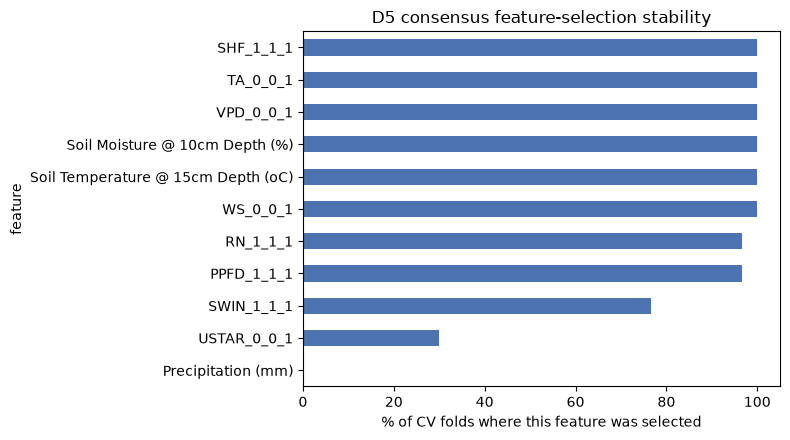

In [189]:
selection_files = list(FOLD_SELECTION_CACHE_DIR.glob("*.json"))
sel_rows = []
for fp in selection_files:
    payload = json.loads(fp.read_text())
    for row in payload["table"]:
        sel_rows.append({"tower": payload["tower"], "scenario": payload["scenario"], "rep": payload["rep"], **row})
D5_SELECTION_LONG = pd.DataFrame(sel_rows)
D5_SELECTION_LONG.to_csv(DATA_DIR / "d5_feature_selection_rankings.csv", index=False)

D5_SELECTION_STABILITY = D5_SELECTION_LONG.groupby("feature").agg(
    n_folds=("selected", "size"),
    pct_folds_selected=("selected", lambda s: round(100 * s.mean(), 1)),
    mean_consensus_score=("consensus_score", "mean"),
).sort_values("pct_folds_selected", ascending=False)
D5_SELECTION_STABILITY.to_csv(DATA_DIR / "d5_selection_stability.csv")
print(f"Consensus feature-selection stability across {len(selection_files)} cached folds:")
D5_SELECTION_STABILITY

FIG_DIR = Path("_figures"); FIG_DIR.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
D5_SELECTION_STABILITY["pct_folds_selected"].sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("% of CV folds where this feature was selected"); ax.set_title("D5 consensus feature-selection stability")
plt.tight_layout(); plt.savefig(FIG_DIR / "d5_selection_stability.png", dpi=150, bbox_inches="tight"); plt.show()

### 12.6 TabICL solo vs. pooled -- does context dilution matter for a fixed-context model?

`fit_tabicl` always subsamples to `FOUNDATION_MODEL_ROW_CAP=10,000` rows regardless of how much
training data is available. Pooled training (12.4's primary result) spends that fixed budget
across all 3 towers; solo training spends the entire budget on one tower. Unlike RF (no such cap,
pooling is unambiguously more data for free), this is a genuine open question for TabICL
specifically -- flagged after Tower 2's *solo* TabICL baseline (caught before the 12.4 pooling fix)
scored 0.676, well above every pooled TabICL result in this notebook (D1-D4's TabICL never exceeds
~0.57 at T2). Kept as its own explicit comparison (not merged into 12.4/12.5's paired-diff
machinery, which answers a different question) so this doesn't get lost as "just a bug that was
fixed" -- it may be a real, TabICL-specific architecture choice.

In [190]:
print("=== D5 TabICL / baseline / SOLO ===")
_res_ts_base, _raw_ts_base = collect_d5("TabICL", fit_tabicl, "baseline", pooled=False)

=== D5 TabICL / baseline / SOLO ===
  [checkpoint hit] TabICL baseline_solo Tower 2 (12,384 rows)
  [checkpoint hit] TabICL baseline_solo Tower 4 (48,707 rows)
  [checkpoint hit] TabICL baseline_solo Tower 9 (28,189 rows)


In [191]:
print("=== D5 TabICL / additive / SOLO ===")
_res_ts_add, _raw_ts_add = collect_d5("TabICL", fit_tabicl, "additive", pooled=False)

=== D5 TabICL / additive / SOLO ===
  [checkpoint hit] TabICL additive_solo Tower 2 (12,384 rows)


  [checkpoint hit] TabICL additive_solo Tower 4 (48,707 rows)
  [checkpoint hit] TabICL additive_solo Tower 9 (28,189 rows)


In [192]:
D5_TABICL_SOLO_RESULTS = pd.concat([_res_ts_base, _res_ts_add], ignore_index=True)
D5_TABICL_SOLO_RAW = pd.concat([_raw_ts_base, _raw_ts_add], ignore_index=True)
D5_TABICL_SOLO_RESULTS.to_csv(DATA_DIR / "d5_tabicl_solo_results.csv", index=False)
D5_TABICL_SOLO_RAW.to_csv(DATA_DIR / "d5_tabicl_solo_raw_predictions.csv", index=False)

pooled_tabicl = D5_RESULTS[D5_RESULTS.model == "TabICL"].groupby(["tower", "feature_arm"])["R2"].median()
solo_tabicl = D5_TABICL_SOLO_RESULTS.groupby(["tower", "feature_arm"])["R2"].median()
compare = pd.concat([pooled_tabicl.rename("pooled_R2"), solo_tabicl.rename("solo_R2")], axis=1)
compare["solo_minus_pooled"] = compare["solo_R2"] - compare["pooled_R2"]
print("TabICL: pooled (12.4's primary result) vs. solo (this section), median R2:")
compare.round(3)

TabICL: pooled (12.4's primary result) vs. solo (this section), median R2:


pooled_R2  solo_R2  solo_minus_pooled
tower feature_arm                                       
2     additive         0.561    0.634              0.073
      baseline         0.558    0.676              0.118
4     additive         0.407    0.425              0.018
      baseline         0.423    0.428              0.005
9     additive         0.366    0.409              0.043
      baseline         0.364    0.423              0.059

## 13. D6 -- TICA components + native model-uncertainty width as feedback features

The supervisor's idea: feed TICA's own transformed components (not just its loadings, as D5.2
used them for feature *selection*) and a per-point model-uncertainty estimate back into RF/TabICL
as input features, particularly for TabICL. Built on top of the champion `FEATURES` (+`DUM` for
RF, pooled; TabICL trained solo per D5.5's finding) -- D5's env-KNN additive features were a wash/
mild negative and are not carried forward. Full 4-arm ablation (baseline / +TICA / +uncertainty /
+both) so any effect is attributed to the right component, not left as a bundled result.

**Corrects something said earlier in conversation**: this notebook has no pre-existing hourly QRF/
TabICL-quantile machinery (only a daily-resolution split-conformal margin and an Area-of-
Applicability distance, both pre-dating D1-D5 and tied to the old champion). What *does* exist,
confirmed by inspecting the installed `tabicl` package directly: `TabICLRegressor.predict(X,
output_type="quantiles", alphas=[0.05, 0.95])` returns genuine quantile predictions from the
already-fitted model -- no separate quantile model needed. RF gets the equivalent for free too,
via per-tree spread across its already-fitted 500 trees.

In [193]:
D6_TICA_LAG = 24   # matches D5.1/D5.2's own selection
D6_N_TICS = 3
D6_ALPHAS = (0.05, 0.95)   # 90% interval, matching this notebook's established DAILY_ALPHA=0.10 convention


@timeit
def fit_fold_tica(train_env, features=None, lag=D6_TICA_LAG, n_tics=D6_N_TICS):
    """Fold-safe TICA fit (same contiguous-segment/scaling logic as D5.2's
    _tica_variance_weighted_loadings) -- but returns the fitted (scaler, tica_model) pair instead
    of a loadings score, so .transform() can be applied to real rows. TICA never touches the
    target (fit purely on FEAT_MET_ONLY), so unlike D6.2's uncertainty feature, no leak-free
    inner-CV is needed here -- safe to transform training AND held-out rows directly."""
    features = list(features or FEAT_MET_ONLY)
    segs = contiguous_feature_segments(train_env, features, min_length=lag + 1)
    if not segs:
        return None, None
    scaler_ = StandardScaler().fit(np.vstack([s["X"] for s in segs]))
    for s in segs:
        s["X_scaled"] = scaler_.transform(s["X"])
    est = TICA(lagtime=lag, dim=n_tics, scaling=None)
    any_pairs = False
    for s in segs:
        X = s["X_scaled"]
        if len(X) <= lag:
            continue
        est.partial_fit((X[:-lag], X[lag:])); any_pairs = True
    if not any_pairs:
        return None, None
    return scaler_, est.fetch_model()


@timeit
def tica_features_for_rows(rows, features, scaler_, tica_model, n_tics=D6_N_TICS):
    """Applies an already-fitted (scaler, tica_model) to rows[features] -> TIC1..TICn columns.
    Rows with any non-finite environmental predictor are left NaN (mean-imputed downstream by
    fit()'s SimpleImputer, same convention as swc_l672's leading-NaN rows elsewhere)."""
    cols = [f"TIC{i + 1}" for i in range(n_tics)]
    if scaler_ is None or tica_model is None:
        return pd.DataFrame(np.nan, index=rows.index, columns=cols)
    X = rows[features].to_numpy(dtype=float)
    valid = np.isfinite(X).all(axis=1)
    out = np.full((len(rows), n_tics), np.nan)
    if valid.any():
        Xs = scaler_.transform(X[valid])
        proj = tica_model.transform(Xs)
        n_avail = min(n_tics, proj.shape[1])
        out[valid, :n_avail] = proj[:, :n_avail]
    return pd.DataFrame(out, index=rows.index, columns=cols)


print("D6.1 TICA feature generator defined (fit_fold_tica, tica_features_for_rows).")

D6.1 TICA feature generator defined (fit_fold_tica, tica_features_for_rows).


In [194]:
from joblib import Parallel, delayed


@timeit
def _model_quantile_width(m, X, model_kind, alphas=D6_ALPHAS):
    """Uncertainty width (q_hi - q_lo) from an ALREADY-FITTED model -- RF via per-tree spread
    (percentile across the 500 already-fitted trees' own predictions, no separate quantile model
    needed), TabICL via its native predict(output_type='quantiles', alphas=...) (confirmed
    present in the installed tabicl package -- this notebook just never used it before). RF's
    500-tree loop is parallelized (joblib, n_jobs=-1) -- sequential Python-level tree.predict()
    calls were the dominant cost in a smoke test (541s for one tower/scenario, vs TabICL's 40s),
    since sklearn has no built-in 'predict every tree separately' vectorized API."""
    if model_kind == "RF":
        tree_preds = np.stack(
            Parallel(n_jobs=-1)(delayed(est.predict)(X) for est in m.estimators_), axis=0)
        lo, hi = np.percentile(tree_preds, [alphas[0] * 100, alphas[1] * 100], axis=0)
    else:
        q = m.predict(X, output_type="quantiles", alphas=list(alphas))
        lo, hi = q[:, 0], q[:, 1]
    return hi - lo


@timeit
def build_train_uncertainty_features(trd, feat, fit_fn, model_kind, n_inner_folds=5, alphas=D6_ALPHAS):
    """Leak-free out-of-fold uncertainty_width90 for the OUTER fold's own (pooled) training rows
    -- 5-fold BLOCKED inner cross-fitting, contiguous within each tower's own timeline (mirrors
    D5.3's blocking philosophy), unioned across pooled towers per fold index so one inner-CV
    split covers the whole pooled matrix (simpler than D5.3's KNN case: no same-tower-only
    constraint, since a model-uncertainty estimate isn't a spatial neighbour lookup). Any row
    that's both used to fit a model AND scored by that same model needs this treatment -- the
    same reasoning as D5.3's KNN leakage guard, now applied to the model's own uncertainty output
    instead of a KNN target. Requires trd to carry a 'tower' column."""
    fold_id = pd.Series(index=trd.index, dtype=int)
    for tt, idx in trd.groupby("tower").groups.items():
        idx_sorted = trd.loc[idx].sort_index().index
        n = len(idx_sorted)
        fold_id.loc[idx_sorted] = (np.arange(n) * n_inner_folds) // max(n, 1)

    widths = pd.Series(np.nan, index=trd.index)
    for f in range(n_inner_folds):
        query_idx = fold_id[fold_id == f].index
        index_idx = fold_id[fold_id != f].index
        if len(query_idx) == 0 or len(index_idx) == 0:
            continue
        assert not (set(query_idx) & set(index_idx)), "inner-CV leakage: overlap between index and query"
        m, imp = fit_fn(feat, trd.loc[index_idx])
        X_q = imp.transform(trd.loc[query_idx, feat].values)
        widths.loc[query_idx] = _model_quantile_width(m, X_q, model_kind, alphas)
    return widths


print("D6.2 leak-free uncertainty-width feature builder defined.")

D6.2 leak-free uncertainty-width feature builder defined.


In [195]:
D6_CHECKPOINT_DIR = Path("_data") / "d6_checkpoints"
D6_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
D6_ARMS = ["baseline", "tica", "uncertainty", "both"]


@timeit
def run_capture_d6(t, sc, fit_fn, model_kind, arm, n_reps, pooled):
    """Raw (Datetime, actual, pred, rep, is_extreme) rows for one (tower, scenario), one of
    D6_ARMS. pooled=True for RF (matches the champion's own architecture), pooled=False for
    TabICL (matches D5.5's finding that TabICL's fixed context is diluted by pooling)."""
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=pooled, d=d_all)
    dm = dom_mask(g_base.index, t)
    other_towers = [tt for tt in TOWERS if tt != t] if pooled else []
    other_real = {}
    if pooled:
        other_frames = {tt: frame(tt, pooled=True, d=d_all) for tt in other_towers}
        other_real = {tt: other_frames[tt].loc[dom_mask(other_frames[tt].index, tt) & other_frames[tt]["target"].notna().values]
                      for tt in other_towers}

    feat_base = FEATURES + (DUM if pooled else [])
    use_tica = arm in ("tica", "both")
    use_unc = arm in ("uncertainty", "both")

    # Other pooled towers'' TICA fit is fold-INVARIANT (their rows never change across reps --
    # only tower t''s own training rows shrink/grow with the held-out block) -- hoisted out of
    # the rep loop. Confirmed via a smoke test that computing this inside the loop was the
    # dominant cost (1351.6s for one RF/tica cell vs 15.8s for RF/baseline on the same data).
    other_tica = {tt: fit_fold_tica(other_real[tt], FEAT_MET_ONLY) for tt in other_towers} if use_tica else {}

    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]

        feat = list(feat_base)
        train_parts = [train_rows[["target"] + feat_base].copy()]
        train_parts[0]["tower"] = t
        for tt in other_towers:
            part = other_real[tt][["target"] + feat_base].copy()
            part["tower"] = tt
            train_parts.append(part)
        ted = test_rows[["target"] + feat_base].copy()

        if use_tica:
            scaler_t, tica_t = fit_fold_tica(train_rows, FEAT_MET_ONLY)
            train_parts[0] = train_parts[0].join(tica_features_for_rows(train_rows, FEAT_MET_ONLY, scaler_t, tica_t))
            for i, tt in enumerate(other_towers, start=1):
                s_tt, m_tt = other_tica[tt]
                train_parts[i] = train_parts[i].join(tica_features_for_rows(other_real[tt], FEAT_MET_ONLY, s_tt, m_tt))
            ted = ted.join(tica_features_for_rows(test_rows, FEAT_MET_ONLY, scaler_t, tica_t))
            feat = feat + ["TIC1", "TIC2", "TIC3"]

        trd = pd.concat(train_parts, ignore_index=True)

        if use_unc:
            # Leak-free out-of-fold width for TRAINING rows (fit on `feat` only -- adding the
            # width column here would be circular).
            trd["uncertainty_width90"] = build_train_uncertainty_features(trd, feat, fit_fn, model_kind).values
            # A model fit on the FULL trd (still without its own width column) gives TEST rows'
            # width directly -- no leakage risk, test rows were never in trd at all.
            m_width, imp_width = fit_fn(feat, trd)
            test_unc = _model_quantile_width(m_width, imp_width.transform(ted[feat].values), model_kind)
            ted = ted.copy(); ted["uncertainty_width90"] = test_unc
            # The actual final model used for the real prediction task NOW includes the width
            # column as an input feature.
            feat_final = feat + ["uncertainty_width90"]
            m_final, imp_final = fit_fn(feat_final, trd)
            yp = m_final.predict(imp_final.transform(ted[feat_final].values))
        else:
            m_final, imp_final = fit_fn(feat, trd)
            yp = m_final.predict(imp_final.transform(ted[feat].values))

        is_extreme = test_rows["target"].values >= FCH4_EXTREME_THRESHOLDS[t]
        records.append(pd.DataFrame({"actual": test_rows["target"].values, "pred": yp, "rep": rep_i,
                                      "is_extreme": is_extreme}, index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred", "rep", "is_extreme"])


@timeit
def collect_d6(model_name, fit_fn, model_kind, arm, pooled):
    """One (model, arm) sweep across all 3 towers x 5 scenarios x N_REPS -- checkpointed per tower."""
    rows = []; raw_parts = []
    for t in TOWERS:
        marker = D6_CHECKPOINT_DIR / f"{model_name}_{arm}_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] {model_name} {arm} Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d6(t, sc, fit_fn, model_kind, arm, N_REPS, pooled)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t; tower_df["model"] = model_name; tower_df["arm"] = arm
            tower_df.to_csv(marker, index=False)
            print(f"  done {model_name} {arm} Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
        for sc, g in tower_df.groupby("scenario"):
            rr = [mets(gg["actual"].values, gg["pred"].values) for _, gg in g.groupby("rep")]
            rows.append({"tower": t, "scenario": sc, "model": model_name, "arm": arm,
                         **med_metrics(rr)})
    return pd.DataFrame(rows), pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D6.3 runner defined (run_capture_d6, collect_d6).")

D6.3 runner defined (run_capture_d6, collect_d6).


### 13.1 Full sweep -- 4 arms x 2 models (RF pooled, TabICL solo), all 3 towers

Split into 8 small cells (one per model x arm combination), each individually checkpointed per
tower -- mirrors the lesson learned in the production-fill section (a single monolithic sweep
cell risks losing all progress on any single crash; small cells lose at most one combination's
worth of work and pinpoint exactly which one failed).

In [196]:
D6_RESULTS_PARTS = []; D6_RAW_PARTS = []

In [197]:
print("=== D6 RF / baseline ===")
_res, _raw = collect_d6("RF", fit, "RF", "baseline", pooled=True)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 RF / baseline ===
  [checkpoint hit] RF baseline Tower 2 (12,384 rows)


  [checkpoint hit] RF baseline Tower 4 (48,707 rows)
  [checkpoint hit] RF baseline Tower 9 (28,189 rows)


In [198]:
print("=== D6 RF / tica ===")
_res, _raw = collect_d6("RF", fit, "RF", "tica", pooled=True)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 RF / tica ===


  [checkpoint hit] RF tica Tower 2 (12,384 rows)
  [checkpoint hit] RF tica Tower 4 (48,707 rows)


  [checkpoint hit] RF tica Tower 9 (28,189 rows)


In [199]:
print("=== D6 RF / uncertainty ===")
_res, _raw = collect_d6("RF", fit, "RF", "uncertainty", pooled=True)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 RF / uncertainty ===
  [checkpoint hit] RF uncertainty Tower 2 (12,384 rows)


  [checkpoint hit] RF uncertainty Tower 4 (48,707 rows)
  [checkpoint hit] RF uncertainty Tower 9 (28,189 rows)


In [200]:
print("=== D6 RF / both ===")
_res, _raw = collect_d6("RF", fit, "RF", "both", pooled=True)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 RF / both ===


  [checkpoint hit] RF both Tower 2 (12,384 rows)
  [checkpoint hit] RF both Tower 4 (48,707 rows)


  [checkpoint hit] RF both Tower 9 (28,189 rows)


In [201]:
print("=== D6 TabICL / baseline ===")
_res, _raw = collect_d6("TabICL", fit_tabicl, "TabICL", "baseline", pooled=False)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 TabICL / baseline ===


  [checkpoint hit] TabICL baseline Tower 2 (12,384 rows)


  [checkpoint hit] TabICL baseline Tower 4 (48,707 rows)
  [checkpoint hit] TabICL baseline Tower 9 (28,189 rows)


In [202]:
print("=== D6 TabICL / tica ===")
_res, _raw = collect_d6("TabICL", fit_tabicl, "TabICL", "tica", pooled=False)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 TabICL / tica ===
  [checkpoint hit] TabICL tica Tower 2 (12,384 rows)


  [checkpoint hit] TabICL tica Tower 4 (48,707 rows)


  [checkpoint hit] TabICL tica Tower 9 (28,189 rows)


In [203]:
print("=== D6 TabICL / uncertainty ===")
_res, _raw = collect_d6("TabICL", fit_tabicl, "TabICL", "uncertainty", pooled=False)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 TabICL / uncertainty ===
  [checkpoint hit] TabICL uncertainty Tower 2 (12,384 rows)


  [checkpoint hit] TabICL uncertainty Tower 4 (48,707 rows)


  [checkpoint hit] TabICL uncertainty Tower 9 (28,189 rows)


In [204]:
print("=== D6 TabICL / both ===")
_res, _raw = collect_d6("TabICL", fit_tabicl, "TabICL", "both", pooled=False)
D6_RESULTS_PARTS.append(_res); D6_RAW_PARTS.append(_raw)

=== D6 TabICL / both ===


  [checkpoint hit] TabICL both Tower 2 (12,384 rows)
  [checkpoint hit] TabICL both Tower 4 (48,707 rows)


  [checkpoint hit] TabICL both Tower 9 (28,189 rows)


In [205]:
D6_RESULTS = pd.concat(D6_RESULTS_PARTS, ignore_index=True)
D6_RAW_PREDICTIONS = pd.concat(D6_RAW_PARTS, ignore_index=True)
D6_RESULTS.to_csv(DATA_DIR / "d6_results.csv", index=False)
D6_RAW_PREDICTIONS.to_csv(DATA_DIR / "d6_raw_predictions.csv", index=False)
print(f"Saved d6_results.csv ({len(D6_RESULTS):,} rows) and d6_raw_predictions.csv ({len(D6_RAW_PREDICTIONS):,} rows)")

D6_PIVOT = D6_RESULTS.groupby(["tower", "model", "arm"])["R2"].median().unstack("arm")
D6_PIVOT = D6_PIVOT[["baseline", "tica", "uncertainty", "both"]]
D6_PIVOT.to_csv(DATA_DIR / "d6_pivot_r2.csv")
print("\nMedian R2 by tower/model/arm:")
D6_PIVOT.round(3)

Saved d6_results.csv (120 rows) and d6_raw_predictions.csv (714,240 rows)

Median R2 by tower/model/arm:


arm           baseline   tica  uncertainty   both
tower model                                      
2     RF         0.576  0.571        0.499  0.512
      TabICL     0.676  0.656        0.277  0.341
4     RF         0.404  0.408        0.369  0.362
      TabICL     0.428  0.426        0.356  0.383
9     RF         0.426  0.414        0.384  0.389
      TabICL     0.423  0.419        0.077  0.145

### 13.2 Reporting: paired diffs vs. baseline, extreme-value subset

In [206]:
baseline_idx = D6_RAW_PREDICTIONS[D6_RAW_PREDICTIONS.arm == "baseline"].set_index(
    ["model", "tower", "scenario", "rep", "Datetime"])
D6_PAIRED_DIFF_ROWS = []
for arm in ["tica", "uncertainty", "both"]:
    arm_idx = D6_RAW_PREDICTIONS[D6_RAW_PREDICTIONS.arm == arm].set_index(
        ["model", "tower", "scenario", "rep", "Datetime"])
    paired = baseline_idx[["actual", "pred"]].join(arm_idx[["pred"]], lsuffix="_baseline", rsuffix=f"_{arm}", how="inner")
    paired["abs_err_baseline"] = (paired["pred_baseline"] - paired["actual"]).abs()
    paired[f"abs_err_{arm}"] = (paired[f"pred_{arm}"] - paired["actual"]).abs()
    paired["improvement"] = paired["abs_err_baseline"] - paired[f"abs_err_{arm}"]
    g = paired.reset_index().groupby(["model", "tower"]).agg(
        n_paired=("improvement", "size"),
        mean_abs_err_baseline=("abs_err_baseline", "mean"),
        mean_abs_err_arm=(f"abs_err_{arm}", "mean"),
        mean_improvement=("improvement", "mean"),
        pct_rows_improved=("improvement", lambda s: 100 * (s > 0).mean()),
    ).reset_index()
    g["arm"] = arm
    D6_PAIRED_DIFF_ROWS.append(g)

D6_PAIRED_DIFF = pd.concat(D6_PAIRED_DIFF_ROWS, ignore_index=True)
D6_PAIRED_DIFF.to_csv(DATA_DIR / "d6_paired_diff.csv", index=False)
print("Paired diff vs. baseline (positive improvement = arm beats baseline), per model/tower/arm:")
D6_PAIRED_DIFF.round(3)

Paired diff vs. baseline (positive improvement = arm beats baseline), per model/tower/arm:


,model,tower,n_paired,mean_abs_err_baseline,mean_abs_err_arm,mean_improvement,pct_rows_improved,arm
0,RF,2,12384,31.742,31.396,0.346,52.996,tica
1,RF,4,48707,42.578,42.499,0.079,51.192,tica
2,RF,9,28189,48.980,49.210,-0.230,50.154,tica
3,TabICL,2,12384,32.276,32.744,-0.469,49.491,tica
4,TabICL,4,48707,41.977,42.274,-0.296,49.241,tica
5,TabICL,9,28189,52.763,52.473,0.290,49.803,tica
6,RF,2,12384,31.742,33.567,-1.825,43.492,uncertainty
7,RF,4,48707,42.578,43.644,-1.066,47.574,uncertainty
8,RF,9,28189,48.980,50.432,-1.452,48.867,uncertainty
9,TabICL,2,12384,32.276,64.665,-32.390,22.642,uncertainty


In [207]:
extreme_rows = D6_RAW_PREDICTIONS[D6_RAW_PREDICTIONS.is_extreme.fillna(False)]
D6_EXTREME_RESULTS = extreme_rows.groupby(["model", "tower", "arm"]).apply(
    lambda g: pd.Series(mets(g["actual"].values, g["pred"].values), index=["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]),
    include_groups=False,
).round(3)
D6_EXTREME_RESULTS.to_csv(DATA_DIR / "d6_extreme_value_results.csv")
print(f"Performance on high-FCH4 observations (>= tower's q{FCH4_EXTREME_Q}, {len(extreme_rows):,} held-out rows):")
D6_EXTREME_RESULTS

Performance on high-FCH4 observations (>= tower's q0.9, 66,672 held-out rows):


R2     RMSE      MAE      MBE  R2_OLS  OLS_slope
model  tower arm                                                             
RF     2     baseline     0.701  217.142  131.547 -111.434   0.791      0.696
             both         0.698  218.293  134.389 -110.068   0.782      0.706
             tica         0.698  218.256  132.170 -113.263   0.792      0.691
             uncertainty  0.698  218.308  133.700 -109.858   0.781      0.707
       4     baseline     0.253  266.055  165.951 -134.285   0.444      0.445
             both         0.186  277.891  171.501 -145.195   0.410      0.383
             tica         0.254  265.932  165.904 -134.750   0.446      0.443
             uncertainty  0.202  275.127  170.420 -143.718   0.422      0.392
       9     baseline     0.163  299.676  192.039 -174.877   0.461      0.383
             both         0.136  304.491  196.327 -170.855   0.412      0.369
             tica         0.155  301.172  191.089 -174.049   0.451      0.372
             uncertainty  0.133  304.961  195.588 -170.980   0.410      0.368
TabICL 2     baseline     0.719  210.246  124.160  -90.676   0.779      0.704
             both         0.728  206.882  114.253  -50.008   0.751      0.678
             tica         0.717  211.329  125.189  -89.534   0.774      0.705
             uncertainty  0.728  206.946  114.998  -52.078   0.752      0.683
       4     baseline     0.298  257.941  156.695 -118.557   0.447      0.455
             both         0.280  261.252  161.437 -119.662   0.432      0.444
             tica         0.296  258.451  157.692 -118.225   0.443      0.456
             uncertainty  0.286  260.115  159.715 -112.274   0.422      0.455
       9     baseline     0.259  281.874  182.461 -121.548   0.414      0.496
             both         0.257  282.321  182.115 -106.043   0.376      0.448
             tica         0.253  283.111  183.123 -123.505   0.411      0.493
             uncertainty  0.277  278.423  179.386  -85.445   0.370      0.464

## 17. D7 -- TabICL-only feature refinements + model ensembling

TabICL-solo only (RF's own feature-set space is treated as exhausted after D1-D5's repeated
near-champion-or-below results) -- two targeted feature tests, informed directly by D5's own
clean, validated finding rather than guessing: `Precipitation (mm)` was selected in **0 of 30**
consensus feature-selection folds, `USTAR_0_0_1` in only **30%** -- the two least-reliable of
`FEAT_MET_ONLY`'s 11 variables. Plus one non-feature-engineering test: **ensembling** already-
computed predictions from the RF champion, TabICL-solo, and HyperImpute -- no new model fitting
for RF, just reusing its already-validated output as one ingredient (consistent with "RF is
exhausted" meaning no new RF *experiments*, not "never use RF's predictions again").

- **`drop_redundant`**: champion `FEATURES` minus `{Precipitation, USTAR}` -- a pure
  simplification test, does TabICL lose anything by dropping D5's two weakest variables?
- **`tica_replace`**: same drop, **+ TIC1-3 in their place** -- a targeted swap (informed by
  `temp_modeling_focus.ipynb`'s own `compact_tica24` arm, though that notebook's numbers are
  self-flagged unreliable -- only the *idea* is reused, not any number from it), fundamentally
  different from D6's "append TIC1-3 on top of all 30 features" design that already failed.
- **Ensemble**: simple unweighted mean of already-computed held-out predictions, pairwise and
  3-way, on identical rows (verified via inner join on tower/scenario/rep/Datetime).

In [208]:
D7_DROP_FEATURES = ["Precipitation (mm)", "USTAR_0_0_1"]   # D5's 0%- and 30%-selected variables
D7_CHECKPOINT_DIR = Path("_data") / "d7_checkpoints"
D7_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


@timeit
def run_capture_d7(t, sc, arm, n_reps):
    """TabICL-solo-only. 'drop_redundant': FEATURES minus D7_DROP_FEATURES. 'tica_replace': same
    drop, +TIC1-3 (fold-safe, reusing D6.1's fit_fold_tica/tica_features_for_rows directly) in
    their place."""
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=False, d=d_all)
    dm = dom_mask(g_base.index, t)
    feat_base = [f for f in FEATURES if f not in D7_DROP_FEATURES]
    use_tica = arm == "tica_replace"

    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]

        feat = list(feat_base)
        trd = train_rows[["target"] + feat_base].copy()
        ted = test_rows[["target"] + feat_base].copy()

        if use_tica:
            scaler_t, tica_t = fit_fold_tica(train_rows, FEAT_MET_ONLY)
            trd = trd.join(tica_features_for_rows(train_rows, FEAT_MET_ONLY, scaler_t, tica_t))
            ted = ted.join(tica_features_for_rows(test_rows, FEAT_MET_ONLY, scaler_t, tica_t))
            feat = feat + ["TIC1", "TIC2", "TIC3"]

        m, imp = fit_tabicl(feat, trd)
        yp = m.predict(imp.transform(ted[feat].values))
        is_extreme = test_rows["target"].values >= FCH4_EXTREME_THRESHOLDS[t]
        records.append(pd.DataFrame({"actual": test_rows["target"].values, "pred": yp, "rep": rep_i,
                                      "is_extreme": is_extreme}, index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred", "rep", "is_extreme"])


@timeit
def collect_d7(arm):
    """One arm sweep across all 3 towers x 5 scenarios x N_REPS -- checkpointed per tower."""
    rows = []; raw_parts = []
    for t in TOWERS:
        marker = D7_CHECKPOINT_DIR / f"TabICL_{arm}_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] TabICL {arm} Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d7(t, sc, arm, N_REPS)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t; tower_df["model"] = "TabICL"; tower_df["arm"] = arm
            tower_df.to_csv(marker, index=False)
            print(f"  done TabICL {arm} Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
        for sc, g in tower_df.groupby("scenario"):
            rr = [mets(gg["actual"].values, gg["pred"].values) for _, gg in g.groupby("rep")]
            rows.append({"tower": t, "model": "TabICL", "arm": arm, "scenario": sc, **med_metrics(rr)})
    return pd.DataFrame(rows), pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D7.1 defined (run_capture_d7, collect_d7).")

D7.1 defined (run_capture_d7, collect_d7).


In [209]:
print("=== D7 TabICL / drop_redundant ===")
_res_drop, _raw_drop = collect_d7("drop_redundant")

=== D7 TabICL / drop_redundant ===
  [checkpoint hit] TabICL drop_redundant Tower 2 (12,384 rows)


  [checkpoint hit] TabICL drop_redundant Tower 4 (48,707 rows)
  [checkpoint hit] TabICL drop_redundant Tower 9 (28,189 rows)


In [210]:
print("=== D7 TabICL / tica_replace ===")
_res_tica, _raw_tica = collect_d7("tica_replace")

=== D7 TabICL / tica_replace ===


  [checkpoint hit] TabICL tica_replace Tower 2 (12,384 rows)
  [checkpoint hit] TabICL tica_replace Tower 4 (48,707 rows)


  [checkpoint hit] TabICL tica_replace Tower 9 (28,189 rows)


In [211]:
# Reuse D5's already-computed TabICL-solo baseline (feature_arm="baseline") for comparison --
# not recomputed.
_d5_solo_res = pd.read_csv(DATA_DIR / "d5_tabicl_solo_results.csv")
_baseline_res = _d5_solo_res[_d5_solo_res.feature_arm == "baseline"].rename(columns={"feature_arm": "arm"})
_baseline_res["arm"] = "baseline"

D7_RESULTS = pd.concat([_baseline_res[["tower", "model", "arm", "scenario", "R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]],
                        _res_drop, _res_tica], ignore_index=True)
D7_RAW_PREDICTIONS = pd.concat([_raw_drop, _raw_tica], ignore_index=True)
D7_RESULTS.to_csv(DATA_DIR / "d7_results.csv", index=False)
D7_RAW_PREDICTIONS.to_csv(DATA_DIR / "d7_raw_predictions.csv", index=False)

D7_PIVOT = D7_RESULTS.groupby(["tower", "arm"])["R2"].median().unstack("arm")
D7_PIVOT = D7_PIVOT[["baseline", "drop_redundant", "tica_replace"]]
print("D7.1: TabICL-solo median R2 by tower/arm:")
D7_PIVOT.round(3)

D7.1: TabICL-solo median R2 by tower/arm:


arm,baseline,drop_redundant,tica_replace
tower,,,
2,0.676,0.675,0.676
4,0.428,0.421,0.424
9,0.423,0.417,0.412


### 17.2 Ensembling already-computed predictions -- no new model fitting

In [212]:
_all_raw = pd.read_csv(DATA_DIR / "all_raw_predictions.csv", parse_dates=["Datetime"])
_rf_champ = _all_raw[_all_raw.experiment == "RFm_pool_champion"][
    ["tower", "scenario", "rep", "Datetime", "y_actual", "y_pred"]
].rename(columns={"y_actual": "actual", "y_pred": "pred_RF"})
_hyperimpute = _all_raw[_all_raw.experiment == "HyperImpute"][
    ["tower", "scenario", "rep", "Datetime", "y_pred"]
].rename(columns={"y_pred": "pred_HyperImpute"})
_tabicl_solo = pd.read_csv(DATA_DIR / "d5_tabicl_solo_raw_predictions.csv", parse_dates=["Datetime"])
_tabicl_solo = _tabicl_solo[_tabicl_solo.feature_arm == "baseline"][
    ["tower", "scenario", "rep", "Datetime", "pred"]
].rename(columns={"pred": "pred_TabICL"})

D7_ENSEMBLE_MERGED = (_rf_champ.merge(_hyperimpute, on=["tower", "scenario", "rep", "Datetime"], how="inner")
                                .merge(_tabicl_solo, on=["tower", "scenario", "rep", "Datetime"], how="inner"))
print(f"Merged {len(D7_ENSEMBLE_MERGED):,} rows shared by all 3 sources "
      f"(RF {len(_rf_champ):,}, HyperImpute {len(_hyperimpute):,}, TabICL-solo {len(_tabicl_solo):,} available)")

D7_ENSEMBLE_MERGED["ens_RF_TabICL"] = (D7_ENSEMBLE_MERGED.pred_RF + D7_ENSEMBLE_MERGED.pred_TabICL) / 2
D7_ENSEMBLE_MERGED["ens_RF_HyperImpute"] = (D7_ENSEMBLE_MERGED.pred_RF + D7_ENSEMBLE_MERGED.pred_HyperImpute) / 2
D7_ENSEMBLE_MERGED["ens_TabICL_HyperImpute"] = (D7_ENSEMBLE_MERGED.pred_TabICL + D7_ENSEMBLE_MERGED.pred_HyperImpute) / 2
D7_ENSEMBLE_MERGED["ens_all3"] = (D7_ENSEMBLE_MERGED.pred_RF + D7_ENSEMBLE_MERGED.pred_TabICL + D7_ENSEMBLE_MERGED.pred_HyperImpute) / 3

_pred_cols = ["pred_RF", "pred_TabICL", "pred_HyperImpute", "ens_RF_TabICL", "ens_RF_HyperImpute",
              "ens_TabICL_HyperImpute", "ens_all3"]
_ens_rows = []
for col in _pred_cols:
    for t in TOWERS:
        sub = D7_ENSEMBLE_MERGED[D7_ENSEMBLE_MERGED.tower == t]
        scen_meds = []
        for sc, g in sub.groupby("scenario"):
            rep_metrics = [mets(gg["actual"].values, gg[col].values) for _, gg in g.groupby("rep")]
            scen_meds.append(med_metrics(rep_metrics))
        agg = {k: np.nanmedian([m[k] for m in scen_meds]) for k in ["R2", "RMSE", "MAE", "MBE", "R2_OLS", "OLS_slope"]}
        _ens_rows.append({"model": col, "tower": t, **agg})

D7_ENSEMBLE_RESULTS = pd.DataFrame(_ens_rows)
D7_ENSEMBLE_RESULTS.to_csv(DATA_DIR / "d7_ensemble_results.csv", index=False)
D7_ENSEMBLE_PIVOT = D7_ENSEMBLE_RESULTS.pivot_table(index="tower", columns="model", values="R2")[_pred_cols]
print("\nMedian R2 by tower, individual models vs. ensembles:")
D7_ENSEMBLE_PIVOT.round(3)

Merged 89,280 rows shared by all 3 sources (RF 89,280, HyperImpute 89,280, TabICL-solo 89,280 available)



Median R2 by tower, individual models vs. ensembles:


model,pred_RF,pred_TabICL,pred_HyperImpute,ens_RF_TabICL,ens_RF_HyperImpute,ens_TabICL_HyperImpute,ens_all3
tower,,,,,,,
2,0.576,0.676,0.509,0.646,0.562,0.631,0.621
4,0.404,0.428,0.336,0.445,0.410,0.443,0.445
9,0.426,0.423,0.354,0.432,0.414,0.389,0.417


## 18. D8 -- TabICL-only: native hyperparameter sweep + row-cap bagging

TabICL-only (per the standing "RF is exhausted" scope), targeting a mechanism confirmed by direct
inspection of `fit_tabicl` (cell 115) rather than another feature-engineering variant (D5/D6/D7
all landed flat/negative on that line): `trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)),
random_state=42)` draws exactly **one fixed** 10,000-row subsample before TabICL ever sees the
data. For Tower 4 (~55k domain hours) that's ~18% of available training rows, always the same
18%; Tower 9 (~34k hours) ~29%; Tower 2 (~15k hours) already fits under the cap, so it is
essentially unaffected by anything in this section. `TabICLRegressor`'s own internal
`n_estimators=8` ensemble (confirmed via source inspection) varies normalization method and
feature-shuffle pattern across its 8 members -- but always on that *same* fixed subsample, so it
is a genuinely different axis from what D8 tests here, not already covered by it.

- **D8.1 -- native hyperparameter sweep**: one-factor-at-a-time variants of
  `TabICLRegressor`'s own untouched knobs (`n_estimators`, `norm_methods`, `feat_shuffle_method`,
  `outlier_threshold`) against the D5.5 baseline (TabICL-solo, champion `FEATURES`, all defaults)
  -- a near-zero-cost sanity check before any heavier engineering.
- **D8.2 -- row-cap bagging**: fits *k* independent TabICL models, each on its own random
  10,000-row subsample (different `random_state` per bag, not the single fixed draw), and averages
  their predictions -- directly increases how much of a large tower's training domain the model
  actually sees, rather than adding new input signal (which D5-D7 already showed doesn't help).

In [213]:
D8_CHECKPOINT_DIR = Path("_data") / "d8_checkpoints"
D8_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

D8_HP_VARIANTS = {
    "baseline": dict(),                                                            # all TabICLRegressor defaults
    "n_estimators_16": dict(n_estimators=16),
    "n_estimators_32": dict(n_estimators=32),
    "norm_robust": dict(norm_methods="robust"),
    "norm_all5": dict(norm_methods=["none", "power", "quantile", "quantile_rtdl", "robust"]),
    "shuffle_none": dict(feat_shuffle_method="none"),
    "shuffle_random": dict(feat_shuffle_method="random"),
    "outlier_3": dict(outlier_threshold=3.0),
}


@timeit
def fit_tabicl_hp(feat, trd, hp_kwargs):
    """Same fixed-subsample fitting as fit_tabicl, but accepts TabICLRegressor hyperparameter
    overrides -- isolates whether any of its own untouched knobs help, before touching the
    row-cap mechanism itself (D8.2)."""
    imp = SimpleImputer(strategy="mean")
    trd_sub = trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)), random_state=42)
    m = TabICLRegressor(random_state=42, **hp_kwargs)
    m.fit(imp.fit_transform(trd_sub[feat].values), trd_sub["target"].values)
    return m, imp


@timeit
def run_capture_d8_hp(t, sc, variant, n_reps):
    """TabICL-solo (D5.5 finding), champion FEATURES, one hyperparameter variant."""
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=False, d=d_all)
    dm = dom_mask(g_base.index, t)
    hp_kwargs = D8_HP_VARIANTS[variant]

    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]
        trd = train_rows[["target"] + FEATURES].copy()
        ted = test_rows[["target"] + FEATURES].copy()
        m, imp = fit_tabicl_hp(FEATURES, trd, hp_kwargs)
        yp = m.predict(imp.transform(ted[FEATURES].values))
        records.append(pd.DataFrame({"actual": test_rows["target"].values, "pred": yp, "rep": rep_i},
                                     index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred", "rep"])


@timeit
def collect_d8_hp(variant):
    rows = []; raw_parts = []
    for t in TOWERS:
        marker = D8_CHECKPOINT_DIR / f"hp_{variant}_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] D8-HP {variant} Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d8_hp(t, sc, variant, N_REPS)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t; tower_df["model"] = "TabICL"; tower_df["variant"] = variant
            tower_df.to_csv(marker, index=False)
            print(f"  done D8-HP {variant} Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
        for sc, g in tower_df.groupby("scenario"):
            rr = [mets(gg["actual"].values, gg["pred"].values) for _, gg in g.groupby("rep")]
            rows.append({"tower": t, "model": "TabICL", "variant": variant, "scenario": sc, **med_metrics(rr)})
    return pd.DataFrame(rows), pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D8.1 defined (fit_tabicl_hp, run_capture_d8_hp, collect_d8_hp).")

D8.1 defined (fit_tabicl_hp, run_capture_d8_hp, collect_d8_hp).


In [214]:
print("=== D8.1 TabICL hyperparameter sweep ===")
_d8_hp_res = []; _d8_hp_raw = []
for _variant in D8_HP_VARIANTS:
    print(f"--- variant: {_variant} ---")
    _res, _raw = collect_d8_hp(_variant)
    _d8_hp_res.append(_res); _d8_hp_raw.append(_raw)

D8_HP_RESULTS = pd.concat(_d8_hp_res, ignore_index=True)
D8_HP_RAW_PREDICTIONS = pd.concat(_d8_hp_raw, ignore_index=True)
D8_HP_RESULTS.to_csv(DATA_DIR / "d8_hp_results.csv", index=False)
D8_HP_RAW_PREDICTIONS.to_csv(DATA_DIR / "d8_hp_raw_predictions.csv", index=False)

D8_HP_PIVOT = D8_HP_RESULTS.groupby(["tower", "variant"])["R2"].median().unstack("variant")
D8_HP_PIVOT = D8_HP_PIVOT[list(D8_HP_VARIANTS.keys())]
print("\nD8.1: TabICL-solo median R2 by tower/hyperparameter-variant:")
D8_HP_PIVOT.round(3)

=== D8.1 TabICL hyperparameter sweep ===
--- variant: baseline ---
  [checkpoint hit] D8-HP baseline Tower 2 (12,384 rows)


  [checkpoint hit] D8-HP baseline Tower 4 (48,707 rows)
  [checkpoint hit] D8-HP baseline Tower 9 (28,189 rows)
--- variant: n_estimators_16 ---


  [checkpoint hit] D8-HP n_estimators_16 Tower 2 (12,384 rows)
  [checkpoint hit] D8-HP n_estimators_16 Tower 4 (48,707 rows)


  [checkpoint hit] D8-HP n_estimators_16 Tower 9 (28,189 rows)
--- variant: n_estimators_32 ---
  [checkpoint hit] D8-HP n_estimators_32 Tower 2 (12,384 rows)


  [checkpoint hit] D8-HP n_estimators_32 Tower 4 (48,707 rows)


...

  [checkpoint hit] D8-HP shuffle_random Tower 4 (48,707 rows)


  [checkpoint hit] D8-HP shuffle_random Tower 9 (28,189 rows)
--- variant: outlier_3 ---
  [checkpoint hit] D8-HP outlier_3 Tower 2 (12,384 rows)
  [checkpoint hit] D8-HP outlier_3 Tower 4 (48,707 rows)


  [checkpoint hit] D8-HP outlier_3 Tower 9 (28,189 rows)



D8.1: TabICL-solo median R2 by tower/hyperparameter-variant:


variant,baseline,n_estimators_16,n_estimators_32,norm_robust,norm_all5,shuffle_none,shuffle_random,outlier_3
tower,,,,,,,,
2,0.676,0.679,0.678,0.671,0.670,0.666,0.672,0.678
4,0.428,0.430,0.429,0.403,0.416,0.421,0.429,0.430
9,0.423,0.423,0.420,0.411,0.442,0.403,0.426,0.427


### 18.2 Row-cap bagging -- independent random subsamples, averaged predictions

In [215]:
@timeit
def fit_tabicl_bagged(feat, trd, k, row_cap=FOUNDATION_MODEL_ROW_CAP):
    """Bags k TabICL fits over k independent random row-subsamples (distinct random_state per
    bag) instead of fit_tabicl's single fixed-seed subsample -- targets the fixed row-cap
    directly: a tower whose real domain exceeds the cap only ever exposes the model to one
    arbitrary slice of the available training data under the original fit_tabicl."""
    imp = SimpleImputer(strategy="mean")
    imp.fit(trd[feat].values)
    models = []
    for b in range(k):
        trd_sub = trd.sample(n=min(row_cap, len(trd)), random_state=1000 + b)
        m = TabICLRegressor(random_state=1000 + b)
        m.fit(imp.transform(trd_sub[feat].values), trd_sub["target"].values)
        models.append(m)
    return models, imp


def predict_tabicl_bagged(models, imp, X):
    Xt = imp.transform(X)
    preds = np.stack([m.predict(Xt) for m in models], axis=0)
    return preds.mean(axis=0)


@timeit
def run_capture_d8_bag(t, sc, k, n_reps):
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=False, d=d_all)
    dm = dom_mask(g_base.index, t)

    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]
        trd = train_rows[["target"] + FEATURES].copy()
        ted = test_rows[["target"] + FEATURES].copy()
        models, imp = fit_tabicl_bagged(FEATURES, trd, k=k)
        yp = predict_tabicl_bagged(models, imp, ted[FEATURES].values)
        records.append(pd.DataFrame({"actual": test_rows["target"].values, "pred": yp, "rep": rep_i},
                                     index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred", "rep"])


@timeit
def collect_d8_bag(k):
    variant = f"bag_k{k}"
    rows = []; raw_parts = []
    for t in TOWERS:
        marker = D8_CHECKPOINT_DIR / f"{variant}_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] D8-bag k={k} Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d8_bag(t, sc, k, N_REPS)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t; tower_df["model"] = "TabICL"; tower_df["variant"] = variant
            tower_df.to_csv(marker, index=False)
            print(f"  done D8-bag k={k} Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
        for sc, g in tower_df.groupby("scenario"):
            rr = [mets(gg["actual"].values, gg["pred"].values) for _, gg in g.groupby("rep")]
            rows.append({"tower": t, "model": "TabICL", "variant": variant, "scenario": sc, **med_metrics(rr)})
    return pd.DataFrame(rows), pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D8.2 defined (fit_tabicl_bagged, run_capture_d8_bag, collect_d8_bag).")

D8.2 defined (fit_tabicl_bagged, run_capture_d8_bag, collect_d8_bag).


In [216]:
D8_BAG_KS = [3, 5]
print("=== D8.2 TabICL row-cap bagging ===")
_d8_bag_res = []; _d8_bag_raw = []
for _k in D8_BAG_KS:
    print(f"--- k={_k} ---")
    _res, _raw = collect_d8_bag(_k)
    _d8_bag_res.append(_res); _d8_bag_raw.append(_raw)

D8_BAG_RESULTS = pd.concat(_d8_bag_res, ignore_index=True)
D8_BAG_RAW_PREDICTIONS = pd.concat(_d8_bag_raw, ignore_index=True)
D8_BAG_RESULTS.to_csv(DATA_DIR / "d8_bagging_results.csv", index=False)
D8_BAG_RAW_PREDICTIONS.to_csv(DATA_DIR / "d8_bagging_raw_predictions.csv", index=False)

# Bring in D8.1's "baseline" row (k=1, equivalent single-subsample fit) for a 3-way comparison.
_baseline_row = D8_HP_RESULTS[D8_HP_RESULTS.variant == "baseline"].copy()
_baseline_row["variant"] = "bag_k1_baseline"
D8_BAG_COMPARISON = pd.concat([_baseline_row, D8_BAG_RESULTS], ignore_index=True)
D8_BAG_PIVOT = D8_BAG_COMPARISON.groupby(["tower", "variant"])["R2"].median().unstack("variant")
D8_BAG_PIVOT = D8_BAG_PIVOT[["bag_k1_baseline"] + [f"bag_k{k}" for k in D8_BAG_KS]]
print("\nD8.2: TabICL-solo median R2 by tower, single fit vs. bagged:")
D8_BAG_PIVOT.round(3)

=== D8.2 TabICL row-cap bagging ===
--- k=3 ---
  [checkpoint hit] D8-bag k=3 Tower 2 (12,384 rows)
  [checkpoint hit] D8-bag k=3 Tower 4 (48,707 rows)


  [checkpoint hit] D8-bag k=3 Tower 9 (28,189 rows)
--- k=5 ---
  [checkpoint hit] D8-bag k=5 Tower 2 (12,384 rows)


  [checkpoint hit] D8-bag k=5 Tower 4 (48,707 rows)


  [checkpoint hit] D8-bag k=5 Tower 9 (28,189 rows)



D8.2: TabICL-solo median R2 by tower, single fit vs. bagged:


variant,bag_k1_baseline,bag_k3,bag_k5
tower,,,
2,0.676,0.673,0.674
4,0.428,0.435,0.440
9,0.423,0.417,0.418


### 18.3 Extending bagging to k=8 -- checking whether Tower 4's monotonic gain continues

k=3 -> k=5 showed a small, monotonically increasing gain specifically at Tower 4 (0.428 -> 0.435
-> 0.440), the tower where the fixed 10,000-row subsample covers the smallest fraction of its
domain (~18%) -- a mechanistically consistent, if modest, signal, unlike D5-D7's uniformly flat/
negative feedback-feature results. Extending to k=8 (matching `TabICLRegressor`'s own internal
`n_estimators=8`) to see whether the trend continues or has already plateaued, before deciding
whether this is worth adopting.

In [217]:
_res8, _raw8 = collect_d8_bag(8)
D8_BAG_RESULTS = pd.concat([D8_BAG_RESULTS, _res8], ignore_index=True)
D8_BAG_RAW_PREDICTIONS = pd.concat([D8_BAG_RAW_PREDICTIONS, _raw8], ignore_index=True)
D8_BAG_RESULTS.to_csv(DATA_DIR / "d8_bagging_results.csv", index=False)
D8_BAG_RAW_PREDICTIONS.to_csv(DATA_DIR / "d8_bagging_raw_predictions.csv", index=False)

D8_BAG_COMPARISON = pd.concat([_baseline_row, D8_BAG_RESULTS], ignore_index=True)
D8_BAG_PIVOT = D8_BAG_COMPARISON.groupby(["tower", "variant"])["R2"].median().unstack("variant")
D8_BAG_PIVOT = D8_BAG_PIVOT[["bag_k1_baseline", "bag_k3", "bag_k5", "bag_k8"]]
print("D8.3: TabICL-solo median R2 by tower, k=1/3/5/8:")
D8_BAG_PIVOT.round(3)

  [checkpoint hit] D8-bag k=8 Tower 2 (12,384 rows)
  [checkpoint hit] D8-bag k=8 Tower 4 (48,707 rows)
  [checkpoint hit] D8-bag k=8 Tower 9 (28,189 rows)


D8.3: TabICL-solo median R2 by tower, k=1/3/5/8:


variant,bag_k1_baseline,bag_k3,bag_k5,bag_k8
tower,,,,
2,0.676,0.673,0.674,0.674
4,0.428,0.435,0.440,0.441
9,0.423,0.417,0.418,0.420


## 19. D9 -- confidence-gated self-training second pass for TabICL ("prompting strategy for TFMs")

New, additive experiment (new cells only, inserted before the model-cache maintenance section --
no existing cell edited except renumbering that section's heading from "19" to "20"). Directly
tests the user's own idea, and is mechanistically different from D6's already-negative
"uncertainty as an input feature" result: `TabICLRegressor`'s native quantile output
(`output_type="quantiles"`, confirmed working since D6.2, `D6_ALPHAS = (0.05, 0.95)`) gates which
held-out points get **promoted into the training pool** (with their own pass-1 point prediction as
a pseudo-label, never the true target), rather than being exposed to the model as a column.
TabICL-solo only (per D5.5's pooling-hurts-TabICL finding), champion `FEATURES` (unchanged since
D1), all 3 towers x 5 scenarios x `N_REPS`.

**Mechanism per fold** (`insert_calendar_gaps(seed=0)`, same deterministic fold structure as every
other experiment in this notebook):
1. **Pass 1**: fit TabICL on the fold's real training rows only; predict every held-out point
   (point estimate, same `.predict()` call the champion already uses) + a 90% interval width.
2. **Promotion (self-calibrating, no true-target lookup)**: for 3 candidate bands -- narrowest
   25% / 50% / 75% of *this fold's own* width distribution -- promoted points are added to the
   training pool as `(features, pass-1 point prediction)`, never their real target.
3. **Pass 2**: refit TabICL on real-training-rows UNION promoted-pseudo-labeled-rows; predict
   only the REMAINING (non-promoted) held-out points.
4. **Hybrid operational output** = pass-1 prediction for promoted points (never re-predicted by
   design), pass-2 prediction for remaining points.

**Verification checkpoint, required before trusting any new number**: the `"baseline"` arm (plain
pass-1, no promotion at all) must reproduce D5.5's exact TabICL-solo numbers (T2/T4/T9 =
0.676/0.428/0.423) -- identical fold construction, identical `fit_tabicl`, identical `FEATURES`.
If it doesn't match exactly, this cell's fold construction has silently diverged from D5.5's and
the self-train arms should not be trusted until that's found and fixed.

**Primary comparison** (isolates whether self-training genuinely helps, rather than being
inflated by the easy promoted points): on the REMAINING points only, pass-2 predictions vs. what
pass-1 alone would have scored on those exact same points. **Secondary (operational headline)**:
full-set hybrid vs. the plain pass-1 baseline. Both broken out by normal/spike
(`FCH4_EXTREME_THRESHOLDS`, D5's own q90 definition) -- a risk flagged *before* running, not
after: narrow-interval (promoted) points are likely to skew toward non-spike/near-mean values
(`temp_mds.ipynb` section 17's regression-to-the-mean finding), so pass 2's enriched training pool
could end up *more* mean-biased than pass 1's, not less -- worth checking directly rather than
assuming self-training is a free win.

In [218]:
D9_CHECKPOINT_DIR = Path("_data") / "d9_checkpoints"
D9_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
D9_ARMS = ["baseline", "selftrain_p25", "selftrain_p50", "selftrain_p75"]
D9_BAND_PCT = {"selftrain_p25": 25, "selftrain_p50": 50, "selftrain_p75": 75}


@timeit
def run_capture_d9(t, sc, n_reps):
    """TabICL-solo-only (D5.5), champion FEATURES. One pass-1 fit per fold, shared across every
    arm (baseline + all 3 self-train bands) -- the band percentile only changes which points get
    promoted before an arm-specific pass-2 refit, so recomputing pass-1 per band would be pure
    waste. 'baseline' = pass-1 only (must reproduce D5.5's TabICL-solo champion exactly -- the
    verification checkpoint). 'selftrain_pXX' = pass-1 -> quantile-width-gated promotion
    (narrowest XX% of THIS fold's own width distribution, self-calibrating, never the true
    target) -> pass-2 refit on real+pseudo rows -> predict only the remaining (non-promoted)
    points; promoted points keep their pass-1 prediction by design (never re-predicted)."""
    gh = SCENARIOS[sc]
    g_base = frame(t, pooled=False, d=d_all)
    dm = dom_mask(g_base.index, t)
    feat = list(FEATURES)

    records = []
    for rep_i, gt in enumerate(insert_calendar_gaps(g_base, "target", dm, gh, n_reps=n_reps)):
        if len(gt) < 5:
            continue
        gt_ts = pd.DatetimeIndex(gt)
        train_rows = g_base.loc[dm & g_base["target"].notna().values].drop(index=gt_ts, errors="ignore")
        test_rows = g_base.loc[gt_ts]

        m1, imp1 = fit_tabicl(feat, train_rows[["target"] + feat])
        X_test = imp1.transform(test_rows[feat].values)
        pred1 = m1.predict(X_test)
        q = m1.predict(X_test, output_type="quantiles", alphas=list(D6_ALPHAS))
        width1 = q[:, 1] - q[:, 0]
        is_extreme = test_rows["target"].values >= FCH4_EXTREME_THRESHOLDS[t]

        for arm in D9_ARMS:
            if arm == "baseline":
                is_promoted = np.zeros(len(test_rows), dtype=bool)
                pred_final = pred1.copy()
            else:
                thresh = np.percentile(width1, D9_BAND_PCT[arm])
                is_promoted = width1 <= thresh
                pred_final = pred1.copy()
                if (~is_promoted).any():
                    pseudo = test_rows.loc[is_promoted, feat].copy()
                    pseudo["target"] = pred1[is_promoted]   # pass-1 point prediction, NEVER the true target
                    trd2 = pd.concat([train_rows[["target"] + feat], pseudo[["target"] + feat]],
                                      ignore_index=True)
                    m2, imp2 = fit_tabicl(feat, trd2)
                    X_remain = imp2.transform(test_rows.loc[~is_promoted, feat].values)
                    pred_final[~is_promoted] = m2.predict(X_remain)

            records.append(pd.DataFrame({
                "actual": test_rows["target"].values, "pred_pass1": pred1, "width1": width1,
                "is_promoted": is_promoted, "pred_final": pred_final, "is_extreme": is_extreme,
                "rep": rep_i, "arm": arm,
            }, index=gt_ts))
    return pd.concat(records) if records else pd.DataFrame(
        columns=["actual", "pred_pass1", "width1", "is_promoted", "pred_final", "is_extreme", "rep", "arm"])


@timeit
def collect_d9():
    """All 4 arms, all 3 towers x 5 scenarios x N_REPS in one sweep (arms share pass-1 per fold)
    -- checkpointed per tower, same pattern as collect_d6/collect_d8_hp."""
    raw_parts = []
    for t in TOWERS:
        marker = D9_CHECKPOINT_DIR / f"tower_{t}.csv"
        if marker.exists():
            tower_df = pd.read_csv(marker, parse_dates=["Datetime"])
            print(f"  [checkpoint hit] Tower {t} ({len(tower_df):,} rows)")
        else:
            tower_raw = []
            for sc in SCENARIOS:
                pairs = run_capture_d9(t, sc, N_REPS)
                if len(pairs) == 0:
                    continue
                part = pairs.reset_index().rename(columns={"index": "Datetime"})
                part["scenario"] = sc
                tower_raw.append(part)
            tower_df = pd.concat(tower_raw, ignore_index=True) if tower_raw else pd.DataFrame()
            tower_df["tower"] = t
            tower_df.to_csv(marker, index=False)
            print(f"  done Tower {t} ({len(tower_df):,} rows)")
        raw_parts.append(tower_df)
    return pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


print("D9 infrastructure defined (run_capture_d9, collect_d9).")

D9 infrastructure defined (run_capture_d9, collect_d9).


In [219]:
print("=== D9: confidence-gated self-training second pass for TabICL ===")
D9_RAW_PREDICTIONS = collect_d9()
D9_RAW_PREDICTIONS.to_csv(DATA_DIR / "d9_raw_predictions.csv", index=False)
print(f"D9 raw predictions: {len(D9_RAW_PREDICTIONS):,} rows")

=== D9: confidence-gated self-training second pass for TabICL ===
  done Tower 2 (49,536 rows)
  done Tower 4 (194,828 rows)
  done Tower 9 (112,756 rows)
D9 raw predictions: 357,120 rows


In [220]:
def _d9_agg(df, pred_col):
    rows = []
    for (t, arm, sc), g in df.groupby(["tower", "arm", "scenario"]):
        rr = [mets(gg["actual"].values, gg[pred_col].values) for _, gg in g.groupby("rep") if len(gg) >= 5]
        if rr:
            rows.append({"tower": t, "arm": arm, "scenario": sc, **med_metrics(rr)})
    return pd.DataFrame(rows)


full_hybrid = _d9_agg(D9_RAW_PREDICTIONS, "pred_final").assign(subset="full_hybrid")
full_pass1 = _d9_agg(D9_RAW_PREDICTIONS, "pred_pass1").assign(subset="full_pass1")

self_train = D9_RAW_PREDICTIONS[D9_RAW_PREDICTIONS["arm"] != "baseline"]
remaining = self_train[~self_train["is_promoted"]]
remain_pass2 = _d9_agg(remaining, "pred_final").assign(subset="remaining_pass2")
remain_pass1 = _d9_agg(remaining, "pred_pass1").assign(subset="remaining_pass1")

strat_parts = []
for stratum, val in [("normal", False), ("spike", True)]:
    sub = remaining[remaining["is_extreme"] == val]
    strat_parts.append(_d9_agg(sub, "pred_final").assign(subset=f"remaining_{stratum}_pass2"))
    strat_parts.append(_d9_agg(sub, "pred_pass1").assign(subset=f"remaining_{stratum}_pass1"))

D9_SUMMARY = pd.concat([full_hybrid, full_pass1, remain_pass2, remain_pass1] + strat_parts, ignore_index=True)
D9_SUMMARY.to_csv(DATA_DIR / "d9_summary.csv", index=False)

D9_PROMOTED_PCT = (self_train.groupby(["tower", "arm", "scenario"])["is_promoted"]
                    .mean().mul(100).reset_index(name="pct_promoted"))
D9_PROMOTED_PCT.to_csv(DATA_DIR / "d9_promoted_pct.csv", index=False)

# Verification checkpoint -- baseline arm must reproduce D5.5's exact TabICL-solo champion.
_check = (D9_SUMMARY[(D9_SUMMARY.arm == "baseline") & (D9_SUMMARY.subset == "full_hybrid")]
          .groupby("tower")["R2"].median())
print("Verification -- baseline arm vs. D5.5's TabICL-solo champion (T2/T4/T9 = 0.676/0.428/0.423):")
print(_check.round(3))

print("\nFull-set: hybrid vs. pass-1-only, median R2 by tower/arm:")
print((D9_SUMMARY[D9_SUMMARY.subset.isin(["full_hybrid", "full_pass1"])]
       .groupby(["tower", "arm", "subset"])["R2"].median().unstack("subset")).round(3))

print("\nRemaining points only: pass-2 vs. what pass-1 alone would have scored, median R2 by tower/arm:")
print((D9_SUMMARY[D9_SUMMARY.subset.isin(["remaining_pass2", "remaining_pass1"])]
       .groupby(["tower", "arm", "subset"])["R2"].median().unstack("subset")).round(3))

print("\nRemaining points, normal vs. spike stratum, median R2 by tower/arm:")
_strat_mask = D9_SUMMARY.subset.str.startswith("remaining_normal") | D9_SUMMARY.subset.str.startswith("remaining_spike")
print((D9_SUMMARY[_strat_mask]
       .groupby(["tower", "arm", "subset"])["R2"].median().unstack("subset")).round(3))

print("\nPromotion rate (% of held-out points promoted), median by tower/arm:")
print(D9_PROMOTED_PCT.groupby(["tower", "arm"])["pct_promoted"].median().unstack("arm").round(1))

Verification -- baseline arm vs. D5.5's TabICL-solo champion (T2/T4/T9 = 0.676/0.428/0.423):
tower
2    0.676
4    0.428
9    0.423
Name: R2, dtype: float64

Full-set: hybrid vs. pass-1-only, median R2 by tower/arm:
subset               full_hybrid  full_pass1
tower arm                                   
2     baseline             0.676       0.676
      selftrain_p25        0.670       0.676
      selftrain_p50        0.665       0.676
      selftrain_p75        0.659       0.676
4     baseline             0.428       0.428
      selftrain_p25        0.430       0.428
      selftrain_p50        0.433       0.428
      selftrain_p75        0.423       0.428
9     baseline             0.423       0.423
      selftrain_p25        0.423       0.423
      selftrain_p50        0.421       0.423
      selftrain_p75        0.425       0.423

Remaining points only: pass-2 vs. what pass-1 alone would have scored, median R2 by tower/arm:
subset               remaining_pass1  remaining_pass2
towe

## 19.1 Canonical report-facing UQ figure export

This self-contained export makes this latest notebook the canonical source of the hourly and
daily production-UQ figures. It reads only persisted validation/production artifacts from
_data; it does not refit RFm, QRF, or TabICL and cannot change the benchmark numbers. The
hourly TabICL interval remains the earlier UQ configuration and is not relabelled as the later
TabICL-solo accuracy champion. Figure provenance is recorded in
_figures/gapfilling_uq_figure_manifest.json.


In [ ]:
from IPython.display import Image, display
from export_gapfilling_uq_figures import export_gapfilling_uq_figures

GAPFILLING_UQ_FIGURES = export_gapfilling_uq_figures("_data", "_figures")
for figure_path in GAPFILLING_UQ_FIGURES:
    display(Image(filename=str(figure_path)))
print(f"Exported {len(GAPFILLING_UQ_FIGURES)} canonical UQ figures.")

## 19.2 Latest TabICL-solo hourly gap-filling chains with native UQ

This additive report export refits the exact D5.5 TabICL-solo accuracy configuration per tower:
champion `FEATURES`, mean imputation, a fixed `random_state=42` sample capped at 10,000 real
observations, and `TabICLRegressor(random_state=42)`. Each chart shows the latest six calendar
months available for that tower at the native hourly resolution. Solid black is real observed
FCH4; blue dotted segments and blue bands occur only where FCH4 is missing. The band is TabICL's
native 5th--95th percentile output and is explicitly raw/uncalibrated. It is not borrowed from
the earlier pooled TabICL UQ experiment. Exact hourly predictions and interval endpoints are
persisted in `_data/latest_tabicl_uq_6month_chains.csv`. Separate readability examples
crop each tower's identical chain to its latest three months; they do not refit or rescore.


In [ ]:
from export_latest_tabicl_uq_chains import export_latest_tabicl_uq_chains

LATEST_TABICL_UQ_FIGURES = export_latest_tabicl_uq_chains(
    data_dir="_data",
    fig_dir="_figures",
    report_dir="../../report/Figures",
)
for figure_path in LATEST_TABICL_UQ_FIGURES:
    display(Image(filename=str(figure_path)))
print(f"Exported {len(LATEST_TABICL_UQ_FIGURES)} latest-TabICL hourly UQ figures.")

## 20. Model-cache maintenance -- prune stale RF cache entries

**Run only after a genuine full top-to-bottom execution of this notebook** -- guaranteed by cell
position (this is the literal last cell), so `_LIVE_CACHE_KEYS` (cell 43) reflects every `fit()`
call site touched this run before anything gets deleted. Removes any `_model_cache/*.joblib` file
this run never needed (e.g. left over from a removed/superseded experiment in a past session),
keeping the cache bounded to exactly the current code's footprint instead of accumulating forever
across iterative edits -- this is what took `_model_cache/` from 166 GB back down to a clean,
minimal 77 GB after D-79's full rerun (see `DECISIONS.md` D-79).

In [ ]:
prune_stale_cache()